# AI for quantum systems: workload orchestration and backend selection — IBM credential comparison release Authenticated comparison profile.

** This notebook extends the open-science  artifact with an explicit, source-aware comparison between the **frozen historical IBM/Qiskit Runtime metadata snapshot** distributed with the artifact and **live IBM Quantum Runtime metadata collected in the current execution using the researcher's own credentials**.

The default benchmark anchor remains the frozen snapshot so that the synthetic benchmark itself remains exactly reproducible. Live metadata are collected as a parallel external-evidence stream and are compared against the frozen snapshot, against the calibrated synthetic QPU catalog, and against the generated synthetic QPU distributions. A dedicated downstream robustness block also evaluates the same pipeline under frozen-anchor and live-anchor calibrations using identical seeds.

Credentials are used only at runtime. The notebook never writes API keys, Runtime instance identifiers/CRNs, account identifiers, or other secrets to outputs. **No QPU job is submitted by the credential-comparison workflow.** The optional hardware-execution block later in the notebook remains disabled by default.

> **Scope of the evidence:** predictive and ranking metrics still quantify internal recoverability of a controlled synthetic decision policy. Live IBM metadata improve the temporal relevance of the superconducting-QPU plausibility check, but they do not constitute production-QPU execution validation, deployment generalization, or evidence of quantum advantage.


## 0. Reading guide and scientific contribution

This credential-comparison release preserves the complete open-science benchmark and adds a controlled comparison between archived and current IBM Quantum metadata.

### Research question

How can machine-learning models support operational backend selection in hybrid quantum-classical systems while jointly considering runtime, fidelity, failure risk, cost, availability, capacity, and execution requirements, and how sensitive are the conclusions to replacing the archived IBM metadata anchor with a current authenticated Runtime snapshot?

### Reproducibility and comparison modes

The notebook keeps two evidence streams simultaneously:

1. **Frozen reference — canonical reproducibility anchor.** The bundled IBM/Qiskit Runtime snapshot dated 2026-07-28 remains the primary anchor for the reproducible benchmark unless explicitly changed.
2. **Authenticated live comparison — enabled in this release.** The notebook securely requests IBM Quantum credentials, collects current backend metadata accessible to the account, and compares those data with the frozen reference.

By default, the live collection is **not** substituted into the primary benchmark. Instead, a separate same-seed analysis evaluates how the calibrated catalog and downstream metrics change under the live anchor. Set `IBM_COMPARISON_USE_LIVE_AS_PRIMARY_ANCHOR = True` only when intentionally creating a new live-anchored realization rather than reproducing the archived experiment.

### What this notebook provides

1. Frozen-versus-live IBM backend metadata drift analysis.
2. Common-backend comparisons and distribution-level comparisons across technical variables.
3. Frozen-versus-live QPU catalog calibration at the same anchoring coefficient.
4. Synthetic-data plausibility checks against both frozen and live IBM metadata.
5. Same-seed downstream comparison of the full OOF recommendation/selection pipeline under frozen and live anchors.
6. The original  multi-seed, alpha-sensitivity, model-family, and information-access robustness analyses.
7. Secure credential handling with no secret persistence.


## 0.1 Execution checklist — IBM credential comparison

For the authenticated comparison run:

1. Start from a clean Python/Colab environment.
2. Keep `FAST_MODE = False` for the full reportable experiment; use `True` only for smoke testing.
3. Keep `IBM_CREDENTIAL_COMPARISON_MODE = True`.
4. Provide the IBM Cloud API key and, when applicable, the full IBM Quantum Runtime instance/CRN through Colab Secrets, environment variables, or the secure prompt. Do **not** paste credentials into a code cell.
5. Keep `IBM_COMPARISON_USE_LIVE_AS_PRIMARY_ANCHOR = False` for a strict frozen-reference reproduction plus live comparison.
6. Run the notebook from beginning to end.
7. Verify that the live evidence scope reports `live_ibm_qiskit_runtime_metadata`.
8. Inspect the frozen-vs-live metadata tables, catalog-calibration comparison, synthetic plausibility comparison, and same-seed downstream comparison.
9. Archive only the resulting metadata/tables/figures. Never archive environment variables or secrets.

### Supported secret names

The notebook looks for:

- `IBM_QUANTUM_TOKEN` or `QISKIT_IBM_TOKEN`
- `IBM_QUANTUM_INSTANCE` or `QISKIT_IBM_INSTANCE`

In Google Colab it also tries the same names through `google.colab.userdata`.

### Output directory

The notebook writes to `outputs_ai_quantum_ibm_credential_comparison/`.


In [1]:
# Core dependencies are listed in requirements_open_science.txt.
# The IBM credential-comparison mode additionally requires qiskit and qiskit-ibm-runtime.
# Credentials are supplied at runtime only and are never stored in this notebook.


## 1. Imports, configuration, and output directories



In [2]:
import os
import json
import shutil
import sys
import platform
import importlib.metadata as importlib_metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from pathlib import Path

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    ExtraTreesRegressor,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
)
from sklearn.linear_model import LogisticRegression, Ridge, ElasticNet, SGDRegressor, SGDClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.inspection import permutation_importance

SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------
# Execution and open-science modes
# ------------------------------------------------------------
# FAST_MODE=True reduces dataset size and execution cost.
# Use FAST_MODE=False to generate reportable results for the paper.
FAST_MODE = False

# IBM credential-comparison mode. Live IBM Runtime metadata are collected in parallel
# with the frozen reference. The frozen snapshot remains the primary benchmark anchor by default.
IBM_CREDENTIAL_COMPARISON_MODE = True
IBM_COMPARISON_REQUIRE_LIVE_METADATA = True
IBM_COMPARISON_PROMPT_FOR_CREDENTIALS = True
IBM_COMPARISON_USE_LIVE_AS_PRIMARY_ANCHOR = False
IBM_COMPARISON_PIPELINE_SEEDS = [11, 23] if FAST_MODE else [11, 23, 37]

# Compatibility flag used by the source-aware IBM collection code.
OPEN_SCIENCE_REFRESH_LIVE_IBM = IBM_CREDENTIAL_COMPARISON_MODE
OPEN_SCIENCE_FROZEN_SNAPSHOT_DATE = "2026-07-28"
OPEN_SCIENCE_FROZEN_SNAPSHOT_SHA256 = "d3109efbc780adfe2602a4d3596325a76e9fa640579a56dab40740688cec4f7d"

N_WORKLOADS = 160 if FAST_MODE else 700
N_GROUP_FOLDS = 3
N_OOF_FOLDS = 3

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

OUTPUT_DIR = Path("outputs_ai_quantum_ibm_credential_comparison")

# Persistent cache for external metadata.
# Unlike OUTPUT_DIR, this folder should not be deleted at each run,
# because real IBM/Qiskit metadata may be reused to generate the synthetic dataset.
EXTERNAL_CACHE_DIR = OUTPUT_DIR / "external_cache_optional"
EXTERNAL_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Ensures that tables and figures reflect only the current run.
# This avoids mixing results from previous runs.
shutil.rmtree(OUTPUT_DIR, ignore_errors=True)

FIG_DIR = OUTPUT_DIR / "figures"
TAB_DIR = OUTPUT_DIR / "tables"
DATA_DIR = OUTPUT_DIR / "data"

for directory in [FIG_DIR, TAB_DIR, DATA_DIR, EXTERNAL_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Output directories created:")
print(FIG_DIR)
print(TAB_DIR)
print(DATA_DIR)
print(EXTERNAL_CACHE_DIR)


RUN_CONFIG = {
    "version": "v9_6_ibm_credential_comparison",
    "artifact_mode": "open_science_ibm_credential_comparison",
    "external_anchor_default": "frozen_ibm_qiskit_runtime_snapshot",
    "ibm_credential_comparison_mode": IBM_CREDENTIAL_COMPARISON_MODE,
    "comparison_require_live_metadata": IBM_COMPARISON_REQUIRE_LIVE_METADATA,
    "comparison_use_live_as_primary_anchor": IBM_COMPARISON_USE_LIVE_AS_PRIMARY_ANCHOR,
    "frozen_snapshot_date": OPEN_SCIENCE_FROZEN_SNAPSHOT_DATE,
    "live_refresh_enabled": OPEN_SCIENCE_REFRESH_LIVE_IBM,
    "seed": SEED,
    "fast_mode": FAST_MODE,
    "n_workloads": N_WORKLOADS,
    "n_group_folds": N_GROUP_FOLDS,
    "n_oof_folds": N_OOF_FOLDS,
}

print("Run configuration:")
display(pd.DataFrame([RUN_CONFIG]))


Output directories created:
outputs_ai_quantum_ibm_credential_comparison/figures
outputs_ai_quantum_ibm_credential_comparison/tables
outputs_ai_quantum_ibm_credential_comparison/data
outputs_ai_quantum_ibm_credential_comparison/external_cache_optional
Run configuration:


,version,artifact_mode,external_anchor_default,ibm_credential_comparison_mode,comparison_require_live_metadata,comparison_use_live_as_primary_anchor,frozen_snapshot_date,live_refresh_enabled,seed,fast_mode,n_workloads,n_group_folds,n_oof_folds
0,v9_6_ibm_credential_comparison,open_science_ibm_credential_comparison,frozen_ibm_qiskit_runtime_snapshot,True,True,False,2026-07-28,True,42,False,700,3,3


## 1.1 External QPU metadata before synthetic generation — frozen reference + authenticated live comparison

This version loads the frozen IBM/Qiskit Runtime metadata snapshot and then performs an authenticated current-run metadata collection using the researcher's IBM Quantum credentials.

The two sources are preserved separately:

- `open_science_frozen_anchor`: archived reproducibility reference;
- `ibm_backend_metadata_live`: live current-run IBM/Qiskit Runtime metadata.

The main benchmark remains frozen-anchored unless `IBM_COMPARISON_USE_LIVE_AS_PRIMARY_ANCHOR=True`. This design makes the comparison interpretable: the frozen and live anchors can be evaluated under identical seeds without silently changing the reference experiment.

Credential handling is intentionally ephemeral. API keys and instance/CRN values are resolved from secure environment/Colab secrets or `getpass`, and no secret value is printed or written to disk.


In [3]:
# ============================================================
# Reproducible package record for the open-science release
# ============================================================

import sys
import platform
import importlib
import importlib.metadata as importlib_metadata
import json

OPEN_SCIENCE_TESTED_VERSIONS = {
    "qiskit": "2.5.1",
    "qiskit-ibm-runtime": "0.48.0",
    "qiskit-aer": "0.17.2",
}


def _distribution_version(name):
    try:
        return importlib_metadata.version(name)
    except Exception:
        return None


def _optional_import(import_name):
    try:
        return importlib.import_module(import_name)
    except Exception:
        return None

# Qiskit packages are optional for the core benchmark. They are used only by
# the local Aer sanity check and by the explicitly enabled live-refresh mode.
qiskit = _optional_import("qiskit")
qiskit_aer = _optional_import("qiskit_aer")
qiskit_ibm_runtime = _optional_import("qiskit_ibm_runtime")

OPEN_SCIENCE_ENVIRONMENT = {
    "python": platform.python_version(),
    "platform": platform.platform(),
    "numpy": _distribution_version("numpy"),
    "pandas": _distribution_version("pandas"),
    "matplotlib": _distribution_version("matplotlib"),
    "scikit-learn": _distribution_version("scikit-learn"),
    "scipy": _distribution_version("scipy"),
    "qiskit": _distribution_version("qiskit"),
    "qiskit-ibm-runtime": _distribution_version("qiskit-ibm-runtime"),
    "qiskit-aer": _distribution_version("qiskit-aer"),
    "frozen_snapshot_date": OPEN_SCIENCE_FROZEN_SNAPSHOT_DATE,
    "live_refresh_enabled": OPEN_SCIENCE_REFRESH_LIVE_IBM,
    "ibm_credential_comparison_mode": IBM_CREDENTIAL_COMPARISON_MODE,
    "comparison_use_live_as_primary_anchor": IBM_COMPARISON_USE_LIVE_AS_PRIMARY_ANCHOR,
}

with open(DATA_DIR / "environment_manifest_ibm_credential_comparison.json", "w", encoding="utf-8") as f:
    json.dump(OPEN_SCIENCE_ENVIRONMENT, f, indent=2, sort_keys=True)

core_packages = ["numpy", "pandas", "matplotlib", "scikit-learn", "scipy"]
with open(DATA_DIR / "requirements_open_science.txt", "w", encoding="utf-8") as f:
    for package_name in core_packages:
        version = OPEN_SCIENCE_ENVIRONMENT.get(package_name)
        if version:
            f.write(f"{package_name}=={version}\n")

with open(DATA_DIR / "requirements_open_science_optional_qiskit.txt", "w", encoding="utf-8") as f:
    for package_name, tested_version in OPEN_SCIENCE_TESTED_VERSIONS.items():
        f.write(f"{package_name}=={tested_version}\n")

print("Open-science environment manifest:")
display(pd.DataFrame([OPEN_SCIENCE_ENVIRONMENT]))


Open-science environment manifest:


,python,platform,numpy,pandas,matplotlib,scikit-learn,scipy,qiskit,qiskit-ibm-runtime,qiskit-aer,frozen_snapshot_date,live_refresh_enabled,ibm_credential_comparison_mode,comparison_use_live_as_primary_anchor
0,3.13.15,Linux-6.6.122+-x86_64-with-glibc2.35,2.1.3,2.2.3,3.10.0,1.6.1,1.16.3,None,None,None,2026-07-28,True,True,False


In [4]:
# ============================================================
# 1.1a Frozen public IBM/Qiskit metadata snapshot
# ============================================================
# Default mode is credential-free and deterministic.

import hashlib
from pathlib import Path
from getpass import getpass

BUNDLED_FROZEN_SNAPSHOT_PATH = Path("open_science_data/ibm_runtime_frozen_snapshot.csv")
EXPECTED_FROZEN_SNAPSHOT_SHA256 = "d3109efbc780adfe2602a4d3596325a76e9fa640579a56dab40740688cec4f7d"

_EMBEDDED_FROZEN_SNAPSHOT_RECORDS = [{'backend': 'ibm_fez', 'n_qubits': 156, 'simulator': False, 'operational': True, 'pending_jobs': 278.0, 'median_t1_us': 119.371513, 'median_t2_us': 81.037188, 'median_1q_gate_error': 0.000306, 'median_2q_gate_error': 0.002727, 'median_readout_error': 0.008728, 'coupling_density': 0.014557, 'qpu_modality': 'superconducting', 'backend_type': 'qpu', 'backend_family': 'qpu_cloud_superconducting', 'source': 'ibm_qiskit_runtime_frozen_public_snapshot', 'collection_status': 'frozen_from_archived_live_run', 'evidence_level': 'frozen_runtime_metadata_snapshot', 'anchor_priority': 'open_science_frozen_snapshot', 'snapshot_date_utc': '2026-07-28', 'snapshot_precision_note': 'Values reproduced at the precision visible in the archived authenticated Runtime collection output.'}, {'backend': 'ibm_marrakesh', 'n_qubits': 156, 'simulator': False, 'operational': True, 'pending_jobs': 255.0, 'median_t1_us': 166.514406, 'median_t2_us': 85.199467, 'median_1q_gate_error': 0.000343, 'median_2q_gate_error': 0.002659, 'median_readout_error': 0.009888, 'coupling_density': 0.014557, 'qpu_modality': 'superconducting', 'backend_type': 'qpu', 'backend_family': 'qpu_cloud_superconducting', 'source': 'ibm_qiskit_runtime_frozen_public_snapshot', 'collection_status': 'frozen_from_archived_live_run', 'evidence_level': 'frozen_runtime_metadata_snapshot', 'anchor_priority': 'open_science_frozen_snapshot', 'snapshot_date_utc': '2026-07-28', 'snapshot_precision_note': 'Values reproduced at the precision visible in the archived authenticated Runtime collection output.'}, {'backend': 'ibm_kingston', 'n_qubits': 156, 'simulator': False, 'operational': True, 'pending_jobs': 499.0, 'median_t1_us': 255.971616, 'median_t2_us': 151.644539, 'median_1q_gate_error': 0.00031, 'median_2q_gate_error': 0.001882, 'median_readout_error': 0.008789, 'coupling_density': 0.014557, 'qpu_modality': 'superconducting', 'backend_type': 'qpu', 'backend_family': 'qpu_cloud_superconducting', 'source': 'ibm_qiskit_runtime_frozen_public_snapshot', 'collection_status': 'frozen_from_archived_live_run', 'evidence_level': 'frozen_runtime_metadata_snapshot', 'anchor_priority': 'open_science_frozen_snapshot', 'snapshot_date_utc': '2026-07-28', 'snapshot_precision_note': 'Values reproduced at the precision visible in the archived authenticated Runtime collection output.'}]


def _sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


if BUNDLED_FROZEN_SNAPSHOT_PATH.exists():
    observed_sha = _sha256_file(BUNDLED_FROZEN_SNAPSHOT_PATH)
    if observed_sha != EXPECTED_FROZEN_SNAPSHOT_SHA256:
        raise RuntimeError(
            "The bundled frozen metadata snapshot failed the SHA-256 integrity check. "
            "Restore the archived open-science snapshot before reproducing the benchmark."
        )
    open_science_frozen_anchor = pd.read_csv(BUNDLED_FROZEN_SNAPSHOT_PATH)
    frozen_snapshot_origin = str(BUNDLED_FROZEN_SNAPSHOT_PATH)
else:
    # Notebook-only fallback: the same public snapshot is embedded here so that
    # the .ipynb can still run if distributed without the companion CSV.
    open_science_frozen_anchor = pd.DataFrame(_EMBEDDED_FROZEN_SNAPSHOT_RECORDS)
    frozen_snapshot_origin = "embedded_notebook_copy"

open_science_frozen_anchor.to_csv(DATA_DIR / "ibm_runtime_frozen_snapshot.csv", index=False)

print("Frozen IBM/Qiskit metadata snapshot loaded.")
print("Snapshot origin:", frozen_snapshot_origin)
print("Snapshot date (historical):", OPEN_SCIENCE_FROZEN_SNAPSHOT_DATE)
print("Rows:", len(open_science_frozen_anchor))
display(open_science_frozen_anchor[[
    "backend", "n_qubits", "pending_jobs", "median_t1_us", "median_t2_us",
    "median_1q_gate_error", "median_2q_gate_error", "median_readout_error",
    "coupling_density", "snapshot_date_utc"
]])

# ============================================================
# Secure runtime-only credential resolution for IBM comparison
# ============================================================

def _read_colab_secret(name):
    try:
        from google.colab import userdata
        value = userdata.get(name)
        return str(value).strip() if value is not None else ""
    except Exception:
        return ""


def _resolve_runtime_secret(primary_name, alternate_name=None, prompt_text=None):
    value = (os.environ.get(primary_name) or "").strip()
    source = "environment" if value else ""
    if not value and alternate_name:
        value = (os.environ.get(alternate_name) or "").strip()
        source = "environment" if value else ""
    if not value:
        value = _read_colab_secret(primary_name)
        source = "colab_secret" if value else ""
    if not value and alternate_name:
        value = _read_colab_secret(alternate_name)
        source = "colab_secret" if value else ""
    if not value and IBM_COMPARISON_PROMPT_FOR_CREDENTIALS and prompt_text:
        value = getpass(prompt_text).strip()
        source = "secure_prompt" if value else ""
    return value, source or "not_provided"


if IBM_CREDENTIAL_COMPARISON_MODE:
    _ibm_token, _ibm_token_source = _resolve_runtime_secret(
        "IBM_QUANTUM_TOKEN",
        "QISKIT_IBM_TOKEN",
        "IBM Cloud API key for IBM Quantum Runtime: ",
    )
    _ibm_instance, _ibm_instance_source = _resolve_runtime_secret(
        "IBM_QUANTUM_INSTANCE",
        "QISKIT_IBM_INSTANCE",
        "IBM Quantum Runtime instance/CRN (Enter for automatic discovery): ",
    )

    if _ibm_token:
        os.environ["IBM_QUANTUM_TOKEN"] = _ibm_token
    if _ibm_instance:
        os.environ["IBM_QUANTUM_INSTANCE"] = _ibm_instance

    print("IBM credential-comparison mode enabled.")
    print("- API key available:", bool(_ibm_token))
    print("- API key source:", _ibm_token_source)
    print("- Runtime instance/CRN supplied:", bool(_ibm_instance))
    print("- instance source:", _ibm_instance_source)
    print("Secret values are not displayed or persisted.")
else:
    print("IBM credential-comparison mode disabled.")


Frozen IBM/Qiskit metadata snapshot loaded.
Snapshot origin: embedded_notebook_copy
Snapshot date (historical): 2026-07-28
Rows: 3


,backend,n_qubits,pending_jobs,median_t1_us,median_t2_us,median_1q_gate_error,median_2q_gate_error,median_readout_error,coupling_density,snapshot_date_utc
0,ibm_fez,156,278.0,119.371513,81.037188,0.000306,0.002727,0.008728,0.014557,2026-07-28
1,ibm_marrakesh,156,255.0,166.514406,85.199467,0.000343,0.002659,0.009888,0.014557,2026-07-28
2,ibm_kingston,156,499.0,255.971616,151.644539,0.000310,0.001882,0.008789,0.014557,2026-07-28


IBM Cloud API key for IBM Quantum Runtime: ··········
IBM Quantum Runtime instance/CRN (Enter for automatic discovery): ··········
IBM credential-comparison mode enabled.
- API key available: True
- API key source: secure_prompt
- Runtime instance/CRN supplied: False
- instance source: not_provided
Secret values are not displayed or persisted.


In [5]:
# ============================================================
# 1.1b Credential-comparison preflight
# ============================================================

if not IBM_CREDENTIAL_COMPARISON_MODE:
    print("IBM credential comparison is disabled.")
else:
    token_present = bool((os.environ.get("IBM_QUANTUM_TOKEN") or os.environ.get("QISKIT_IBM_TOKEN") or "").strip())
    instance_present = bool((os.environ.get("IBM_QUANTUM_INSTANCE") or os.environ.get("QISKIT_IBM_INSTANCE") or "").strip())
    print("IBM comparison preflight:")
    print("- credential available:", token_present)
    print("- explicit instance/CRN available:", instance_present)
    print("- live Runtime connection and metadata collection are performed once in the next cell.")
    if IBM_COMPARISON_REQUIRE_LIVE_METADATA and not token_present:
        raise RuntimeError(
            "IBM_COMPARISON_REQUIRE_LIVE_METADATA=True but no IBM Quantum API key was resolved. "
            "Provide IBM_QUANTUM_TOKEN/QISKIT_IBM_TOKEN via Colab Secrets, environment variables, or the secure prompt."
        )


IBM comparison preflight:
- credential available: True
- explicit instance/CRN available: False
- live Runtime connection and metadata collection are performed once in the next cell.


In [6]:
# ============================================================
# 1.1 Source-aware IBM/Qiskit collection before synthetic generation
# ============================================================
# Methodological objective:
# Collect live metadata from IBM/Qiskit Runtime when credentials are available.
# If live metadata are not available, use cache/static fallback only as a clearly
# labeled plausibility reference, never as evidence of live IBM Runtime validation.
#
# Main correction in this version:
# - the connection is robustly tested;
# - the API key is validated in IBM IAM before QiskitRuntimeService;
# - backends are initially listed without filters using service.backends();
# - attributes such as simulator, operational, pending_jobs, and status are collected
#   as observed variables, not used as initial elimination filters;
# - real metadata are saved in cache for reproducibility.

import os
import sys
import json
import subprocess
from pathlib import Path
from getpass import getpass
from datetime import datetime, timezone

import numpy as np
import pandas as pd


# ============================================================
# Execution flags
# ============================================================

FULL_PAPER_COLLECT_IBM_REAL_DATA = bool(IBM_CREDENTIAL_COMPARISON_MODE)
FULL_PAPER_INSTALL_QISKIT_IF_MISSING = bool(IBM_CREDENTIAL_COMPARISON_MODE)
FULL_PAPER_SAVE_IBM_ACCOUNT_LOCALLY = False
FULL_PAPER_ASK_TOKEN_IF_MISSING = bool(IBM_COMPARISON_PROMPT_FOR_CREDENTIALS)
FULL_PAPER_MAX_BACKENDS_TO_COLLECT = None

# For the final paper run, keep True.
FULL_PAPER_REQUIRE_IBM_RUNTIME_ANCHOR = False

# Use True only for debugging without credentials.
# If True, the notebook may use a static reference, but the run is no longer
# "IBM Runtime anchored" and becomes only "plausibility anchored".
FULL_PAPER_ALLOW_STATIC_FALLBACK_FOR_DRY_RUN = False
FULL_PAPER_REQUIRE_LIVE_CURRENT_RUN = bool(IBM_COMPARISON_REQUIRE_LIVE_METADATA)


# ============================================================
# Directories and caches
# ============================================================

try:
    EXTERNAL_CACHE_DIR
except NameError:
    EXTERNAL_CACHE_DIR = Path("outputs_ai_quantum_open_science/external_cache_optional")

EXTERNAL_CACHE_DIR = Path(EXTERNAL_CACHE_DIR)
EXTERNAL_CACHE_DIR.mkdir(parents=True, exist_ok=True)

IBM_LIVE_BACKENDS_CACHE = EXTERNAL_CACHE_DIR / "ibm_backend_metadata_live.csv"
IBM_LIVE_QUBITS_CACHE = EXTERNAL_CACHE_DIR / "ibm_qubit_properties_live.csv"
IBM_LIVE_GATES_CACHE = EXTERNAL_CACHE_DIR / "ibm_gate_properties_live.csv"
IBM_LIVE_STATUS_CACHE = EXTERNAL_CACHE_DIR / "ibm_queue_status_live.csv"
IBM_LIVE_LOG_CACHE = EXTERNAL_CACHE_DIR / "ibm_collection_log_live.csv"
IBM_CONNECTION_DIAG_CACHE = EXTERNAL_CACHE_DIR / "ibm_runtime_connection_diagnostics.csv"
QPU_ANCHOR_CACHE = DATA_DIR / "external_qpu_metadata_for_generation.csv"

# Caches antigos, caso existam.
PREVIOUS_IBM_LIVE_BACKENDS_CACHE = EXTERNAL_CACHE_DIR / "ibm_backend_metadata_live.csv"
PREVIOUS_QPU_ANCHOR_CACHE = DATA_DIR / "external_qpu_metadata_for_generation.csv"


# ============================================================
# General utility functions
# ============================================================

def _fp_safe_read_csv(path):
    """Reads CSV robustly and returns an empty DataFrame when the file is absent or invalid."""
    try:
        path = Path(path)
        if (not path.exists()) or path.stat().st_size == 0:
            return pd.DataFrame()
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()
    except Exception:
        return pd.DataFrame()


def _fp_safe_csv_row_count(path):
    return int(len(_fp_safe_read_csv(path)))


def _fp_install_if_missing(import_name, pip_name):
    """Installs a package if the import is unavailable."""
    try:
        __import__(import_name)
        return "already_installed"
    except Exception:
        if not FULL_PAPER_INSTALL_QISKIT_IF_MISSING:
            return "missing_not_installed"

        print(f"Installing {pip_name}...")
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            pip_name,
        ])
        __import__(import_name)
        return "installed_now"


def _fp_clean_secret(value):
    """Removes accidental spaces and quotes from tokens/CRNs."""
    if value is None:
        return ""

    value = str(value).strip()

    if (
        (value.startswith("'") and value.endswith("'"))
        or (value.startswith('"') and value.endswith('"'))
    ):
        value = value[1:-1].strip()

    return value


def _fp_redact_message(message, token="", instance=""):
    """Redacts credentials/instance identifiers from diagnostic messages."""
    text = str(message)
    for secret in [token, instance]:
        secret = _fp_clean_secret(secret)
        if secret:
            text = text.replace(secret, "<redacted>")
    return text


def _fp_safe_float(x):
    try:
        if x is None:
            return np.nan
        return float(x)
    except Exception:
        return np.nan


def _fp_safe_bool(x):
    try:
        if pd.isna(x):
            return np.nan
    except Exception:
        pass

    if isinstance(x, bool):
        return x

    if isinstance(x, str):
        low = x.strip().lower()
        if low in ["true", "1", "yes", "sim"]:
            return True
        if low in ["false", "0", "no", "no", "nao"]:
            return False

    try:
        return bool(x)
    except Exception:
        return np.nan


def _fp_safe_median(values):
    vals = []

    for value in values:
        value = _fp_safe_float(value)
        if not pd.isna(value):
            vals.append(value)

    return float(np.median(vals)) if vals else np.nan


def _fp_backend_name(backend):
    """Gets the backend name in a way compatible with different Qiskit versions."""
    name = getattr(backend, "name", None)

    try:
        return name() if callable(name) else str(name)
    except Exception:
        return str(name)


def _fp_safe_getattr(obj, attr, default=None):
    try:
        value = getattr(obj, attr, default)
        return value() if callable(value) else value
    except Exception:
        return default


# ============================================================
# API key and instance diagnostics
# ============================================================

def _fp_instance_is_invalid(instance):
    """Detects clearly invalid instance values for Qiskit Runtime."""
    instance = _fp_clean_secret(instance)

    if not instance:
        return False

    low = instance.lower()

    return (
        low.startswith(("http://", "https://"))
        or "watson" in low
        or "assistant" in low
    )


def _fp_instance_diagnostics(instance):
    """Returns safe CRN/instance diagnostics without exposing the full value."""
    instance = _fp_clean_secret(instance)

    return {
        "provided": bool(instance),
        "starts_with_crn_v1": instance.startswith("crn:v1:"),
        "contains_quantum_computing": "quantum-computing" in instance.lower(),
        "looks_like_url": instance.lower().startswith(("http://", "https://")),
        "contains_watson_or_assistant": (
            ("watson" in instance.lower()) or ("assistant" in instance.lower())
        ),
    }


def _fp_validate_ibm_api_key_with_iam(api_key):
    """
    Validates the API key in IBM IAM before calling QiskitRuntimeService.
    This avoids ambiguous messages when the issue is an invalid key.
    """
    import requests

    api_key = _fp_clean_secret(api_key)

    if not api_key:
        return {
            "ok": False,
            "status_code": None,
            "message": "API key vazia.",
        }

    try:
        resp = requests.post(
            "https://iam.cloud.ibm.com/identity/token",
            data={
                "grant_type": "urn:ibm:params:oauth:grant-type:apikey",
                "apikey": api_key,
            },
            headers={
                "Content-Type": "application/x-www-form-urlencoded",
                "Accept": "application/json",
            },
            timeout=30,
        )

        if resp.status_code == 200:
            return {
                "ok": True,
                "status_code": 200,
                "message": "API key valid in IBM IAM.",
            }

        return {
            "ok": False,
            "status_code": resp.status_code,
            "message": resp.text[:700],
        }

    except Exception as e:
        return {
            "ok": False,
            "status_code": None,
            "message": f"{type(e).__name__}: {_fp_redact_message(str(e), api_key, "")[:500]}",
        }


# ============================================================
# Robust connection to IBM/Qiskit Runtime
# ============================================================

def _fp_build_runtime_service_attempts(token, instance):
    """
    Builds connection attempts compatible with recent qiskit-ibm-runtime versions.
    """
    token = _fp_clean_secret(token)
    instance = _fp_clean_secret(instance)
    invalid_instance = _fp_instance_is_invalid(instance)
    usable_instance = bool(instance) and not invalid_instance

    attempts = []

    # Prioridade: IBM Quantum Platform com token + CRN.
    if token and usable_instance:
        attempts.append({
            "channel": "ibm_quantum_platform",
            "token": token,
            "instance": instance,
        })
        attempts.append({
            "channel": "ibm_cloud",
            "token": token,
            "instance": instance,
        })

    # Without an explicit instance: try to discover the account instance.
    if token:
        attempts.append({
            "channel": "ibm_quantum_platform",
            "token": token,
        })
        attempts.append({
            "channel": "ibm_cloud",
            "token": token,
        })

    # Account previously saved/configured in the environment.
    attempts.append({"channel": "ibm_quantum_platform"})
    attempts.append({"channel": "ibm_cloud"})

    return attempts, invalid_instance


def _fp_connect_ibm_runtime(QiskitRuntimeService, token="", instance=""):
    """
    Attempts to connect to IBM Quantum Runtime and forces a service.backends() call
    to validate the account/instance.
    """
    attempts, invalid_instance = _fp_build_runtime_service_attempts(token, instance)
    diagnostics = []
    last_error = None
    used_kwargs = None
    service = None

    if invalid_instance:
        print("WARNING: IBM_QUANTUM_INSTANCE/QISKIT_IBM_INSTANCE appears invalid.")
        print("Use the full CRN of the IBM Quantum Runtime instance, not a Watson/Assistant URL.")

    for kwargs in attempts:
        clean_kwargs = {
            k: v
            for k, v in kwargs.items()
            if v not in [None, ""]
        }

        safe_kwargs = {
            k: ("<redacted>" if k in {"token", "instance"} else v)
            for k, v in clean_kwargs.items()
        }

        try:
            candidate_service = QiskitRuntimeService(**clean_kwargs)

            # Validate the account/instance.
            candidate_backends = list(candidate_service.backends())

            service = candidate_service
            used_kwargs = clean_kwargs

            diagnostics.append({
                "attempt": json.dumps(safe_kwargs),
                "status": "ok",
                "message": f"connected; backends={len(candidate_backends)}",
            })

            return service, used_kwargs, diagnostics

        except Exception as e:
            last_error = e
            diagnostics.append({
                "attempt": json.dumps(safe_kwargs),
                "status": "error",
                "message": f"{type(e).__name__}: {_fp_redact_message(str(e), token, instance)[:300]}",
            })

    raise RuntimeError(
        "Could not connect to IBM Quantum Runtime. "
        "Confira se a API key pertence à mesma conta da open-instance, "
        "whether the CRN was fully copied using the Copy CRN button "
        "and whether the instance is quantum-computing. "
        f"Last error: {type(last_error).__name__}: {_fp_redact_message(str(last_error), token, instance)[:300]}"
    )


# ============================================================
# Extraction of configuration/properties/status metadata
# ============================================================

def _fp_get_backend_config_info(backend):
    """Extracts structural backend information through configuration/target."""
    info = {
        "backend": _fp_backend_name(backend),
        "n_qubits": np.nan,
        "basis_gates_count": np.nan,
        "coupling_edges": np.nan,
        "coupling_density": np.nan,
        "simulator": np.nan,
        "backend_version": "",
        "processor_type": "",
    }

    # BackendV1/configuration
    try:
        cfg = backend.configuration()

        info["n_qubits"] = getattr(
            cfg,
            "n_qubits",
            getattr(cfg, "num_qubits", np.nan),
        )

        basis = getattr(cfg, "basis_gates", []) or []
        info["basis_gates_count"] = len(basis)

        cm = getattr(cfg, "coupling_map", None)
        if cm is not None:
            info["coupling_edges"] = len(cm)

        info["simulator"] = _fp_safe_bool(getattr(cfg, "simulator", np.nan))
        info["backend_version"] = str(getattr(cfg, "backend_version", ""))
    except Exception:
        pass

    # BackendV2/target
    try:
        target = getattr(backend, "target", None)

        if target is not None:
            if hasattr(target, "num_qubits") and target.num_qubits is not None:
                info["n_qubits"] = target.num_qubits

            if hasattr(target, "operation_names"):
                info["basis_gates_count"] = len(list(target.operation_names))

            if hasattr(target, "build_coupling_map"):
                cm = target.build_coupling_map()
                if cm is not None:
                    try:
                        info["coupling_edges"] = len(cm.get_edges())
                    except Exception:
                        pass
    except Exception:
        pass

    # Atributos diretos
    try:
        direct_n = _fp_safe_getattr(backend, "num_qubits", None)
        if direct_n is not None:
            info["n_qubits"] = direct_n
    except Exception:
        pass

    try:
        direct_sim = _fp_safe_getattr(backend, "simulator", None)
        if direct_sim is not None:
            info["simulator"] = _fp_safe_bool(direct_sim)
    except Exception:
        pass

    try:
        processor_type = _fp_safe_getattr(backend, "processor_type", "")
        info["processor_type"] = str(processor_type)
    except Exception:
        pass

    # Densidade de acoplamento
    try:
        n = int(info["n_qubits"])

        if n > 1 and not pd.isna(info["coupling_edges"]):
            info["coupling_density"] = float(info["coupling_edges"] / (n * (n - 1)))
    except Exception:
        pass

    return info


def _fp_extract_props(backend):
    """
    Extracts physical backend properties:
    - T1/T2 per qubit;
    - readout error;
    - gate errors and durations.
    """
    backend_name = _fp_backend_name(backend)

    qrows = []
    grows = []

    t1_vals = []
    t2_vals = []
    readout_vals = []
    oneq_errors = []
    twoq_errors = []
    gate_lengths = []

    try:
        props = backend.properties()
    except Exception:
        props = None

    if props is not None:
        # Propriedades de qubits
        try:
            qubits = getattr(props, "qubits", []) or []

            for q_idx, qprops in enumerate(qubits):
                qd = {
                    "backend": backend_name,
                    "qubit": q_idx,
                    "t1_us": np.nan,
                    "t2_us": np.nan,
                    "readout_error": np.nan,
                }

                for item in qprops:
                    name = str(getattr(item, "name", ""))
                    value = _fp_safe_float(getattr(item, "value", np.nan))
                    unit = str(getattr(item, "unit", ""))

                    if name == "T1":
                        qd["t1_us"] = value if unit.lower() in ["us", "µs"] else value * 1e6
                        t1_vals.append(qd["t1_us"])

                    elif name == "T2":
                        qd["t2_us"] = value if unit.lower() in ["us", "µs"] else value * 1e6
                        t2_vals.append(qd["t2_us"])

                    elif name == "readout_error":
                        qd["readout_error"] = value
                        readout_vals.append(value)

                qrows.append(qd)

        except Exception:
            pass

        # Propriedades de gates
        try:
            for gate in getattr(props, "gates", []) or []:
                gate_name = str(getattr(gate, "gate", ""))
                qubits = list(getattr(gate, "qubits", []) or [])

                gate_error = np.nan
                gate_length_ns = np.nan

                for param in getattr(gate, "parameters", []) or []:
                    pname = str(getattr(param, "name", ""))
                    pval = _fp_safe_float(getattr(param, "value", np.nan))
                    punit = str(getattr(param, "unit", ""))

                    if pname == "gate_error":
                        gate_error = pval

                    elif pname == "gate_length":
                        gate_length_ns = pval if punit.lower() == "ns" else pval * 1e9

                grows.append({
                    "backend": backend_name,
                    "gate": gate_name,
                    "qubits": json.dumps(qubits),
                    "n_gate_qubits": len(qubits),
                    "gate_error": gate_error,
                    "gate_length_ns": gate_length_ns,
                })

                if not pd.isna(gate_error):
                    if len(qubits) <= 1:
                        oneq_errors.append(gate_error)
                    elif len(qubits) >= 2:
                        twoq_errors.append(gate_error)

                if not pd.isna(gate_length_ns):
                    gate_lengths.append(gate_length_ns)

        except Exception:
            pass

    return {
        "median_t1_us": _fp_safe_median(t1_vals),
        "median_t2_us": _fp_safe_median(t2_vals),
        "median_readout_error": _fp_safe_median(readout_vals),
        "median_1q_gate_error": _fp_safe_median(oneq_errors),
        "median_2q_gate_error": _fp_safe_median(twoq_errors),
        "median_gate_length_ns": _fp_safe_median(gate_lengths),
    }, qrows, grows


def _fp_collect_backend(backend):
    """Collects the aggregate backend row and detailed qubit/gate rows."""
    base = _fp_get_backend_config_info(backend)
    prop_summary, qrows, grows = _fp_extract_props(backend)

    base.update(prop_summary)

    # Public IBM Quantum is treated here as superconducting modality.
    base["qpu_modality"] = "superconducting"
    base["backend_type"] = "qpu" if base.get("simulator") is not True else "simulator"
    base["backend_family"] = (
        "qpu_cloud_superconducting"
        if base["backend_type"] == "qpu"
        else "simulator"
    )

    base["source"] = "ibm_qiskit_runtime_live_metadata"
    base["collection_status"] = "ok"
    base["evidence_level"] = "live_runtime_metadata"
    base["collected_at_utc"] = datetime.now(timezone.utc).isoformat()

    try:
        status = backend.status()

        base["operational"] = _fp_safe_bool(getattr(status, "operational", np.nan))
        base["pending_jobs"] = _fp_safe_float(getattr(status, "pending_jobs", np.nan))
        base["status_msg"] = str(getattr(status, "status_msg", ""))
    except Exception:
        base["operational"] = np.nan
        base["pending_jobs"] = np.nan
        base["status_msg"] = "status_unavailable"

    return base, qrows, grows


# ============================================================
# Optional static reference for debugging
# ============================================================

def _fp_static_anchor_reference():
    """
    Static reference only for debugging without credentials.
    It should not be used as the main evidence in the full paper.
    """
    return pd.DataFrame([
        {
            "backend": "static_superconducting_reference_low_error",
            "qpu_modality": "superconducting",
            "backend_type": "qpu",
            "backend_family": "qpu_cloud_superconducting",
            "source": "static_plausibility_reference_not_current",
            "collection_status": "fallback_static_reference",
            "evidence_level": "plausibility_or_static_reference",
            "n_qubits": 127,
            "median_1q_gate_error": 3.0e-4,
            "median_2q_gate_error": 8.0e-3,
            "median_readout_error": 1.5e-2,
            "coupling_density": 0.020,
            "median_t1_us": 180.0,
            "median_t2_us": 120.0,
            "pending_jobs": np.nan,
            "operational": np.nan,
        },
        {
            "backend": "static_superconducting_reference_moderate_error",
            "qpu_modality": "superconducting",
            "backend_type": "qpu",
            "backend_family": "qpu_cloud_superconducting",
            "source": "static_plausibility_reference_not_current",
            "collection_status": "fallback_static_reference",
            "evidence_level": "plausibility_or_static_reference",
            "n_qubits": 127,
            "median_1q_gate_error": 8.0e-4,
            "median_2q_gate_error": 2.0e-2,
            "median_readout_error": 3.0e-2,
            "coupling_density": 0.030,
            "median_t1_us": 90.0,
            "median_t2_us": 70.0,
            "pending_jobs": np.nan,
            "operational": np.nan,
        },
        {
            "backend": "static_iontrap_reference_high_connectivity",
            "qpu_modality": "iontrap",
            "backend_type": "qpu",
            "backend_family": "qpu_cloud_iontrap",
            "source": "static_plausibility_reference_not_current",
            "collection_status": "fallback_static_reference",
            "evidence_level": "plausibility_or_static_reference",
            "n_qubits": 32,
            "median_1q_gate_error": 5.0e-4,
            "median_2q_gate_error": 1.2e-2,
            "median_readout_error": 2.0e-2,
            "coupling_density": 0.95,
            "median_t1_us": 1.0e6,
            "median_t2_us": 1.0e5,
            "pending_jobs": np.nan,
            "operational": np.nan,
        },
    ])


# ============================================================
# Main IBM/Qiskit Runtime collection
# ============================================================

ibm_backend_metadata_live = pd.DataFrame()
ibm_qubit_properties_live = pd.DataFrame()
ibm_gate_properties_live = pd.DataFrame()
ibm_queue_status_live = pd.DataFrame()
ibm_collection_log_live = []
ibm_runtime_connection_diagnostics = []

if FULL_PAPER_COLLECT_IBM_REAL_DATA:
    try:
        # 1) Instala/importa Qiskit e qiskit-ibm-runtime.
        for import_name, pip_name in [
            ("qiskit", "qiskit"),
            ("qiskit_ibm_runtime", "qiskit-ibm-runtime"),
        ]:
            print(pip_name, _fp_install_if_missing(import_name, pip_name))

        from qiskit_ibm_runtime import QiskitRuntimeService

        # 2) Recupera token de ambiente ou pede interativamente.
        token = _fp_clean_secret(
            os.environ.get("IBM_QUANTUM_TOKEN")
            or os.environ.get("QISKIT_IBM_TOKEN")
            or ""
        )

        if not token and FULL_PAPER_ASK_TOKEN_IF_MISSING:
            token = _fp_clean_secret(getpass(
                "Paste the IBM Cloud API key for IBM Quantum Runtime. "
                "Empty Enter tries an already configured account: "
            ))

        # 3) Recupera CRN/instance.
        ibm_instance = _fp_clean_secret(
            os.environ.get("IBM_QUANTUM_INSTANCE")
            or os.environ.get("QISKIT_IBM_INSTANCE")
            or ""
        )

        if not ibm_instance and FULL_PAPER_ASK_TOKEN_IF_MISSING:
            ibm_instance = _fp_clean_secret(getpass(
                "Enter the full CRN of the IBM Quantum Runtime instance. "
                "Empty Enter tries automatic discovery: "
            ))

        # 4) Safe instance diagnostics.
        print("IBM Quantum Runtime instance diagnostics:")

        for key, value in _fp_instance_diagnostics(ibm_instance).items():
            print(f"- {key}: {value}")

        # 5) Validate the API key in IBM IAM before calling QiskitRuntimeService.
        if token:
            iam_check = _fp_validate_ibm_api_key_with_iam(token)

            print("IAM API key validation:")
            print("- ok:", iam_check["ok"])
            print("- status_code:", iam_check["status_code"])
            print("- message:", iam_check["message"][:300])

            if not iam_check["ok"]:
                raise RuntimeError(
                    "The provided API key was not accepted by IBM IAM. "
                    "Crie uma nova IBM Cloud API key e copie o valor secreto completo, "
                    "not the key ID."
                )

        # 6) Conecta ao Runtime.
        service, service_kwargs, ibm_runtime_connection_diagnostics = _fp_connect_ibm_runtime(
            QiskitRuntimeService,
            token=token,
            instance=ibm_instance,
        )

        safe_service_kwargs = {
            k: ("<redacted>" if k in {"token", "instance"} else v)
            for k, v in service_kwargs.items()
        }

        print("QiskitRuntimeService inicializado com sucesso.")
        print("Parâmetros efetivos:", safe_service_kwargs)

        try:
            print("Active instance resolved:", bool(service.active_instance()))
        except Exception:
            pass

        # 7) Opcional: salva conta localmente.
        if token and FULL_PAPER_SAVE_IBM_ACCOUNT_LOCALLY:
            save_kwargs = dict(service_kwargs)
            save_kwargs["overwrite"] = True
            save_kwargs["set_as_default"] = True
            QiskitRuntimeService.save_account(**save_kwargs)

        # 8) Lista backends SEM FILTRO RESTRITIVO.
        try:
            all_backends = list(service.backends())
        except Exception as e:
            raise RuntimeError(
                f"Failed to list IBM/Qiskit Runtime backends: "
                f"{type(e).__name__}: {e}"
            )

        print("IBM/Qiskit backends found without filter:", len(all_backends))
        print([_fp_backend_name(b) for b in all_backends])

        # 9) Local filtering: remove simulators only when the attribute is reliable.
        physical_backends = []

        for backend in all_backends:
            try:
                info = _fp_get_backend_config_info(backend)
                is_simulator = _fp_safe_bool(info.get("simulator", False))
            except Exception:
                is_simulator = False

            if is_simulator is not True:
                physical_backends.append(backend)

        if len(physical_backends) > 0:
            backends = physical_backends
        else:
            print(
                "Warning: physical backends could not be identified by the simulator attribute. "
                "Using all backends returned by service.backends()."
            )
            backends = all_backends

        if FULL_PAPER_MAX_BACKENDS_TO_COLLECT is not None:
            backends = backends[:FULL_PAPER_MAX_BACKENDS_TO_COLLECT]

        print("IBM/Qiskit backends selected for collection:", len(backends))
        print([_fp_backend_name(b) for b in backends])

        # 10) Collect metadata backend by backend.
        backend_rows = []
        qubit_rows = []
        gate_rows = []
        status_rows = []

        for backend in backends:
            backend_name = _fp_backend_name(backend)

            try:
                brow, qrows, grows = _fp_collect_backend(backend)

                backend_rows.append(brow)
                qubit_rows.extend(qrows)
                gate_rows.extend(grows)

                status_rows.append({
                    "backend": brow.get("backend"),
                    "operational": brow.get("operational"),
                    "pending_jobs": brow.get("pending_jobs"),
                    "status_msg": brow.get("status_msg"),
                    "collected_at_utc": brow.get("collected_at_utc"),
                })

                ibm_collection_log_live.append({
                    "backend": brow.get("backend"),
                    "status": "ok",
                    "message": "metadata_collected",
                })

            except Exception as e:
                ibm_collection_log_live.append({
                    "backend": backend_name,
                    "status": "error",
                    "message": f"{type(e).__name__}: {_fp_redact_message(str(e), token, ibm_instance)[:220]}",
                })

        ibm_backend_metadata_live = pd.DataFrame(backend_rows)
        ibm_qubit_properties_live = pd.DataFrame(qubit_rows)
        ibm_gate_properties_live = pd.DataFrame(gate_rows)
        ibm_queue_status_live = pd.DataFrame(status_rows)

        # 11) Save logs and diagnostics.
        pd.DataFrame(ibm_collection_log_live).to_csv(
            IBM_LIVE_LOG_CACHE,
            index=False,
        )

        if ibm_runtime_connection_diagnostics:
            pd.DataFrame(ibm_runtime_connection_diagnostics).to_csv(
                IBM_CONNECTION_DIAG_CACHE,
                index=False,
            )

        # 12) Save real metadata if collected.
        if not ibm_backend_metadata_live.empty:
            ibm_backend_metadata_live.to_csv(
                IBM_LIVE_BACKENDS_CACHE,
                index=False,
            )

            ibm_qubit_properties_live.to_csv(
                IBM_LIVE_QUBITS_CACHE,
                index=False,
            )

            ibm_gate_properties_live.to_csv(
                IBM_LIVE_GATES_CACHE,
                index=False,
            )

            ibm_queue_status_live.to_csv(
                IBM_LIVE_STATUS_CACHE,
                index=False,
            )

            print("Real IBM/Qiskit metadata collected:", ibm_backend_metadata_live.shape)

            cols_to_show = [
                "backend",
                "n_qubits",
                "simulator",
                "operational",
                "pending_jobs",
                "median_t1_us",
                "median_t2_us",
                "median_1q_gate_error",
                "median_2q_gate_error",
                "median_readout_error",
                "coupling_density",
                "source",
                "collection_status",
                "evidence_level",
            ]

            cols_to_show = [
                c for c in cols_to_show
                if c in ibm_backend_metadata_live.columns
            ]

            display(ibm_backend_metadata_live[cols_to_show])

        else:
            print("No real IBM/Qiskit backend was collected in this run.")

    except Exception as e:
        ibm_collection_log_live.append({
            "backend": "global",
            "status": "error",
            "message": f"{type(e).__name__}: {_fp_redact_message(str(e), locals().get("token", ""), locals().get("ibm_instance", ""))[:300]}",
        })

        pd.DataFrame(ibm_collection_log_live).to_csv(
            IBM_LIVE_LOG_CACHE,
            index=False,
        )

        if ibm_runtime_connection_diagnostics:
            pd.DataFrame(ibm_runtime_connection_diagnostics).to_csv(
                IBM_CONNECTION_DIAG_CACHE,
                index=False,
            )

        print(
            "Real IBM/Qiskit collection not executed:",
            type(e).__name__,
            str(e),
        )




# Credential-comparison guard: the comparison release requires a successful live collection.
if IBM_CREDENTIAL_COMPARISON_MODE and IBM_COMPARISON_REQUIRE_LIVE_METADATA and ibm_backend_metadata_live.empty:
    raise RuntimeError(
        "IBM credential-comparison mode requires live IBM/Qiskit Runtime metadata, but none were collected. "
        "Check the API key, Runtime instance/CRN, account access, and qiskit-ibm-runtime installation."
    )

# Preserve both evidence streams explicitly for later side-by-side analyses.
external_qpu_metadata_frozen_reference = open_science_frozen_anchor.copy()
external_qpu_metadata_live_comparison = ibm_backend_metadata_live.copy()

# ============================================================
# Source-aware evidence classification
# ============================================================

def classify_external_anchor_evidence(df_obj):
    """Classifies the evidence level of the external QPU metadata.

    This function is intentionally conservative. Static references and fallback
    references are not allowed to masquerade as live IBM/Qiskit Runtime metadata.
    The returned scope should be used verbatim in tables, figures, and paper text.
    """
    if not isinstance(df_obj, pd.DataFrame) or df_obj.empty:
        return pd.DataFrame([{
            "anchor_evidence_scope": "no_external_reference",
            "live_ibm_runtime_available": False,
            "cached_ibm_runtime_available": False,
            "frozen_snapshot_available": False,
            "static_reference_used": False,
            "recommended_claim": "synthetic benchmark without external QPU anchor in this run",
            "paper_wording": "No external QPU metadata were available for this run.",
        }])

    sources = set(df_obj.get("source", pd.Series(dtype=str)).astype(str).str.lower())
    statuses = set(df_obj.get("collection_status", pd.Series(dtype=str)).astype(str).str.lower())
    evidence = set(df_obj.get("evidence_level", pd.Series(dtype=str)).astype(str).str.lower())
    priority = set(df_obj.get("anchor_priority", pd.Series(dtype=str)).astype(str).str.lower())

    has_live = (
        "ibm_qiskit_runtime_live_metadata" in sources
        or "live_runtime_metadata" in evidence
        or "live_current_run" in priority
    )
    has_frozen_ibm_snapshot = (
        any("ibm_qiskit_runtime_frozen_public_snapshot" in s for s in sources)
        or "frozen_runtime_metadata_snapshot" in evidence
        or "open_science_frozen_snapshot" in priority
    )
    has_cache = (
        any("ibm_qiskit_runtime" in s for s in sources)
        and not has_live
        and not has_frozen_ibm_snapshot
    ) or any("cache" in p for p in priority) or "ibm_runtime_cached_metadata" in evidence
    has_static = (
        any("static_plausibility_reference" in s for s in sources)
        or "fallback_static_reference" in statuses
        or "plausibility_or_static_reference" in evidence
        or any("static" in p for p in priority)
    )
    has_snapshot = (
        "qiskit_fake_backend_snapshot" in statuses
        or any("fake" in src or "snapshot" in src for src in sources)
    ) and not has_frozen_ibm_snapshot

    if has_live:
        scope = "live_ibm_qiskit_runtime_metadata"
        claim = "partially anchored in live IBM/Qiskit Runtime metadata"
        wording = "Live IBM/Qiskit Runtime metadata were available in this run and were used as the superconducting QPU reference."
    elif has_frozen_ibm_snapshot:
        scope = "frozen_ibm_qiskit_runtime_metadata_snapshot"
        claim = "anchored in a frozen historical IBM/Qiskit Runtime metadata snapshot"
        wording = "A frozen historical IBM/Qiskit Runtime metadata snapshot was used for reproducible superconducting-QPU anchoring; it is not a live synchronization or a current-device guarantee."
    elif has_cache:
        scope = "cached_ibm_qiskit_metadata"
        claim = "anchored in cached IBM/Qiskit metadata, not live metadata from this run"
        wording = "Cached IBM/Qiskit metadata were used; this is not a live Runtime synchronization for the current run."
    elif has_snapshot:
        scope = "qiskit_snapshot_or_fake_backend_reference"
        claim = "externally checked using Qiskit snapshot/fake-backend references"
        wording = "Qiskit snapshot or fake-backend references were used as a plausibility check, not as live Runtime metadata."
    elif has_static:
        scope = "static_plausibility_reference_not_current"
        claim = "checked against a documented static plausibility reference, not live IBM/Qiskit Runtime metadata"
        wording = "A non-current static plausibility reference was used; the run must not be described as live IBM/Qiskit Runtime validated."
    else:
        scope = "external_reference_unknown_level"
        claim = "externally checked with an unknown or mixed evidence level"
        wording = "External metadata were present, but the source level could not be classified confidently."

    return pd.DataFrame([{
        "anchor_evidence_scope": scope,
        "live_ibm_runtime_available": bool(has_live),
        "cached_ibm_runtime_available": bool(has_cache),
        "frozen_snapshot_available": bool(has_frozen_ibm_snapshot),
        "static_reference_used": bool(has_static),
        "qiskit_snapshot_used": bool(has_snapshot),
        "source_values": ";".join(sorted(sources)),
        "collection_status_values": ";".join(sorted(statuses)),
        "evidence_level_values": ";".join(sorted(evidence)),
        "anchor_priority_values": ";".join(sorted(priority)),
        "recommended_claim": claim,
        "paper_wording": wording,
    }])

# ============================================================
# Consolidation of the external anchor for synthetic generation
# ============================================================

external_qpu_metadata = pd.DataFrame()

# Comparison source selection. Both frozen and live metadata are preserved.
# The frozen snapshot remains the canonical primary benchmark anchor unless the
# user explicitly sets IBM_COMPARISON_USE_LIVE_AS_PRIMARY_ANCHOR=True.
if (
    IBM_CREDENTIAL_COMPARISON_MODE
    and IBM_COMPARISON_USE_LIVE_AS_PRIMARY_ANCHOR
    and not ibm_backend_metadata_live.empty
):
    external_qpu_metadata = ibm_backend_metadata_live.copy()
    external_qpu_metadata["anchor_priority"] = "live_current_run_primary_anchor"
elif "open_science_frozen_anchor" in globals() and isinstance(open_science_frozen_anchor, pd.DataFrame) and not open_science_frozen_anchor.empty:
    external_qpu_metadata = open_science_frozen_anchor.copy()
    external_qpu_metadata["anchor_priority"] = "open_science_frozen_snapshot"
elif FULL_PAPER_ALLOW_STATIC_FALLBACK_FOR_DRY_RUN:
    external_qpu_metadata = _fp_static_anchor_reference()
    external_qpu_metadata["anchor_priority"] = "static_dry_run_reference"
else:
    raise RuntimeError(
        "No reproducible external anchor is available. Restore the bundled open-science frozen snapshot."
    )

# Minimal normalization of expected columns.
if not external_qpu_metadata.empty:
    if "source" not in external_qpu_metadata.columns:
        external_qpu_metadata["source"] = "unknown_external_source"

    if "collection_status" not in external_qpu_metadata.columns:
        external_qpu_metadata["collection_status"] = "unknown"

    if "evidence_level" not in external_qpu_metadata.columns:
        external_qpu_metadata["evidence_level"] = np.where(
            external_qpu_metadata["source"].astype(str).str.contains("live", case=False, na=False),
            "live_runtime_metadata",
            "plausibility_or_static_reference",
        )

    if "backend_type" not in external_qpu_metadata.columns:
        external_qpu_metadata["backend_type"] = "qpu"

    if "backend_family" not in external_qpu_metadata.columns:
        external_qpu_metadata["backend_family"] = np.where(
            external_qpu_metadata.get("qpu_modality", "").astype(str).str.contains("ion", case=False, na=False),
            "qpu_cloud_iontrap",
            "qpu_cloud_superconducting",
        )

    # Canonical feature used in later sections.
    # This assignment prevents Section 3.2 from falling back to the static reference despite live collection.
    external_qpu_metadata_for_generation = external_qpu_metadata.copy()

    if FULL_PAPER_REQUIRE_IBM_RUNTIME_ANCHOR:
        has_live_ibm_anchor = external_qpu_metadata_for_generation["source"].astype(str).str.contains(
            "ibm_qiskit_runtime_live_metadata", case=False, na=False
        ).any()
        has_current_run_anchor = external_qpu_metadata_for_generation.get(
            "anchor_priority", pd.Series(dtype=str)
        ).astype(str).str.contains("live_current_run", case=False, na=False).any()
        if not (has_live_ibm_anchor and has_current_run_anchor):
            raise RuntimeError(
                "FULL_PAPER_REQUIRE_IBM_RUNTIME_ANCHOR=True, but the available external anchor "
                "is not live IBM/Qiskit Runtime metadata collected in this execution. "
                "Cached, snapshot, or static references are not acceptable for the final-paper run."
            )

    external_anchor_evidence_scope = classify_external_anchor_evidence(external_qpu_metadata_for_generation)
    external_qpu_metadata_for_generation.to_csv(
        QPU_ANCHOR_CACHE,
        index=False,
    )
    external_anchor_evidence_scope.to_csv(
        DATA_DIR / "external_anchor_evidence_scope.csv",
        index=False,
    )

    print("External metadata rows for anchoring:", len(external_qpu_metadata))
    print("Source-aware anchoring evidence:")
    display(external_anchor_evidence_scope)
    print("Anchor rows:")
    display(
        external_qpu_metadata[
            [c for c in ["backend", "source", "collection_status", "evidence_level", "anchor_priority"] if c in external_qpu_metadata.columns]
        ].head(20)
    )

    if not bool(external_anchor_evidence_scope["live_ibm_runtime_available"].iloc[0]):
        print(
            "Reproducibility note: the default open-science run uses a frozen historical snapshot, not live IBM/Qiskit Runtime synchronization. "
            "Use the recommended_claim/paper_wording from the evidence-scope table."
        )

else:
    print("No external IBM/Qiskit anchor available for synthetic generation.")

    if FULL_PAPER_REQUIRE_IBM_RUNTIME_ANCHOR:
        raise RuntimeError(
            "FULL_PAPER_REQUIRE_IBM_RUNTIME_ANCHOR=True, mas nenhum metadado IBM/Qiskit Runtime "
            "live or live cache was found. For an optional live-refresh run, fix the IBM connection "
            "or provide a valid live cache. For debugging only, set "
            "FULL_PAPER_ALLOW_STATIC_FALLBACK_FOR_DRY_RUN=True."
        )


Installing qiskit...
qiskit installed_now
Installing qiskit-ibm-runtime...
qiskit-ibm-runtime installed_now
Enter the full CRN of the IBM Quantum Runtime instance. Empty Enter tries automatic discovery: ··········
IBM Quantum Runtime instance diagnostics:
- provided: True
- starts_with_crn_v1: True
- contains_quantum_computing: True
- looks_like_url: False
- contains_watson_or_assistant: False


qiskit_runtime_service._discover_account:WARNING:2026-08-26 18:39:54,403: Loading account with the given token. A saved account will not be used.


IAM API key validation:
- ok: True
- status_code: 200
- message: API key valid in IBM IAM.
QiskitRuntimeService inicializado com sucesso.
Parâmetros efetivos: {'channel': 'ibm_quantum_platform', 'token': '<redacted>', 'instance': '<redacted>'}
Active instance resolved: True
IBM/Qiskit backends found without filter: 3
['ibm_fez', 'ibm_marrakesh', 'ibm_kingston']
IBM/Qiskit backends selected for collection: 3
['ibm_fez', 'ibm_marrakesh', 'ibm_kingston']
Real IBM/Qiskit metadata collected: (3, 24)


,backend,n_qubits,simulator,operational,pending_jobs,median_t1_us,median_t2_us,median_1q_gate_error,median_2q_gate_error,median_readout_error,coupling_density,source,collection_status,evidence_level
0,ibm_fez,156,False,True,4.0,135.415181,94.139825,0.000357,0.002691,0.009888,0.014557,ibm_qiskit_runtime_live_metadata,ok,live_runtime_metadata
1,ibm_marrakesh,156,False,True,8.0,184.715749,73.127667,0.000443,0.003228,0.012451,0.014557,ibm_qiskit_runtime_live_metadata,ok,live_runtime_metadata
2,ibm_kingston,156,False,True,36.0,227.925442,133.810789,0.000388,0.001882,0.010559,0.014557,ibm_qiskit_runtime_live_metadata,ok,live_runtime_metadata


External metadata rows for anchoring: 3
Source-aware anchoring evidence:


,anchor_evidence_scope,live_ibm_runtime_available,cached_ibm_runtime_available,frozen_snapshot_available,static_reference_used,qiskit_snapshot_used,source_values,collection_status_values,evidence_level_values,anchor_priority_values,recommended_claim,paper_wording
0,frozen_ibm_qiskit_runtime_metadata_snapshot,False,False,True,False,False,ibm_qiskit_runtime_frozen_public_snapshot,frozen_from_archived_live_run,frozen_runtime_metadata_snapshot,open_science_frozen_snapshot,anchored in a frozen historical IBM/Qiskit Run...,A frozen historical IBM/Qiskit Runtime metadat...


Anchor rows:


,backend,source,collection_status,evidence_level,anchor_priority
0,ibm_fez,ibm_qiskit_runtime_frozen_public_snapshot,frozen_from_archived_live_run,frozen_runtime_metadata_snapshot,open_science_frozen_snapshot
1,ibm_marrakesh,ibm_qiskit_runtime_frozen_public_snapshot,frozen_from_archived_live_run,frozen_runtime_metadata_snapshot,open_science_frozen_snapshot
2,ibm_kingston,ibm_qiskit_runtime_frozen_public_snapshot,frozen_from_archived_live_run,frozen_runtime_metadata_snapshot,open_science_frozen_snapshot


Reproducibility note: the default open-science run uses a frozen historical snapshot, not live IBM/Qiskit Runtime synchronization. Use the recommended_claim/paper_wording from the evidence-scope table.


## 1.2 Authenticated IBM Quantum comparison — frozen snapshot versus current Runtime metadata

This section uses the live metadata collected with the current IBM Quantum credentials and compares them with the frozen reference distributed with the artifact.

Two complementary views are produced:

- **common-backend drift**, when the same backend name exists in both snapshots;
- **distribution-level drift**, which remains informative even when IBM has added, retired, renamed, or restricted backends between collection dates.

The comparison covers qubit count, queue depth, coherence times, one- and two-qubit gate errors, readout error, and coupling density when available. Relative changes are descriptive and time-sensitive. They must not be interpreted as hardware-execution performance differences.


Authenticated IBM collection summary:


,frozen_snapshot_date,live_collection_rows,frozen_rows,common_backend_count,live_collection_timestamp_min,live_collection_timestamp_max,credential_values_persisted,hardware_jobs_submitted_by_this_section
0,2026-07-28,3,3,3,2026-08-26T18:40:03.487141+00:00,2026-08-26T18:40:04.566156+00:00,False,False


Frozen-vs-live common-backend drift:


,backend,metric,frozen_value,live_value,absolute_change_live_minus_frozen,relative_change_pct
0,ibm_fez,n_qubits,156.000000,156.000000,0.000000e+00,0.000000
1,ibm_fez,pending_jobs,278.000000,4.000000,-2.740000e+02,-98.561151
2,ibm_fez,median_t1_us,119.371513,135.415181,1.604367e+01,13.440114
3,ibm_fez,median_t2_us,81.037188,94.139825,1.310264e+01,16.168672
4,ibm_fez,median_1q_gate_error,0.000306,0.000357,5.110088e-05,16.699635
5,ibm_fez,median_2q_gate_error,0.002727,0.002691,-3.569727e-05,-1.309031
6,ibm_fez,median_readout_error,0.008728,0.009888,1.159695e-03,13.287068
7,ibm_fez,coupling_density,0.014557,0.014557,4.855252e-07,0.003335
8,ibm_marrakesh,n_qubits,156.000000,156.000000,0.000000e+00,0.000000
9,ibm_marrakesh,pending_jobs,255.000000,8.000000,-2.470000e+02,-96.862745


Frozen-vs-live distribution summary:


,metric,frozen_n,live_n,frozen_min,frozen_median,frozen_max,live_min,live_median,live_max,median_relative_change_pct,frozen_values_within_live_range_pct,live_values_within_frozen_range_pct,range_overlap_fraction
0,n_qubits,3,3,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,0.000000,100.000000,100.000000,1.000000
1,pending_jobs,3,3,255.000000,278.000000,499.000000,4.000000,8.000000,36.000000,-97.122302,0.000000,0.000000,0.000000
2,median_t1_us,3,3,119.371513,166.514406,255.971616,135.415181,184.715749,227.925442,10.930792,33.333333,100.000000,0.677234
3,median_t2_us,3,3,81.037188,85.199467,151.644539,73.127667,94.139825,133.810789,10.493444,66.666667,66.666667,0.672131
4,median_1q_gate_error,3,3,0.000306,0.000310,0.000343,0.000357,0.000388,0.000443,25.071198,0.000000,0.000000,0.000000
5,median_2q_gate_error,3,3,0.001882,0.002659,0.002727,0.001882,0.002691,0.003228,1.214845,100.000000,33.333333,0.627904
6,median_readout_error,3,3,0.008728,0.008789,0.009888,0.009888,0.010559,0.012451,20.139743,33.333333,33.333333,0.000082
7,coupling_density,3,3,0.014557,0.014557,0.014557,0.014557,0.014557,0.014557,0.003335,0.000000,0.000000,0.000000


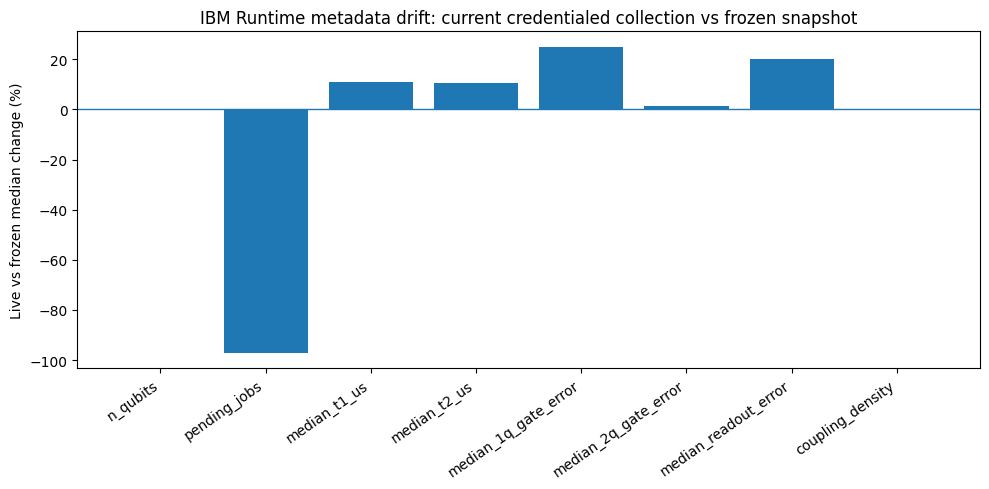

In [7]:
# ============================================================
# 1.2 Frozen-vs-live IBM metadata comparison
# ============================================================

IBM_COMPARISON_METRICS = [
    "n_qubits",
    "pending_jobs",
    "median_t1_us",
    "median_t2_us",
    "median_1q_gate_error",
    "median_2q_gate_error",
    "median_readout_error",
    "coupling_density",
]


def _ibm_numeric_frame(df_obj):
    out = df_obj.copy()
    if "backend" in out.columns:
        out["backend"] = out["backend"].astype(str)
    for col in IBM_COMPARISON_METRICS:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    return out


def _interval_overlap_fraction(a_min, a_max, b_min, b_max):
    vals = [a_min, a_max, b_min, b_max]
    if not np.all(np.isfinite(vals)):
        return np.nan
    union = max(a_max, b_max) - min(a_min, b_min)
    if union == 0:
        return 1.0
    intersection = max(0.0, min(a_max, b_max) - max(a_min, b_min))
    return float(intersection / union)


frozen_ibm_metadata = _ibm_numeric_frame(open_science_frozen_anchor)
live_ibm_metadata = _ibm_numeric_frame(ibm_backend_metadata_live)

if live_ibm_metadata.empty:
    raise RuntimeError("Live IBM metadata are required for the credential-comparison release.")

# Collection-level summary without any credentials or account identifiers.
ibm_live_collection_summary = pd.DataFrame([{
    "frozen_snapshot_date": OPEN_SCIENCE_FROZEN_SNAPSHOT_DATE,
    "live_collection_rows": int(len(live_ibm_metadata)),
    "frozen_rows": int(len(frozen_ibm_metadata)),
    "common_backend_count": int(len(set(frozen_ibm_metadata["backend"]) & set(live_ibm_metadata["backend"]))),
    "live_collection_timestamp_min": live_ibm_metadata.get("collected_at_utc", pd.Series(dtype=str)).min() if "collected_at_utc" in live_ibm_metadata.columns else np.nan,
    "live_collection_timestamp_max": live_ibm_metadata.get("collected_at_utc", pd.Series(dtype=str)).max() if "collected_at_utc" in live_ibm_metadata.columns else np.nan,
    "credential_values_persisted": False,
    "hardware_jobs_submitted_by_this_section": False,
}])

# Same-name backend drift.
common = frozen_ibm_metadata.merge(
    live_ibm_metadata,
    on="backend",
    how="inner",
    suffixes=("_frozen", "_live"),
)
backend_drift_rows = []
for _, row in common.iterrows():
    for metric in IBM_COMPARISON_METRICS:
        f_col, l_col = f"{metric}_frozen", f"{metric}_live"
        if f_col not in common.columns or l_col not in common.columns:
            continue
        f_val = row.get(f_col, np.nan)
        l_val = row.get(l_col, np.nan)
        if not (np.isfinite(f_val) and np.isfinite(l_val)):
            continue
        rel = np.nan if f_val == 0 else 100.0 * (l_val - f_val) / abs(f_val)
        backend_drift_rows.append({
            "backend": row["backend"],
            "metric": metric,
            "frozen_value": float(f_val),
            "live_value": float(l_val),
            "absolute_change_live_minus_frozen": float(l_val - f_val),
            "relative_change_pct": float(rel) if np.isfinite(rel) else np.nan,
        })
ibm_common_backend_drift = pd.DataFrame(backend_drift_rows)

# Distribution-level drift across all accessible physical backends.
distribution_rows = []
for metric in IBM_COMPARISON_METRICS:
    if metric not in frozen_ibm_metadata.columns or metric not in live_ibm_metadata.columns:
        continue
    f = pd.to_numeric(frozen_ibm_metadata[metric], errors="coerce").dropna()
    l = pd.to_numeric(live_ibm_metadata[metric], errors="coerce").dropna()
    if f.empty or l.empty:
        continue
    fmin, fmax = float(f.min()), float(f.max())
    lmin, lmax = float(l.min()), float(l.max())
    frozen_in_live = float(f.between(lmin, lmax).mean() * 100.0)
    live_in_frozen = float(l.between(fmin, fmax).mean() * 100.0)
    fmed, lmed = float(f.median()), float(l.median())
    med_rel = np.nan if fmed == 0 else 100.0 * (lmed - fmed) / abs(fmed)
    distribution_rows.append({
        "metric": metric,
        "frozen_n": int(len(f)),
        "live_n": int(len(l)),
        "frozen_min": fmin,
        "frozen_median": fmed,
        "frozen_max": fmax,
        "live_min": lmin,
        "live_median": lmed,
        "live_max": lmax,
        "median_relative_change_pct": float(med_rel) if np.isfinite(med_rel) else np.nan,
        "frozen_values_within_live_range_pct": frozen_in_live,
        "live_values_within_frozen_range_pct": live_in_frozen,
        "range_overlap_fraction": _interval_overlap_fraction(fmin, fmax, lmin, lmax),
    })
ibm_frozen_vs_live_distribution = pd.DataFrame(distribution_rows)

# Save authenticated comparison artifacts. No secrets are included.
ibm_live_collection_summary.to_csv(TAB_DIR / "ibm_live_collection_summary.csv", index=False)
live_ibm_metadata.to_csv(DATA_DIR / "ibm_runtime_live_metadata_current_run.csv", index=False)
ibm_common_backend_drift.to_csv(TAB_DIR / "ibm_frozen_vs_live_common_backend_drift.csv", index=False)
ibm_frozen_vs_live_distribution.to_csv(TAB_DIR / "ibm_frozen_vs_live_distribution_summary.csv", index=False)

print("Authenticated IBM collection summary:")
display(ibm_live_collection_summary)
print("Frozen-vs-live common-backend drift:")
display(ibm_common_backend_drift)
print("Frozen-vs-live distribution summary:")
display(ibm_frozen_vs_live_distribution)

if not ibm_frozen_vs_live_distribution.empty:
    plot_df = ibm_frozen_vs_live_distribution.dropna(subset=["median_relative_change_pct"]).copy()
    if not plot_df.empty:
        plt.figure(figsize=(10, 5))
        plt.bar(plot_df["metric"], plot_df["median_relative_change_pct"])
        plt.axhline(0, linewidth=1)
        plt.xticks(rotation=35, ha="right")
        plt.ylabel("Live vs frozen median change (%)")
        plt.title("IBM Runtime metadata drift: current credentialed collection vs frozen snapshot")
        plt.tight_layout()
        plt.savefig(FIG_DIR / "ibm_frozen_vs_live_median_drift.png", dpi=180)
        plt.show()


## 2. Problem formulation

Each quantum workload is combined with multiple candidate backends. For each workload-backend pair, the benchmark **constructs a controlled synthetic operational state** and the learning pipeline predicts the quantities needed for backend recommendation.

The learned outputs are:

- total runtime, including queueing, transpilation, execution, latency, and post-processing;
- expected fidelity;
- binary execution recommendation.

The benchmark also generates operational covariates such as cost, availability, capacity penalty, and `failure_probability`. In the present study, `failure_probability` is a **synthetic risk indicator supplied as an input criterion**; it is not a separately learned target. These criteria are combined in the synthetic utility and selection policy.

The recommendation is not a fixed rule such as `if fidelity > threshold, then recommend`. It is sampled from a probability derived from a utility function:

\[
U_i = \sum_k w_k s_{ik} + \epsilon_i,
\]

where \(s_{ik}\) denotes normalized criteria such as fidelity, runtime, cost, availability, failure risk, real-hardware validation value, and capacity penalty. Weights \(w_k\) vary by decision profile.

Accordingly, high predictive scores quantify **internal recoverability of this controlled policy**, not direct predictive validation of production-QPU behavior.


### 2.1 Formal task definition

For each workload \(w\) and candidate backend \(b\), the notebook builds an instance \(x_{w,b}\). The objective is to estimate three output families:

1. **Performance regression:** predict `total_runtime_sec`.
2. **Quality regression:** predict `expected_fidelity`.
3. **Operational classification:** predict `recommended_execution`.

The final orchestration decision is obtained by utility ranking within each `workload_id`, selecting one backend per workload. When no backend is acceptable, the selection is marked as fallback.

### 2.2 Label nature

The variable `recommended_execution` is **not an empirical label collected in production**. It is generated by a probabilistic synthetic policy designed to represent plausible operational criteria. Therefore, the supervised task should be interpreted as:

> learning a synthetic operational decision policy, not empirically discovering a real optimal backend policy.

This distinction is important to avoid circular interpretation in the paper.



## 3. Backend catalog

The catalog distinguishes simulators and cloud QPUs. Each backend has baseline attributes, while the final operational state is later sampled for each workload-backend pair.



### 3.1 Meaning of backend attributes

- `backend_family`: distinguishes simulators and QPUs.
- `base_availability`: expected average availability before dynamic sampling.
- `base_cost_per_shot`: approximate unit cost per shot.
- `speed_factor`: relative backend speed factor.
- `max_effective_qubits`: effective qubit limit used for capacity penalties.
- `supports_real_hardware`: indicates whether the backend represents real quantum hardware.
- `base_single_qubit_error`, `base_two_qubit_error`, `base_readout_error`: initial noise parameters.
- `base_coupling_density`: proxy for qubit connectivity.

These values are not intended to reproduce a specific backend exactly. They define plausible operating ranges that are later perturbed by dynamic state, queueing, calibration age, and stress.



In [8]:
backend_catalog = pd.DataFrame([
    {
        "backend": "statevector_sim",
        "backend_family": "simulator",
        "qpu_modality": "not_applicable",
        "native_strength": "small_medium_exact",
        "base_availability": 0.96,
        "base_cost_per_shot": 0.00001,
        "speed_factor": 1.15,
        "max_effective_qubits": 34,
        "supports_real_hardware": 0,
        "base_single_qubit_error": 0.00005,
        "base_two_qubit_error": 0.00010,
        "base_readout_error": 0.00010,
        "base_coupling_density": 1.00,
    },
    {
        "backend": "tensor_network_sim",
        "backend_family": "simulator",
        "qpu_modality": "not_applicable",
        "native_strength": "structured_low_entanglement",
        "base_availability": 0.92,
        "base_cost_per_shot": 0.00003,
        "speed_factor": 0.78,
        "max_effective_qubits": 90,
        "supports_real_hardware": 0,
        "base_single_qubit_error": 0.00020,
        "base_two_qubit_error": 0.00060,
        "base_readout_error": 0.00020,
        "base_coupling_density": 0.80,
    },
    {
        "backend": "noisy_sim",
        "backend_family": "simulator",
        "qpu_modality": "not_applicable",
        "native_strength": "noise_experiments",
        "base_availability": 0.88,
        "base_cost_per_shot": 0.00005,
        "speed_factor": 1.00,
        "max_effective_qubits": 56,
        "supports_real_hardware": 0,
        "base_single_qubit_error": 0.00150,
        "base_two_qubit_error": 0.00900,
        "base_readout_error": 0.01500,
        "base_coupling_density": 0.70,
    },
    {
        "backend": "qpu_cloud_superconducting",
        "backend_family": "qpu",
        "qpu_modality": "superconducting",
        "native_strength": "fast_hardware_sampling",
        "base_availability": 0.74,
        "base_cost_per_shot": 0.00085,
        "speed_factor": 1.55,
        "max_effective_qubits": 64,
        "supports_real_hardware": 1,
        "base_single_qubit_error": 0.00120,
        "base_two_qubit_error": 0.01500,
        "base_readout_error": 0.02500,
        "base_coupling_density": 0.32,
    },
    {
        "backend": "qpu_cloud_iontrap",
        "backend_family": "qpu",
        "qpu_modality": "iontrap",
        "native_strength": "high_connectivity_hardware",
        "base_availability": 0.68,
        "base_cost_per_shot": 0.00130,
        "speed_factor": 1.90,
        "max_effective_qubits": 36,
        "supports_real_hardware": 1,
        "base_single_qubit_error": 0.00080,
        "base_two_qubit_error": 0.01000,
        "base_readout_error": 0.01800,
        "base_coupling_density": 0.95,
    },
])

backend_catalog



,backend,backend_family,qpu_modality,native_strength,base_availability,base_cost_per_shot,speed_factor,max_effective_qubits,supports_real_hardware,base_single_qubit_error,base_two_qubit_error,base_readout_error,base_coupling_density
0,statevector_sim,simulator,not_applicable,small_medium_exact,0.96,0.00001,1.15,34,0,0.00005,0.0001,0.0001,1.00
1,tensor_network_sim,simulator,not_applicable,structured_low_entanglement,0.92,0.00003,0.78,90,0,0.00020,0.0006,0.0002,0.80
2,noisy_sim,simulator,not_applicable,noise_experiments,0.88,0.00005,1.00,56,0,0.00150,0.0090,0.0150,0.70
3,qpu_cloud_superconducting,qpu,superconducting,fast_hardware_sampling,0.74,0.00085,1.55,64,1,0.00120,0.0150,0.0250,0.32
4,qpu_cloud_iontrap,qpu,iontrap,high_connectivity_hardware,0.68,0.00130,1.90,36,1,0.00080,0.0100,0.0180,0.95


## 3.2 Reproducible external calibration of the QPU catalog

The default open-science run calibrates superconducting-QPU catalog parameters from the frozen IBM/Qiskit Runtime metadata snapshot loaded in Section 1.1. This preserves a fixed external reference across independent reproductions.

The resulting dataset remains synthetic: workloads, operational states, outcomes, utilities, and recommendation labels are generated by the benchmark. The external snapshot only anchors selected QPU parameter ranges. The ion-trap profile remains a synthetic/static alternative because the bundled IBM metadata describe superconducting systems.

If optional live refresh is enabled, the live metadata replace the frozen snapshot for that run and the evidence-scope table records the change explicitly.


In [9]:

# ============================================================
# 3.2 Source-aware external calibration of the QPU catalog
# ============================================================

USE_EXTERNAL_ANCHOR_FOR_QPU_CATALOG = True
ANCHOR_BLEND_ALPHA = 0.45  # 0 = keep original catalog; 1 = fully use the external reference.
ANCHOR_ALPHA_SENSITIVITY_VALUES = [0.0, 0.25, 0.45, 0.65, 0.85]

# Open-science guard: a source-classified external anchor must be available.
# In the default configuration this is the bundled frozen IBM/Qiskit Runtime snapshot.
if "external_qpu_metadata_for_generation" not in globals() or external_qpu_metadata_for_generation.empty:
    raise RuntimeError(
        "The external QPU anchor is missing. Restore the bundled frozen open-science snapshot "
        "or explicitly enable a live IBM metadata refresh."
    )



def _static_qpu_anchor_reference_v9():
    return pd.DataFrame([
        {
            "backend": "static_superconducting_reference_low_error",
            "qpu_modality": "superconducting",
            "source": "static_plausibility_reference_not_current",
            "collection_status": "fallback_static_reference",
            "n_qubits": 127,
            "median_1q_gate_error": 3.0e-4,
            "median_2q_gate_error": 8.0e-3,
            "median_readout_error": 1.5e-2,
            "coupling_density": 0.020,
            "median_t1_us": 180.0,
            "median_t2_us": 120.0,
            "pending_jobs": 18.0,
            "operational": 1.0,
        },
        {
            "backend": "static_superconducting_reference_moderate_error",
            "qpu_modality": "superconducting",
            "source": "static_plausibility_reference_not_current",
            "collection_status": "fallback_static_reference",
            "n_qubits": 127,
            "median_1q_gate_error": 8.0e-4,
            "median_2q_gate_error": 2.0e-2,
            "median_readout_error": 3.0e-2,
            "coupling_density": 0.030,
            "median_t1_us": 90.0,
            "median_t2_us": 70.0,
            "pending_jobs": 35.0,
            "operational": 1.0,
        },
        {
            "backend": "static_iontrap_reference_high_connectivity",
            "qpu_modality": "iontrap",
            "source": "static_plausibility_reference_not_current",
            "collection_status": "fallback_static_reference",
            "n_qubits": 32,
            "median_1q_gate_error": 5.0e-4,
            "median_2q_gate_error": 1.2e-2,
            "median_readout_error": 2.0e-2,
            "coupling_density": 0.95,
            "median_t1_us": 1.0e6,
            "median_t2_us": 1.0e5,
            "pending_jobs": 8.0,
            "operational": 1.0,
        },
    ])


# Anchor priority for catalog calibration:
# 1) canonical source-classified variable generated in Section 1.1;
# 2) bundled frozen snapshot if the variable needs to be reconstructed;
# 3) static fallback only when explicitly enabled for debugging.
qpu_generation_anchor_reference = pd.DataFrame()
qpu_generation_anchor_origin = "not_available"

if (
    "external_qpu_metadata_for_generation" in globals()
    and isinstance(external_qpu_metadata_for_generation, pd.DataFrame)
    and not external_qpu_metadata_for_generation.empty
):
    qpu_generation_anchor_reference = external_qpu_metadata_for_generation.copy()
    qpu_generation_anchor_origin = "variable_external_qpu_metadata_for_generation"
elif (
    "external_qpu_metadata" in globals()
    and isinstance(external_qpu_metadata, pd.DataFrame)
    and not external_qpu_metadata.empty
):
    qpu_generation_anchor_reference = external_qpu_metadata.copy()
    qpu_generation_anchor_origin = "variable_external_qpu_metadata"
else:
    candidate_anchor_paths = [
        Path("open_science_data/ibm_runtime_frozen_snapshot.csv"),
        DATA_DIR / "ibm_runtime_frozen_snapshot.csv",
    ]
    for candidate_path in candidate_anchor_paths:
        try:
            if candidate_path.exists() and candidate_path.stat().st_size > 0:
                tmp = pd.read_csv(candidate_path)
                if not tmp.empty:
                    qpu_generation_anchor_reference = tmp.copy()
                    qpu_generation_anchor_origin = str(candidate_path)
                    break
        except Exception:
            pass

if qpu_generation_anchor_reference.empty:
    if FULL_PAPER_ALLOW_STATIC_FALLBACK_FOR_DRY_RUN:
        qpu_generation_anchor_reference = _static_qpu_anchor_reference_v9()
        qpu_generation_anchor_origin = "static_dry_run_reference"
    else:
        raise RuntimeError(
            "No external QPU anchor was found. Restore the bundled frozen snapshot or rerun Section 1.1."
        )

# Normalize expected column names.
if "backend" in qpu_generation_anchor_reference.columns and "anchor_backend" not in qpu_generation_anchor_reference.columns:
    qpu_generation_anchor_reference["anchor_backend"] = qpu_generation_anchor_reference["backend"].astype(str)
if "qpu_modality" not in qpu_generation_anchor_reference.columns:
    qpu_generation_anchor_reference["qpu_modality"] = "superconducting"
if "source" not in qpu_generation_anchor_reference.columns:
    qpu_generation_anchor_reference["source"] = "unknown_external_anchor"
if "collection_status" not in qpu_generation_anchor_reference.columns:
    qpu_generation_anchor_reference["collection_status"] = "unknown"
if "evidence_level" not in qpu_generation_anchor_reference.columns:
    qpu_generation_anchor_reference["evidence_level"] = np.where(
        qpu_generation_anchor_reference["source"].astype(str).str.contains("ibm_qiskit_runtime_live_metadata", case=False, na=False),
        "live_runtime_metadata",
        "plausibility_or_static_reference",
    )
qpu_generation_anchor_reference["anchor_origin"] = qpu_generation_anchor_origin

if "classify_external_anchor_evidence" in globals():
    qpu_generation_anchor_evidence_scope = classify_external_anchor_evidence(qpu_generation_anchor_reference)
else:
    qpu_generation_anchor_evidence_scope = pd.DataFrame([{
        "anchor_evidence_scope": "unclassified_external_reference",
        "live_ibm_runtime_available": False,
        "recommended_claim": "externally checked, evidence level not classified",
        "paper_wording": "The external anchor evidence level was not classified in this run.",
    }])
qpu_generation_anchor_reference["anchor_evidence_scope"] = qpu_generation_anchor_evidence_scope["anchor_evidence_scope"].iloc[0]
qpu_generation_anchor_reference["live_ibm_runtime_available"] = bool(qpu_generation_anchor_evidence_scope["live_ibm_runtime_available"].iloc[0])

if FULL_PAPER_REQUIRE_IBM_RUNTIME_ANCHOR:
    has_live_ibm_anchor = qpu_generation_anchor_reference["source"].astype(str).str.contains(
        "ibm_qiskit_runtime_live_metadata", case=False, na=False
    ).any()
    if not has_live_ibm_anchor:
        raise RuntimeError(
            "Section 3.2 is not using live IBM/Qiskit Runtime metadata. "
            "Run Section 1.1 and confirm source=ibm_qiskit_runtime_live_metadata."
        )

numeric_anchor_cols = [
    "n_qubits", "median_1q_gate_error", "median_2q_gate_error",
    "median_readout_error", "coupling_density", "median_t1_us", "median_t2_us",
    "pending_jobs", "operational"
]
for col in numeric_anchor_cols:
    if col in qpu_generation_anchor_reference.columns:
        qpu_generation_anchor_reference[col] = pd.to_numeric(qpu_generation_anchor_reference[col], errors="coerce")


def _blend_numeric(original, reference, alpha=ANCHOR_BLEND_ALPHA):
    try:
        if pd.isna(original) or pd.isna(reference):
            return original
        return float((1 - alpha) * float(original) + alpha * float(reference))
    except Exception:
        return original


def _default_qpu_state_values(backend_name):
    backend_name = str(backend_name).lower()
    if "iontrap" in backend_name:
        return {"base_t1_us": 8.0e5, "base_t2_us": 6.5e5, "base_queue_depth": 11.0}
    return {"base_t1_us": 90.0, "base_t2_us": 70.0, "base_queue_depth": 18.0}


def _relative_log_distance(a, b):
    try:
        if pd.isna(a) or pd.isna(b) or a <= 0 or b <= 0:
            return np.nan
        return abs(np.log10(float(a) / float(b)))
    except Exception:
        return np.nan


def calibrate_qpu_backend_catalog(base_catalog, anchor_reference, alpha=ANCHOR_BLEND_ALPHA):
    """Calibrates QPU catalog rows with external metadata before synthetic generation.

    The goal is not to reproduce a specific backend, but to align orders of magnitude
    of qubits, errors, readout, connectivity, T1/T2, and queueing with IBM/Qiskit data ou fontes
    of the reference. IBM metadata anchor only superconducting backends; the ion-trap profile
    remains anchored in a static/snapshot reference when there is no equivalent IBM source.
    """
    calibrated = base_catalog.copy()
    calibrated["generation_anchor_source"] = "synthetic_default"
    calibrated["generation_anchor_alpha"] = 0.0
    calibrated["generation_anchor_n"] = 0

    # New calibratable operational columns used by synthetic generation.
    for idx, row in calibrated.iterrows():
        defaults = _default_qpu_state_values(row.get("backend", ""))
        for col, value in defaults.items():
            if col not in calibrated.columns:
                calibrated[col] = np.nan
            if pd.isna(calibrated.loc[idx, col]):
                calibrated.loc[idx, col] = value if row.get("backend_family") == "qpu" else (0 if col == "base_queue_depth" else 1e9)

    if not USE_EXTERNAL_ANCHOR_FOR_QPU_CATALOG or anchor_reference.empty:
        return calibrated

    for idx, row in calibrated.iterrows():
        if row.get("backend_family") != "qpu":
            continue

        modality = str(row.get("qpu_modality", "")).lower().strip()
        if modality in ("", "nan", "none", "not_applicable"):
            modality = "iontrap" if "iontrap" in str(row.get("backend", "")).lower() else "superconducting"

        ref = anchor_reference[anchor_reference["qpu_modality"].astype(str).str.lower().eq(modality)].copy()

        # Correction : do not use IBM superconducting metadata to calibrate ion-trap.
        # If there is no external reference from the same modality, preserve the synthetic profile
        # and explicitly mark the absence of a specific anchor.
        if ref.empty:
            calibrated.loc[idx, "generation_anchor_source"] = f"no_modality_specific_anchor::{modality}"
            calibrated.loc[idx, "generation_anchor_alpha"] = 0.0
            calibrated.loc[idx, "generation_anchor_n"] = 0
            continue

        ref_stats = ref[[c for c in [
            "n_qubits", "median_1q_gate_error", "median_2q_gate_error",
            "median_readout_error", "coupling_density", "median_t1_us", "median_t2_us",
            "pending_jobs", "operational"
        ] if c in ref.columns]].median(numeric_only=True)

        calibrated.loc[idx, "max_effective_qubits"] = max(
            4,
            round(_blend_numeric(row["max_effective_qubits"], ref_stats.get("n_qubits", np.nan), alpha * 0.35)),
        )
        calibrated.loc[idx, "base_single_qubit_error"] = _blend_numeric(
            row["base_single_qubit_error"], ref_stats.get("median_1q_gate_error", np.nan), alpha
        )
        calibrated.loc[idx, "base_two_qubit_error"] = _blend_numeric(
            row["base_two_qubit_error"], ref_stats.get("median_2q_gate_error", np.nan), alpha
        )
        calibrated.loc[idx, "base_readout_error"] = _blend_numeric(
            row["base_readout_error"], ref_stats.get("median_readout_error", np.nan), alpha
        )
        calibrated.loc[idx, "base_coupling_density"] = _blend_numeric(
            row["base_coupling_density"], ref_stats.get("coupling_density", np.nan), alpha
        )
        calibrated.loc[idx, "base_t1_us"] = _blend_numeric(
            calibrated.loc[idx, "base_t1_us"], ref_stats.get("median_t1_us", np.nan), alpha
        )
        calibrated.loc[idx, "base_t2_us"] = _blend_numeric(
            calibrated.loc[idx, "base_t2_us"], ref_stats.get("median_t2_us", np.nan), alpha
        )
        calibrated.loc[idx, "base_queue_depth"] = max(
            0.0,
            _blend_numeric(calibrated.loc[idx, "base_queue_depth"], ref_stats.get("pending_jobs", np.nan), alpha),
        )
        if not pd.isna(ref_stats.get("operational", np.nan)):
            # Conservative adjustment: synthetic availability does not automatically become 1.0; it only moves closer.
            calibrated.loc[idx, "base_availability"] = np.clip(
                _blend_numeric(row["base_availability"], 0.62 + 0.28 * ref_stats.get("operational", 1.0), alpha * 0.20),
                0.20,
                0.98,
            )
        calibrated.loc[idx, "generation_anchor_source"] = ";".join(sorted(ref["source"].dropna().astype(str).unique()))
        calibrated.loc[idx, "generation_anchor_alpha"] = alpha
        calibrated.loc[idx, "generation_anchor_n"] = len(ref)

    return calibrated


def summarize_anchor_alpha_sensitivity(base_catalog, anchor_reference, alphas):
    rows = []
    for alpha in alphas:
        cat = calibrate_qpu_backend_catalog(base_catalog, anchor_reference, alpha=alpha)
        qpus = cat[cat["backend_family"].eq("qpu")].copy()
        for _, row in qpus.iterrows():
            modality = str(row.get("qpu_modality", "")).lower().strip()
            if modality in ("", "nan", "none", "not_applicable"):
                modality = "iontrap" if "iontrap" in str(row.get("backend", "")).lower() else "superconducting"
            ref = anchor_reference[anchor_reference["qpu_modality"].astype(str).str.lower().eq(modality)].copy()
            if ref.empty:
                rows.append({
                    "alpha": alpha,
                    "backend": row["backend"],
                    "modality": modality,
                    "mean_log10_distance_to_anchor": np.nan,
                    "base_single_qubit_error": row.get("base_single_qubit_error"),
                    "base_two_qubit_error": row.get("base_two_qubit_error"),
                    "base_readout_error": row.get("base_readout_error"),
                    "base_t1_us": row.get("base_t1_us"),
                    "base_t2_us": row.get("base_t2_us"),
                    "base_queue_depth": row.get("base_queue_depth"),
                    "base_coupling_density": row.get("base_coupling_density"),
                    "note": "no external anchor from the same modality"
                })
                continue
            ref_stats = ref[[c for c in [
                "median_1q_gate_error", "median_2q_gate_error", "median_readout_error",
                "coupling_density", "median_t1_us", "median_t2_us", "pending_jobs"
            ] if c in ref.columns]].median(numeric_only=True)
            distances = [
                _relative_log_distance(row.get("base_single_qubit_error"), ref_stats.get("median_1q_gate_error", np.nan)),
                _relative_log_distance(row.get("base_two_qubit_error"), ref_stats.get("median_2q_gate_error", np.nan)),
                _relative_log_distance(row.get("base_readout_error"), ref_stats.get("median_readout_error", np.nan)),
                _relative_log_distance(row.get("base_t1_us"), ref_stats.get("median_t1_us", np.nan)),
                _relative_log_distance(row.get("base_t2_us"), ref_stats.get("median_t2_us", np.nan)),
            ]
            rows.append({
                "alpha": alpha,
                "backend": row["backend"],
                "modality": modality,
                "mean_log10_distance_to_anchor": float(np.nanmean(distances)) if np.any(~pd.isna(distances)) else np.nan,
                "base_single_qubit_error": row.get("base_single_qubit_error"),
                "base_two_qubit_error": row.get("base_two_qubit_error"),
                "base_readout_error": row.get("base_readout_error"),
                "base_t1_us": row.get("base_t1_us"),
                "base_t2_us": row.get("base_t2_us"),
                "base_queue_depth": row.get("base_queue_depth"),
                "base_coupling_density": row.get("base_coupling_density"),
            })
    return pd.DataFrame(rows)


backend_catalog_raw = backend_catalog.copy()
anchor_alpha_sensitivity = summarize_anchor_alpha_sensitivity(
    backend_catalog_raw,
    qpu_generation_anchor_reference,
    ANCHOR_ALPHA_SENSITIVITY_VALUES,
)
backend_catalog = calibrate_qpu_backend_catalog(backend_catalog_raw, qpu_generation_anchor_reference)

qpu_generation_anchor_reference.to_csv(TAB_DIR / "qpu_generation_anchor_reference.csv", index=False)
qpu_generation_anchor_evidence_scope.to_csv(TAB_DIR / "external_anchor_evidence_scope.csv", index=False)
backend_catalog_raw.to_csv(TAB_DIR / "backend_catalog_raw.csv", index=False)
backend_catalog.to_csv(TAB_DIR / "backend_catalog_calibrated.csv", index=False)
anchor_alpha_sensitivity.to_csv(TAB_DIR / "anchor_alpha_sensitivity.csv", index=False)

# Freeze an auditable fingerprint of the exact anchor/catalog snapshot used in this run.
import hashlib

def _open_science_sha256(path):
    path = Path(path)
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

open_science_snapshot_files = {
    "qpu_generation_anchor_reference": TAB_DIR / "qpu_generation_anchor_reference.csv",
    "external_anchor_evidence_scope": TAB_DIR / "external_anchor_evidence_scope.csv",
    "backend_catalog_raw": TAB_DIR / "backend_catalog_raw.csv",
    "backend_catalog_calibrated": TAB_DIR / "backend_catalog_calibrated.csv",
    "anchor_alpha_sensitivity": TAB_DIR / "anchor_alpha_sensitivity.csv",
}
open_science_snapshot_manifest = {
    key: {"path": str(path), "sha256": _open_science_sha256(path)}
    for key, path in open_science_snapshot_files.items()
}
with open(DATA_DIR / "open_science_snapshot_manifest.json", "w", encoding="utf-8") as f:
    json.dump(open_science_snapshot_manifest, f, indent=2, sort_keys=True)

print("External reference used for generation calibration:")
print("Source-aware evidence scope:")
display(qpu_generation_anchor_evidence_scope)
display(qpu_generation_anchor_reference[[c for c in ["anchor_backend", "qpu_modality", "source", "collection_status", "evidence_level", "anchor_evidence_scope", "live_ibm_runtime_available", "n_qubits", "median_1q_gate_error", "median_2q_gate_error", "median_readout_error", "median_t1_us", "median_t2_us", "coupling_density", "pending_jobs"] if c in qpu_generation_anchor_reference.columns]].head(30))

print("Backend catalog after source-aware externally anchored calibration:")
display(backend_catalog)

print("Sensitivity analysis of the ANCHOR_BLEND_ALPHA parameter:")
display(anchor_alpha_sensitivity)

print("Methodological note  open science: the IBM/Qiskit metadata snapshot anchors only superconducting backends. The ion-trap profile is not calibrated with IBM superconducting data; it remains synthetic/static when no external source of the same modality is available. If live_ibm_runtime_available is False, report this run as a static/cache/snapshot plausibility check according to the evidence-scope table.")




External reference used for generation calibration:
Source-aware evidence scope:


,anchor_evidence_scope,live_ibm_runtime_available,cached_ibm_runtime_available,frozen_snapshot_available,static_reference_used,qiskit_snapshot_used,source_values,collection_status_values,evidence_level_values,anchor_priority_values,recommended_claim,paper_wording
0,frozen_ibm_qiskit_runtime_metadata_snapshot,False,False,True,False,False,ibm_qiskit_runtime_frozen_public_snapshot,frozen_from_archived_live_run,frozen_runtime_metadata_snapshot,open_science_frozen_snapshot,anchored in a frozen historical IBM/Qiskit Run...,A frozen historical IBM/Qiskit Runtime metadat...


,anchor_backend,qpu_modality,source,collection_status,evidence_level,anchor_evidence_scope,live_ibm_runtime_available,n_qubits,median_1q_gate_error,median_2q_gate_error,median_readout_error,median_t1_us,median_t2_us,coupling_density,pending_jobs
0,ibm_fez,superconducting,ibm_qiskit_runtime_frozen_public_snapshot,frozen_from_archived_live_run,frozen_runtime_metadata_snapshot,frozen_ibm_qiskit_runtime_metadata_snapshot,False,156,0.000306,0.002727,0.008728,119.371513,81.037188,0.014557,278.0
1,ibm_marrakesh,superconducting,ibm_qiskit_runtime_frozen_public_snapshot,frozen_from_archived_live_run,frozen_runtime_metadata_snapshot,frozen_ibm_qiskit_runtime_metadata_snapshot,False,156,0.000343,0.002659,0.009888,166.514406,85.199467,0.014557,255.0
2,ibm_kingston,superconducting,ibm_qiskit_runtime_frozen_public_snapshot,frozen_from_archived_live_run,frozen_runtime_metadata_snapshot,frozen_ibm_qiskit_runtime_metadata_snapshot,False,156,0.000310,0.001882,0.008789,255.971616,151.644539,0.014557,499.0


Backend catalog after source-aware externally anchored calibration:


,backend,backend_family,qpu_modality,native_strength,base_availability,base_cost_per_shot,speed_factor,max_effective_qubits,supports_real_hardware,base_single_qubit_error,base_two_qubit_error,base_readout_error,base_coupling_density,generation_anchor_source,generation_anchor_alpha,generation_anchor_n,base_t1_us,base_t2_us,base_queue_depth
0,statevector_sim,simulator,not_applicable,small_medium_exact,0.9600,0.00001,1.15,34,0,0.000050,0.000100,0.000100,1.000000,synthetic_default,0.00,0,1.000000e+09,1.000000e+09,0.0
1,tensor_network_sim,simulator,not_applicable,structured_low_entanglement,0.9200,0.00003,0.78,90,0,0.000200,0.000600,0.000200,0.800000,synthetic_default,0.00,0,1.000000e+09,1.000000e+09,0.0
2,noisy_sim,simulator,not_applicable,noise_experiments,0.8800,0.00005,1.00,56,0,0.001500,0.009000,0.015000,0.700000,synthetic_default,0.00,0,1.000000e+09,1.000000e+09,0.0
3,qpu_cloud_superconducting,qpu,superconducting,fast_hardware_sampling,0.7544,0.00085,1.55,78,1,0.000799,0.009447,0.017705,0.182551,ibm_qiskit_runtime_frozen_public_snapshot,0.45,3,1.244315e+02,7.683976e+01,135.0
4,qpu_cloud_iontrap,qpu,iontrap,high_connectivity_hardware,0.6800,0.00130,1.90,36,1,0.000800,0.010000,0.018000,0.950000,no_modality_specific_anchor::iontrap,0.00,0,8.000000e+05,6.500000e+05,11.0


Sensitivity analysis of the ANCHOR_BLEND_ALPHA parameter:


,alpha,backend,modality,mean_log10_distance_to_anchor,base_single_qubit_error,base_two_qubit_error,base_readout_error,base_t1_us,base_t2_us,base_queue_depth,base_coupling_density,note
0,0.00,qpu_cloud_superconducting,superconducting,0.429148,0.001200,0.015000,0.025000,90.000000,70.000000,18.0,0.320000,NaN
1,0.00,qpu_cloud_iontrap,iontrap,NaN,0.000800,0.010000,0.018000,800000.000000,650000.000000,11.0,0.950000,no external anchor from the same modality
2,0.25,qpu_cloud_superconducting,superconducting,0.354641,0.000978,0.011915,0.020947,109.128602,73.799867,83.0,0.243639,NaN
3,0.25,qpu_cloud_iontrap,iontrap,NaN,0.000800,0.010000,0.018000,800000.000000,650000.000000,11.0,0.950000,no external anchor from the same modality
4,0.45,qpu_cloud_superconducting,superconducting,0.287508,0.000799,0.009447,0.017705,124.431483,76.839760,135.0,0.182551,NaN
5,0.45,qpu_cloud_iontrap,iontrap,NaN,0.000800,0.010000,0.018000,800000.000000,650000.000000,11.0,0.950000,no external anchor from the same modality
6,0.65,qpu_cloud_superconducting,superconducting,0.208316,0.000621,0.006978,0.014463,139.734364,79.879654,187.0,0.121462,NaN
7,0.65,qpu_cloud_iontrap,iontrap,NaN,0.000800,0.010000,0.018000,800000.000000,650000.000000,11.0,0.950000,no external anchor from the same modality
8,0.85,qpu_cloud_superconducting,superconducting,0.106776,0.000443,0.004510,0.011221,155.037245,82.919547,239.0,0.060373,NaN
9,0.85,qpu_cloud_iontrap,iontrap,NaN,0.000800,0.010000,0.018000,800000.000000,650000.000000,11.0,0.950000,no external anchor from the same modality


Methodological note  open science: the IBM/Qiskit metadata snapshot anchors only superconducting backends. The ion-trap profile is not calibrated with IBM superconducting data; it remains synthetic/static when no external source of the same modality is available. If live_ibm_runtime_available is False, report this run as a static/cache/snapshot plausibility check according to the evidence-scope table.


### 3.2.1 Same-alpha catalog comparison: frozen versus live IBM anchor

To isolate the effect of metadata freshness from all other modeling choices, this section calibrates the **same raw synthetic backend catalog** twice at the same `ANCHOR_BLEND_ALPHA`: once with the frozen IBM snapshot and once with the current credentialed IBM Runtime metadata.

The ion-trap profile is not included in the IBM-driven difference because IBM Runtime metadata in this notebook describe superconducting backends. The resulting table therefore quantifies how current superconducting metadata would change the synthetic QPU catalog without conflating that change with a different random seed or a different anchoring coefficient.


In [10]:
# ============================================================
# 3.2.1 Frozen-vs-live calibrated QPU catalog comparison
# ============================================================

frozen_anchor_for_catalog = open_science_frozen_anchor.copy()
frozen_anchor_for_catalog["anchor_priority"] = "open_science_frozen_snapshot"

live_anchor_for_catalog = ibm_backend_metadata_live.copy()
live_anchor_for_catalog["anchor_priority"] = "live_current_run_comparison"

backend_catalog_frozen_anchor = calibrate_qpu_backend_catalog(
    backend_catalog_raw,
    frozen_anchor_for_catalog,
    alpha=ANCHOR_BLEND_ALPHA,
)
backend_catalog_live_anchor = calibrate_qpu_backend_catalog(
    backend_catalog_raw,
    live_anchor_for_catalog,
    alpha=ANCHOR_BLEND_ALPHA,
)

catalog_compare_cols = [
    "max_effective_qubits",
    "base_single_qubit_error",
    "base_two_qubit_error",
    "base_readout_error",
    "base_coupling_density",
    "base_t1_us",
    "base_t2_us",
    "base_queue_depth",
    "base_availability",
]

fcat = backend_catalog_frozen_anchor[backend_catalog_frozen_anchor["backend_family"].eq("qpu")].copy()
lcat = backend_catalog_live_anchor[backend_catalog_live_anchor["backend_family"].eq("qpu")].copy()
cat_merge = fcat.merge(lcat, on="backend", suffixes=("_frozen", "_live"))

catalog_drift_rows = []
for _, row in cat_merge.iterrows():
    modality = str(row.get("qpu_modality_frozen", row.get("qpu_modality_live", ""))).lower()
    for metric in catalog_compare_cols:
        fc, lc = f"{metric}_frozen", f"{metric}_live"
        if fc not in cat_merge.columns or lc not in cat_merge.columns:
            continue
        fv, lv = row.get(fc, np.nan), row.get(lc, np.nan)
        if not (np.isfinite(fv) and np.isfinite(lv)):
            continue
        rel = np.nan if fv == 0 else 100.0 * (lv - fv) / abs(fv)
        catalog_drift_rows.append({
            "backend": row["backend"],
            "qpu_modality": modality,
            "metric": metric,
            "alpha": float(ANCHOR_BLEND_ALPHA),
            "frozen_anchor_value": float(fv),
            "live_anchor_value": float(lv),
            "absolute_change_live_minus_frozen": float(lv - fv),
            "relative_change_pct": float(rel) if np.isfinite(rel) else np.nan,
            "ibm_superconducting_anchor_applicable": modality == "superconducting",
        })

catalog_anchor_frozen_vs_live = pd.DataFrame(catalog_drift_rows)
backend_catalog_frozen_anchor.to_csv(TAB_DIR / "backend_catalog_frozen_anchor.csv", index=False)
backend_catalog_live_anchor.to_csv(TAB_DIR / "backend_catalog_live_anchor.csv", index=False)
catalog_anchor_frozen_vs_live.to_csv(TAB_DIR / "backend_catalog_frozen_vs_live_anchor_drift.csv", index=False)

print("Calibrated catalog drift under identical alpha:")
display(catalog_anchor_frozen_vs_live)


Calibrated catalog drift under identical alpha:


,backend,qpu_modality,metric,alpha,frozen_anchor_value,live_anchor_value,absolute_change_live_minus_frozen,relative_change_pct,ibm_superconducting_anchor_applicable
0,qpu_cloud_superconducting,superconducting,max_effective_qubits,0.45,78.000000,78.000000,0.000000e+00,0.000000,True
1,qpu_cloud_superconducting,superconducting,base_single_qubit_error,0.45,0.000799,0.000834,3.497432e-05,4.374524,True
2,qpu_cloud_superconducting,superconducting,base_two_qubit_error,0.45,0.009447,0.009461,1.453623e-05,0.153879,True
3,qpu_cloud_superconducting,superconducting,base_readout_error,0.45,0.017705,0.018502,7.965369e-04,4.498925,True
4,qpu_cloud_superconducting,superconducting,base_coupling_density,0.45,0.182551,0.182551,2.184864e-07,0.000120,True
5,qpu_cloud_superconducting,superconducting,base_t1_us,0.45,124.431483,132.622087,8.190604e+00,6.582421,True
6,qpu_cloud_superconducting,superconducting,base_t2_us,0.45,76.839760,80.862921,4.023161e+00,5.235780,True
7,qpu_cloud_superconducting,superconducting,base_queue_depth,0.45,135.000000,13.500000,-1.215000e+02,-90.000000,True
8,qpu_cloud_superconducting,superconducting,base_availability,0.45,0.754400,0.754400,0.000000e+00,0.000000,True
9,qpu_cloud_iontrap,iontrap,max_effective_qubits,0.45,36.000000,36.000000,0.000000e+00,0.000000,False


### 3.3 Note on QPU modalities

IBM/Qiskit metadata collected through `QiskitRuntimeService` represent superconducting backends. Therefore, they directly calibrate the `qpu_cloud_superconducting` profile. The `qpu_cloud_iontrap` profile is kept as a synthetic/static reference for an alternative high-connectivity architecture; it should not be interpreted as validated by IBM metadata.



## 4. Algorithm profiles

Profiles control depth, two-qubit gate intensity, entanglement, noise sensitivity, and number of shots.



In [11]:
algorithm_profiles = pd.DataFrame([
    {
        "algorithm": "GHZ",
        "algorithm_family": "entanglement_kernel",
        "depth_factor": 0.55,
        "two_qubit_factor": 0.95,
        "entanglement_factor": 1.15,
        "noise_sensitivity": 0.85,
        "shot_factor": 0.80,
    },
    {
        "algorithm": "QAOA",
        "algorithm_family": "variational_optimization",
        "depth_factor": 1.15,
        "two_qubit_factor": 1.25,
        "entanglement_factor": 1.05,
        "noise_sensitivity": 1.15,
        "shot_factor": 1.20,
    },
    {
        "algorithm": "VQE",
        "algorithm_family": "variational_simulation",
        "depth_factor": 1.00,
        "two_qubit_factor": 1.05,
        "entanglement_factor": 0.95,
        "noise_sensitivity": 1.05,
        "shot_factor": 1.30,
    },
    {
        "algorithm": "HHL",
        "algorithm_family": "linear_solver",
        "depth_factor": 1.55,
        "two_qubit_factor": 1.20,
        "entanglement_factor": 0.90,
        "noise_sensitivity": 1.35,
        "shot_factor": 0.95,
    },
    {
        "algorithm": "Hamiltonian",
        "algorithm_family": "quantum_simulation",
        "depth_factor": 1.45,
        "two_qubit_factor": 1.35,
        "entanglement_factor": 1.20,
        "noise_sensitivity": 1.25,
        "shot_factor": 1.10,
    },
    {
        "algorithm": "QML",
        "algorithm_family": "quantum_machine_learning",
        "depth_factor": 1.10,
        "two_qubit_factor": 1.10,
        "entanglement_factor": 1.00,
        "noise_sensitivity": 1.10,
        "shot_factor": 1.40,
    },
])

algorithm_profiles



,algorithm,algorithm_family,depth_factor,two_qubit_factor,entanglement_factor,noise_sensitivity,shot_factor
0,GHZ,entanglement_kernel,0.55,0.95,1.15,0.85,0.80
1,QAOA,variational_optimization,1.15,1.25,1.05,1.15,1.20
2,VQE,variational_simulation,1.00,1.05,0.95,1.05,1.30
3,HHL,linear_solver,1.55,1.20,0.90,1.35,0.95
4,Hamiltonian,quantum_simulation,1.45,1.35,1.20,1.25,1.10
5,QML,quantum_machine_learning,1.10,1.10,1.00,1.10,1.40


## 5. Operational decision profiles

The weights below simulate different usage objectives. This step reduces the bias of a single recommendation policy.



In [12]:
decision_profiles = pd.DataFrame([
    {
        "decision_profile": "research_validation",
        "w_fidelity": 0.26,
        "w_time": 0.08,
        "w_cost": 0.03,
        "w_availability": 0.08,
        "w_failure": 0.08,
        "w_hardware": 0.42,
        "w_capacity": 0.05,
    },
    {
        "decision_profile": "cost_sensitive",
        "w_fidelity": 0.22,
        "w_time": 0.14,
        "w_cost": 0.34,
        "w_availability": 0.18,
        "w_failure": 0.08,
        "w_hardware": 0.00,
        "w_capacity": 0.04,
    },
    {
        "decision_profile": "deadline_sensitive",
        "w_fidelity": 0.20,
        "w_time": 0.34,
        "w_cost": 0.10,
        "w_availability": 0.18,
        "w_failure": 0.10,
        "w_hardware": 0.03,
        "w_capacity": 0.05,
    },
    {
        "decision_profile": "fidelity_sensitive",
        "w_fidelity": 0.42,
        "w_time": 0.10,
        "w_cost": 0.06,
        "w_availability": 0.12,
        "w_failure": 0.15,
        "w_hardware": 0.10,
        "w_capacity": 0.05,
    },
    {
        "decision_profile": "hpc_batch",
        "w_fidelity": 0.20,
        "w_time": 0.22,
        "w_cost": 0.18,
        "w_availability": 0.16,
        "w_failure": 0.08,
        "w_hardware": 0.02,
        "w_capacity": 0.14,
    },
    {
        "decision_profile": "educational",
        "w_fidelity": 0.20,
        "w_time": 0.16,
        "w_cost": 0.30,
        "w_availability": 0.24,
        "w_failure": 0.08,
        "w_hardware": 0.00,
        "w_capacity": 0.02,
    },
])

decision_profiles



,decision_profile,w_fidelity,w_time,w_cost,w_availability,w_failure,w_hardware,w_capacity
0,research_validation,0.26,0.08,0.03,0.08,0.08,0.42,0.05
1,cost_sensitive,0.22,0.14,0.34,0.18,0.08,0.00,0.04
2,deadline_sensitive,0.20,0.34,0.10,0.18,0.10,0.03,0.05
3,fidelity_sensitive,0.42,0.10,0.06,0.12,0.15,0.10,0.05
4,hpc_batch,0.20,0.22,0.18,0.16,0.08,0.02,0.14
5,educational,0.20,0.16,0.30,0.24,0.08,0.00,0.02


## 6. Auxiliary functions for realistic synthetic generation



In [13]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def minmax(series):
    series = pd.Series(series)
    min_v = series.min()
    max_v = series.max()
    if max_v == min_v:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - min_v) / (max_v - min_v)


def within_workload_minmax(df, column):
    """Normalizes a variable among candidate backends of the same workload."""
    if "workload_id" not in df.columns:
        return minmax(df[column])
    def _scale(s):
        min_v, max_v = s.min(), s.max()
        if max_v == min_v:
            return pd.Series(np.zeros(len(s)), index=s.index)
        return (s - min_v) / (max_v - min_v)
    return df.groupby("workload_id")[column].transform(_scale)


def assign_selected_backend(df, utility_col="decision_utility", acceptable_col="recommended_execution"):
    """Selects exactly one backend per workload.

    Operational rule:
    1. If there is at least one acceptable backend, select the acceptable one with the highest utility.
    2. If no backend is acceptable, select the highest-utility backend as fallback.
    """
    df = df.copy()
    df["has_acceptable_backend"] = df.groupby("workload_id")[acceptable_col].transform("sum").gt(0).astype(int)
    df["selection_fallback"] = 0
    df["selected_backend"] = 0

    selected_indices = []
    for _, group in df.groupby("workload_id", sort=False):
        acceptable = group[group[acceptable_col] == 1]
        if len(acceptable) > 0:
            idx = acceptable[utility_col].idxmax()
        else:
            idx = group[utility_col].idxmax()
            df.loc[idx, "selection_fallback"] = 1
        selected_indices.append(idx)

    df.loc[selected_indices, "selected_backend"] = 1
    df["backend_rank_utility"] = df.groupby("workload_id")[utility_col].rank(ascending=False, method="first").astype(int)

    # Operational ranking: acceptable backends are ordered by utility; non-acceptable backends come afterward.
    # When there is no acceptable backend, ranking falls back to utility only.
    rank_values = pd.Series(index=df.index, dtype=int)
    for _, group in df.groupby("workload_id", sort=False):
        if group[acceptable_col].sum() > 0:
            tmp = group.assign(_sort_accept=group[acceptable_col], _sort_utility=group[utility_col])
            ordered_idx = tmp.sort_values(["_sort_accept", "_sort_utility"], ascending=[False, False]).index
        else:
            ordered_idx = group.sort_values(utility_col, ascending=False).index
        rank_values.loc[ordered_idx] = np.arange(1, len(ordered_idx) + 1)

    df["backend_rank_true"] = rank_values.astype(int)
    return df


def add_predicted_selection(test_like_df, prob_col="recommendation_probability", score_col=None, threshold=0.5):
    """Applies the same selection logic to predicted outputs using an explicit score column."""
    if score_col is None:
        raise ValueError("score_col must be supplied explicitly so information access is auditable.")
    out = test_like_df.copy()
    out["predicted_acceptable_backend"] = (out[prob_col] >= threshold).astype(int)
    out["predicted_selection_fallback"] = 0
    out["predicted_selected_backend"] = 0

    selected_indices = []
    rank_values = pd.Series(index=out.index, dtype=int)

    for _, group in out.groupby("workload_id", sort=False):
        acceptable = group[group["predicted_acceptable_backend"] == 1]
        if len(acceptable) > 0:
            idx = acceptable[score_col].idxmax()
        else:
            idx = group[score_col].idxmax()
            out.loc[idx, "predicted_selection_fallback"] = 1
        selected_indices.append(idx)

        if group["predicted_acceptable_backend"].sum() > 0:
            ordered_idx = group.sort_values(["predicted_acceptable_backend", score_col], ascending=[False, False]).index
        else:
            ordered_idx = group.sort_values(score_col, ascending=False).index
        rank_values.loc[ordered_idx] = np.arange(1, len(ordered_idx) + 1)

    out.loc[selected_indices, "predicted_selected_backend"] = 1
    out["predicted_backend_rank"] = rank_values.astype(int)
    return out


def generate_workloads(n_workloads=1000, random_seed=42):
    local_rng = np.random.default_rng(random_seed)
    algorithm_types = algorithm_profiles["algorithm"].tolist()
    profile_types = decision_profiles["decision_profile"].tolist()

    workloads = pd.DataFrame({
        "workload_id": np.arange(n_workloads),
        "algorithm": local_rng.choice(algorithm_types, n_workloads),
        "decision_profile": local_rng.choice(
            profile_types,
            n_workloads,
            p=[0.16, 0.20, 0.18, 0.18, 0.14, 0.14],
        ),
        "base_num_qubits": local_rng.integers(4, 81, n_workloads),
        "base_depth": local_rng.integers(20, 1900, n_workloads),
        "base_two_qubit_gates": local_rng.integers(5, 950, n_workloads),
        "base_shots": local_rng.choice(
            [512, 1024, 2048, 4096, 8192],
            n_workloads,
            p=[0.22, 0.28, 0.25, 0.18, 0.07],
        ),
        "scientific_priority": local_rng.beta(2.2, 2.0, n_workloads),
        "deadline_hours": local_rng.choice([1, 4, 12, 24, 72], n_workloads, p=[0.12, 0.18, 0.25, 0.25, 0.20]),
        "budget_usd": local_rng.lognormal(mean=np.log(5.0), sigma=0.75, size=n_workloads),
    })

    workloads = workloads.merge(algorithm_profiles, on="algorithm", how="left")
    workloads = workloads.merge(decision_profiles, on="decision_profile", how="left")

    workloads["requires_real_hardware"] = local_rng.binomial(
        1,
        sigmoid(2.2 * (workloads["scientific_priority"] - 0.62)),
    )

    mask_research = workloads["decision_profile"] == "research_validation"
    workloads.loc[mask_research, "requires_real_hardware"] = local_rng.binomial(1, 0.78, mask_research.sum())

    workloads["validation_need"] = (
        0.55 * workloads["requires_real_hardware"]
        + 0.45 * workloads["scientific_priority"]
        + local_rng.normal(0, 0.08, n_workloads)
    ).clip(0, 1)

    workloads["num_qubits"] = workloads["base_num_qubits"]
    workloads["circuit_depth"] = (
        workloads["base_depth"] * workloads["depth_factor"]
        + local_rng.normal(0, 60, n_workloads)
    ).round().astype(int).clip(lower=5)

    workloads["two_qubit_gates"] = (
        workloads["base_two_qubit_gates"] * workloads["two_qubit_factor"]
        + local_rng.normal(0, 35, n_workloads)
    ).round().astype(int).clip(lower=1)

    workloads["shots"] = (
        workloads["base_shots"] * workloads["shot_factor"]
    ).round().astype(int).clip(lower=256)

    workloads["entanglement_score"] = (
        0.42 * workloads["two_qubit_gates"] / workloads["two_qubit_gates"].max()
        + 0.28 * workloads["circuit_depth"] / workloads["circuit_depth"].max()
        + 0.30 * workloads["num_qubits"] / workloads["num_qubits"].max()
    ) * workloads["entanglement_factor"]
    workloads["entanglement_score"] = workloads["entanglement_score"].clip(0, 1)

    return workloads.drop(columns=["base_num_qubits", "base_depth", "base_two_qubit_gates", "base_shots"])




def add_policy_informed_predicted_utility(
    candidate_df,
    fidelity_col="predicted_fidelity",
    runtime_col="predicted_total_runtime_sec",
    score_col="policy_informed_predicted_utility",
):
    """Construct the noise-free policy-informed utility proxy used for final ranking.

    IMPORTANT INFORMATION-ACCESS NOTE
    ---------------------------------
    This score explicitly uses the synthetic decision-profile weights ``w_*``.
    It must therefore be reported as policy-informed. It is not an information-
    unprivileged learned ranking score. Runtime/fidelity may be predicted, but the
    final weighting policy is supplied explicitly.

    The stochastic utility noise used by the synthetic generator is intentionally
    unavailable at prediction time. The deterministic hardware-requirement alignment
    term from the generator is included because it is computable from observed inputs.
    """
    out = candidate_df.copy()
    out["pred_time_score"] = 1 - within_workload_minmax(out, runtime_col)
    out["pred_cost_score"] = 1 - within_workload_minmax(out, "total_cost")
    out["pred_failure_score"] = 1 - out["failure_probability"]
    out["pred_capacity_score"] = 1 - within_workload_minmax(out, "capacity_penalty")
    out["pred_hardware_requirement_alignment"] = (
        out["supports_real_hardware"]
        * out["requires_real_hardware"]
        * (0.06 + 0.05 * out["validation_need"])
        - (1 - out["supports_real_hardware"])
        * out["requires_real_hardware"]
        * 0.035
    )
    out[score_col] = (
        out["w_fidelity"] * out[fidelity_col]
        + out["w_time"] * out["pred_time_score"]
        + out["w_cost"] * out["pred_cost_score"]
        + out["w_availability"] * out["backend_uptime"]
        + out["w_failure"] * out["pred_failure_score"]
        + out["w_hardware"] * out["hardware_validation_value"]
        + out["w_capacity"] * out["pred_capacity_score"]
        + out["pred_hardware_requirement_alignment"]
    )
    return out


In [14]:
def add_backend_state(df, random_seed=42, stress=False, catalog=None):
    local_rng = np.random.default_rng(random_seed)
    df = df.copy()
    m = len(df)

    state_cols = [
        "calibration_age_hours", "queue_depth", "backend_uptime", "t1_us", "t2_us",
        "single_qubit_error", "two_qubit_error", "readout_error", "coupling_density",
        "transpilation_overhead", "communication_latency_sec",
    ]
    for col in state_cols:
        df[col] = np.nan

    local_catalog = backend_catalog if catalog is None else catalog
    backend_lookup = local_catalog.set_index("backend")

    for backend_name in local_catalog["backend"]:
        idx = df["backend"] == backend_name
        k = int(idx.sum())
        row = backend_lookup.loc[backend_name]

        if row["backend_family"] == "qpu":
            modality = str(row.get("qpu_modality", "")).lower()
            default_queue = 11 if modality == "iontrap" or "iontrap" in backend_name else 18
            qpu_queue_mean = row.get("base_queue_depth", default_queue)
            if pd.isna(qpu_queue_mean):
                qpu_queue_mean = default_queue
            qpu_queue_mean = float(qpu_queue_mean) * (1.25 if stress else 1.0)
            qpu_sigma = 0.55 if stress else 0.45

            df.loc[idx, "calibration_age_hours"] = local_rng.gamma(2.0, 4.2 if stress else 3.0, k)
            df.loc[idx, "queue_depth"] = local_rng.poisson(max(0.0, qpu_queue_mean), k)
            df.loc[idx, "backend_uptime"] = np.clip(row["base_availability"] + local_rng.normal(-0.04 if stress else 0, 0.10 if stress else 0.08, k), 0.20, 1.0)

            default_t1 = 8.0e5 if modality == "iontrap" or "iontrap" in backend_name else 90
            default_t2 = 6.5e5 if modality == "iontrap" or "iontrap" in backend_name else 70
            t1_center = row.get("base_t1_us", default_t1)
            t2_center = row.get("base_t2_us", default_t2)
            if pd.isna(t1_center):
                t1_center = default_t1
            if pd.isna(t2_center):
                t2_center = default_t2
            t1_sigma = 0.30 if stress else 0.22
            t2_sigma = 0.32 if stress else 0.24
            df.loc[idx, "t1_us"] = np.clip(local_rng.lognormal(np.log(max(float(t1_center), 1.0)), t1_sigma, k), 10, None)
            df.loc[idx, "t2_us"] = np.clip(local_rng.lognormal(np.log(max(float(t2_center), 1.0)), t2_sigma, k), 10, None)

            df.loc[idx, "single_qubit_error"] = np.clip(row["base_single_qubit_error"] * local_rng.lognormal(0, qpu_sigma, k), 0.00005, 0.010)
            df.loc[idx, "two_qubit_error"] = np.clip(row["base_two_qubit_error"] * local_rng.lognormal(0, qpu_sigma + 0.10, k), 0.001, 0.090)
            df.loc[idx, "readout_error"] = np.clip(row["base_readout_error"] * local_rng.lognormal(0, qpu_sigma, k), 0.002, 0.150)
            df.loc[idx, "coupling_density"] = np.clip(row["base_coupling_density"] + local_rng.normal(0, 0.09 if stress else 0.07, k), 0.01, 1.0)
            df.loc[idx, "transpilation_overhead"] = np.clip(local_rng.lognormal(np.log(1.35 if stress else 1.28), 0.35 if stress else 0.28, k), 0.80, 3.60)
            df.loc[idx, "communication_latency_sec"] = local_rng.lognormal(2.2 if stress else 2.0, 0.65 if stress else 0.50, k)
        else:
            df.loc[idx, "calibration_age_hours"] = 0
            df.loc[idx, "queue_depth"] = local_rng.poisson(8 if (stress and backend_name == "tensor_network_sim") else (6 if backend_name == "tensor_network_sim" else 3), k)
            df.loc[idx, "backend_uptime"] = np.clip(row["base_availability"] + local_rng.normal(-0.02 if stress else 0, 0.05 if stress else 0.03, k), 0.55, 1.0)
            df.loc[idx, "t1_us"] = 1e9
            df.loc[idx, "t2_us"] = 1e9
            df.loc[idx, "single_qubit_error"] = np.clip(row["base_single_qubit_error"] * local_rng.lognormal(0, 0.35 if stress else 0.25, k), 0.000001, 0.020)
            df.loc[idx, "two_qubit_error"] = np.clip(row["base_two_qubit_error"] * local_rng.lognormal(0, 0.42 if stress else 0.30, k), 0.000001, 0.040)
            df.loc[idx, "readout_error"] = np.clip(row["base_readout_error"] * local_rng.lognormal(0, 0.35 if stress else 0.25, k), 0.000001, 0.050)
            df.loc[idx, "coupling_density"] = np.clip(row["base_coupling_density"] + local_rng.normal(0, 0.06 if stress else 0.04, k), 0.10, 1.0)
            df.loc[idx, "transpilation_overhead"] = np.clip(local_rng.lognormal(np.log(1.08 if stress else 1.03), 0.18 if stress else 0.12, k), 0.80, 1.90)
            df.loc[idx, "communication_latency_sec"] = local_rng.lognormal(0.65 if stress else 0.50, 0.35 if stress else 0.25, k)

    return df



In [15]:
def simulate_operational_outcomes(df, random_seed=42, stress=False, generate_label=True):
    local_rng = np.random.default_rng(random_seed)
    df = df.copy()
    m = len(df)

    depth_norm = df["circuit_depth"] / df["circuit_depth"].max()
    gates_norm = df["two_qubit_gates"] / df["two_qubit_gates"].max()

    df["qubit_pressure"] = df["num_qubits"] / df["max_effective_qubits"]
    df["capacity_penalty"] = np.where(df["qubit_pressure"] > 1, (df["qubit_pressure"] - 1) ** 2, 0)

    queue_shape = 2.0 if not stress else 2.3
    qpu_scale = 90.0 if not stress else 125.0
    sim_scale = 8.0 if not stress else 14.0

    df["queue_time_sec"] = np.where(
        df["backend_family"] == "qpu",
        local_rng.gamma(queue_shape, qpu_scale, m) * (1 + df["queue_depth"] / 30),
        local_rng.gamma(1.5, sim_scale, m) * (1 + df["queue_depth"] / 12),
    )

    df["cost_per_shot"] = (df["base_cost_per_shot"] * local_rng.lognormal(0, 0.30 if stress else 0.22, m)).clip(0.000001, 0.02)
    df["total_cost"] = df["shots"] * df["cost_per_shot"] + np.where(df["backend_family"] == "simulator", 0.0008 * df["queue_time_sec"], 0)

    df["single_qubit_gates"] = (0.25 * df["circuit_depth"] * np.log1p(df["num_qubits"])).round().astype(int)
    df["circuit_duration_us"] = 0.04 * df["single_qubit_gates"] + 0.25 * df["two_qubit_gates"] * df["transpilation_overhead"]

    base_runtime = (
        0.014 * df["circuit_depth"] * np.log1p(df["num_qubits"])
        + 0.0045 * df["two_qubit_gates"]
        + 0.0007 * df["shots"]
    ) * df["speed_factor"] * df["transpilation_overhead"]

    base_runtime *= np.where((df["backend"] == "tensor_network_sim") & (df["entanglement_score"] < 0.45), 0.72, 1.00)
    base_runtime *= np.where((df["backend"] == "tensor_network_sim") & (df["entanglement_score"] > 0.72), 1.55, 1.00)
    base_runtime *= np.where(df["backend_family"] == "qpu", 1.05 + 0.25 * depth_norm, 1.00)

    df["transpilation_time_sec"] = (0.0015 * df["circuit_depth"] * np.log1p(df["num_qubits"]) * df["transpilation_overhead"]).clip(lower=0.1)
    df["postprocessing_time_sec"] = 0.0004 * df["shots"] * np.log1p(df["num_qubits"]) + 0.02 * df["entanglement_score"] * df["circuit_depth"] / 100
    df["execution_time_sec"] = (base_runtime + local_rng.normal(0, 30 if stress else 20, m)).clip(lower=0.5)

    df["total_runtime_sec"] = (
        df["queue_time_sec"]
        + df["transpilation_time_sec"]
        + df["execution_time_sec"]
        + df["communication_latency_sec"]
        + df["postprocessing_time_sec"]
        + 130 * df["capacity_penalty"]
    ).clip(lower=1)

    error_load = (
        0.18 * df["single_qubit_error"] * np.log1p(df["single_qubit_gates"])
        + 0.42 * df["two_qubit_error"] * np.log1p(df["two_qubit_gates"])
        + 0.25 * df["readout_error"] * np.log1p(df["num_qubits"])
        + 0.10 * df["entanglement_score"] * df["noise_sensitivity"]
        + 0.08 * depth_norm
        + 0.18 * df["capacity_penalty"]
    )

    decoherence_penalty = (df["circuit_duration_us"] / df["t1_us"]).clip(0, 10) * np.where(df["backend_family"] == "qpu", 1, 0)
    tensor_approx_penalty = np.where((df["backend"] == "tensor_network_sim") & (df["entanglement_score"] > 0.72), 0.12 * (df["entanglement_score"] - 0.72), 0)
    ideal_bonus = np.where(df["backend"] == "statevector_sim", 0.08, 0)

    df["expected_fidelity"] = (
        np.exp(-error_load - 0.35 * decoherence_penalty - tensor_approx_penalty)
        + ideal_bonus
        + local_rng.normal(0, 0.035 if stress else 0.025, m)
    ).clip(0, 1)

    failure_score = (
        0.26 * minmax(df["queue_depth"])
        + 0.18 * minmax(df["calibration_age_hours"])
        + 0.28 * minmax(df["two_qubit_error"])
        + 0.12 * depth_norm
        + 0.16 * minmax(df["capacity_penalty"])
    )

    df["failure_probability"] = sigmoid(5 * (failure_score - 0.62)) * np.where(df["backend_family"] == "qpu", 1.20, 0.45)
    df["failure_probability"] = df["failure_probability"].clip(0.005, 0.85)
    df["execution_success"] = local_rng.binomial(1, 1 - df["failure_probability"])

    df["hardware_validation_value"] = (
        df["supports_real_hardware"]
        * (0.55 * df["requires_real_hardware"] + 0.30 * df["scientific_priority"] + 0.15 * df["validation_need"])
    ).clip(0, 1)

    # Local comparison between candidate backends for the same workload.
    df["time_score"] = 1 - within_workload_minmax(df, "total_runtime_sec")
    df["cost_score"] = 1 - within_workload_minmax(df, "total_cost")
    df["failure_score_good"] = 1 - df["failure_probability"]
    df["capacity_score"] = 1 - within_workload_minmax(df, "capacity_penalty")

    # Correction : utility must represent scenarios where QPUs are
    # operationally justified, especially when the workload requires validation
    # em hardware real. Sem esse termo, o gerador tendia a transformar QPUs em classe
    # almost always negative, inducing artificially low recall for the QPU family.
    df["hardware_requirement_alignment"] = (
        df["supports_real_hardware"] * df["requires_real_hardware"] * (0.06 + 0.05 * df["validation_need"])
        - (1 - df["supports_real_hardware"]) * df["requires_real_hardware"] * 0.035
    )

    df["decision_utility"] = (
        df["w_fidelity"] * df["expected_fidelity"]
        + df["w_time"] * df["time_score"]
        + df["w_cost"] * df["cost_score"]
        + df["w_availability"] * df["backend_uptime"]
        + df["w_failure"] * df["failure_score_good"]
        + df["w_hardware"] * df["hardware_validation_value"]
        + df["w_capacity"] * df["capacity_score"]
        + df["hardware_requirement_alignment"]
        + local_rng.normal(0, 0.045 if stress else 0.035, m)
    )

    if generate_label:
        # Correction : threshold by workload, not a global threshold.
        # The recommendation now represents relative acceptability among candidates
        # for the same workload, reducing structural bias against QPUs in scenarios of
        # experimental validation.
        threshold = df.groupby("workload_id")["decision_utility"].transform(lambda s: s.quantile(0.50))
        df["recommendation_probability_true"] = (
            sigmoid(11 * (df["decision_utility"] - threshold))
            * (1 - 0.45 * df["failure_probability"])
        ).clip(0.01, 0.99)
        df["recommended_execution"] = local_rng.binomial(1, df["recommendation_probability_true"])

    return df



## 7. Enriched synthetic dataset generation



In [16]:
n_workloads = N_WORKLOADS

workloads = generate_workloads(n_workloads=n_workloads, random_seed=SEED)
df = workloads.merge(backend_catalog, how="cross")
df = add_backend_state(df, random_seed=SEED)
df = simulate_operational_outcomes(df, random_seed=SEED, generate_label=True)

# Two outputs are retained:
# 1) recommended_execution: acceptable backend.
# 2) selected_backend: backend escolhido como melhor candidato do workload.
#
# Final selection is made only among acceptable backends.
# When no backend is acceptable, the orchestrator selects the highest utility value as fallback.
df = assign_selected_backend(df, utility_col="decision_utility", acceptable_col="recommended_execution")

print("Workloads:", workloads.shape)
print("Workload-backend pairs:", df.shape)
print("Recommended backends per workload:")
display(df.groupby("workload_id")["recommended_execution"].sum().value_counts().sort_index().rename("n_workloads"))

print("Selected backends per workload:")
display(df.groupby("workload_id")["selected_backend"].sum().value_counts().sort_index().rename("n_workloads"))

print("Workloads without an acceptable backend:", int(df.groupby("workload_id")["recommended_execution"].sum().eq(0).sum()))
print("Fallback selections:", int(df["selection_fallback"].sum()))
print("Final selections that are also acceptable:", round(df.loc[df["selected_backend"] == 1, "recommended_execution"].mean(), 4))

selected_backend_distribution = (
    df[df["selected_backend"] == 1]["backend"]
    .value_counts(normalize=True)
    .rename("selected_backend_rate")
    .reset_index()
)
selected_backend_distribution.columns = ["backend", "selected_backend_rate"]
selected_backend_distribution.to_csv(TAB_DIR / "selected_backend_distribution.csv", index=False)
display(selected_backend_distribution)

df.to_csv(DATA_DIR / "synthetic_quantum_orchestration_v3.csv", index=False)
df.head()



Workloads: (700, 26)
Workload-backend pairs: (3500, 84)
Recommended backends per workload:


,n_workloads
recommended_execution,
0,38
1,142
2,271
3,196
4,46
5,7


Selected backends per workload:


,n_workloads
selected_backend,
1,700


Workloads without an acceptable backend: 38
Fallback selections: 38
Final selections that are also acceptable: 0.9457


,backend,selected_backend_rate
0,tensor_network_sim,0.385714
1,statevector_sim,0.240000
2,noisy_sim,0.188571
3,qpu_cloud_iontrap,0.165714
4,qpu_cloud_superconducting,0.020000


,workload_id,algorithm,decision_profile,scientific_priority,deadline_hours,budget_usd,algorithm_family,depth_factor,two_qubit_factor,entanglement_factor,noise_sensitivity,shot_factor,w_fidelity,w_time,w_cost,w_availability,w_failure,w_hardware,w_capacity,requires_real_hardware,validation_need,num_qubits,circuit_depth,two_qubit_gates,shots,entanglement_score,backend,backend_family,qpu_modality,native_strength,base_availability,base_cost_per_shot,speed_factor,max_effective_qubits,supports_real_hardware,base_single_qubit_error,base_two_qubit_error,base_readout_error,base_coupling_density,generation_anchor_source,generation_anchor_alpha,generation_anchor_n,base_t1_us,base_t2_us,base_queue_depth,calibration_age_hours,queue_depth,backend_uptime,t1_us,t2_us,single_qubit_error,two_qubit_error,readout_error,coupling_density,transpilation_overhead,communication_latency_sec,qubit_pressure,capacity_penalty,queue_time_sec,cost_per_shot,total_cost,single_qubit_gates,circuit_duration_us,transpilation_time_sec,postprocessing_time_sec,execution_time_sec,total_runtime_sec,expected_fidelity,failure_probability,execution_success,hardware_validation_value,time_score,cost_score,failure_score_good,capacity_score,hardware_requirement_alignment,decision_utility,recommendation_probability_true,recommended_execution,has_acceptable_backend,selection_fallback,selected_backend,backend_rank_utility,backend_rank_true
0,0,GHZ,fidelity_sensitive,0.906288,12,4.325672,entanglement_kernel,0.55,0.95,1.15,0.85,0.8,0.42,0.1,0.06,0.12,0.15,0.1,0.05,0,0.362743,74,891,65,1638,0.440617,statevector_sim,simulator,not_applicable,small_medium_exact,0.9600,0.00001,1.15,34,0,0.000050,0.000100,0.000100,1.000000,synthetic_default,0.00,0,1.000000e+09,1.000000e+09,0.0,0.000000,4.0,0.911428,1.000000e+09,1.000000e+09,0.000081,0.000112,0.000166,1.000000,1.162339,2.091311,2.176471,1.384083,43.577896,0.000012,0.054134,962,57.368015,6.707074,2.907336,84.296965,319.511378,0.804780,0.041713,0,0.000000,0.697091,0.998010,0.958287,0.000000,0.0,0.714492,0.490615,0,1,0,0,3,4
1,0,GHZ,fidelity_sensitive,0.906288,12,4.325672,entanglement_kernel,0.55,0.95,1.15,0.85,0.8,0.42,0.1,0.06,0.12,0.15,0.1,0.05,0,0.362743,74,891,65,1638,0.440617,tensor_network_sim,simulator,not_applicable,structured_low_entanglement,0.9200,0.00003,0.78,90,0,0.000200,0.000600,0.000200,0.800000,synthetic_default,0.00,0,1.000000e+09,1.000000e+09,0.0,0.000000,4.0,0.896255,1.000000e+09,1.000000e+09,0.000231,0.000719,0.000146,0.777373,0.800000,1.304184,0.822222,0.000000,8.331546,0.000026,0.049619,962,51.480000,4.616258,2.907336,19.121591,36.280916,0.957339,0.024190,1,0.000000,1.000000,1.000000,0.975810,1.000000,0.0,0.932919,0.907050,1,1,0,1,1,1
2,0,GHZ,fidelity_sensitive,0.906288,12,4.325672,entanglement_kernel,0.55,0.95,1.15,0.85,0.8,0.42,0.1,0.06,0.12,0.15,0.1,0.05,0,0.362743,74,891,65,1638,0.440617,noisy_sim,simulator,not_applicable,noise_experiments,0.8800,0.00005,1.00,56,0,0.001500,0.009000,0.015000,0.700000,synthetic_default,0.00,0,1.000000e+09,1.000000e+09,0.0,0.000000,0.0,0.865029,1.000000e+09,1.000000e+09,0.001752,0.008528,0.012872,0.637390,1.079269,1.677475,1.321429,0.103316,2.285753,0.000043,0.072773,962,56.018114,6.227728,2.907336,85.013812,111.543226,0.904223,0.030489,1,0.000000,0.919509,0.989796,0.969511,0.925354,0.0,0.832307,0.774382,1,1,0,0,2,2
3,0,GHZ,fidelity_sensitive,0.906288,12,4.325672,entanglement_kernel,0.55,0.95,1.15,0.85,0.8,0.42,0.1,0.06,0.12,0.15,0.1,0.05,0,0.362743,74,891,65,1638,0.440617,qpu_cloud_superconducting,qpu,superconducting,fast_hardware_sampling,0.7544,0.00085,1.55,78,1,0.000799,0.009447,0.017705,0.182551,ibm_qiskit_runtime_frozen_public_snapshot,0.45,3,1.244315e+02,7.683976e+01,135.0,2.226104,133.0,0.746040,1.343234e+02,9.976467e+01,0.000910,0.005403,0.031384,0.206422,1.490620,5.987695,0.948718,0.000000,804.439437,0.001007,1.650259,962,62.702568,8.601356,2.907336,149.379596,971.315420,0.772724,0.192128,1,0.326298,0.000000,0.294619,0.807872,1.000000,0.0,0.630080,0.258735,0,1,0,0,4,5
4,0,GH

### 7.1 Data dictionary and dataset traceability

The cell below creates an automatic dictionary of generated columns. It supports paper review, debugging, and open science documentation. Columns are classified into methodological categories: identifiers, workload attributes, backend attributes, operational state, supervised targets, and auxiliary variables.



In [17]:

# ============================================================
# 7.1 Data dictionary of the synthetic dataset
# ============================================================

def infer_column_role(col):
    if col in ["workload_id", "backend", "algorithm", "decision_profile", "backend_family", "algorithm_family"]:
        return "identifier_or_category"
    if col in ["total_runtime_sec", "expected_fidelity"]:
        return "regression_target"
    if col in ["recommended_execution", "selected_backend", "selection_fallback"]:
        return "decision_target_or_selection"
    if any(token in col for token in ["error", "failure", "fidelity", "t1", "t2", "noise"]):
        return "quality_or_noise"
    if any(token in col for token in ["runtime", "time", "latency", "queue", "duration"]):
        return "performance_or_time"
    if any(token in col for token in ["cost", "shot"]):
        return "cost_or_sampling"
    if any(token in col for token in ["qubit", "depth", "gate", "entanglement"]):
        return "circuit_or_workload_complexity"
    if any(token in col for token in ["utility", "score", "penalty", "capacity"]):
        return "decision_utility_component"
    return "other"

data_dictionary = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "missing_values": [int(df[c].isna().sum()) for c in df.columns],
    "n_unique": [int(df[c].nunique(dropna=True)) for c in df.columns],
    "role": [infer_column_role(c) for c in df.columns],
})

data_dictionary.to_csv(TAB_DIR / "data_dictionary.csv", index=False)
display(data_dictionary.sort_values(["role", "column"]).reset_index(drop=True))



,column,dtype,missing_values,n_unique,role
0,circuit_depth,int64,0,589,circuit_or_workload_complexity
1,depth_factor,float64,0,6,circuit_or_workload_complexity
2,entanglement_factor,float64,0,6,circuit_or_workload_complexity
3,entanglement_score,float64,0,699,circuit_or_workload_complexity
4,max_effective_qubits,int64,0,5,circuit_or_workload_complexity
...,...,...,...,...,...
79,two_qubit_error,float64,0,3500,quality_or_noise
80,w_failure,float64,0,3,quality_or_noise
81,w_fidelity,float64,0,4,quality_or_noise
82,expected_fidelity,float64,0,3249,regression_target


### 7.2 Source-aware IBM metadata plausibility and range-overlap diagnostics

This credential-comparison release evaluates the same synthetic QPU data against **both** IBM evidence streams:

1. the frozen historical IBM/Qiskit Runtime snapshot;
2. the live current-run IBM/Qiskit Runtime metadata collected with credentials.

The comparison is a **metadata-level plausibility/range-overlap diagnostic**, not an external-validation score. IBM superconducting metadata are compared only with the synthetic superconducting-QPU family; they are not used to validate the synthetic ion-trap profile.

For backend capacity, the IBM field `n_qubits` is compared with the synthetic backend-capacity field `max_effective_qubits`. It is **not** compared with workload demand `num_qubits`, because those variables represent different constructs.

The live comparison improves temporal relevance and exposes metadata drift, but it does not constitute production-QPU execution validation or deployment generalization.


In [18]:
import numpy as np
import pandas as pd
from pathlib import Path

try:
    TAB_DIR
except NameError:
    TAB_DIR = Path("outputs_ai_quantum_ibm_credential_comparison/tables")
    TAB_DIR.mkdir(parents=True, exist_ok=True)


def _rs_numeric(series):
    return pd.to_numeric(series, errors="coerce").dropna()


def _rs_pick_numeric_column(dataframe, candidates):
    if dataframe is None or dataframe.empty:
        return None, pd.Series(dtype=float)
    for col in candidates:
        if col in dataframe.columns:
            values = _rs_numeric(dataframe[col])
            if not values.empty:
                return col, values
    return None, pd.Series(dtype=float)


def _normalize_modality(df_like, backend_col="backend"):
    out = df_like.copy()
    if "qpu_modality" not in out.columns:
        out["qpu_modality"] = np.where(
            out.get(backend_col, pd.Series("", index=out.index)).astype(str).str.contains("ion", case=False, na=False),
            "iontrap",
            "superconducting",
        )
    out["qpu_modality"] = out["qpu_modality"].fillna("unknown").astype(str).str.lower()
    return out


def build_modality_aware_real_vs_synthetic_report(real_metadata, synthetic_data, output_prefix="metadata_vs_synthetic_plausibility"):
    """Builds a source-aware external range-overlap/plausibility diagnostic.

    Important methodological constraints:
    - this is not production-QPU validation;
    - IBM superconducting metadata are compared only with synthetic superconducting rows;
    - IBM `n_qubits` measures backend capacity and is therefore compared with synthetic
      `max_effective_qubits`, not workload demand `num_qubits`;
    - modalities without an external reference remain explicitly unvalidated/uncompared.
    """
    if not isinstance(synthetic_data, pd.DataFrame) or synthetic_data.empty:
        return pd.DataFrame(), pd.DataFrame()

    synth_qpu = synthetic_data[synthetic_data.get("backend_family", "").eq("qpu")].copy()
    synth_qpu = _normalize_modality(synth_qpu)

    real = real_metadata.copy() if isinstance(real_metadata, pd.DataFrame) else pd.DataFrame()
    if not real.empty:
        real = _normalize_modality(real)

    if "classify_external_anchor_evidence" in globals():
        evidence_scope_df = classify_external_anchor_evidence(real)
    else:
        evidence_scope_df = pd.DataFrame([{
            "anchor_evidence_scope": "unclassified_external_reference",
            "live_ibm_runtime_available": False,
            "recommended_claim": "metadata-level plausibility reference; evidence level not classified",
            "paper_wording": "The external evidence level was not classified.",
        }])

    evidence_scope = evidence_scope_df["anchor_evidence_scope"].iloc[0]
    live_available = bool(evidence_scope_df["live_ibm_runtime_available"].iloc[0])

    # Separate real and synthetic candidates so unlike constructs cannot be silently matched.
    metric_specs = {
        "backend_capacity_qubits": {
            "real": ["n_qubits"],
            "synthetic": ["max_effective_qubits"],
            "construct_note": "physical/backend capacity; excludes workload num_qubits",
        },
        "single_qubit_error": {
            "real": ["median_1q_gate_error", "single_qubit_error"],
            "synthetic": ["single_qubit_error", "base_single_qubit_error"],
        },
        "two_qubit_error": {
            "real": ["median_2q_gate_error", "two_qubit_error"],
            "synthetic": ["two_qubit_error", "base_two_qubit_error"],
        },
        "readout_error": {
            "real": ["median_readout_error", "readout_error"],
            "synthetic": ["readout_error", "base_readout_error"],
        },
        "coupling_density": {
            "real": ["coupling_density"],
            "synthetic": ["coupling_density", "base_coupling_density"],
        },
        "t1_us": {
            "real": ["median_t1_us", "t1_us"],
            "synthetic": ["t1_us", "base_t1_us"],
        },
        "t2_us": {
            "real": ["median_t2_us", "t2_us"],
            "synthetic": ["t2_us", "base_t2_us"],
        },
        "queue_depth": {
            "real": ["pending_jobs", "queue_depth"],
            "synthetic": ["queue_depth", "base_queue_depth"],
            "construct_note": "time-sensitive operational state; interpreted descriptively",
        },
    }

    rows = []
    modalities = sorted(
        set(synth_qpu["qpu_modality"].dropna().astype(str))
        | set(real.get("qpu_modality", pd.Series(dtype=str)).dropna().astype(str))
    )

    for modality in modalities:
        synth_mod = synth_qpu[synth_qpu["qpu_modality"].eq(modality)]
        real_mod = real[real["qpu_modality"].eq(modality)] if not real.empty else pd.DataFrame()

        for metric, spec in metric_specs.items():
            real_col, real_values = _rs_pick_numeric_column(real_mod, spec["real"])
            synth_col, synth_values = _rs_pick_numeric_column(synth_mod, spec["synthetic"])

            if synth_values.empty:
                status = "synthetic_metric_not_available"
                majority_overlap = np.nan
                synth_within_ref_pct = np.nan
                real_min = real_max = synth_mean = np.nan
            elif real_values.empty:
                status = "no_external_reference_for_modality"
                majority_overlap = np.nan
                synth_within_ref_pct = np.nan
                real_min = real_max = np.nan
                synth_mean = float(synth_values.mean())
            else:
                real_min = float(real_values.min())
                real_max = float(real_values.max())

                # Conservative tolerance for temporal/calibration drift and synthetic noise.
                if real_min >= 0 and real_max > 0:
                    pad = max((real_max - real_min) * 0.50, real_max * 0.25)
                    lo = max(0.0, real_min - pad)
                    hi = real_max + pad
                else:
                    lo, hi = real_min, real_max

                synth_within_ref_pct = float(synth_values.between(lo, hi).mean() * 100.0)
                majority_overlap = synth_within_ref_pct >= 50.0
                status = (
                    "majority_within_reference_range"
                    if majority_overlap
                    else "limited_range_overlap"
                )
                synth_mean = float(synth_values.mean())

            rows.append({
                "qpu_modality": modality,
                "metric": metric,
                "real_column": real_col,
                "synthetic_column": synth_col,
                "real_min": real_min,
                "real_max": real_max,
                "synthetic_mean": synth_mean,
                "synthetic_within_reference_range_pct": synth_within_ref_pct,
                "majority_within_reference_range": majority_overlap,
                "status": status,
                "construct_note": spec.get("construct_note", "matched operational construct"),
                "diagnostic_type": "external_range_overlap_plausibility",
                "inference_scope": "descriptive_metadata_level_only",
                "anchor_evidence_scope": evidence_scope,
                "live_ibm_runtime_available": live_available,
                "real_n": int(len(real_values)) if not real_values.empty else 0,
                "synthetic_n": int(len(synth_values)) if not synth_values.empty else 0,
            })

    comparison = pd.DataFrame(rows)

    if comparison.empty:
        summary = pd.DataFrame([{
            "range_overlap_metrics_pct": np.nan,
            "metrics_with_external_reference": 0,
            "metrics_without_external_reference": 0,
            "mean_synthetic_within_reference_range_pct": np.nan,
            "diagnostic_type": "external_range_overlap_plausibility",
            "inference_scope": "descriptive_metadata_level_only",
            "anchor_evidence_scope": evidence_scope,
            "live_ibm_runtime_available": live_available,
            "recommended_claim": "no QPU metadata-level plausibility comparison available",
        }])
    else:
        with_ref = comparison[comparison["status"].isin([
            "majority_within_reference_range", "limited_range_overlap"
        ])]

        if live_available:
            claim = (
                "partial range-overlap with current-run IBM/Qiskit Runtime metadata; "
                "metadata-level plausibility diagnostic only, not production-QPU validation"
            )
        else:
            claim = (
                "partial range-overlap with the frozen historical IBM/Qiskit Runtime snapshot; "
                "metadata-level plausibility diagnostic only, not production-QPU validation"
            )

        summary = pd.DataFrame([{
            "range_overlap_metrics_pct": float(with_ref["majority_within_reference_range"].mean() * 100.0) if not with_ref.empty else np.nan,
            "metrics_with_external_reference": int(len(with_ref)),
            "metrics_without_external_reference": int(comparison["status"].eq("no_external_reference_for_modality").sum()),
            "mean_synthetic_within_reference_range_pct": float(with_ref["synthetic_within_reference_range_pct"].mean()) if not with_ref.empty else np.nan,
            "diagnostic_type": "external_range_overlap_plausibility",
            "inference_scope": "descriptive_metadata_level_only",
            "anchor_evidence_scope": evidence_scope,
            "live_ibm_runtime_available": live_available,
            "recommended_claim": claim,
        }])

    comparison.to_csv(TAB_DIR / f"{output_prefix}_ranges.csv", index=False)
    summary.to_csv(TAB_DIR / f"{output_prefix}_summary.csv", index=False)
    return comparison, summary


# Frozen-reference plausibility diagnostic.
metadata_vs_synthetic_frozen_ranges, metadata_vs_synthetic_frozen_score = build_modality_aware_real_vs_synthetic_report(
    open_science_frozen_anchor,
    df,
    output_prefix="metadata_vs_synthetic_frozen_plausibility",
)
metadata_vs_synthetic_frozen_plausibility_ranges = metadata_vs_synthetic_frozen_ranges
metadata_vs_synthetic_frozen_plausibility_summary = metadata_vs_synthetic_frozen_score

# Authenticated live-reference plausibility diagnostic.
metadata_vs_synthetic_live_ranges, metadata_vs_synthetic_live_score = build_modality_aware_real_vs_synthetic_report(
    ibm_backend_metadata_live,
    df,
    output_prefix="metadata_vs_synthetic_live_plausibility",
)
metadata_vs_synthetic_live_plausibility_ranges = metadata_vs_synthetic_live_ranges
metadata_vs_synthetic_live_plausibility_summary = metadata_vs_synthetic_live_score

# Primary-anchor diagnostic retained for downstream compatibility.
_real_metadata_for_comparison = globals().get("external_qpu_metadata_for_generation", pd.DataFrame())
metadata_vs_synthetic_ranges, metadata_vs_synthetic_score = build_modality_aware_real_vs_synthetic_report(
    _real_metadata_for_comparison,
    df,
    output_prefix="metadata_vs_synthetic_primary_anchor_plausibility",
)

print("Frozen IBM metadata vs synthetic QPU data — plausibility/range-overlap diagnostic:")
display(metadata_vs_synthetic_frozen_ranges)
display(metadata_vs_synthetic_frozen_score)

print("Live credentialed IBM metadata vs synthetic QPU data — plausibility/range-overlap diagnostic:")
display(metadata_vs_synthetic_live_ranges)
display(metadata_vs_synthetic_live_score)

print("Primary benchmark-anchor plausibility diagnostic:")
display(metadata_vs_synthetic_ranges)
display(metadata_vs_synthetic_score)


Frozen IBM metadata vs synthetic QPU data — plausibility/range-overlap diagnostic:


,qpu_modality,metric,real_column,synthetic_column,real_min,real_max,synthetic_mean,synthetic_within_reference_range_pct,majority_within_reference_range,status,construct_note,diagnostic_type,inference_scope,anchor_evidence_scope,live_ibm_runtime_available,real_n,synthetic_n
0,iontrap,backend_capacity_qubits,None,max_effective_qubits,NaN,NaN,36.000000,NaN,NaN,no_external_reference_for_modality,physical/backend capacity; excludes workload n...,external_range_overlap_plausibility,descriptive_metadata_level_only,frozen_ibm_qiskit_runtime_metadata_snapshot,False,0,700
1,iontrap,single_qubit_error,None,single_qubit_error,NaN,NaN,0.000870,NaN,NaN,no_external_reference_for_modality,matched operational construct,external_range_overlap_plausibility,descriptive_metadata_level_only,frozen_ibm_qiskit_runtime_metadata_snapshot,False,0,700
2,iontrap,two_qubit_error,None,two_qubit_error,NaN,NaN,0.011716,NaN,NaN,no_external_reference_for_modality,matched operational construct,external_range_overlap_plausibility,descriptive_metadata_level_only,frozen_ibm_qiskit_runtime_metadata_snapshot,False,0,700
3,iontrap,readout_error,None,readout_error,NaN,NaN,0.019230,NaN,NaN,no_external_reference_for_modality,matched operational construct,external_range_overlap_plausibility,descriptive_metadata_level_only,frozen_ibm_qiskit_runtime_metadata_snapshot,False,0,700
4,iontrap,coupling_density,None,coupling_density,NaN,NaN,0.937178,NaN,NaN,no_external_reference_for_modality,matched operational construct,external_range_overlap_plausibility,descriptive_metadata_level_only,frozen_ibm_qiskit_runtime_metadata_snapshot,False,0,700
5,iontrap,t1_us,None,t1_us,NaN,NaN,818465.096000,NaN,NaN,no_external_reference_for_modality,matched operational construct,external_range_overlap_plausibility,descriptive_metadata_level_only,frozen_ibm_qiskit_runtime_metadata_snapshot,False,0,700
6,iontrap,t2_us,None,t2_us,NaN,NaN,660277.791526,NaN,NaN,no_external_reference_for_modality,matched operational construct,external_range_overlap_plausibility,descriptive_metadata_level_only,frozen_ibm_qiskit_runtime_metadata_snapshot,False,0,700
7,iontrap,queue_depth,None,queue_depth,NaN,NaN,10.980000,NaN,NaN,no_external_reference_for_modality,time-sensitive operational state; interpreted ...,external_range_overlap_plausibility,descriptive_metadata_level_only,frozen_ibm_qiskit_runtime_metadata_snapshot,False,0,700
8,superconducting,backend_capacity_qubits,n_qubits,max_effective_qubits,156.000000,156.000000,78.000000,0.000000,False,limited_range_overlap,physical/backend capacity; excludes workload n...,external_range_overlap_plausibility,descriptive_metadata_level_only,frozen_ibm_qiskit_runtime_metadata_snapshot,False,3,700
9,superconducting,single_qubit_error,median_1q_gate_error,single_qubit_error,0.000306,0.000343,0.000910,8.000000,False,limited_range_overlap,matched operational construct,external_range_overlap_plausibility,descriptive_metadata_level_only,frozen_ibm_qiskit_runtime_metadata_snapshot,False,3,700


,range_overlap_metrics_pct,metrics_with_external_reference,metrics_without_external_reference,mean_synthetic_within_reference_range_pct,diagnostic_type,inference_scope,anchor_evidence_scope,live_ibm_runtime_available,recommended_claim
0,37.5,8,8,37.071429,external_range_overlap_plausibility,descriptive_metadata_level_only,frozen_ibm_qiskit_runtime_metadata_snapshot,False,partial range-overlap with the frozen historic...


Live credentialed IBM metadata vs synthetic QPU data — plausibility/range-overlap diagnostic:


,qpu_modality,metric,real_column,synthetic_column,real_min,real_max,synthetic_mean,synthetic_within_reference_range_pct,majority_within_reference_range,status,construct_note,diagnostic_type,inference_scope,anchor_evidence_scope,live_ibm_runtime_available,real_n,synthetic_n
0,iontrap,backend_capacity_qubits,None,max_effective_qubits,NaN,NaN,36.000000,NaN,NaN,no_external_reference_for_modality,physical/backend capacity; excludes workload n...,external_range_overlap_plausibility,descriptive_metadata_level_only,live_ibm_qiskit_runtime_metadata,True,0,700
1,iontrap,single_qubit_error,None,single_qubit_error,NaN,NaN,0.000870,NaN,NaN,no_external_reference_for_modality,matched operational construct,external_range_overlap_plausibility,descriptive_metadata_level_only,live_ibm_qiskit_runtime_metadata,True,0,700
2,iontrap,two_qubit_error,None,two_qubit_error,NaN,NaN,0.011716,NaN,NaN,no_external_reference_for_modality,matched operational construct,external_range_overlap_plausibility,descriptive_metadata_level_only,live_ibm_qiskit_runtime_metadata,True,0,700
3,iontrap,readout_error,None,readout_error,NaN,NaN,0.019230,NaN,NaN,no_external_reference_for_modality,matched operational construct,external_range_overlap_plausibility,descriptive_metadata_level_only,live_ibm_qiskit_runtime_metadata,True,0,700
4,iontrap,coupling_density,None,coupling_density,NaN,NaN,0.937178,NaN,NaN,no_external_reference_for_modality,matched operational construct,external_range_overlap_plausibility,descriptive_metadata_level_only,live_ibm_qiskit_runtime_metadata,True,0,700
5,iontrap,t1_us,None,t1_us,NaN,NaN,818465.096000,NaN,NaN,no_external_reference_for_modality,matched operational construct,external_range_overlap_plausibility,descriptive_metadata_level_only,live_ibm_qiskit_runtime_metadata,True,0,700
6,iontrap,t2_us,None,t2_us,NaN,NaN,660277.791526,NaN,NaN,no_external_reference_for_modality,matched operational construct,external_range_overlap_plausibility,descriptive_metadata_level_only,live_ibm_qiskit_runtime_metadata,True,0,700
7,iontrap,queue_depth,None,queue_depth,NaN,NaN,10.980000,NaN,NaN,no_external_reference_for_modality,time-sensitive operational state; interpreted ...,external_range_overlap_plausibility,descriptive_metadata_level_only,live_ibm_qiskit_runtime_metadata,True,0,700
8,superconducting,backend_capacity_qubits,n_qubits,max_effective_qubits,156.000000,156.000000,78.000000,0.000000,False,limited_range_overlap,physical/backend capacity; excludes workload n...,external_range_overlap_plausibility,descriptive_metadata_level_only,live_ibm_qiskit_runtime_metadata,True,3,700
9,superconducting,single_qubit_error,median_1q_gate_error,single_qubit_error,0.000357,0.000443,0.000910,18.285714,False,limited_range_overlap,matched operational construct,external_range_overlap_plausibility,descriptive_metadata_level_only,live_ibm_qiskit_runtime_metadata,True,3,700


,range_overlap_metrics_pct,metrics_with_external_reference,metrics_without_external_reference,mean_synthetic_within_reference_range_pct,diagnostic_type,inference_scope,anchor_evidence_scope,live_ibm_runtime_available,recommended_claim
0,25.0,8,8,32.464286,external_range_overlap_plausibility,descriptive_metadata_level_only,live_ibm_qiskit_runtime_metadata,True,partial range-overlap with current-run IBM/Qis...


Primary benchmark-anchor plausibility diagnostic:


,qpu_modality,metric,real_column,synthetic_column,real_min,real_max,synthetic_mean,synthetic_within_reference_range_pct,majority_within_reference_range,status,construct_note,diagnostic_type,inference_scope,anchor_evidence_scope,live_ibm_runtime_available,real_n,synthetic_n
0,iontrap,backend_capacity_qubits,None,max_effective_qubits,NaN,NaN,36.000000,NaN,NaN,no_external_reference_for_modality,physical/backend capacity; excludes workload n...,external_range_overlap_plausibility,descriptive_metadata_level_only,frozen_ibm_qiskit_runtime_metadata_snapshot,False,0,700
1,iontrap,single_qubit_error,None,single_qubit_error,NaN,NaN,0.000870,NaN,NaN,no_external_reference_for_modality,matched operational construct,external_range_overlap_plausibility,descriptive_metadata_level_only,frozen_ibm_qiskit_runtime_metadata_snapshot,False,0,700
2,iontrap,two_qubit_error,None,two_qubit_error,NaN,NaN,0.011716,NaN,NaN,no_external_reference_for_modality,matched operational construct,external_range_overlap_plausibility,descriptive_metadata_level_only,frozen_ibm_qiskit_runtime_metadata_snapshot,False,0,700
3,iontrap,readout_error,None,readout_error,NaN,NaN,0.019230,NaN,NaN,no_external_reference_for_modality,matched operational construct,external_range_overlap_plausibility,descriptive_metadata_level_only,frozen_ibm_qiskit_runtime_metadata_snapshot,False,0,700
4,iontrap,coupling_density,None,coupling_density,NaN,NaN,0.937178,NaN,NaN,no_external_reference_for_modality,matched operational construct,external_range_overlap_plausibility,descriptive_metadata_level_only,frozen_ibm_qiskit_runtime_metadata_snapshot,False,0,700
5,iontrap,t1_us,None,t1_us,NaN,NaN,818465.096000,NaN,NaN,no_external_reference_for_modality,matched operational construct,external_range_overlap_plausibility,descriptive_metadata_level_only,frozen_ibm_qiskit_runtime_metadata_snapshot,False,0,700
6,iontrap,t2_us,None,t2_us,NaN,NaN,660277.791526,NaN,NaN,no_external_reference_for_modality,matched operational construct,external_range_overlap_plausibility,descriptive_metadata_level_only,frozen_ibm_qiskit_runtime_metadata_snapshot,False,0,700
7,iontrap,queue_depth,None,queue_depth,NaN,NaN,10.980000,NaN,NaN,no_external_reference_for_modality,time-sensitive operational state; interpreted ...,external_range_overlap_plausibility,descriptive_metadata_level_only,frozen_ibm_qiskit_runtime_metadata_snapshot,False,0,700
8,superconducting,backend_capacity_qubits,n_qubits,max_effective_qubits,156.000000,156.000000,78.000000,0.000000,False,limited_range_overlap,physical/backend capacity; excludes workload n...,external_range_overlap_plausibility,descriptive_metadata_level_only,frozen_ibm_qiskit_runtime_metadata_snapshot,False,3,700
9,superconducting,single_qubit_error,median_1q_gate_error,single_qubit_error,0.000306,0.000343,0.000910,8.000000,False,limited_range_overlap,matched operational construct,external_range_overlap_plausibility,descriptive_metadata_level_only,frozen_ibm_qiskit_runtime_metadata_snapshot,False,3,700


,range_overlap_metrics_pct,metrics_with_external_reference,metrics_without_external_reference,mean_synthetic_within_reference_range_pct,diagnostic_type,inference_scope,anchor_evidence_scope,live_ibm_runtime_available,recommended_claim
0,37.5,8,8,37.071429,external_range_overlap_plausibility,descriptive_metadata_level_only,frozen_ibm_qiskit_runtime_metadata_snapshot,False,partial range-overlap with the frozen historic...


## 8. Dataset bias diagnostics

This section inspects recommendation rates by backend, algorithm, and decision profile to identify possible imbalance in the synthetic policy.



In [19]:
class_balance = df["recommended_execution"].value_counts(normalize=True).rename("proportion").reset_index()
class_balance.columns = ["recommended_execution", "proportion"]
class_balance.to_csv(TAB_DIR / "class_balance.csv", index=False)
class_balance



,recommended_execution,proportion
0,0,0.574
1,1,0.426


In [20]:
bias_backend = df.groupby("backend").agg(
    n=("recommended_execution", "size"),
    recommendation_rate=("recommended_execution", "mean"),
    mean_fidelity=("expected_fidelity", "mean"),
    mean_runtime_sec=("total_runtime_sec", "mean"),
    mean_cost=("total_cost", "mean"),
    mean_failure_probability=("failure_probability", "mean"),
    mean_hardware_value=("hardware_validation_value", "mean"),
).sort_values("recommendation_rate", ascending=False)

bias_backend.to_csv(TAB_DIR / "bias_by_backend.csv")
bias_backend



,n,recommendation_rate,mean_fidelity,mean_runtime_sec,mean_cost,mean_failure_probability,mean_hardware_value
backend,,,,,,,
tensor_network_sim,700,0.638571,0.919772,76.694886,0.093018,0.025714,0.000000
noisy_sim,700,0.547143,0.885091,91.567785,0.141603,0.032432,0.000000
statevector_sim,700,0.522857,0.932531,147.493056,0.038571,0.029700,0.000000
qpu_cloud_iontrap,700,0.258571,0.837083,482.589653,3.324053,0.132391,0.524006
qpu_cloud_superconducting,700,0.162857,0.511164,1201.517668,2.202027,0.256980,0.524006


In [21]:
bias_algorithm = df.groupby("algorithm").agg(
    n=("recommended_execution", "size"),
    recommendation_rate=("recommended_execution", "mean"),
    mean_fidelity=("expected_fidelity", "mean"),
    mean_runtime_sec=("total_runtime_sec", "mean"),
    mean_entanglement=("entanglement_score", "mean"),
).sort_values("recommendation_rate", ascending=False)

bias_algorithm.to_csv(TAB_DIR / "bias_by_algorithm.csv")
bias_algorithm



,n,recommendation_rate,mean_fidelity,mean_runtime_sec,mean_entanglement
algorithm,,,,,
Hamiltonian,640,0.442188,0.784836,439.678053,0.596162
VQE,560,0.432143,0.834616,365.437676,0.384274
GHZ,610,0.429508,0.855687,366.556014,0.411378
QAOA,565,0.426549,0.810314,388.795312,0.474796
HHL,565,0.415929,0.801056,439.487667,0.422843
QML,560,0.407143,0.817634,396.939338,0.437861


In [22]:
bias_profile = df.groupby("decision_profile").agg(
    n=("recommended_execution", "size"),
    recommendation_rate=("recommended_execution", "mean"),
    mean_hardware_value=("hardware_validation_value", "mean"),
    mean_budget=("budget_usd", "mean"),
    mean_deadline=("deadline_hours", "mean"),
).sort_values("recommendation_rate", ascending=False)

bias_profile.to_csv(TAB_DIR / "bias_by_decision_profile.csv")
bias_profile



,n,recommendation_rate,mean_hardware_value,mean_budget,mean_deadline
decision_profile,,,,,
research_validation,590,0.554237,0.290954,7.070952,28.711864
hpc_batch,510,0.452941,0.197873,6.052378,22.833333
deadline_sensitive,640,0.417187,0.173993,6.921755,24.187500
fidelity_sensitive,605,0.401653,0.184087,7.826738,22.652893
educational,495,0.367677,0.197470,6.390337,23.454545
cost_sensitive,660,0.365152,0.212961,6.209129,23.704545


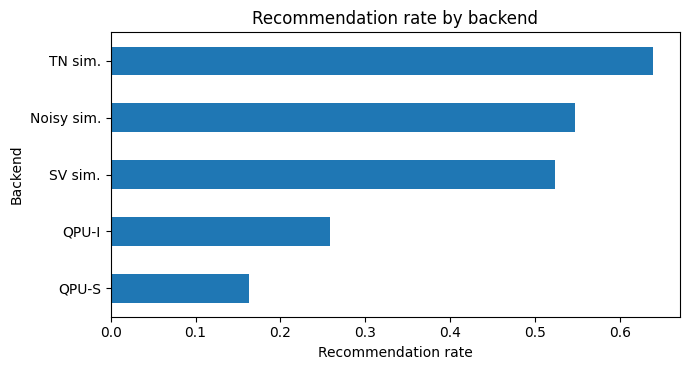

In [23]:
backend_labels = {
    "tensor_network_sim": "TN sim.",
    "noisy_sim": "Noisy sim.",
    "statevector_sim": "SV sim.",
    "qpu_cloud_superconducting": "QPU-S",
    "qpu_cloud_iontrap": "QPU-I",
}

recommendation_rate = (
    bias_backend["recommendation_rate"]
    .rename(index=backend_labels)
    .reindex([
        "QPU-S",
        "QPU-I",
        "SV sim.",
        "Noisy sim.",
        "TN sim.",
    ])
)
plt.figure(figsize=(7, 3.8))
recommendation_rate.plot(kind="barh")

plt.xlabel("Recommendation rate")
plt.ylabel("Backend")
plt.title("Recommendation rate by backend")

plt.tight_layout()
plt.savefig(
    FIG_DIR / "recommendation_rate_by_backend.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()


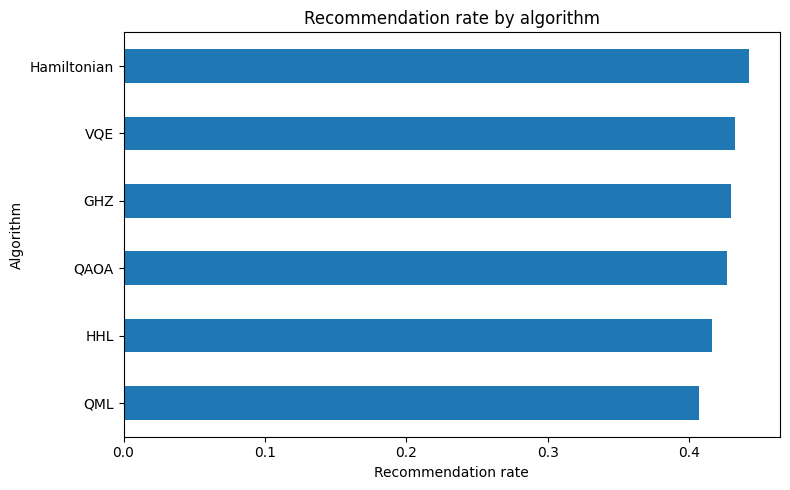

In [24]:
plt.figure(figsize=(8, 5))
bias_algorithm["recommendation_rate"].sort_values().plot(kind="barh")
plt.xlabel("Recommendation rate")
plt.ylabel("Algorithm")
plt.title("Recommendation rate by algorithm")
plt.tight_layout()
plt.savefig(FIG_DIR / "recommendation_rate_by_algorithm.png", dpi=300)
plt.show()
plt.close()



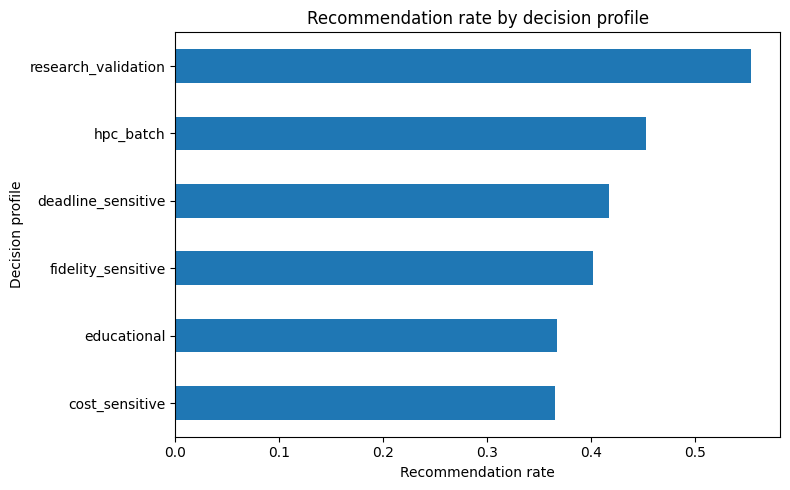

In [25]:
plt.figure(figsize=(8, 5))
bias_profile["recommendation_rate"].sort_values().plot(kind="barh")
plt.xlabel("Recommendation rate")
plt.ylabel("Decision profile")
plt.title("Recommendation rate by decision profile")
plt.tight_layout()
plt.savefig(FIG_DIR / "recommendation_rate_by_decision_profile.png", dpi=300)
plt.show()
plt.close()



## 8.1 Final backend selection diagnostics



In [26]:
selected_backend_by_backend = df.groupby("backend").agg(
    selection_rate=("selected_backend", "mean"),
    mean_rank=("backend_rank_true", "mean"),
    utility_rank_mean=("backend_rank_utility", "mean"),
    recommendation_rate=("recommended_execution", "mean"),
    avg_decision_utility=("decision_utility", "mean"),
    fallback_selection_rate=("selection_fallback", "mean"),
).sort_values("selection_rate", ascending=False)

selected_backend_by_profile = (
    df[df["selected_backend"] == 1]
    .groupby("decision_profile")["backend"]
    .value_counts(normalize=True)
    .rename("selection_share")
    .reset_index()
)

selected_backend_diagnostics = pd.DataFrame({
    "metric": [
        "workloads_total",
        "workloads_with_at_least_one_acceptable_backend",
        "workloads_without_acceptable_backend",
        "selected_backend_is_acceptable_rate",
        "fallback_selection_count",
    ],
    "value": [
        df["workload_id"].nunique(),
        int(df.groupby("workload_id")["recommended_execution"].sum().gt(0).sum()),
        int(df.groupby("workload_id")["recommended_execution"].sum().eq(0).sum()),
        df.loc[df["selected_backend"] == 1, "recommended_execution"].mean(),
        int(df["selection_fallback"].sum()),
    ],
})

selected_backend_by_backend.to_csv(TAB_DIR / "selected_backend_by_backend.csv")
selected_backend_by_profile.to_csv(TAB_DIR / "selected_backend_by_profile.csv", index=False)
selected_backend_diagnostics.to_csv(TAB_DIR / "selected_backend_diagnostics.csv", index=False)

display(selected_backend_diagnostics)
selected_backend_by_backend



,metric,value
0,workloads_total,700.000000
1,workloads_with_at_least_one_acceptable_backend,662.000000
2,workloads_without_acceptable_backend,38.000000
3,selected_backend_is_acceptable_rate,0.945714
4,fallback_selection_count,38.000000


,selection_rate,mean_rank,utility_rank_mean,recommendation_rate,avg_decision_utility,fallback_selection_rate
backend,,,,,,
tensor_network_sim,0.385714,2.090000,2.037143,0.638571,0.844992,0.018571
statevector_sim,0.240000,2.530000,2.500000,0.522857,0.810630,0.018571
noisy_sim,0.188571,2.521429,2.534286,0.547143,0.821191,0.011429
qpu_cloud_iontrap,0.165714,3.610000,3.652857,0.258571,0.647135,0.004286
qpu_cloud_superconducting,0.020000,4.248571,4.275714,0.162857,0.554950,0.001429


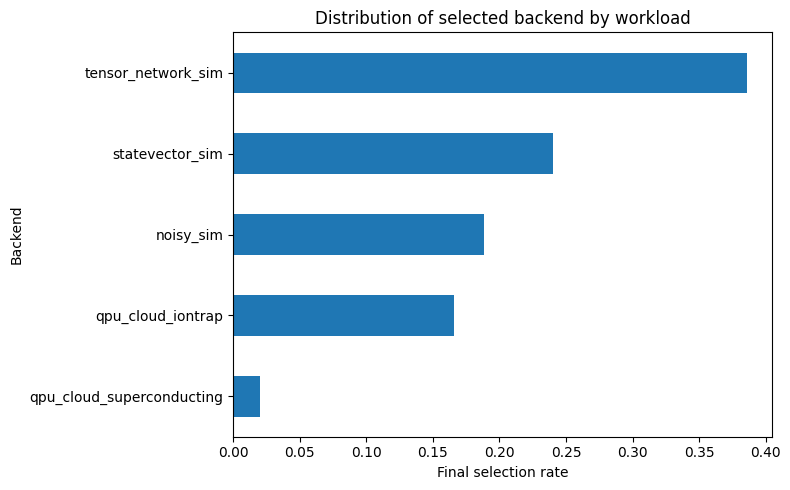

In [27]:
plt.figure(figsize=(8, 5))
selected_backend_by_backend["selection_rate"].sort_values().plot(kind="barh")
plt.xlabel("Final selection rate")
plt.ylabel("Backend")
plt.title("Distribution of selected backend by workload")
plt.tight_layout()
plt.savefig(FIG_DIR / "selected_backend_rate_by_backend.png", dpi=300)
plt.show()
plt.close()


## 9. Exploratory analysis of operational targets



In [28]:
summary_backend = df.groupby("backend").agg(
    avg_total_runtime_sec=("total_runtime_sec", "mean"),
    median_total_runtime_sec=("total_runtime_sec", "median"),
    avg_expected_fidelity=("expected_fidelity", "mean"),
    avg_failure_probability=("failure_probability", "mean"),
    avg_total_cost=("total_cost", "mean"),
    avg_decision_utility=("decision_utility", "mean"),
    recommendation_rate=("recommended_execution", "mean"),
).sort_values("avg_decision_utility", ascending=False)

summary_algorithm = df.groupby("algorithm").agg(
    avg_total_runtime_sec=("total_runtime_sec", "mean"),
    avg_expected_fidelity=("expected_fidelity", "mean"),
    avg_failure_probability=("failure_probability", "mean"),
    avg_decision_utility=("decision_utility", "mean"),
    recommendation_rate=("recommended_execution", "mean"),
).sort_values("avg_decision_utility", ascending=False)

summary_backend.to_csv(TAB_DIR / "summary_backend.csv")
summary_algorithm.to_csv(TAB_DIR / "summary_algorithm.csv")

summary_backend



,avg_total_runtime_sec,median_total_runtime_sec,avg_expected_fidelity,avg_failure_probability,avg_total_cost,avg_decision_utility,recommendation_rate
backend,,,,,,,
tensor_network_sim,76.694886,66.921810,0.919772,0.025714,0.093018,0.844992,0.638571
noisy_sim,91.567785,83.332919,0.885091,0.032432,0.141603,0.821191,0.547143
statevector_sim,147.493056,125.446157,0.932531,0.029700,0.038571,0.810630,0.522857
qpu_cloud_iontrap,482.589653,444.960773,0.837083,0.132391,3.324053,0.647135,0.258571
qpu_cloud_superconducting,1201.517668,1009.692033,0.511164,0.256980,2.202027,0.554950,0.162857


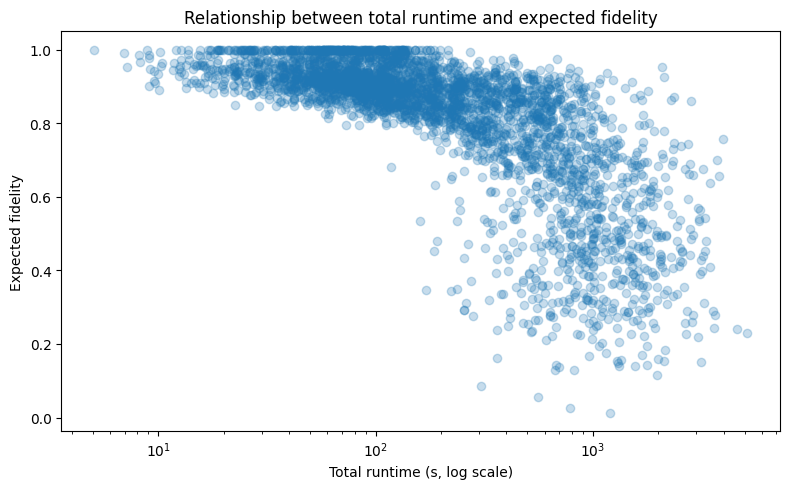

In [29]:
plt.figure(figsize=(8, 5))
plt.scatter(df["total_runtime_sec"], df["expected_fidelity"], alpha=0.25)
plt.xscale("log")
plt.xlabel("Total runtime (s, log scale)")
plt.ylabel("Expected fidelity")
plt.title("Relationship between total runtime and expected fidelity")
plt.tight_layout()
plt.savefig(FIG_DIR / "runtime_vs_fidelity.png", dpi=300)
plt.show()
plt.close()



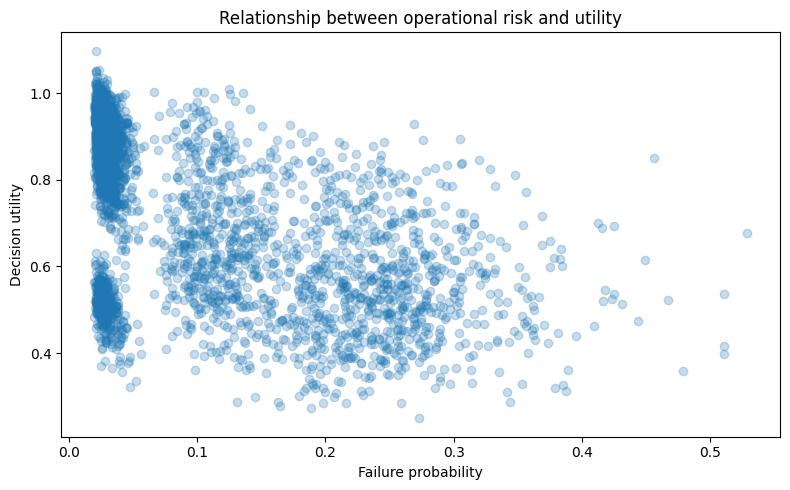

In [30]:
plt.figure(figsize=(8, 5))
plt.scatter(df["failure_probability"], df["decision_utility"], alpha=0.25)
plt.xlabel("Failure probability")
plt.ylabel("Decision utility")
plt.title("Relationship between operational risk and utility")
plt.tight_layout()
plt.savefig(FIG_DIR / "failure_vs_utility.png", dpi=300)
plt.show()
plt.close()



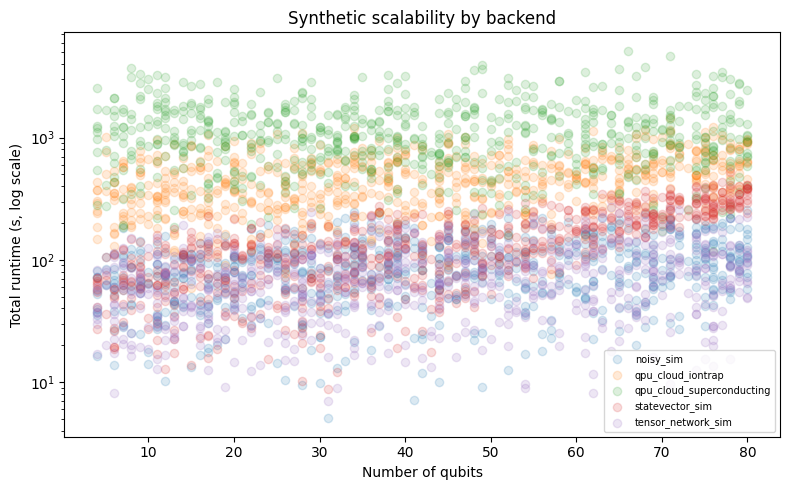

In [31]:
plt.figure(figsize=(8, 5))
for backend_name, group in df.groupby("backend"):
    plt.scatter(group["num_qubits"], group["total_runtime_sec"], alpha=0.16, label=backend_name)
plt.yscale("log")
plt.xlabel("Number of qubits")
plt.ylabel("Total runtime (s, log scale)")
plt.title("Synthetic scalability by backend")
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR / "runtime_by_qubits_backend.png", dpi=300)
plt.show()
plt.close()



## 10. Modeling preparation with workload-level split



### 10.1 Experimental leakage control

The train/test split is performed by `workload_id`. This prevents the same workload from appearing in both training and testing through different candidate backends.



In [32]:
base_features = [
    "algorithm", "algorithm_family", "decision_profile",
    "backend", "backend_family", "native_strength",
    "num_qubits", "circuit_depth", "two_qubit_gates", "shots",
    "entanglement_score", "noise_sensitivity",
    "scientific_priority", "requires_real_hardware", "validation_need",
    "deadline_hours", "budget_usd",
    "calibration_age_hours", "queue_depth", "backend_uptime",
    "single_qubit_error", "two_qubit_error", "readout_error",
    "coupling_density", "transpilation_overhead", "communication_latency_sec",
    "qubit_pressure", "capacity_penalty", "queue_time_sec", "total_cost",
    "failure_probability", "hardware_validation_value",
]

classifier_features = base_features + ["expected_fidelity", "total_runtime_sec"]

categorical_features = [c for c in base_features if df[c].dtype == "object"]
numeric_features = [c for c in base_features if c not in categorical_features]

categorical_features_clf = [c for c in classifier_features if df[c].dtype == "object"]
numeric_features_clf = [c for c in classifier_features if c not in categorical_features_clf]

preprocess_reg = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", StandardScaler(), numeric_features),
])

preprocess_clf = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_clf),
    ("num", StandardScaler(), numeric_features_clf),
])

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, test_idx = next(gss.split(df, df["recommended_execution"], groups=df["workload_id"]))

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print("Training rows:", train_df.shape[0])
print("Test rows:", test_df.shape[0])
print("Workloads in training:", train_df["workload_id"].nunique())
print("Workloads in test:", test_df["workload_id"].nunique())
print("Workload intersection:", len(set(train_df["workload_id"]) & set(test_df["workload_id"])))



Training rows: 2800
Test rows: 700
Workloads in training: 560
Workloads in test: 140
Workload intersection: 0


## 11. Regression for total runtime



### 11.0 Interpretation of regression metrics

MAE and RMSE quantify prediction error in seconds, while R² measures explained variance.



In [33]:
X_train_reg = train_df[base_features]
X_test_reg = test_df[base_features]
y_train_runtime = train_df["total_runtime_sec"]
y_test_runtime = test_df["total_runtime_sec"]

runtime_model = Pipeline([
    ("prep", preprocess_reg),
    ("model", RandomForestRegressor(
        n_estimators=50,
        random_state=SEED,
        min_samples_leaf=3,
        n_jobs=1,
    )),
])

runtime_model.fit(X_train_reg, y_train_runtime)
y_pred_runtime = runtime_model.predict(X_test_reg)

runtime_metrics = {
    "model": "RandomForestRegressor",
    "target": "total_runtime_sec",
    "evaluation": "holdout_group_split",
    "MAE": mean_absolute_error(y_test_runtime, y_pred_runtime),
    "RMSE": mean_squared_error(y_test_runtime, y_pred_runtime) ** 0.5,
    "R2": r2_score(y_test_runtime, y_pred_runtime),
}
runtime_metrics



{'model': 'RandomForestRegressor',
 'target': 'total_runtime_sec',
 'evaluation': 'holdout_group_split',
 'MAE': 31.627512099206122,
 'RMSE': 47.434889874391764,
 'R2': 0.9929812387956964}

In [34]:
runtime_baselines = []
for strategy in ["mean", "median"]:
    dummy = DummyRegressor(strategy=strategy)
    dummy.fit(X_train_reg, y_train_runtime)
    pred = dummy.predict(X_test_reg)
    runtime_baselines.append({
        "model": f"DummyRegressor_{strategy}",
        "target": "total_runtime_sec",
        "MAE": mean_absolute_error(y_test_runtime, pred),
        "RMSE": mean_squared_error(y_test_runtime, pred) ** 0.5,
        "R2": r2_score(y_test_runtime, pred),
    })

pd.DataFrame([runtime_metrics] + runtime_baselines)



,model,target,evaluation,MAE,RMSE,R2
0,RandomForestRegressor,total_runtime_sec,holdout_group_split,31.627512,47.434890,0.992981
1,DummyRegressor_mean,total_runtime_sec,NaN,380.689778,566.269818,-0.000257
2,DummyRegressor_median,total_runtime_sec,NaN,325.867058,618.090606,-0.191706


## 11.1 Comparison with other runtime regressors



In [35]:
runtime_regressors = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Elastic Net": ElasticNet(alpha=0.001, l1_ratio=0.20, max_iter=5000, random_state=SEED),
    "SGD Regressor": SGDRegressor(max_iter=1000, tol=1e-3, random_state=SEED),
    "Decision Tree": DecisionTreeRegressor(random_state=SEED, min_samples_leaf=8),
    "Extra Trees": ExtraTreesRegressor(n_estimators=50, random_state=SEED, min_samples_leaf=3, n_jobs=1),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=SEED, min_samples_leaf=3, n_jobs=1),
}

runtime_model_comparison = []
for name, model in runtime_regressors.items():
    pipe = Pipeline([
        ("prep", preprocess_reg),
        ("model", model),
    ])
    pipe.fit(X_train_reg, y_train_runtime)
    pred = pipe.predict(X_test_reg)
    runtime_model_comparison.append({
        "model": name,
        "target": "total_runtime_sec",
        "MAE": mean_absolute_error(y_test_runtime, pred),
        "RMSE": mean_squared_error(y_test_runtime, pred) ** 0.5,
        "R2": r2_score(y_test_runtime, pred),
    })

runtime_model_comparison_df = pd.DataFrame(runtime_model_comparison).sort_values("RMSE", ascending=True)
runtime_model_comparison_df.to_csv(TAB_DIR / "runtime_regressor_model_comparison.csv", index=False)
runtime_model_comparison_df


,model,target,MAE,RMSE,R2
4,Extra Trees,total_runtime_sec,29.320613,44.218758,0.993901
0,Ridge Regression,total_runtime_sec,31.999266,45.953349,0.993413
1,Elastic Net,total_runtime_sec,32.060194,46.024995,0.993392
2,SGD Regressor,total_runtime_sec,32.712947,46.759024,0.993180
5,Random Forest,total_runtime_sec,31.627512,47.434890,0.992981
3,Decision Tree,total_runtime_sec,42.767300,64.873498,0.986872


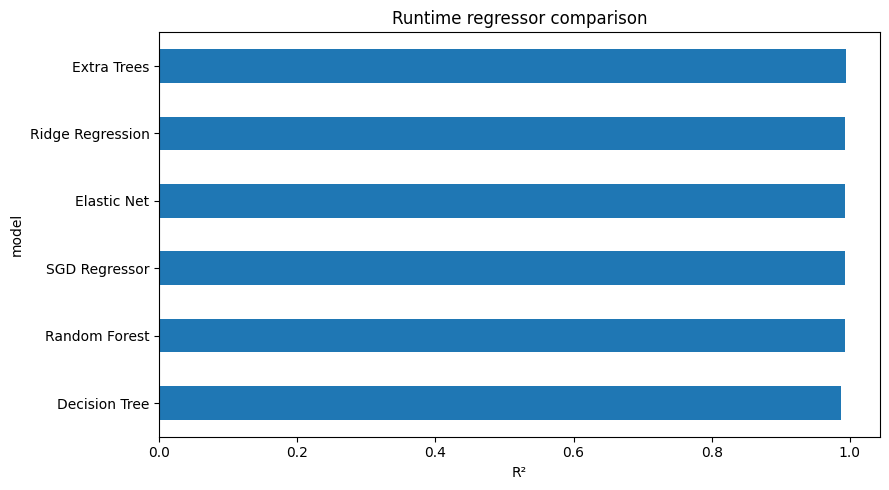

In [36]:
plt.figure(figsize=(9, 5))
runtime_model_comparison_df.set_index("model")["R2"].sort_values().plot(kind="barh")
plt.xlabel("R²")
plt.title("Runtime regressor comparison")
plt.tight_layout()
plt.savefig(FIG_DIR / "runtime_regressor_model_comparison.png", dpi=180)
plt.show()
plt.close()


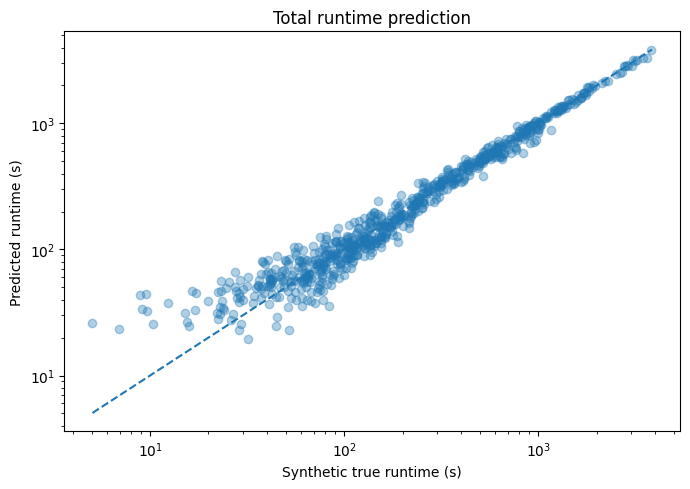

In [37]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_runtime, y_pred_runtime, alpha=0.35)
min_v = min(y_test_runtime.min(), y_pred_runtime.min())
max_v = max(y_test_runtime.max(), y_pred_runtime.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Synthetic true runtime (s)")
plt.ylabel("Predicted runtime (s)")
plt.title("Total runtime prediction")
plt.tight_layout()
plt.savefig(FIG_DIR / "runtime_prediction.png", dpi=300)
plt.show()
plt.close()



## 12. Regression for expected fidelity



In [38]:
y_train_fidelity = train_df["expected_fidelity"]
y_test_fidelity = test_df["expected_fidelity"]

fidelity_model = Pipeline([
    ("prep", preprocess_reg),
    ("model", RandomForestRegressor(
        n_estimators=50,
        random_state=SEED,
        min_samples_leaf=3,
        n_jobs=1,
    )),
])

fidelity_model.fit(X_train_reg, y_train_fidelity)
y_pred_fidelity = fidelity_model.predict(X_test_reg).clip(0, 1)

fidelity_metrics = {
    "model": "RandomForestRegressor",
    "target": "expected_fidelity",
    "evaluation": "holdout_group_split",
    "MAE": mean_absolute_error(y_test_fidelity, y_pred_fidelity),
    "RMSE": mean_squared_error(y_test_fidelity, y_pred_fidelity) ** 0.5,
    "R2": r2_score(y_test_fidelity, y_pred_fidelity),
}
fidelity_metrics



{'model': 'RandomForestRegressor',
 'target': 'expected_fidelity',
 'evaluation': 'holdout_group_split',
 'MAE': 0.028509006750914702,
 'RMSE': 0.04160064843577663,
 'R2': 0.9524285094500389}

In [39]:
fidelity_baselines = []
for strategy in ["mean", "median"]:
    dummy = DummyRegressor(strategy=strategy)
    dummy.fit(X_train_reg, y_train_fidelity)
    pred = dummy.predict(X_test_reg)
    fidelity_baselines.append({
        "model": f"DummyRegressor_{strategy}",
        "target": "expected_fidelity",
        "MAE": mean_absolute_error(y_test_fidelity, pred),
        "RMSE": mean_squared_error(y_test_fidelity, pred) ** 0.5,
        "R2": r2_score(y_test_fidelity, pred),
    })

pd.DataFrame([fidelity_metrics] + fidelity_baselines)



,model,target,evaluation,MAE,RMSE,R2
0,RandomForestRegressor,expected_fidelity,holdout_group_split,0.028509,0.041601,0.952429
1,DummyRegressor_mean,expected_fidelity,NaN,0.138726,0.190913,-0.001887
2,DummyRegressor_median,expected_fidelity,NaN,0.126592,0.204817,-0.153130


## 12.1 Comparison with other expected-fidelity regressors



In [40]:
fidelity_regressors = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Elastic Net": ElasticNet(alpha=0.001, l1_ratio=0.20, max_iter=5000, random_state=SEED),
    "SGD Regressor": SGDRegressor(max_iter=1000, tol=1e-3, random_state=SEED),
    "Decision Tree": DecisionTreeRegressor(random_state=SEED, min_samples_leaf=8),
    "Extra Trees": ExtraTreesRegressor(n_estimators=50, random_state=SEED, min_samples_leaf=3, n_jobs=1),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=SEED, min_samples_leaf=3, n_jobs=1),
}

fidelity_model_comparison = []
for name, model in fidelity_regressors.items():
    pipe = Pipeline([
        ("prep", preprocess_reg),
        ("model", model),
    ])
    pipe.fit(X_train_reg, y_train_fidelity)
    pred = pipe.predict(X_test_reg).clip(0, 1)
    fidelity_model_comparison.append({
        "model": name,
        "target": "expected_fidelity",
        "MAE": mean_absolute_error(y_test_fidelity, pred),
        "RMSE": mean_squared_error(y_test_fidelity, pred) ** 0.5,
        "R2": r2_score(y_test_fidelity, pred),
    })

fidelity_model_comparison_df = pd.DataFrame(fidelity_model_comparison).sort_values("RMSE", ascending=True)
fidelity_model_comparison_df.to_csv(TAB_DIR / "fidelity_regressor_model_comparison.csv", index=False)
fidelity_model_comparison_df


,model,target,MAE,RMSE,R2
4,Extra Trees,expected_fidelity,0.028327,0.040907,0.954002
5,Random Forest,expected_fidelity,0.028509,0.041601,0.952429
3,Decision Tree,expected_fidelity,0.033142,0.049538,0.932542
0,Ridge Regression,expected_fidelity,0.047602,0.070934,0.861689
1,Elastic Net,expected_fidelity,0.047818,0.071994,0.857524
2,SGD Regressor,expected_fidelity,0.048558,0.073550,0.851298


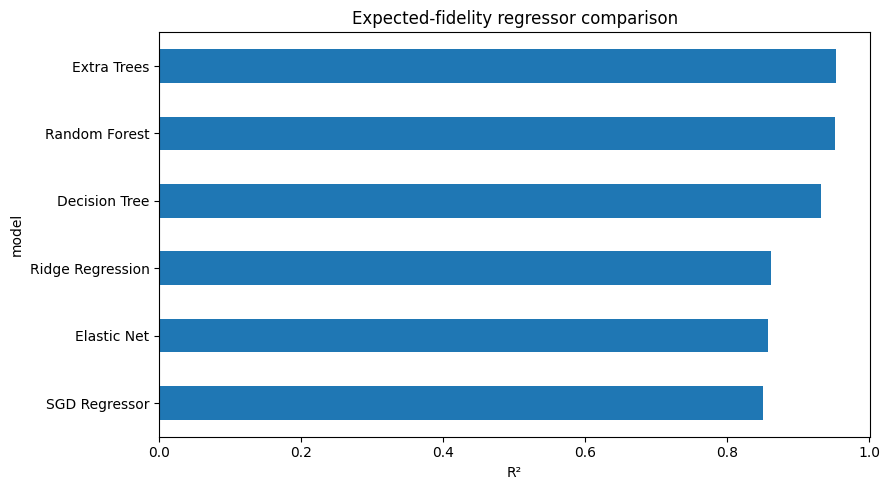

In [41]:
plt.figure(figsize=(9, 5))
fidelity_model_comparison_df.set_index("model")["R2"].sort_values().plot(kind="barh")
plt.xlabel("R²")
plt.title("Expected-fidelity regressor comparison")
plt.tight_layout()
plt.savefig(FIG_DIR / "fidelity_regressor_model_comparison.png", dpi=180)
plt.show()
plt.close()


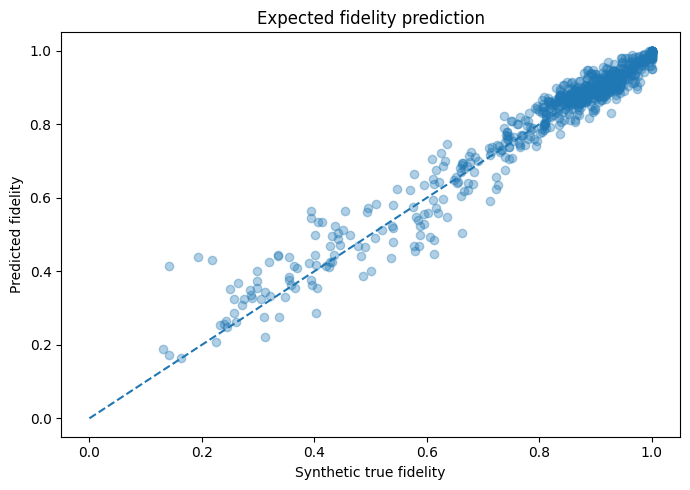

In [42]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_fidelity, y_pred_fidelity, alpha=0.35)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Synthetic true fidelity")
plt.ylabel("Predicted fidelity")
plt.title("Expected fidelity prediction")
plt.tight_layout()
plt.savefig(FIG_DIR / "fidelity_prediction.png", dpi=300)
plt.show()
plt.close()



## 13. Execution recommendation classification



### 13.0 Interpretation of classification metrics

Accuracy, precision, recall, and F1 summarize the ability to reproduce the synthetic recommendation policy.



**Interpretation boundary.** These scores quantify **internal policy recoverability** within the controlled synthetic benchmark. They do not estimate deployment accuracy on production QPUs and must not be interpreted as real-hardware predictive performance.


In [43]:
X_train_clf = train_df[classifier_features]
X_test_clf = test_df[classifier_features]
y_train_clf = train_df["recommended_execution"]
y_test_clf = test_df["recommended_execution"]

clf_model = Pipeline([
    ("prep", preprocess_clf),
    ("model", RandomForestClassifier(
        n_estimators=50,
        random_state=SEED,
        class_weight="balanced",
        min_samples_leaf=3,
        n_jobs=1,
    )),
])

clf_model.fit(X_train_clf, y_train_clf)
y_pred_clf = clf_model.predict(X_test_clf)
y_prob_clf = clf_model.predict_proba(X_test_clf)[:, 1]

clf_metrics = {
    "model": "RandomForestClassifier",
    "task": "acceptable_backend_classification",
    "evaluation": "holdout_observed_runtime_fidelity",
    "Accuracy": accuracy_score(y_test_clf, y_pred_clf),
    "Precision": precision_score(y_test_clf, y_pred_clf, zero_division=0),
    "Recall": recall_score(y_test_clf, y_pred_clf, zero_division=0),
    "F1": f1_score(y_test_clf, y_pred_clf, zero_division=0),
}
clf_metrics



{'model': 'RandomForestClassifier',
 'task': 'acceptable_backend_classification',
 'evaluation': 'holdout_observed_runtime_fidelity',
 'Accuracy': 0.6714285714285714,
 'Precision': 0.5799457994579946,
 'Recall': 0.740484429065744,
 'F1': 0.6504559270516718}

                 precision    recall  f1-score   support

not recommended       0.77      0.62      0.69       411
    recommended       0.58      0.74      0.65       289

       accuracy                           0.67       700
      macro avg       0.68      0.68      0.67       700
   weighted avg       0.69      0.67      0.67       700



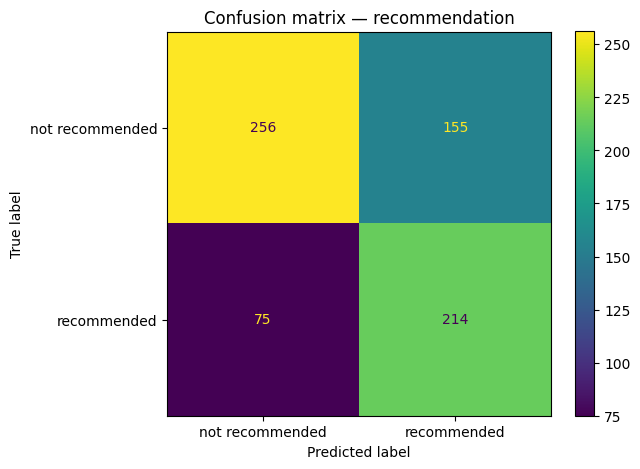

In [44]:
print(classification_report(y_test_clf, y_pred_clf, target_names=["not recommended", "recommended"], zero_division=0))

cm = confusion_matrix(y_test_clf, y_pred_clf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["not recommended", "recommended"])
disp.plot(values_format="d")
plt.title("Confusion matrix — recommendation")
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix_recommendation.png", dpi=300)
plt.show()
plt.close()



## 14. Comparison with baselines



In [45]:
classification_baselines = []

for strategy in ["most_frequent", "stratified"]:
    dummy = DummyClassifier(strategy=strategy, random_state=SEED)
    dummy.fit(X_train_clf, y_train_clf)
    pred = dummy.predict(X_test_clf)
    classification_baselines.append({
        "model": f"DummyClassifier_{strategy}",
        "Accuracy": accuracy_score(y_test_clf, pred),
        "Precision": precision_score(y_test_clf, pred, zero_division=0),
        "Recall": recall_score(y_test_clf, pred, zero_division=0),
        "F1": f1_score(y_test_clf, pred, zero_division=0),
    })

heuristic_pred = np.where(
    (test_df["expected_fidelity"] >= test_df["expected_fidelity"].quantile(0.55))
    & (test_df["total_runtime_sec"] <= test_df["total_runtime_sec"].quantile(0.60))
    & (test_df["failure_probability"] <= test_df["failure_probability"].quantile(0.70))
    & (test_df["backend_uptime"] >= 0.60),
    1,
    0,
)
classification_baselines.append({
    "model": "heuristic_fidelity_time_failure",
    "Accuracy": accuracy_score(y_test_clf, heuristic_pred),
    "Precision": precision_score(y_test_clf, heuristic_pred, zero_division=0),
    "Recall": recall_score(y_test_clf, heuristic_pred, zero_division=0),
    "F1": f1_score(y_test_clf, heuristic_pred, zero_division=0),
})

baseline_results = pd.DataFrame([clf_metrics] + classification_baselines)
baseline_results.to_csv(TAB_DIR / "classification_baselines.csv", index=False)
baseline_results



,model,task,evaluation,Accuracy,Precision,Recall,F1
0,RandomForestClassifier,acceptable_backend_classification,holdout_observed_runtime_fidelity,0.671429,0.579946,0.740484,0.650456
1,DummyClassifier_most_frequent,NaN,NaN,0.587143,0.000000,0.000000,0.000000
2,DummyClassifier_stratified,NaN,NaN,0.490000,0.385906,0.397924,0.391823
3,heuristic_fidelity_time_failure,NaN,NaN,0.622857,0.544484,0.529412,0.536842


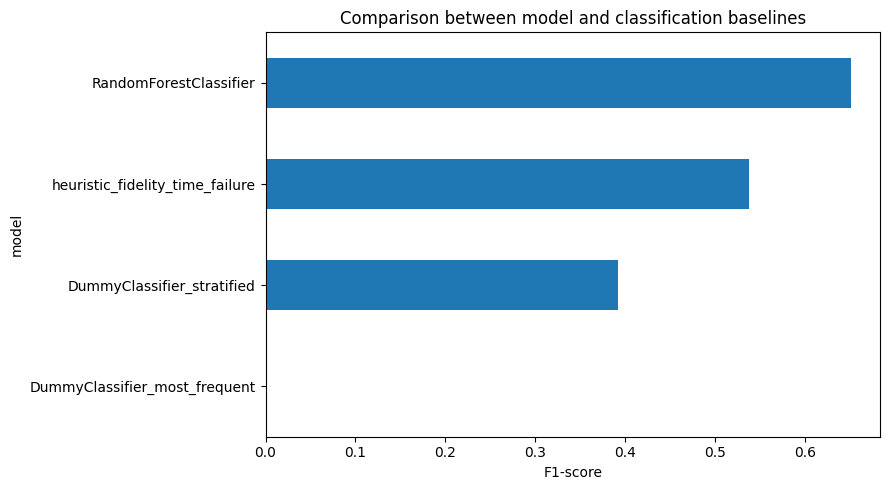

In [46]:
plt.figure(figsize=(9, 5))
baseline_results.set_index("model")["F1"].sort_values().plot(kind="barh")
plt.xlabel("F1-score")
plt.title("Comparison between model and classification baselines")
plt.tight_layout()
plt.savefig(FIG_DIR / "classification_baseline_comparison.png", dpi=300)
plt.show()
plt.close()



## 15. Classifier comparison with observed synthetic performance variables — diagnostic only

This section is retained as an **isolated/oracle diagnostic**. The classifier receives the observed synthetic `expected_fidelity` and `total_runtime_sec` variables during training and testing. These results are useful for measuring recoverability when intermediate targets are available, but they are **not the primary OOF sequential recommendation estimates**. The reportable OOF analysis begins in Section 23.


In [47]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1200, class_weight="balanced"),
    "SGD Logistic": SGDClassifier(loss="log_loss", max_iter=1000, tol=1e-3, class_weight="balanced", random_state=SEED),
    "Linear SVM": LinearSVC(class_weight="balanced", max_iter=3000, dual=False, random_state=SEED),
    "Decision Tree": DecisionTreeClassifier(random_state=SEED, class_weight="balanced", min_samples_leaf=8),
    "AdaBoost": AdaBoostClassifier(n_estimators=60, random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=50,
        random_state=SEED,
        class_weight="balanced",
        min_samples_leaf=3,
        n_jobs=1,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        random_state=SEED,
        class_weight="balanced",
        min_samples_leaf=3,
        n_jobs=1,
    ),
}

model_comparison = []
for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocess_clf),
        ("model", model),
    ])
    pipe.fit(X_train_clf, y_train_clf)
    pred = pipe.predict(X_test_clf)
    model_comparison.append({
        "model": name,
        "Accuracy": accuracy_score(y_test_clf, pred),
        "Precision": precision_score(y_test_clf, pred, zero_division=0),
        "Recall": recall_score(y_test_clf, pred, zero_division=0),
        "F1": f1_score(y_test_clf, pred, zero_division=0),
    })

model_comparison_df = pd.DataFrame(model_comparison).sort_values("F1", ascending=False)
model_comparison_df.to_csv(TAB_DIR / "classifier_oracle_observed_model_comparison_diagnostic.csv", index=False)
model_comparison_df


,model,Accuracy,Precision,Recall,F1
6,Extra Trees,0.687143,0.590206,0.792388,0.676514
2,Linear SVM,0.664286,0.564904,0.813149,0.666667
5,Gradient Boosting,0.695714,0.611111,0.723183,0.662441
0,Logistic Regression,0.661429,0.563415,0.799308,0.660944
7,Random Forest,0.671429,0.579946,0.740484,0.650456
3,Decision Tree,0.677143,0.596330,0.674740,0.633117
4,AdaBoost,0.632857,0.548193,0.629758,0.586151
1,SGD Logistic,0.624286,0.542484,0.574394,0.557983


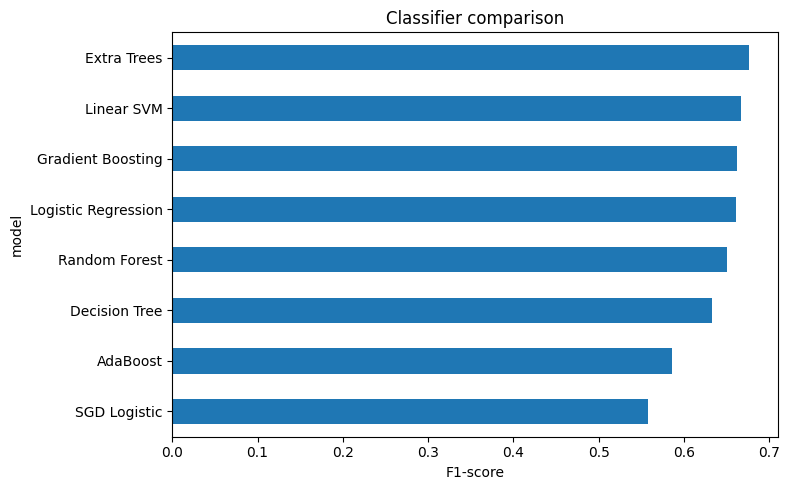

In [48]:
plt.figure(figsize=(8, 5))
model_comparison_df.set_index("model")["F1"].sort_values().plot(kind="barh")
plt.xlabel("F1-score")
plt.title("Classifier comparison")
plt.tight_layout()
plt.savefig(FIG_DIR / "classifier_model_comparison.png", dpi=300)
plt.show()
plt.close()



## 15.1 Runtime/fidelity substitution diagnostic — classifier trained on observed targets

This diagnostic replaces runtime and fidelity with model predictions **only at test time**, while the classifier was trained using observed synthetic runtime/fidelity. It therefore measures a train/test information shift and must not be described as the final end-to-end estimate. Section 23 corrects this by using out-of-fold runtime/fidelity predictions in classifier training.


In [49]:
# Operational test set: replaces observed synthetic variables with predictions
X_test_clf_e2e = X_test_clf.copy()
X_test_clf_e2e["total_runtime_sec"] = y_pred_runtime
X_test_clf_e2e["expected_fidelity"] = y_pred_fidelity

y_pred_clf_e2e = clf_model.predict(X_test_clf_e2e)
y_prob_clf_e2e = clf_model.predict_proba(X_test_clf_e2e)[:, 1]

clf_metrics_e2e = {
    "model": "RandomForestClassifier_test_substitution_diagnostic",
    "task": "acceptable_backend_classification",
    "evaluation": "train_observed_test_predicted_runtime_fidelity_diagnostic",
    "Accuracy": accuracy_score(y_test_clf, y_pred_clf_e2e),
    "Precision": precision_score(y_test_clf, y_pred_clf_e2e, zero_division=0),
    "Recall": recall_score(y_test_clf, y_pred_clf_e2e, zero_division=0),
    "F1": f1_score(y_test_clf, y_pred_clf_e2e, zero_division=0),
}

clf_metrics_observed = {
    "model": "RandomForestClassifier_observed",
    "task": "acceptable_backend_classification",
    "evaluation": "isolated_observed_synthetic_runtime_fidelity",
    "Accuracy": clf_metrics["Accuracy"],
    "Precision": clf_metrics["Precision"],
    "Recall": clf_metrics["Recall"],
    "F1": clf_metrics["F1"],
}

classification_end_to_end_df = pd.DataFrame([clf_metrics_observed, clf_metrics_e2e])
classification_end_to_end_df.to_csv(TAB_DIR / "classification_runtime_fidelity_shift_diagnostic.csv", index=False)
classification_end_to_end_df


,model,task,evaluation,Accuracy,Precision,Recall,F1
0,RandomForestClassifier_observed,acceptable_backend_classification,isolated_observed_synthetic_runtime_fidelity,0.671429,0.579946,0.740484,0.650456
1,RandomForestClassifier_test_substitution_diagn...,acceptable_backend_classification,train_observed_test_predicted_runtime_fidelity...,0.682857,0.590786,0.754325,0.662614


### 15.2 Model-family comparison under the same substitution diagnostic

As in Section 15.1, these models are trained with observed synthetic runtime/fidelity and evaluated after substituting predicted values at test time. This table is diagnostic only; the reportable OOF model-family robustness comparison uses OOF training inputs in Section 23.6.4.


In [50]:
end_to_end_model_comparison = []
for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocess_clf),
        ("model", model),
    ])
    pipe.fit(X_train_clf, y_train_clf)
    pred = pipe.predict(X_test_clf_e2e)
    end_to_end_model_comparison.append({
        "model": name,
        "evaluation": "train_observed_test_predicted_runtime_fidelity_diagnostic",
        "Accuracy": accuracy_score(y_test_clf, pred),
        "Precision": precision_score(y_test_clf, pred, zero_division=0),
        "Recall": recall_score(y_test_clf, pred, zero_division=0),
        "F1": f1_score(y_test_clf, pred, zero_division=0),
    })

end_to_end_model_comparison_df = pd.DataFrame(end_to_end_model_comparison).sort_values("F1", ascending=False)
end_to_end_model_comparison_df.to_csv(TAB_DIR / "classifier_runtime_fidelity_shift_model_comparison_diagnostic.csv", index=False)
end_to_end_model_comparison_df


,model,evaluation,Accuracy,Precision,Recall,F1
6,Extra Trees,train_observed_test_predicted_runtime_fidelity...,0.682857,0.586118,0.788927,0.672566
5,Gradient Boosting,train_observed_test_predicted_runtime_fidelity...,0.704286,0.619883,0.733564,0.671949
2,Linear SVM,train_observed_test_predicted_runtime_fidelity...,0.664286,0.564904,0.813149,0.666667
7,Random Forest,train_observed_test_predicted_runtime_fidelity...,0.682857,0.590786,0.754325,0.662614
0,Logistic Regression,train_observed_test_predicted_runtime_fidelity...,0.660000,0.562044,0.799308,0.660000
3,Decision Tree,train_observed_test_predicted_runtime_fidelity...,0.680000,0.600000,0.674740,0.635179
4,AdaBoost,train_observed_test_predicted_runtime_fidelity...,0.637143,0.552239,0.640138,0.592949
1,SGD Logistic,train_observed_test_predicted_runtime_fidelity...,0.625714,0.543974,0.577855,0.560403


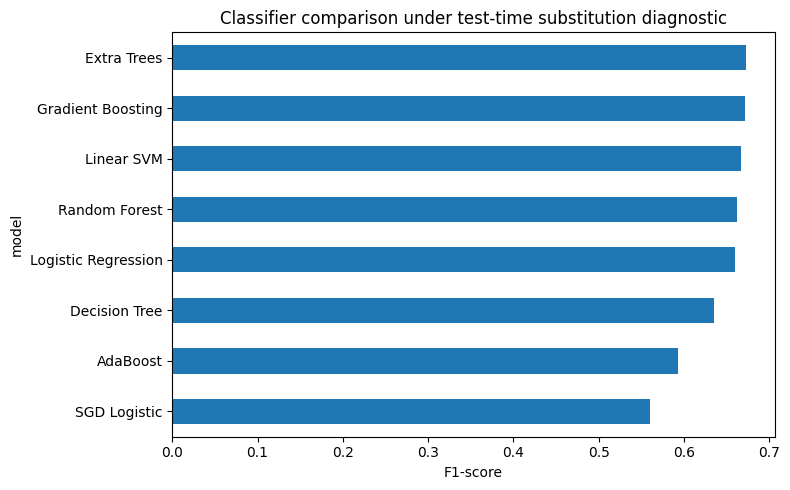

In [51]:
plt.figure(figsize=(8, 5))
end_to_end_model_comparison_df.set_index("model")["F1"].sort_values().plot(kind="barh")
plt.xlabel("F1-score")
plt.title("Classifier comparison under test-time substitution diagnostic")
plt.tight_layout()
plt.savefig(FIG_DIR / "classifier_runtime_fidelity_shift_model_comparison_diagnostic.png", dpi=300)
plt.show()
plt.close()


## 16. Feature importance



In [52]:
perm = permutation_importance(
    clf_model,
    X_test_clf,
    y_test_clf,
    scoring="f1",
    n_repeats=3,
    random_state=SEED,
    n_jobs=1,
    max_samples=0.5,
)

importance_df = pd.DataFrame({
    "feature": classifier_features,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

importance_df.to_csv(TAB_DIR / "feature_importance_permutation.csv", index=False)
importance_df.head(20)



,feature,importance_mean,importance_std
2,decision_profile,0.073711,0.014269
31,hardware_validation_value,0.019975,0.004383
23,coupling_density,0.013604,0.013797
13,requires_real_hardware,0.001371,0.005329
26,qubit_pressure,-0.000529,0.017342
32,expected_fidelity,-0.005052,0.008591
5,native_strength,-0.006089,0.007265
28,queue_time_sec,-0.007736,0.007526
25,communication_latency_sec,-0.008255,0.008239
33,total_runtime_sec,-0.008300,0.011641


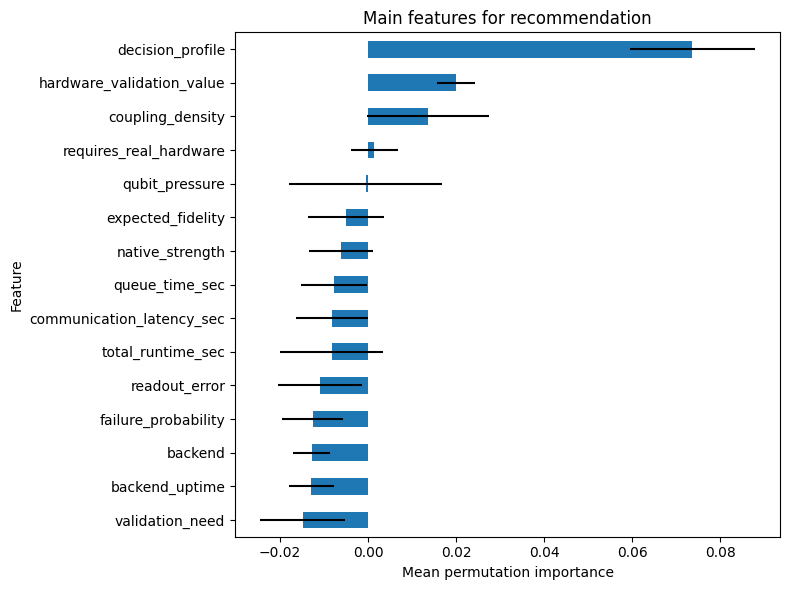

In [53]:
plt.figure(figsize=(8, 6))
importance_df.head(15).sort_values("importance_mean").plot(
    x="feature",
    y="importance_mean",
    kind="barh",
    legend=False,
    xerr="importance_std",
    ax=plt.gca(),
)
plt.xlabel("Mean permutation importance")
plt.ylabel("Feature")
plt.title("Main features for recommendation")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance.png", dpi=300)
plt.show()
plt.close()



## 16.1 Backend selection and ranking evaluation



### 16.1.0 Why evaluate ranking instead of classification only?

In operational orchestration, the main output is not only whether a backend is acceptable. The system must also choose one backend per workload. Ranking metrics evaluate whether the selected backend matches, or remains close to, the synthetic policy optimum.



In [54]:
def score_candidates_for_selection(candidate_df):
    """Legacy hold-out selector retained for diagnostics.

    The final score is explicitly policy-informed because it uses the synthetic w_* weights.
    Reportable OOF selection is recomputed in Section 23.1.
    """
    scored = candidate_df.copy()

    scored["predicted_total_runtime_sec"] = runtime_model.predict(scored[base_features])
    scored["predicted_fidelity"] = fidelity_model.predict(scored[base_features]).clip(0, 1)

    scored_for_clf = scored.copy()
    scored_for_clf["total_runtime_sec"] = scored["predicted_total_runtime_sec"]
    scored_for_clf["expected_fidelity"] = scored["predicted_fidelity"]

    scored["recommendation_probability"] = clf_model.predict_proba(scored_for_clf[classifier_features])[:, 1]
    scored = add_policy_informed_predicted_utility(
        scored,
        fidelity_col="predicted_fidelity",
        runtime_col="predicted_total_runtime_sec",
        score_col="policy_informed_predicted_utility",
    )

    scored = add_predicted_selection(
        scored,
        prob_col="recommendation_probability",
        score_col="policy_informed_predicted_utility",
        threshold=0.5,
    )
    return scored


selection_eval_df = score_candidates_for_selection(test_df)

true_selected = (
    selection_eval_df[selection_eval_df["selected_backend"] == 1]
    [["workload_id", "backend"]]
    .rename(columns={"backend": "true_backend"})
)

pred_selected = (
    selection_eval_df[selection_eval_df["predicted_selected_backend"] == 1]
    [["workload_id", "backend"]]
    .rename(columns={"backend": "predicted_backend"})
)

selection_pair_eval = true_selected.merge(pred_selected, on="workload_id", how="inner")
selection_pair_eval["top1_correct"] = selection_pair_eval["true_backend"].eq(selection_pair_eval["predicted_backend"])

rank_eval = selection_eval_df.merge(true_selected, on="workload_id", how="left")
rank_eval["is_true_backend"] = rank_eval["backend"].eq(rank_eval["true_backend"])

top1_accuracy = selection_pair_eval["top1_correct"].mean()
top2_accuracy = rank_eval.loc[rank_eval["predicted_backend_rank"] <= 2].groupby("workload_id")["is_true_backend"].max().mean()
top3_accuracy = rank_eval.loc[rank_eval["predicted_backend_rank"] <= 3].groupby("workload_id")["is_true_backend"].max().mean()

ranking_metrics = pd.DataFrame([{
    "Top-1 accuracy": top1_accuracy,
    "Top-2 accuracy": top2_accuracy,
    "Top-3 accuracy": top3_accuracy,
    "explicit_policy_weights_in_final_ranking": True,
    "predicted_fallback_rate": selection_eval_df.loc[selection_eval_df["predicted_selected_backend"] == 1, "predicted_selection_fallback"].mean(),
    "true_fallback_rate": selection_eval_df.loc[selection_eval_df["selected_backend"] == 1, "selection_fallback"].mean(),
}])

selection_confusion = pd.crosstab(
    selection_pair_eval["true_backend"],
    selection_pair_eval["predicted_backend"],
    rownames=["true_backend"],
    colnames=["predicted_backend"],
    normalize="index",
)

selection_distribution_comparison = (
    pd.concat([
        selection_pair_eval["true_backend"].value_counts(normalize=True).rename("true_selection_rate"),
        selection_pair_eval["predicted_backend"].value_counts(normalize=True).rename("predicted_selection_rate"),
    ], axis=1)
    .fillna(0)
)
selection_distribution_comparison["diff_pred_minus_true"] = (
    selection_distribution_comparison["predicted_selection_rate"]
    - selection_distribution_comparison["true_selection_rate"]
)

ranking_metrics.to_csv(TAB_DIR / "backend_ranking_metrics_holdout_policy_informed_diagnostic.csv", index=False)
selection_confusion.to_csv(TAB_DIR / "backend_selection_confusion_holdout_policy_informed_diagnostic.csv")
selection_distribution_comparison.to_csv(TAB_DIR / "selection_distribution_comparison_holdout_policy_informed_diagnostic.csv")

display(ranking_metrics)
display(selection_distribution_comparison)
selection_confusion


,Top-1 accuracy,Top-2 accuracy,Top-3 accuracy,explicit_policy_weights_in_final_ranking,predicted_fallback_rate,true_fallback_rate
0,0.535714,0.785714,0.95,True,0.007143,0.064286


,true_selection_rate,predicted_selection_rate,diff_pred_minus_true
tensor_network_sim,0.321429,0.471429,0.150000
statevector_sim,0.278571,0.371429,0.092857
qpu_cloud_iontrap,0.200000,0.128571,-0.071429
noisy_sim,0.192857,0.014286,-0.178571
qpu_cloud_superconducting,0.007143,0.014286,0.007143


predicted_backend,noisy_sim,qpu_cloud_iontrap,qpu_cloud_superconducting,statevector_sim,tensor_network_sim
true_backend,,,,,
noisy_sim,0.000000,0.000000,0.000000,0.333333,0.666667
qpu_cloud_iontrap,0.000000,0.642857,0.071429,0.107143,0.178571
qpu_cloud_superconducting,0.000000,0.000000,0.000000,1.000000,0.000000
statevector_sim,0.025641,0.000000,0.000000,0.666667,0.307692
tensor_network_sim,0.022222,0.000000,0.000000,0.288889,0.688889


## 17. Backend recommendation function



In [55]:
def build_candidate_pairs_realistic(workload, random_seed=2026):
    """Combines one workload with all backends and generates the current operational state."""
    workload_df = pd.DataFrame([workload])
    workload_df = workload_df.merge(algorithm_profiles, on="algorithm", how="left")
    workload_df = workload_df.merge(decision_profiles, on="decision_profile", how="left")

    if "validation_need" not in workload_df.columns:
        workload_df["validation_need"] = (
            0.55 * workload_df["requires_real_hardware"]
            + 0.45 * workload_df["scientific_priority"]
        ).clip(0, 1)

    candidates = workload_df.merge(backend_catalog, how="cross")
    candidates = add_backend_state(candidates, random_seed=random_seed)
    candidates = simulate_operational_outcomes(candidates, random_seed=random_seed, generate_label=False)
    return candidates



def recommend_backend_v3(workload, random_seed=2026):
    """Operational demonstration using learned predictions plus explicit policy weights."""
    candidates = build_candidate_pairs_realistic(workload, random_seed=random_seed)

    candidates["predicted_total_runtime_sec"] = runtime_model.predict(candidates[base_features])
    candidates["predicted_fidelity"] = fidelity_model.predict(candidates[base_features]).clip(0, 1)

    candidates_for_clf = candidates.copy()
    candidates_for_clf["total_runtime_sec"] = candidates["predicted_total_runtime_sec"]
    candidates_for_clf["expected_fidelity"] = candidates["predicted_fidelity"]

    candidates["recommendation_probability"] = clf_model.predict_proba(candidates_for_clf[classifier_features])[:, 1]
    candidates = add_policy_informed_predicted_utility(
        candidates,
        fidelity_col="predicted_fidelity",
        runtime_col="predicted_total_runtime_sec",
        score_col="policy_informed_predicted_utility",
    )

    # Operational selection: learned acceptability gate, then policy-informed ranking.
    candidates["workload_id"] = 0
    candidates = add_predicted_selection(
        candidates,
        prob_col="recommendation_probability",
        score_col="policy_informed_predicted_utility",
        threshold=0.5,
    )
    candidates["acceptable_backend"] = candidates["predicted_acceptable_backend"]
    candidates["selected_backend"] = candidates["predicted_selected_backend"]

    output_cols = [
        "backend", "backend_family", "native_strength",
        "predicted_backend_rank", "selected_backend", "acceptable_backend",
        "predicted_selection_fallback",
        "predicted_total_runtime_sec", "predicted_fidelity",
        "recommendation_probability", "policy_informed_predicted_utility",
        "backend_uptime", "queue_depth", "queue_time_sec",
        "failure_probability", "total_cost", "hardware_validation_value",
        "capacity_penalty", "single_qubit_error", "two_qubit_error", "readout_error",
    ]

    return candidates[output_cols].sort_values(
        by=["predicted_backend_rank", "acceptable_backend", "recommendation_probability"],
        ascending=[True, False, False],
    ).reset_index(drop=True)


In [56]:
example_workload = {
    "workload_id": 999999,
    "algorithm": "QAOA",
    "decision_profile": "research_validation",
    "scientific_priority": 0.88,
    "requires_real_hardware": 1,
    "deadline_hours": 24,
    "budget_usd": 20.0,
    "num_qubits": 18,
    "circuit_depth": 420,
    "two_qubit_gates": 260,
    "shots": 2048,
    "entanglement_score": 0.52,
}

recommendation_example = recommend_backend_v3(example_workload, random_seed=2026)
recommendation_example.to_csv(TAB_DIR / "example_backend_recommendation.csv", index=False)
recommendation_example



,backend,backend_family,native_strength,predicted_backend_rank,selected_backend,acceptable_backend,predicted_selection_fallback,predicted_total_runtime_sec,predicted_fidelity,recommendation_probability,policy_informed_predicted_utility,backend_uptime,queue_depth,queue_time_sec,failure_probability,total_cost,hardware_validation_value,capacity_penalty,single_qubit_error,two_qubit_error,readout_error
0,qpu_cloud_iontrap,qpu,high_connectivity_hardware,1,1,1,0,226.540206,0.858050,0.744461,0.951927,0.678268,12.0,169.400606,0.282181,3.066179,0.9559,0.0,0.001428,0.007367,0.011553
1,qpu_cloud_superconducting,qpu,fast_hardware_sampling,2,0,1,0,680.996832,0.596250,0.626898,0.794544,0.688335,126.0,606.297924,0.850000,1.684761,0.9559,0.0,0.001105,0.031392,0.012265
2,statevector_sim,simulator,small_medium_exact,3,0,1,0,143.553966,0.943425,0.608265,0.514919,0.979149,3.0,21.300635,0.034136,0.035479,0.0000,0.0,0.000046,0.000091,0.000108
3,tensor_network_sim,simulator,structured_low_entanglement,4,0,1,0,58.120131,0.903965,0.679996,0.509095,0.905682,8.0,14.650164,0.036538,0.082709,0.0000,0.0,0.000236,0.000560,0.000193
4,noisy_sim,simulator,noise_experiments,5,0,0,0,127.701769,0.895445,0.458609,0.497271,0.920544,3.0,13.492504,0.056651,0.108093,0.0000,0.0,0.001848,0.012661,0.012021


## 18. Noise sensitivity in QPUs



In [57]:
noise_values = np.linspace(0.002, 0.060, 12)
sensitivity_results = []
original_catalog = backend_catalog.copy()

for noise in noise_values:
    backend_catalog.loc[backend_catalog["backend"].str.contains("qpu_cloud"), "base_two_qubit_error"] = noise
    candidates = build_candidate_pairs_realistic(example_workload, random_seed=2026)
    candidates["predicted_total_runtime_sec"] = runtime_model.predict(candidates[base_features])
    candidates["predicted_fidelity"] = fidelity_model.predict(candidates[base_features]).clip(0, 1)
    candidates["noise_level"] = noise
    candidates = add_policy_informed_predicted_utility(
        candidates,
        fidelity_col="predicted_fidelity",
        runtime_col="predicted_total_runtime_sec",
        score_col="policy_informed_predicted_utility",
    )
    sensitivity_results.append(candidates)

backend_catalog = original_catalog.copy()
sensitivity_df = pd.concat(sensitivity_results, ignore_index=True)
sensitivity_df.to_csv(TAB_DIR / "sensitivity_qpu_noise.csv", index=False)
sensitivity_df.head()


,workload_id,algorithm,decision_profile,scientific_priority,requires_real_hardware,deadline_hours,budget_usd,num_qubits,circuit_depth,two_qubit_gates,shots,entanglement_score,algorithm_family,depth_factor,two_qubit_factor,entanglement_factor,noise_sensitivity,shot_factor,w_fidelity,w_time,w_cost,w_availability,w_failure,w_hardware,w_capacity,validation_need,backend,backend_family,qpu_modality,native_strength,base_availability,base_cost_per_shot,speed_factor,max_effective_qubits,supports_real_hardware,base_single_qubit_error,base_two_qubit_error,base_readout_error,base_coupling_density,generation_anchor_source,generation_anchor_alpha,generation_anchor_n,base_t1_us,base_t2_us,base_queue_depth,calibration_age_hours,queue_depth,backend_uptime,t1_us,t2_us,single_qubit_error,two_qubit_error,readout_error,coupling_density,transpilation_overhead,communication_latency_sec,qubit_pressure,capacity_penalty,queue_time_sec,cost_per_shot,total_cost,single_qubit_gates,circuit_duration_us,transpilation_time_sec,postprocessing_time_sec,execution_time_sec,total_runtime_sec,expected_fidelity,failure_probability,execution_success,hardware_validation_value,time_score,cost_score,failure_score_good,capacity_score,hardware_requirement_alignment,decision_utility,predicted_total_runtime_sec,predicted_fidelity,noise_level,pred_time_score,pred_cost_score,pred_failure_score,pred_capacity_score,pred_hardware_requirement_alignment,policy_informed_predicted_utility
0,999999,QAOA,research_validation,0.88,1,24,20.0,18,420,260,2048,0.52,variational_optimization,1.15,1.25,1.05,1.15,1.2,0.26,0.08,0.03,0.08,0.08,0.42,0.05,0.946,statevector_sim,simulator,not_applicable,small_medium_exact,0.9600,0.00001,1.15,34,0,0.000050,0.0001,0.000100,1.000000,synthetic_default,0.00,0,1.000000e+09,1.000000e+09,0.0,0.000000,3.0,0.979149,1.000000e+09,1.000000e+09,0.000046,0.000091,0.000108,0.989294,1.002453,1.973911,0.529412,0.0,21.300635,0.000009,0.035479,309,77.519428,1.859546,2.455764,59.452821,87.042678,0.919998,0.034136,1,0.0000,0.914039,1.000000,0.965864,1.0,-0.0350,0.520078,143.553966,0.943425,0.002,0.864474,1.000000,0.965864,1.0,-0.0350,0.515049
1,999999,QAOA,research_validation,0.88,1,24,20.0,18,420,260,2048,0.52,variational_optimization,1.15,1.25,1.05,1.15,1.2,0.26,0.08,0.03,0.08,0.08,0.42,0.05,0.946,tensor_network_sim,simulator,not_applicable,structured_low_entanglement,0.9200,0.00003,0.78,90,0,0.000200,0.0006,0.000200,0.800000,synthetic_default,0.00,0,1.000000e+09,1.000000e+09,0.0,0.000000,8.0,0.905682,1.000000e+09,1.000000e+09,0.000236,0.000560,0.000193,0.825673,1.282116,1.379475,0.200000,0.0,14.650164,0.000035,0.082709,309,95.697557,2.378321,2.455764,5.654137,26.517862,0.901848,0.037601,1,0.0000,1.000000,0.984416,0.962399,1.0,-0.0350,0.486480,58.120131,0.906029,0.002,1.000000,0.984416,0.962399,1.0,-0.0350,0.509547
2,999999,QAOA,research_validation,0.88,1,24,20.0,18,420,260,2048,0.52,variational_optimization,1.15,1.25,1.05,1.15,1.2,0.26,0.08,0.03,0.08,0.08,0.42,0.05,0.946,noisy_sim,simulator,not_applicable,noise_experiments,0.8800,0.00005,1.00,56,0,0.001500,0.0090,0.015000,0.700000,synthetic_default,0.00,0,1.000000e+09,1.000000e+09,0.0,0.000000,3.0,0.920544,1.000000e+09,1.000000e+09,0.001848,0.012661,0.012021,0.727382,0.967807,1.470575,0.321429,0.0,13.492504,0.000048,0.108093,309,75.267442,1.795278,2.455764,46.239849,65.453971,0.855995,0.112383,1,0.0000,0.944701,0.976041,0.887617,1.0,-0.0350,0.458165,133.744962,0.892708,0.002,0.880034,0.976041,0.887617,1.0,-0.0350,0.491441
3,999999,QAOA,research_validation,0.88,1,24,20.0,18,420,260,2048,0.52,variational_optimization,1.15,1.25,1.05,1.15,1.2,0.26,0.08,0.03,0.08,0.08,0.42,0.05,0.946,qpu_cloud_superconducting,qpu,superconducting,fast_hardware_sampling,0.7544,0.00085,1.55,78,1,0.000799,0.0020,0.017705,0.182551,ibm_qiskit_runtime_frozen_public_snapshot,0.45,3,1.244315e+02,7.683976e+01,135.0,7.229575,126.0,0.688335,1.709729e+02,8.861217e+01,0.001105,0.006646,0.012265,0.361713,3.092916,16.596744,0.230769,0.0,606.297924,0.000823

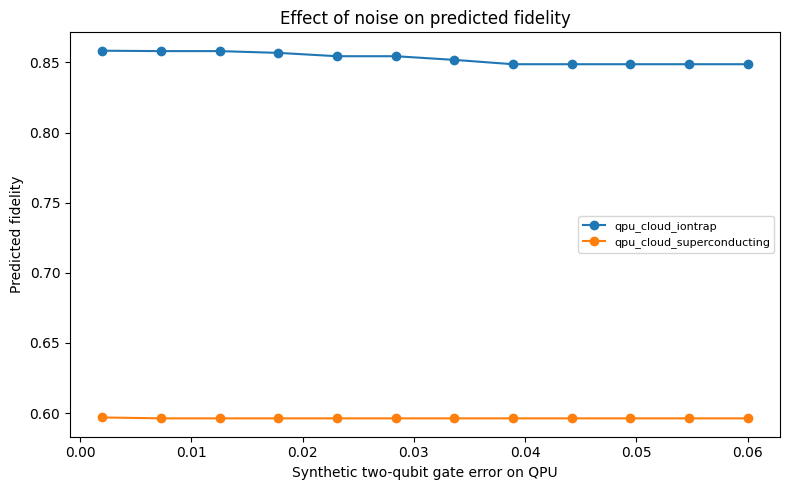

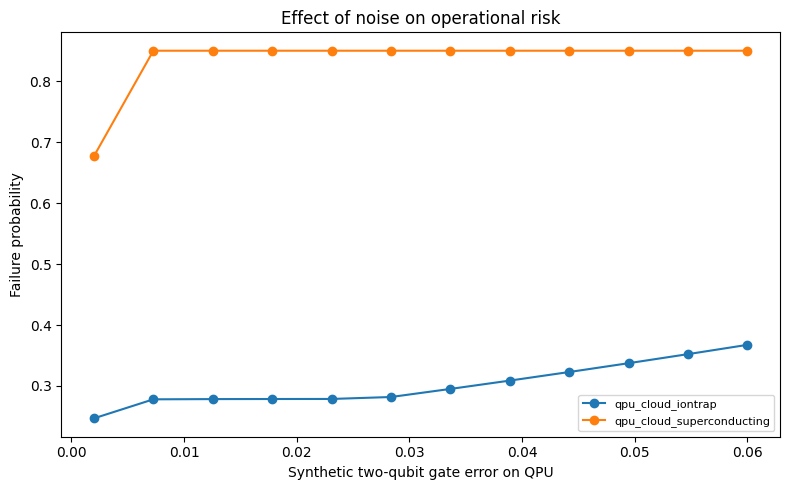

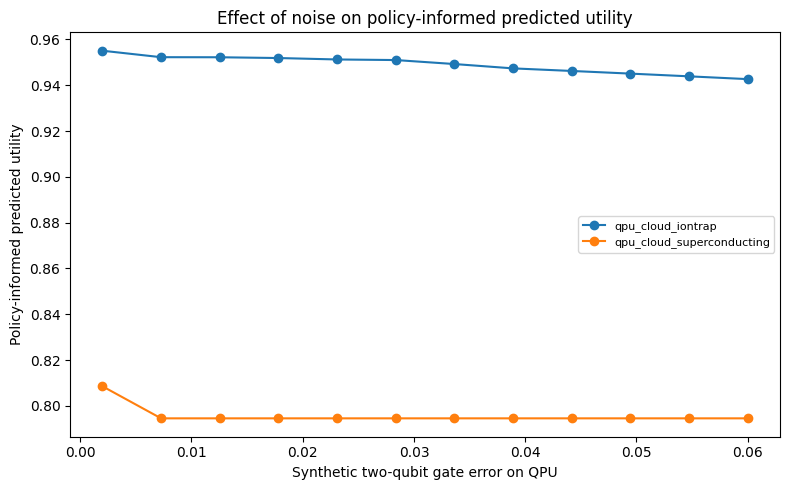

In [58]:
qpu_sensitivity = sensitivity_df[sensitivity_df["backend"].str.contains("qpu_cloud")].copy()

for metric, ylabel, filename, title in [
    ("predicted_fidelity", "Predicted fidelity", "sensitivity_qpu_noise_fidelity.png", "Effect of noise on predicted fidelity"),
    ("failure_probability", "Failure probability", "sensitivity_qpu_noise_failure.png", "Effect of noise on operational risk"),
    ("policy_informed_predicted_utility", "Policy-informed predicted utility", "sensitivity_qpu_noise_utility.png", "Effect of noise on policy-informed predicted utility"),
]:
    plt.figure(figsize=(8, 5))
    for backend_name, group in qpu_sensitivity.groupby("backend"):
        group = group.sort_values("noise_level")
        plt.plot(group["noise_level"], group[metric], marker="o", label=backend_name)
    plt.xlabel("Synthetic two-qubit gate error on QPU")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300)
    plt.show()
plt.close()


## 19. Scalability by number of qubits



In [59]:
scale_results = []
for q in range(4, 81, 4):
    workload = example_workload.copy()
    workload["num_qubits"] = q
    workload["circuit_depth"] = int(28 * q * 1.15)
    workload["two_qubit_gates"] = int(14 * q * 1.25)
    workload["entanglement_score"] = min(1.0, 0.012 * q)

    rec = recommend_backend_v3(workload, random_seed=2026)
    rec["num_qubits"] = q
    scale_results.append(rec)

scale_df = pd.concat(scale_results, ignore_index=True)
scale_df.to_csv(TAB_DIR / "scalability_by_qubits.csv", index=False)
scale_df.head()



,backend,backend_family,native_strength,predicted_backend_rank,selected_backend,acceptable_backend,predicted_selection_fallback,predicted_total_runtime_sec,predicted_fidelity,recommendation_probability,policy_informed_predicted_utility,backend_uptime,queue_depth,queue_time_sec,failure_probability,total_cost,hardware_validation_value,capacity_penalty,single_qubit_error,two_qubit_error,readout_error,num_qubits
0,qpu_cloud_iontrap,qpu,high_connectivity_hardware,1,1,1,0,212.186009,0.894875,0.601044,0.962703,0.678268,12.0,169.400606,0.282181,3.066179,0.9559,0.0,0.001428,0.007367,0.011553,4
1,qpu_cloud_superconducting,qpu,fast_hardware_sampling,2,0,1,0,672.920066,0.871818,0.526510,0.866192,0.688335,126.0,606.297924,0.850000,1.684761,0.9559,0.0,0.001105,0.031392,0.012265,4
2,tensor_network_sim,simulator,structured_low_entanglement,3,0,1,0,54.183435,0.957661,0.561114,0.523056,0.905682,8.0,14.650164,0.036538,0.082709,0.0000,0.0,0.000236,0.000560,0.000193,4
3,statevector_sim,simulator,small_medium_exact,4,0,1,0,125.715213,0.962197,0.622761,0.521524,0.979149,3.0,21.300635,0.034136,0.035479,0.0000,0.0,0.000046,0.000091,0.000108,4
4,noisy_sim,simulator,noise_experiments,5,0,0,0,106.063153,0.952045,0.395942,0.514217,0.920544,3.0,13.492504,0.056651,0.108093,0.0000,0.0,0.001848,0.012661,0.012021,4


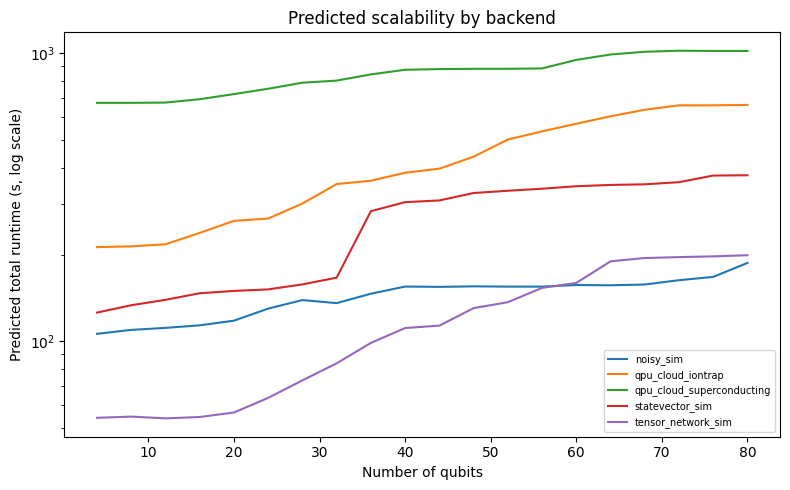

In [60]:
plt.figure(figsize=(8, 5))
for backend_name, group in scale_df.groupby("backend"):
    plt.plot(group["num_qubits"], group["predicted_total_runtime_sec"], label=backend_name)
plt.yscale("log")
plt.xlabel("Number of qubits")
plt.ylabel("Predicted total runtime (s, log scale)")
plt.title("Predicted scalability by backend")
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR / "scalability_runtime_by_backend.png", dpi=300)
plt.show()
plt.close()



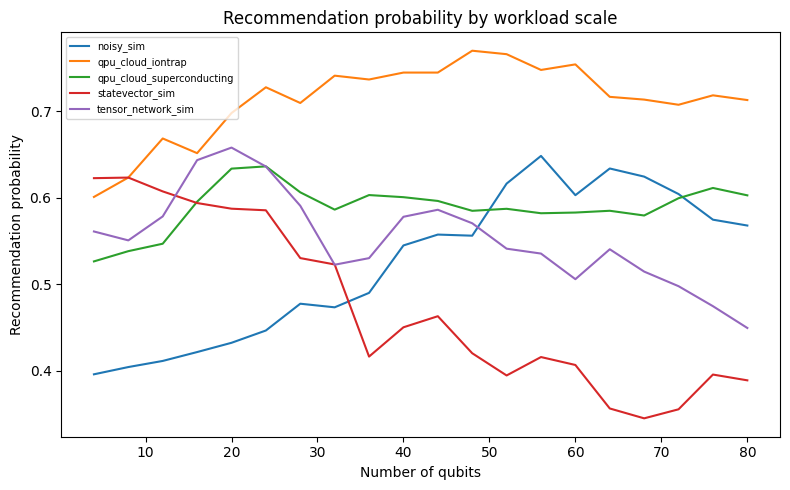

In [61]:
plt.figure(figsize=(8, 5))
for backend_name, group in scale_df.groupby("backend"):
    plt.plot(group["num_qubits"], group["recommendation_probability"], label=backend_name)
plt.xlabel("Number of qubits")
plt.ylabel("Recommendation probability")
plt.title("Recommendation probability by workload scale")
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR / "scalability_recommendation_probability.png", dpi=300)
plt.show()
plt.close()



## 20. Stress test under higher operational instability



In [62]:
stress_workloads = generate_workloads(n_workloads=220, random_seed=123)
stress_df = stress_workloads.merge(backend_catalog, how="cross")
stress_df = add_backend_state(stress_df, random_seed=123, stress=True)
stress_df = simulate_operational_outcomes(stress_df, random_seed=123, stress=True, generate_label=True)
stress_df = assign_selected_backend(stress_df, utility_col="decision_utility", acceptable_col="recommended_execution")

stress_X = stress_df[classifier_features]
stress_y = stress_df["recommended_execution"]
stress_pred = clf_model.predict(stress_X)
stress_prob = clf_model.predict_proba(stress_X)[:, 1]

stress_metrics = {
    "Accuracy": accuracy_score(stress_y, stress_pred),
    "Precision": precision_score(stress_y, stress_pred, zero_division=0),
    "Recall": recall_score(stress_y, stress_pred, zero_division=0),
    "F1": f1_score(stress_y, stress_pred, zero_division=0),
    "positive_rate_stress": stress_y.mean(),
}

pd.DataFrame([stress_metrics]).to_csv(TAB_DIR / "stress_test_metrics.csv", index=False)
stress_metrics



{'Accuracy': 0.7027272727272728,
 'Precision': 0.6536964980544747,
 'Recall': 0.6927835051546392,
 'F1': 0.6726726726726727,
 'positive_rate_stress': np.float64(0.4409090909090909)}

In [63]:
stress_summary_backend = stress_df.groupby("backend").agg(
    recommendation_rate=("recommended_execution", "mean"),
    mean_fidelity=("expected_fidelity", "mean"),
    mean_runtime_sec=("total_runtime_sec", "mean"),
    mean_failure_probability=("failure_probability", "mean"),
).sort_values("recommendation_rate", ascending=False)

stress_summary_backend.to_csv(TAB_DIR / "stress_summary_backend.csv")
stress_summary_backend



,recommendation_rate,mean_fidelity,mean_runtime_sec,mean_failure_probability
backend,,,,
tensor_network_sim,0.609091,0.920963,106.744834,0.025903
noisy_sim,0.604545,0.879618,110.420349,0.029388
statevector_sim,0.577273,0.932304,167.197701,0.029778
qpu_cloud_iontrap,0.245455,0.837154,706.084454,0.114717
qpu_cloud_superconducting,0.168182,0.510981,2035.598734,0.230493


## 21. Consolidated tables for the paper



In [64]:
table_dataset = pd.DataFrame({
    "metric": [
        "n_workloads",
        "n_backend_candidates",
        "n_pairs",
        "n_algorithms",
        "n_decision_profiles",
        "global_recommendation_rate",
        "workloads_with_one_selected_backend",
        "workloads_with_at_least_one_acceptable_backend",
        "workloads_without_acceptable_backend",
        "selected_backend_is_acceptable_rate",
        "fallback_selection_count",
        "group_split_train_workloads",
        "group_split_test_workloads",
    ],
    "value": [
        workloads["workload_id"].nunique(),
        backend_catalog["backend"].nunique(),
        df.shape[0],
        workloads["algorithm"].nunique(),
        workloads["decision_profile"].nunique(),
        df["recommended_execution"].mean(),
        int(df.groupby("workload_id")["selected_backend"].sum().eq(1).sum()),
        int(df.groupby("workload_id")["recommended_execution"].sum().gt(0).sum()),
        int(df.groupby("workload_id")["recommended_execution"].sum().eq(0).sum()),
        df.loc[df["selected_backend"] == 1, "recommended_execution"].mean(),
        int(df["selection_fallback"].sum()),
        train_df["workload_id"].nunique(),
        test_df["workload_id"].nunique(),
    ],
})

table_model_results = pd.DataFrame([
    runtime_metrics,
    fidelity_metrics,
    clf_metrics,
    clf_metrics_e2e,
    {"model": "Stress test", **stress_metrics},
])

table_dataset.to_csv(TAB_DIR / "table_dataset_description.csv", index=False)
table_model_results.to_csv(TAB_DIR / "table_model_results.csv", index=False)
ranking_metrics.to_csv(TAB_DIR / "table_backend_ranking_metrics.csv", index=False)
summary_backend.reset_index().to_csv(TAB_DIR / "table_backend_results.csv", index=False)
summary_algorithm.reset_index().to_csv(TAB_DIR / "table_algorithm_results.csv", index=False)
selected_backend_by_backend.reset_index().to_csv(TAB_DIR / "table_selected_backend_results.csv", index=False)

print("Tables saved in:", TAB_DIR)
display(table_dataset)
display(table_model_results)



Tables saved in: outputs_ai_quantum_ibm_credential_comparison/tables


,metric,value
0,n_workloads,700.000000
1,n_backend_candidates,5.000000
2,n_pairs,3500.000000
3,n_algorithms,6.000000
4,n_decision_profiles,6.000000
5,global_recommendation_rate,0.426000
6,workloads_with_one_selected_backend,700.000000
7,workloads_with_at_least_one_acceptable_backend,662.000000
8,workloads_without_acceptable_backend,38.000000
9,selected_backend_is_acceptable_rate,0.945714


,model,target,evaluation,MAE,RMSE,R2,task,Accuracy,Precision,Recall,F1,positive_rate_stress
0,RandomForestRegressor,total_runtime_sec,holdout_group_split,31.627512,47.434890,0.992981,NaN,NaN,NaN,NaN,NaN,NaN
1,RandomForestRegressor,expected_fidelity,holdout_group_split,0.028509,0.041601,0.952429,NaN,NaN,NaN,NaN,NaN,NaN
2,RandomForestClassifier,NaN,holdout_observed_runtime_fidelity,NaN,NaN,NaN,acceptable_backend_classification,0.671429,0.579946,0.740484,0.650456,NaN
3,RandomForestClassifier_test_substitution_diagn...,NaN,train_observed_test_predicted_runtime_fidelity...,NaN,NaN,NaN,acceptable_backend_classification,0.682857,0.590786,0.754325,0.662614,NaN
4,Stress test,NaN,NaN,NaN,NaN,NaN,NaN,0.702727,0.653696,0.692784,0.672673,0.440909


## 22. Cross-validation by `workload_id`



In [65]:
from sklearn.model_selection import GroupKFold
from sklearn.base import clone

n_group_folds = N_GROUP_FOLDS
gkf = GroupKFold(n_splits=n_group_folds)
cv_rows = []

for fold, (tr_idx, va_idx) in enumerate(gkf.split(df, df["recommended_execution"], groups=df["workload_id"]), start=1):
    fold_train = df.iloc[tr_idx].copy()
    fold_val = df.iloc[va_idx].copy()

    fold_runtime_model = clone(runtime_model)
    fold_fidelity_model = clone(fidelity_model)
    fold_clf_model = clone(clf_model)

    fold_runtime_model.fit(fold_train[base_features], fold_train["total_runtime_sec"])
    fold_runtime_pred = fold_runtime_model.predict(fold_val[base_features])

    cv_rows.append({
        "fold": fold,
        "task": "runtime_regression",
        "target": "total_runtime_sec",
        "evaluation": "group_cv_by_workload",
        "MAE": mean_absolute_error(fold_val["total_runtime_sec"], fold_runtime_pred),
        "RMSE": mean_squared_error(fold_val["total_runtime_sec"], fold_runtime_pred) ** 0.5,
        "R2": r2_score(fold_val["total_runtime_sec"], fold_runtime_pred),
    })

    fold_fidelity_model.fit(fold_train[base_features], fold_train["expected_fidelity"])
    fold_fidelity_pred = fold_fidelity_model.predict(fold_val[base_features]).clip(0, 1)

    cv_rows.append({
        "fold": fold,
        "task": "fidelity_regression",
        "target": "expected_fidelity",
        "evaluation": "group_cv_by_workload",
        "MAE": mean_absolute_error(fold_val["expected_fidelity"], fold_fidelity_pred),
        "RMSE": mean_squared_error(fold_val["expected_fidelity"], fold_fidelity_pred) ** 0.5,
        "R2": r2_score(fold_val["expected_fidelity"], fold_fidelity_pred),
    })

    fold_clf_model.fit(fold_train[classifier_features], fold_train["recommended_execution"])
    fold_clf_pred_obs = fold_clf_model.predict(fold_val[classifier_features])

    cv_rows.append({
        "fold": fold,
        "task": "acceptable_backend_classification",
        "evaluation": "group_cv_observed_runtime_fidelity",
        "Accuracy": accuracy_score(fold_val["recommended_execution"], fold_clf_pred_obs),
        "Precision": precision_score(fold_val["recommended_execution"], fold_clf_pred_obs, zero_division=0),
        "Recall": recall_score(fold_val["recommended_execution"], fold_clf_pred_obs, zero_division=0),
        "F1": f1_score(fold_val["recommended_execution"], fold_clf_pred_obs, zero_division=0),
    })

    fold_val_e2e = fold_val[classifier_features].copy()
    fold_val_e2e["total_runtime_sec"] = fold_runtime_pred
    fold_val_e2e["expected_fidelity"] = fold_fidelity_pred
    fold_clf_pred_e2e = fold_clf_model.predict(fold_val_e2e)

    cv_rows.append({
        "fold": fold,
        "task": "acceptable_backend_classification",
        "evaluation": "group_cv_train_observed_test_predicted_runtime_fidelity_diagnostic",
        "Accuracy": accuracy_score(fold_val["recommended_execution"], fold_clf_pred_e2e),
        "Precision": precision_score(fold_val["recommended_execution"], fold_clf_pred_e2e, zero_division=0),
        "Recall": recall_score(fold_val["recommended_execution"], fold_clf_pred_e2e, zero_division=0),
        "F1": f1_score(fold_val["recommended_execution"], fold_clf_pred_e2e, zero_division=0),
    })

cv_results_df = pd.DataFrame(cv_rows)

regression_metric_cols = ["MAE", "RMSE", "R2"]
classification_metric_cols = ["Accuracy", "Precision", "Recall", "F1"]

cv_results_regression = (
    cv_results_df.dropna(how="all", subset=regression_metric_cols)
    [["fold", "task", "target", "evaluation"] + regression_metric_cols]
    .reset_index(drop=True)
)
cv_results_classification = (
    cv_results_df.dropna(how="all", subset=classification_metric_cols)
    [["fold", "task", "evaluation"] + classification_metric_cols]
    .reset_index(drop=True)
)

group_cv_summary_regression = (
    cv_results_regression
    .groupby(["task", "target", "evaluation"], as_index=False)
    .agg({metric: ["mean", "std"] for metric in regression_metric_cols})
)
group_cv_summary_regression.columns = ["_".join([part for part in col if part]).strip("_") for col in group_cv_summary_regression.columns]

group_cv_summary_classification = (
    cv_results_classification
    .groupby(["task", "evaluation"], as_index=False)
    .agg({metric: ["mean", "std"] for metric in classification_metric_cols})
)
group_cv_summary_classification.columns = ["_".join([part for part in col if part]).strip("_") for col in group_cv_summary_classification.columns]

# Keep a combined table for auditing only, without main display.
cv_summary_df = pd.concat([
    group_cv_summary_regression.assign(metric_family="regression"),
    group_cv_summary_classification.assign(metric_family="classification"),
], ignore_index=True, sort=False)

cv_results_df.to_csv(TAB_DIR / "group_cv_fold_results_combined_audit.csv", index=False)
cv_results_regression.to_csv(TAB_DIR / "group_cv_fold_results_regression.csv", index=False)
cv_results_classification.to_csv(TAB_DIR / "group_cv_fold_results_classification.csv", index=False)
group_cv_summary_regression.to_csv(TAB_DIR / "group_cv_summary_regression.csv", index=False)
group_cv_summary_classification.to_csv(TAB_DIR / "group_cv_summary_classification.csv", index=False)
cv_summary_df.to_csv(TAB_DIR / "group_cv_summary_combined_audit.csv", index=False)

print("Workload-level cross-validation - regression")
display(cv_results_regression)
display(group_cv_summary_regression)

print("Workload-level cross-validation - classification")
display(cv_results_classification)
display(group_cv_summary_classification)



Workload-level cross-validation - regression


,fold,task,target,evaluation,MAE,RMSE,R2
0,1,runtime_regression,total_runtime_sec,group_cv_by_workload,32.054780,63.254350,0.988290
1,1,fidelity_regression,expected_fidelity,group_cv_by_workload,0.027277,0.039694,0.952576
2,2,runtime_regression,total_runtime_sec,group_cv_by_workload,33.387150,51.984177,0.990251
3,2,fidelity_regression,expected_fidelity,group_cv_by_workload,0.027787,0.039857,0.953192
4,3,runtime_regression,total_runtime_sec,group_cv_by_workload,35.251794,56.695472,0.989196
5,3,fidelity_regression,expected_fidelity,group_cv_by_workload,0.030003,0.044796,0.944587


,task,target,evaluation,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,fidelity_regression,expected_fidelity,group_cv_by_workload,0.028356,0.001449,0.041449,0.002899,0.950118,0.004800
1,runtime_regression,total_runtime_sec,group_cv_by_workload,33.564575,1.605875,57.311333,5.660270,0.989246,0.000982


Workload-level cross-validation - classification


,fold,task,evaluation,Accuracy,Precision,Recall,F1
0,1,acceptable_backend_classification,group_cv_observed_runtime_fidelity,0.698291,0.610306,0.773469,0.682268
1,1,acceptable_backend_classification,group_cv_train_observed_test_predicted_runtime...,0.702564,0.616013,0.769388,0.684211
2,2,acceptable_backend_classification,group_cv_observed_runtime_fidelity,0.678970,0.613014,0.707510,0.656881
3,2,acceptable_backend_classification,group_cv_train_observed_test_predicted_runtime...,0.691845,0.622296,0.739130,0.675700
4,3,acceptable_backend_classification,group_cv_observed_runtime_fidelity,0.701288,0.615023,0.793939,0.693122
5,3,acceptable_backend_classification,group_cv_train_observed_test_predicted_runtime...,0.696996,0.612698,0.779798,0.686222


,task,evaluation,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std
0,acceptable_backend_classification,group_cv_observed_runtime_fidelity,0.692849,0.012113,0.612781,0.002367,0.758306,0.045166,0.677424,0.018600
1,acceptable_backend_classification,group_cv_train_observed_test_predicted_runtime...,0.697135,0.005361,0.617003,0.004875,0.762772,0.021126,0.682044,0.005586


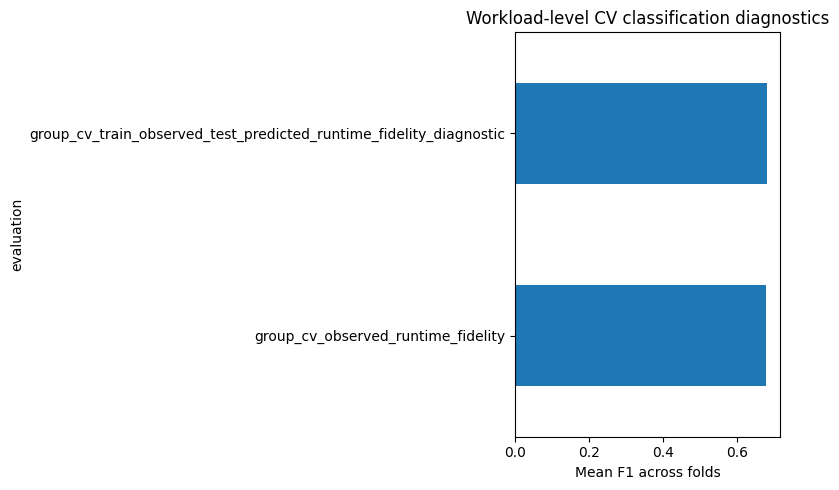

In [66]:
plt.figure(figsize=(8, 5))
cv_plot = cv_results_df[cv_results_df["task"].eq("acceptable_backend_classification")]
cv_plot.groupby("evaluation")["F1"].mean().sort_values().plot(kind="barh")
plt.xlabel("Mean F1 across folds")
plt.title("Workload-level CV classification diagnostics")
plt.tight_layout()
plt.savefig(FIG_DIR / "group_cv_classification_f1.png", dpi=300)
plt.show()
plt.close()


## 23. OOF sequential recommendation evaluation

This section is the primary reportable OOF evaluation of the **recommendation classifier**. Runtime and fidelity are predicted out of fold inside the training set and predicted from training-only regressors in the held-out test set. This prevents the classifier from receiving observed synthetic runtime/fidelity targets during its reportable OOF evaluation.

The final backend-selection stage is treated separately in Section 23.1 because it additionally uses the explicit synthetic decision-profile weights for policy-informed ranking.


In [67]:
def build_oof_performance_predictions(train_data, test_data, n_splits=N_OOF_FOLDS):
    """Generates out-of-fold runtime/fidelity predictions in training and predictions in test."""
    train_aug = train_data.copy()
    test_aug = test_data.copy()

    train_aug["oof_total_runtime_sec"] = np.nan
    train_aug["oof_expected_fidelity"] = np.nan

    gkf_inner = GroupKFold(n_splits=n_splits)
    for tr_idx_inner, va_idx_inner in gkf_inner.split(
        train_aug,
        train_aug["recommended_execution"],
        groups=train_aug["workload_id"],
    ):
        inner_train = train_aug.iloc[tr_idx_inner]
        inner_val = train_aug.iloc[va_idx_inner]

        rt = clone(runtime_model)
        fd = clone(fidelity_model)
        rt.fit(inner_train[base_features], inner_train["total_runtime_sec"])
        fd.fit(inner_train[base_features], inner_train["expected_fidelity"])

        train_aug.loc[inner_val.index, "oof_total_runtime_sec"] = rt.predict(inner_val[base_features])
        train_aug.loc[inner_val.index, "oof_expected_fidelity"] = fd.predict(inner_val[base_features]).clip(0, 1)

    # Final models trained on the full training set to predict the test set.
    rt_final = clone(runtime_model)
    fd_final = clone(fidelity_model)
    rt_final.fit(train_aug[base_features], train_aug["total_runtime_sec"])
    fd_final.fit(train_aug[base_features], train_aug["expected_fidelity"])

    test_aug["pred_total_runtime_sec"] = rt_final.predict(test_aug[base_features])
    test_aug["pred_expected_fidelity"] = fd_final.predict(test_aug[base_features]).clip(0, 1)

    return train_aug, test_aug, rt_final, fd_final


train_oof_df, test_oof_df, runtime_model_oof_final, fidelity_model_oof_final = build_oof_performance_predictions(
    train_df,
    test_df,
    n_splits=3,
)

X_train_clf_oof = train_oof_df[classifier_features].copy()
X_train_clf_oof["total_runtime_sec"] = train_oof_df["oof_total_runtime_sec"]
X_train_clf_oof["expected_fidelity"] = train_oof_df["oof_expected_fidelity"]

y_train_clf_oof = train_oof_df["recommended_execution"]

X_test_clf_oof = test_oof_df[classifier_features].copy()
X_test_clf_oof["total_runtime_sec"] = test_oof_df["pred_total_runtime_sec"]
X_test_clf_oof["expected_fidelity"] = test_oof_df["pred_expected_fidelity"]

y_test_clf_oof = test_oof_df["recommended_execution"]

clf_model_oof = clone(clf_model)
clf_model_oof.fit(X_train_clf_oof, y_train_clf_oof)

y_pred_clf_oof_e2e = clf_model_oof.predict(X_test_clf_oof)
y_prob_clf_oof_e2e = clf_model_oof.predict_proba(X_test_clf_oof)[:, 1]

oof_e2e_metrics = {
    "model": "RandomForestClassifier_oof_sequential_recommendation",
    "task": "acceptable_backend_classification",
    "evaluation": "train_oof_test_predicted_runtime_fidelity",
    "Accuracy": accuracy_score(y_test_clf_oof, y_pred_clf_oof_e2e),
    "Precision": precision_score(y_test_clf_oof, y_pred_clf_oof_e2e, zero_division=0),
    "Recall": recall_score(y_test_clf_oof, y_pred_clf_oof_e2e, zero_division=0),
    "F1": f1_score(y_test_clf_oof, y_pred_clf_oof_e2e, zero_division=0),
}

oof_e2e_comparison_df = pd.DataFrame([
    clf_metrics_observed,
    clf_metrics_e2e,
    oof_e2e_metrics,
])

oof_e2e_comparison_df.to_csv(TAB_DIR / "classification_oof_sequential_recommendation.csv", index=False)
oof_e2e_comparison_df


,model,task,evaluation,Accuracy,Precision,Recall,F1
0,RandomForestClassifier_observed,acceptable_backend_classification,isolated_observed_synthetic_runtime_fidelity,0.671429,0.579946,0.740484,0.650456
1,RandomForestClassifier_test_substitution_diagn...,acceptable_backend_classification,train_observed_test_predicted_runtime_fidelity...,0.682857,0.590786,0.754325,0.662614
2,RandomForestClassifier_oof_sequential_recommen...,acceptable_backend_classification,train_oof_test_predicted_runtime_fidelity,0.685714,0.596100,0.740484,0.660494


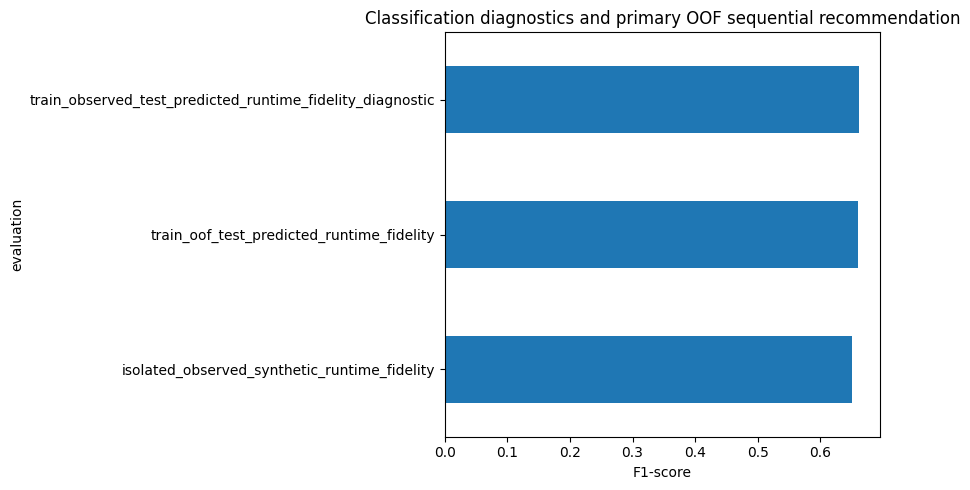

In [68]:
plt.figure(figsize=(9, 5))
oof_e2e_comparison_df.set_index("evaluation")["F1"].sort_values().plot(kind="barh")
plt.xlabel("F1-score")
plt.title("Classification diagnostics and primary OOF sequential recommendation")
plt.tight_layout()
plt.savefig(FIG_DIR / "classification_oof_sequential_recommendation.png", dpi=300)
plt.show()
plt.close()


## 23.1 Selection and ranking with OOF predictions and policy-informed final ranking

The recommendation stage uses OOF-consistent runtime/fidelity inputs. The final selector then gates candidates using the learned recommendation probability and ranks acceptable candidates with a **noise-free policy-informed utility proxy that explicitly receives the synthetic `w_*` decision-profile weights**.

Accordingly, this final selector is not described as an information-unprivileged end-to-end learner. Its scientific role is to quantify how much of the synthetic decision policy is recovered after sequential prediction error when the policy weights remain available to the orchestrator.


In [69]:
# ============================================================
# 23.1 OOF prediction + classifier-gated policy-weighted selection
# ============================================================

def score_candidates_for_selection_oof_policy_informed(candidate_df):
    """Score candidates with OOF-consistent predictors and explicit policy weights.

    Runtime/fidelity are predicted, acceptability is learned, and the final ranking
    explicitly uses the synthetic decision-profile weights. This is therefore a
    policy-informed final selector, not a weight-free learned ranker.
    """
    scored = candidate_df.copy()

    scored["predicted_total_runtime_sec"] = runtime_model_oof_final.predict(scored[base_features])
    scored["predicted_fidelity"] = fidelity_model_oof_final.predict(scored[base_features]).clip(0, 1)

    scored_for_clf = scored[classifier_features].copy()
    scored_for_clf["total_runtime_sec"] = scored["predicted_total_runtime_sec"]
    scored_for_clf["expected_fidelity"] = scored["predicted_fidelity"]

    scored["recommendation_probability"] = clf_model_oof.predict_proba(scored_for_clf)[:, 1]
    scored = add_policy_informed_predicted_utility(
        scored,
        fidelity_col="predicted_fidelity",
        runtime_col="predicted_total_runtime_sec",
        score_col="policy_informed_predicted_utility",
    )

    scored = add_predicted_selection(
        scored,
        prob_col="recommendation_probability",
        score_col="policy_informed_predicted_utility",
        threshold=0.5,
    )
    return scored


# From this point onward, reportable selection metrics use OOF-consistent
# predictions plus the explicitly policy-informed final ranking rule.
selection_eval_df = score_candidates_for_selection_oof_policy_informed(test_df)
selection_eval_df.to_csv(TAB_DIR / "selection_eval_oof_policy_informed.csv", index=False)

true_selected = (
    selection_eval_df[selection_eval_df["selected_backend"] == 1]
    [["workload_id", "backend"]]
    .rename(columns={"backend": "true_backend"})
)

pred_selected = (
    selection_eval_df[selection_eval_df["predicted_selected_backend"] == 1]
    [["workload_id", "backend"]]
    .rename(columns={"backend": "predicted_backend"})
)

selection_pair_eval = true_selected.merge(pred_selected, on="workload_id", how="inner")
selection_pair_eval["top1_correct"] = selection_pair_eval["true_backend"].eq(selection_pair_eval["predicted_backend"])

rank_eval = selection_eval_df.merge(true_selected, on="workload_id", how="left")
rank_eval["is_true_backend"] = rank_eval["backend"].eq(rank_eval["true_backend"])

top1_accuracy = selection_pair_eval["top1_correct"].mean()
top2_accuracy = rank_eval.loc[rank_eval["predicted_backend_rank"] <= 2].groupby("workload_id")["is_true_backend"].max().mean()
top3_accuracy = rank_eval.loc[rank_eval["predicted_backend_rank"] <= 3].groupby("workload_id")["is_true_backend"].max().mean()

ranking_metrics = pd.DataFrame([{
    "evaluation": "oof_classifier_gated_policy_weighted_selection",
    "explicit_policy_weights_in_final_ranking": True,
    "Top-1 accuracy": top1_accuracy,
    "Top-2 accuracy": top2_accuracy,
    "Top-3 accuracy": top3_accuracy,
    "predicted_fallback_rate": selection_eval_df.loc[selection_eval_df["predicted_selected_backend"] == 1, "predicted_selection_fallback"].mean(),
    "true_fallback_rate": selection_eval_df.loc[selection_eval_df["selected_backend"] == 1, "selection_fallback"].mean(),
}])

selection_confusion = pd.crosstab(
    selection_pair_eval["true_backend"],
    selection_pair_eval["predicted_backend"],
    rownames=["true_backend"],
    colnames=["predicted_backend"],
    normalize="index",
)

selection_distribution_comparison = (
    pd.concat([
        selection_pair_eval["true_backend"].value_counts(normalize=True).rename("true_selection_rate"),
        selection_pair_eval["predicted_backend"].value_counts(normalize=True).rename("predicted_selection_rate"),
    ], axis=1)
    .fillna(0)
)
selection_distribution_comparison["diff_pred_minus_true"] = (
    selection_distribution_comparison["predicted_selection_rate"]
    - selection_distribution_comparison["true_selection_rate"]
)

ranking_metrics.to_csv(TAB_DIR / "backend_ranking_metrics_oof_policy_informed.csv", index=False)
ranking_metrics.to_csv(TAB_DIR / "backend_ranking_metrics.csv", index=False)
selection_confusion.to_csv(TAB_DIR / "backend_selection_confusion_oof_policy_informed.csv")
selection_confusion.to_csv(TAB_DIR / "backend_selection_confusion.csv")
selection_distribution_comparison.to_csv(TAB_DIR / "selection_distribution_comparison_oof_policy_informed.csv")
selection_distribution_comparison.to_csv(TAB_DIR / "selection_distribution_comparison.csv")

print("Ranking metrics: OOF prediction + classifier-gated policy-weighted final selection.")
display(ranking_metrics)
display(selection_distribution_comparison)
selection_confusion


Ranking metrics: OOF prediction + classifier-gated policy-weighted final selection.


,evaluation,explicit_policy_weights_in_final_ranking,Top-1 accuracy,Top-2 accuracy,Top-3 accuracy,predicted_fallback_rate,true_fallback_rate
0,oof_classifier_gated_policy_weighted_selection,True,0.55,0.807143,0.95,0.007143,0.064286


,true_selection_rate,predicted_selection_rate,diff_pred_minus_true
tensor_network_sim,0.321429,0.442857,0.121429
statevector_sim,0.278571,0.385714,0.107143
qpu_cloud_iontrap,0.200000,0.128571,-0.071429
noisy_sim,0.192857,0.028571,-0.164286
qpu_cloud_superconducting,0.007143,0.014286,0.007143


predicted_backend,noisy_sim,qpu_cloud_iontrap,qpu_cloud_superconducting,statevector_sim,tensor_network_sim
true_backend,,,,,
noisy_sim,0.037037,0.000000,0.000000,0.333333,0.629630
qpu_cloud_iontrap,0.000000,0.642857,0.071429,0.107143,0.178571
qpu_cloud_superconducting,0.000000,0.000000,0.000000,1.000000,0.000000
statevector_sim,0.076923,0.000000,0.000000,0.692308,0.230769
tensor_network_sim,0.000000,0.000000,0.000000,0.311111,0.688889


## 23.2 Comparison of final selection strategies with explicit information-access labels

The comparison below intentionally mixes strategies with different information access, so the table is descriptive unless a controlled comparison is stated explicitly. In particular, both the primary selector and the weighted no-classifier reference receive the exact synthetic `w_*` weights at final ranking; the probability-only learned baseline does not.


In [70]:
# ============================================================
# 23.2 Strategy comparison with explicit information access
# ============================================================

def evaluate_selection_strategy(scored_df, strategy_name, selected_index_by_workload, **metadata):
    selected = (
        scored_df.loc[list(selected_index_by_workload), ["workload_id", "backend", "decision_utility", "selection_fallback"]]
        .rename(columns={
            "backend": "strategy_backend",
            "decision_utility": "strategy_true_utility",
            "selection_fallback": "strategy_fallback_flag",
        })
    )
    true_sel = (
        scored_df[scored_df["selected_backend"].eq(1)]
        [["workload_id", "backend", "decision_utility"]]
        .rename(columns={"backend": "true_backend", "decision_utility": "true_selected_utility"})
    )
    merged = true_sel.merge(selected, on="workload_id", how="inner")
    merged["same_backend"] = merged["true_backend"].eq(merged["strategy_backend"])
    merged["utility_regret"] = (merged["true_selected_utility"] - merged["strategy_true_utility"]).clip(lower=0)
    merged["relative_utility_regret"] = merged["utility_regret"] / (merged["true_selected_utility"].abs() + 1e-9)
    row = {
        "strategy": strategy_name,
        "Top-1 accuracy": merged["same_backend"].mean(),
        "mean_regret": merged["utility_regret"].mean(),
        "median_regret": merged["utility_regret"].median(),
        "p90_regret": merged["utility_regret"].quantile(0.90),
        "mean_relative_regret": merged["relative_utility_regret"].mean(),
        "low_regret_rate_le_0_03": (merged["utility_regret"] <= 0.03).mean(),
        "n_workloads": merged["workload_id"].nunique(),
    }
    row.update(metadata)
    return row


def _idxmax_by_workload(df_obj, col):
    return df_obj.groupby("workload_id")[col].idxmax()


def _idxmin_by_workload(df_obj, col):
    return df_obj.groupby("workload_id")[col].idxmin()

selection_strategy_rows = []

# Primary hybrid selector: learned acceptability gating + explicit policy-weighted ranking.
ml_selected_idx = selection_eval_df[selection_eval_df["predicted_selected_backend"].eq(1)].index
selection_strategy_rows.append(evaluate_selection_strategy(
    selection_eval_df,
    "ML_OOF_classifier_gated_policy_weighted",
    ml_selected_idx,
    explicit_policy_weights=True,
    direct_utility_target_training=False,
    learned_acceptability_gating=True,
    information_role="primary policy-informed hybrid selector",
))

# Learned recommendation-only selector: no explicit w_* weights at test time.
selection_strategy_rows.append(evaluate_selection_strategy(
    selection_eval_df,
    "ML_OOF_probability_only_selection",
    _idxmax_by_workload(selection_eval_df, "recommendation_probability"),
    explicit_policy_weights=False,
    direct_utility_target_training=False,
    learned_acceptability_gating=True,
    information_role="learned no-explicit-weight selection baseline",
))

# Direct single-criterion heuristics.
for strategy_name, idx in [
    ("heuristic_min_predicted_runtime", _idxmin_by_workload(selection_eval_df, "predicted_total_runtime_sec")),
    ("heuristic_max_predicted_fidelity", _idxmax_by_workload(selection_eval_df, "predicted_fidelity")),
    ("heuristic_min_total_cost", _idxmin_by_workload(selection_eval_df, "total_cost")),
    ("heuristic_min_failure_probability", _idxmin_by_workload(selection_eval_df, "failure_probability")),
]:
    selection_strategy_rows.append(evaluate_selection_strategy(
        selection_eval_df,
        strategy_name,
        idx,
        explicit_policy_weights=False,
        direct_utility_target_training=False,
        learned_acceptability_gating=False,
        information_role="single-criterion heuristic",
    ))

# Same policy-informed score as the primary selector, but without classifier gating.
selection_strategy_rows.append(evaluate_selection_strategy(
    selection_eval_df,
    "policy_informed_weighted_no_classifier",
    _idxmax_by_workload(selection_eval_df, "policy_informed_predicted_utility"),
    explicit_policy_weights=True,
    direct_utility_target_training=False,
    learned_acceptability_gating=False,
    information_role="controlled policy-weighted reference",
))

selection_strategy_comparison = pd.DataFrame(selection_strategy_rows).sort_values(
    ["mean_regret", "Top-1 accuracy"], ascending=[True, False]
)
selection_strategy_comparison.to_csv(TAB_DIR / "selection_strategy_comparison.csv", index=False)

print("Selection-strategy comparison with explicit information-access metadata:")
display(selection_strategy_comparison)


Selection-strategy comparison with explicit information-access metadata:


,strategy,Top-1 accuracy,mean_regret,median_regret,p90_regret,mean_relative_regret,low_regret_rate_le_0_03,n_workloads,explicit_policy_weights,direct_utility_target_training,learned_acceptability_gating,information_role
6,policy_informed_weighted_no_classifier,0.564286,0.011784,0.000000,0.052877,0.012708,0.871429,140,True,False,False,controlled policy-weighted reference
0,ML_OOF_classifier_gated_policy_weighted,0.550000,0.013607,0.000000,0.053916,0.014757,0.842857,140,True,False,True,primary policy-informed hybrid selector
1,ML_OOF_probability_only_selection,0.392857,0.027679,0.000000,0.089665,0.029790,0.692857,140,False,False,True,learned no-explicit-weight selection baseline
5,heuristic_min_failure_probability,0.414286,0.061417,0.000000,0.272138,0.069990,0.707143,140,False,False,False,single-criterion heuristic
2,heuristic_min_predicted_runtime,0.314286,0.062630,0.013987,0.272138,0.071026,0.621429,140,False,False,False,single-criterion heuristic
3,heuristic_max_predicted_fidelity,0.378571,0.070786,0.000000,0.274168,0.080109,0.642857,140,False,False,False,single-criterion heuristic
4,heuristic_min_total_cost,0.250000,0.095963,0.048520,0.291196,0.108680,0.478571,140,False,False,False,single-criterion heuristic


## 23.3 Feature-group ablation with oracle and OOF regimes separated

This section now distinguishes two different questions that were previously mixed:

1. **Oracle/isolated recoverability:** what can the classifier recover when observed synthetic runtime/fidelity are available?
2. **OOF sequential recoverability:** what can it recover when runtime/fidelity are predictions both in training (OOF) and testing?

The decision-profile identifier and the explicit synthetic `w_*` policy weights are also ablated separately so information access is visible rather than hidden inside one feature group.


In [71]:
# ============================================================
# 23.3 Feature-group ablation with explicit information regimes
# ============================================================

def existing_columns(cols, data):
    return [c for c in cols if c in data.columns]

# OOF-consistent copies use the same feature names expected by classifier_features.
train_oof_ablation = train_oof_df.copy()
train_oof_ablation["total_runtime_sec"] = train_oof_ablation["oof_total_runtime_sec"]
train_oof_ablation["expected_fidelity"] = train_oof_ablation["oof_expected_fidelity"]

test_oof_ablation = test_oof_df.copy()
test_oof_ablation["total_runtime_sec"] = test_oof_ablation["pred_total_runtime_sec"]
test_oof_ablation["expected_fidelity"] = test_oof_ablation["pred_expected_fidelity"]

ablation_configs = {
    "workload_only": {
        "features": existing_columns([
            "algorithm", "algorithm_family", "num_qubits", "circuit_depth", "two_qubit_gates", "shots",
            "entanglement_score", "noise_sensitivity", "scientific_priority", "requires_real_hardware", "validation_need",
            "deadline_hours", "budget_usd",
        ], train_df),
        "train": train_df, "test": test_df,
        "information_regime": "observed_non_target_features",
        "explicit_policy_weights": False, "oracle_runtime_fidelity": False,
    },
    "backend_static_only": {
        "features": existing_columns([
            "backend", "backend_family", "native_strength", "max_effective_qubits", "supports_real_hardware",
            "single_qubit_error", "two_qubit_error", "readout_error", "coupling_density", "hardware_validation_value",
        ], train_df),
        "train": train_df, "test": test_df,
        "information_regime": "observed_non_target_features",
        "explicit_policy_weights": False, "oracle_runtime_fidelity": False,
    },
    "operational_state_only": {
        "features": existing_columns([
            "calibration_age_hours", "queue_depth", "backend_uptime", "queue_time_sec", "total_cost",
            "failure_probability", "transpilation_overhead", "communication_latency_sec", "capacity_penalty", "qubit_pressure",
        ], train_df),
        "train": train_df, "test": test_df,
        "information_regime": "observed_operational_covariates",
        "explicit_policy_weights": False, "oracle_runtime_fidelity": False,
    },
    "decision_profile_id_only": {
        "features": ["decision_profile"],
        "train": train_df, "test": test_df,
        "information_regime": "profile_identifier_only",
        "explicit_policy_weights": False, "oracle_runtime_fidelity": False,
    },
    "explicit_policy_weights_only": {
        "features": existing_columns([
            "w_fidelity", "w_time", "w_cost", "w_availability", "w_failure", "w_hardware", "w_capacity",
        ], train_df),
        "train": train_df, "test": test_df,
        "information_regime": "explicit_synthetic_policy_weights",
        "explicit_policy_weights": True, "oracle_runtime_fidelity": False,
    },
    "oracle_observed_performance_only": {
        "features": ["expected_fidelity", "total_runtime_sec"],
        "train": train_df, "test": test_df,
        "information_regime": "oracle_observed_synthetic_targets",
        "explicit_policy_weights": False, "oracle_runtime_fidelity": True,
    },
    "oof_predicted_performance_only": {
        "features": ["expected_fidelity", "total_runtime_sec"],
        "train": train_oof_ablation, "test": test_oof_ablation,
        "information_regime": "OOF_train_predicted_test",
        "explicit_policy_weights": False, "oracle_runtime_fidelity": False,
    },
    "full_oracle_observed_runtime_fidelity": {
        "features": classifier_features,
        "train": train_df, "test": test_df,
        "information_regime": "oracle_observed_runtime_fidelity",
        "explicit_policy_weights": False, "oracle_runtime_fidelity": True,
    },
    "full_oof_predicted_runtime_fidelity": {
        "features": classifier_features,
        "train": train_oof_ablation, "test": test_oof_ablation,
        "information_regime": "OOF_train_predicted_test",
        "explicit_policy_weights": False, "oracle_runtime_fidelity": False,
    },
}

ablation_rows = []
for config_name, cfg in ablation_configs.items():
    features = cfg["features"]
    train_source = cfg["train"]
    test_source = cfg["test"]
    if not features:
        continue

    cat_cols = [c for c in features if train_source[c].dtype == "object"]
    num_cols = [c for c in features if c not in cat_cols]
    transformers = []
    if cat_cols:
        transformers.append(("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols))
    if num_cols:
        transformers.append(("num", StandardScaler(), num_cols))
    prep = ColumnTransformer(transformers)

    model = Pipeline([
        ("prep", prep),
        ("model", RandomForestClassifier(
            n_estimators=40 if FAST_MODE else 70,
            random_state=SEED,
            class_weight="balanced",
            min_samples_leaf=3,
            n_jobs=1,
        )),
    ])
    model.fit(train_source[features], train_source["recommended_execution"])
    pred = model.predict(test_source[features])
    ablation_rows.append({
        "feature_set": config_name,
        "information_regime": cfg["information_regime"],
        "explicit_policy_weights": cfg["explicit_policy_weights"],
        "oracle_runtime_fidelity": cfg["oracle_runtime_fidelity"],
        "n_features": len(features),
        "Accuracy": accuracy_score(test_source["recommended_execution"], pred),
        "Precision": precision_score(test_source["recommended_execution"], pred, zero_division=0),
        "Recall": recall_score(test_source["recommended_execution"], pred, zero_division=0),
        "F1": f1_score(test_source["recommended_execution"], pred, zero_division=0),
    })

feature_ablation_results = pd.DataFrame(ablation_rows).sort_values("F1", ascending=False)
feature_ablation_results.to_csv(TAB_DIR / "feature_ablation_results.csv", index=False)

print("Feature-group ablation with oracle and OOF regimes explicitly separated:")
display(feature_ablation_results)


Feature-group ablation with oracle and OOF regimes explicitly separated:


,feature_set,information_regime,explicit_policy_weights,oracle_runtime_fidelity,n_features,Accuracy,Precision,Recall,F1
7,full_oracle_observed_runtime_fidelity,oracle_observed_runtime_fidelity,False,True,34,0.685714,0.592493,0.764706,0.667674
8,full_oof_predicted_runtime_fidelity,OOF_train_predicted_test,False,False,34,0.682857,0.592798,0.740484,0.658462
2,operational_state_only,observed_operational_covariates,False,False,10,0.657143,0.573134,0.664360,0.615385
1,backend_static_only,observed_non_target_features,False,False,10,0.637143,0.552239,0.640138,0.592949
6,oof_predicted_performance_only,OOF_train_predicted_test,False,False,2,0.618571,0.536913,0.553633,0.545145
5,oracle_observed_performance_only,oracle_observed_synthetic_targets,False,True,2,0.601429,0.515924,0.560554,0.537313
4,explicit_policy_weights_only,explicit_synthetic_policy_weights,True,False,7,0.578571,0.486364,0.370242,0.420432
3,decision_profile_id_only,profile_identifier_only,False,False,1,0.578571,0.486364,0.370242,0.420432
0,workload_only,observed_non_target_features,False,False,13,0.532857,0.417391,0.332180,0.369942


## 23.4 Strong multicriteria and direct-utility baselines with information access made explicit

This section extends the benchmark beyond unidimensional heuristics, but the methods are not treated as information-equivalent:

- **Policy-informed TOPSIS** uses predicted runtime/fidelity and the explicit synthetic decision-profile weights;
- **Unweighted Pareto dominance** uses predicted/observed operational criteria without the `w_*` weights;
- **Random Forest direct utility ranker** and **Gradient Boosting direct utility ranker** learn the synthetic `decision_utility` target directly. Their runtime/fidelity inputs are OOF predictions in training and model predictions at test time.

The direct utility rankers therefore have privileged **training-target access**, whereas TOPSIS and the primary final selector have privileged **explicit policy-weight access** at ranking time. These distinctions are reported in the information-access audit rather than collapsed into a single fair-competition claim.


In [72]:
# ============================================================
# 23.4 Strong multicriteria and learning-to-rank baselines for robust public comparison
# ============================================================

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


def _safe_group_minmax(values, benefit=True):
    values = pd.to_numeric(values, errors="coerce")
    vmin, vmax = values.min(), values.max()
    if pd.isna(vmin) or pd.isna(vmax) or vmax == vmin:
        return pd.Series(np.ones(len(values)) * 0.5, index=values.index)
    scaled = (values - vmin) / (vmax - vmin)
    return scaled if benefit else 1 - scaled


def add_topsis_scores(candidate_df):
    """Adds a policy-informed TOPSIS score computed within each workload.

    Benefit criteria are larger-is-better. Cost criteria are converted to larger-is-better
    through workload-level min-max normalization.
    """
    scored = candidate_df.copy()

    if "predicted_total_runtime_sec" not in scored.columns:
        scored["predicted_total_runtime_sec"] = scored.get("total_runtime_sec", np.nan)
    if "predicted_fidelity" not in scored.columns:
        scored["predicted_fidelity"] = scored.get("expected_fidelity", np.nan)

    rows = []
    criterion_cols = [
        "topsis_fidelity", "topsis_time", "topsis_cost", "topsis_failure",
        "topsis_availability", "topsis_hardware", "topsis_capacity"
    ]

    for _, group in scored.groupby("workload_id", sort=False):
        g = group.copy()
        g["topsis_fidelity"] = _safe_group_minmax(g["predicted_fidelity"], benefit=True)
        g["topsis_time"] = _safe_group_minmax(g["predicted_total_runtime_sec"], benefit=False)
        g["topsis_cost"] = _safe_group_minmax(g["total_cost"], benefit=False)
        g["topsis_failure"] = _safe_group_minmax(g["failure_probability"], benefit=False)
        g["topsis_availability"] = _safe_group_minmax(g["backend_uptime"], benefit=True)
        g["topsis_hardware"] = _safe_group_minmax(g["hardware_validation_value"], benefit=True)
        g["topsis_capacity"] = _safe_group_minmax(g["capacity_penalty"], benefit=False)

        weights = np.array([
            float(g["w_fidelity"].iloc[0]),
            float(g["w_time"].iloc[0]),
            float(g["w_cost"].iloc[0]),
            float(g["w_failure"].iloc[0]),
            float(g["w_availability"].iloc[0]),
            float(g["w_hardware"].iloc[0]),
            float(g["w_capacity"].iloc[0]),
        ], dtype=float)
        weights = weights / (weights.sum() + 1e-12)

        matrix = g[criterion_cols].to_numpy(dtype=float)
        weighted = matrix * weights
        ideal = np.nanmax(weighted, axis=0)
        anti_ideal = np.nanmin(weighted, axis=0)
        dist_ideal = np.sqrt(np.nansum((weighted - ideal) ** 2, axis=1))
        dist_anti = np.sqrt(np.nansum((weighted - anti_ideal) ** 2, axis=1))
        g["topsis_score"] = dist_anti / (dist_ideal + dist_anti + 1e-12)
        rows.append(g)

    return pd.concat(rows, axis=0).sort_index()


def add_pareto_scores(candidate_df):
    """Adds a simple Pareto-dominance score within each workload."""
    scored = candidate_df.copy()
    if "predicted_total_runtime_sec" not in scored.columns:
        scored["predicted_total_runtime_sec"] = scored.get("total_runtime_sec", np.nan)
    if "predicted_fidelity" not in scored.columns:
        scored["predicted_fidelity"] = scored.get("expected_fidelity", np.nan)

    out = []
    for _, group in scored.groupby("workload_id", sort=False):
        g = group.copy()
        criteria = pd.DataFrame({
            "fidelity": _safe_group_minmax(g["predicted_fidelity"], benefit=True),
            "runtime": _safe_group_minmax(g["predicted_total_runtime_sec"], benefit=False),
            "cost": _safe_group_minmax(g["total_cost"], benefit=False),
            "failure": _safe_group_minmax(g["failure_probability"], benefit=False),
            "availability": _safe_group_minmax(g["backend_uptime"], benefit=True),
            "hardware": _safe_group_minmax(g["hardware_validation_value"], benefit=True),
            "capacity": _safe_group_minmax(g["capacity_penalty"], benefit=False),
        }, index=g.index)

        values = criteria.to_numpy(dtype=float)
        dominance_count = []
        dominated_flag = []
        for i in range(len(g)):
            vi = values[i]
            dominates_i = 0
            is_dominated = False
            for j in range(len(g)):
                if i == j:
                    continue
                vj = values[j]
                i_dominates_j = np.all(vi >= vj - 1e-12) and np.any(vi > vj + 1e-12)
                j_dominates_i = np.all(vj >= vi - 1e-12) and np.any(vj > vi + 1e-12)
                dominates_i += int(i_dominates_j)
                is_dominated = is_dominated or bool(j_dominates_i)
            dominance_count.append(dominates_i)
            dominated_flag.append(int(is_dominated))

        g["pareto_dominance_count"] = dominance_count
        g["pareto_non_dominated"] = 1 - pd.Series(dominated_flag, index=g.index)
        # Weight-free tie-break: do not inject the synthetic decision-profile weights.
        tie_break = criteria.mean(axis=1)
        g["pareto_score"] = g["pareto_non_dominated"] + 0.1 * g["pareto_dominance_count"] + 0.01 * tie_break
        out.append(g)
    return pd.concat(out, axis=0).sort_index()


# Multicriteria decision baselines.
selection_eval_df = add_topsis_scores(selection_eval_df)
selection_eval_df = add_pareto_scores(selection_eval_df)

selection_strategy_rows_extended = list(selection_strategy_rows)
selection_strategy_rows_extended.append(
    evaluate_selection_strategy(selection_eval_df, "policy_informed_topsis_predicted", _idxmax_by_workload(selection_eval_df, "topsis_score"))
)
selection_strategy_rows_extended.append(
    evaluate_selection_strategy(selection_eval_df, "pareto_dominance_unweighted_predicted", _idxmax_by_workload(selection_eval_df, "pareto_score"))
)

# Direct utility rankers. They learn the synthetic utility directly and rank candidate backends.
# For information-regime consistency, runtime and fidelity are OOF predictions in training
# and model predictions at test time; observed synthetic targets are not supplied as features.
ranker_train_for_model = train_oof_df.copy()
ranker_train_for_model["total_runtime_sec"] = ranker_train_for_model["oof_total_runtime_sec"]
ranker_train_for_model["expected_fidelity"] = ranker_train_for_model["oof_expected_fidelity"]

ranker_test_for_model = selection_eval_df.copy()
ranker_test_for_model["total_runtime_sec"] = ranker_test_for_model["predicted_total_runtime_sec"]
ranker_test_for_model["expected_fidelity"] = ranker_test_for_model["predicted_fidelity"]

utility_rankers = {
    "rf_direct_utility_ranker": RandomForestRegressor(
        n_estimators=80,
        random_state=SEED,
        min_samples_leaf=3,
        n_jobs=1,
    ),
    "gbr_direct_utility_ranker": GradientBoostingRegressor(
        random_state=SEED,
        n_estimators=120,
        learning_rate=0.05,
        max_depth=3,
    ),
}

utility_ranker_predictions = []
for ranker_name, ranker in utility_rankers.items():
    model = Pipeline([
        ("prep", clone(preprocess_clf)),
        ("model", ranker),
    ])
    model.fit(ranker_train_for_model[classifier_features], ranker_train_for_model["decision_utility"])
    pred_col = f"{ranker_name}_predicted_utility"
    selection_eval_df[pred_col] = model.predict(ranker_test_for_model[classifier_features])
    selection_strategy_rows_extended.append(
        evaluate_selection_strategy(selection_eval_df, ranker_name, _idxmax_by_workload(selection_eval_df, pred_col))
    )
    utility_ranker_predictions.append({"strategy": ranker_name, "prediction_column": pred_col})

selection_strategy_comparison_extended = (
    pd.DataFrame(selection_strategy_rows_extended)
    .drop_duplicates(subset=["strategy"], keep="last")
    .sort_values(["mean_regret", "Top-1 accuracy"], ascending=[True, False])
    .reset_index(drop=True)
)

selection_strategy_comparison_extended.to_csv(TAB_DIR / "selection_strategy_comparison_full_paper.csv", index=False)
selection_eval_df.to_csv(TAB_DIR / "selection_eval_with_full_paper_baselines.csv", index=False)

print("Extended comparison with multicriteria and utility-ranker baselines:")
display(selection_strategy_comparison_extended)



Extended comparison with multicriteria and utility-ranker baselines:


,strategy,Top-1 accuracy,mean_regret,median_regret,p90_regret,mean_relative_regret,low_regret_rate_le_0_03,n_workloads,explicit_policy_weights,direct_utility_target_training,learned_acceptability_gating,information_role
0,policy_informed_weighted_no_classifier,0.564286,0.011784,0.000000,0.052877,0.012708,0.871429,140,True,False,False,controlled policy-weighted reference
1,gbr_direct_utility_ranker,0.550000,0.012793,0.000000,0.052877,0.014025,0.850000,140,NaN,NaN,NaN,NaN
2,ML_OOF_classifier_gated_policy_weighted,0.550000,0.013607,0.000000,0.053916,0.014757,0.842857,140,True,False,True,primary policy-informed hybrid selector
3,rf_direct_utility_ranker,0.557143,0.014459,0.000000,0.062176,0.016336,0.835714,140,NaN,NaN,NaN,NaN
4,policy_informed_topsis_predicted,0.550000,0.015253,0.000000,0.065178,0.016761,0.835714,140,NaN,NaN,NaN,NaN
5,ML_OOF_probability_only_selection,0.392857,0.027679,0.000000,0.089665,0.029790,0.692857,140,False,False,True,learned no-explicit-weight selection baseline
6,heuristic_min_failure_probability,0.414286,0.061417,0.000000,0.272138,0.069990,0.707143,140,False,False,False,single-criterion heuristic
7,pareto_dominance_unweighted_predicted,0.342857,0.061491,0.001268,0.276334,0.069567,0.692857,140,NaN,NaN,NaN,NaN
8,heuristic_min_predicted_runtime,0.314286,0.062630,0.013987,0.272138,0.071026,0.621429,140,False,False,False,single-criterion heuristic
9,heuristic_max_predicted_fidelity,0.378571,0.070786,0.000000,0.274168,0.080109,0.642857,140,False,False,False,single-criterion heuristic


## 23.5 Training-size sensitivity for open-science robustness

This section evaluates whether the recommendation pipeline remains stable when fewer training workloads are available. The held-out test workloads remain fixed; only the number of training workloads changes.

To keep the information regime consistent with the primary OOF sequential recommendation analysis, each training subset obtains **out-of-fold runtime and fidelity predictions** before fitting the recommendation classifier. The fixed test set receives runtime and fidelity predictions from regressors fitted only on the corresponding training subset. Therefore, this analysis no longer gives the classifier oracle access to observed synthetic runtime/fidelity targets.


Training-size sensitivity under the OOF sequential recommendation information regime:


,evaluation,n_train_workloads,n_train_pairs,accuracy,precision,recall,f1,mean_recommendation_probability
0,OOF_train_predicted_test_runtime_fidelity,100,500,0.667143,0.582840,0.681661,0.628389,0.454800
1,OOF_train_predicted_test_runtime_fidelity,200,1000,0.662857,0.572603,0.723183,0.639144,0.446992
2,OOF_train_predicted_test_runtime_fidelity,400,2000,0.671429,0.584046,0.709343,0.640625,0.433724
3,OOF_train_predicted_test_runtime_fidelity,560,2800,0.704286,0.612022,0.775087,0.683969,0.443301


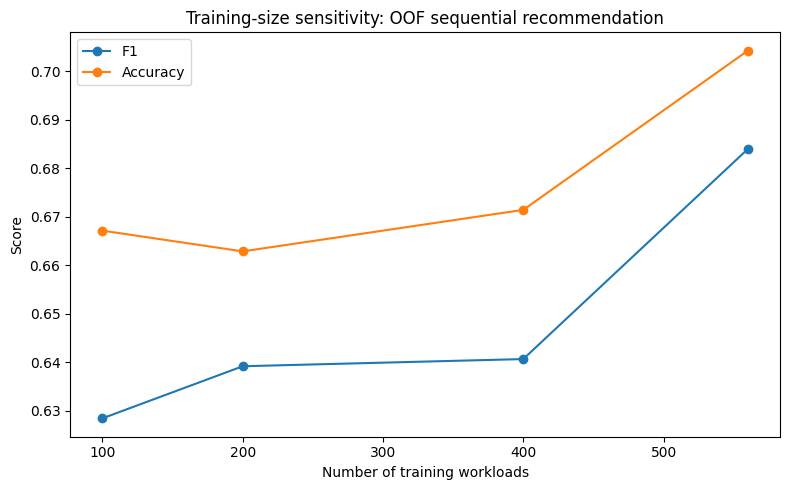

In [73]:
# ============================================================
# 23.5 Training-size sensitivity under the OOF sequential recommendation regime
# ============================================================

from sklearn.base import clone
from sklearn.model_selection import GroupKFold

training_size_candidates = [100, 200, 400, train_df["workload_id"].nunique()]
training_size_candidates = sorted(set(
    int(x) for x in training_size_candidates
    if int(x) <= train_df["workload_id"].nunique()
))

training_size_rows = []
train_workload_ids = np.array(sorted(train_df["workload_id"].unique()))

for n_train_workloads in training_size_candidates:
    local_rng = np.random.default_rng(SEED + n_train_workloads)
    sampled_workloads = local_rng.choice(
        train_workload_ids,
        size=n_train_workloads,
        replace=False,
    )
    sub_train = train_df[train_df["workload_id"].isin(sampled_workloads)].copy()

    sub_train["oof_total_runtime_sec"] = np.nan
    sub_train["oof_expected_fidelity"] = np.nan

    n_inner_folds = min(N_OOF_FOLDS, sub_train["workload_id"].nunique())
    if n_inner_folds < 2:
        raise ValueError("Training-size sensitivity requires at least two workload groups.")

    runtime_template = Pipeline([
        ("prep", clone(preprocess_reg)),
        ("model", RandomForestRegressor(
            n_estimators=50,
            random_state=SEED + n_train_workloads,
            min_samples_leaf=3,
            n_jobs=1,
        )),
    ])
    fidelity_template = Pipeline([
        ("prep", clone(preprocess_reg)),
        ("model", RandomForestRegressor(
            n_estimators=50,
            random_state=SEED + n_train_workloads + 1000,
            min_samples_leaf=3,
            n_jobs=1,
        )),
    ])

    inner_cv = GroupKFold(n_splits=n_inner_folds)
    for inner_tr_idx, inner_va_idx in inner_cv.split(
        sub_train,
        sub_train["recommended_execution"],
        groups=sub_train["workload_id"],
    ):
        inner_tr = sub_train.iloc[inner_tr_idx]
        inner_va = sub_train.iloc[inner_va_idx]

        rt = clone(runtime_template)
        fd = clone(fidelity_template)
        rt.fit(inner_tr[base_features], inner_tr["total_runtime_sec"])
        fd.fit(inner_tr[base_features], inner_tr["expected_fidelity"])

        sub_train.loc[inner_va.index, "oof_total_runtime_sec"] = rt.predict(
            inner_va[base_features]
        )
        sub_train.loc[inner_va.index, "oof_expected_fidelity"] = fd.predict(
            inner_va[base_features]
        ).clip(0, 1)

    # Fit final regressors only on the selected training workloads.
    rt_final = clone(runtime_template)
    fd_final = clone(fidelity_template)
    rt_final.fit(sub_train[base_features], sub_train["total_runtime_sec"])
    fd_final.fit(sub_train[base_features], sub_train["expected_fidelity"])

    test_for_size = test_df.copy()
    test_for_size["pred_total_runtime_sec"] = rt_final.predict(test_for_size[base_features])
    test_for_size["pred_expected_fidelity"] = fd_final.predict(
        test_for_size[base_features]
    ).clip(0, 1)

    X_sub_train = sub_train[classifier_features].copy()
    X_sub_train["total_runtime_sec"] = sub_train["oof_total_runtime_sec"]
    X_sub_train["expected_fidelity"] = sub_train["oof_expected_fidelity"]

    X_size_test = test_for_size[classifier_features].copy()
    X_size_test["total_runtime_sec"] = test_for_size["pred_total_runtime_sec"]
    X_size_test["expected_fidelity"] = test_for_size["pred_expected_fidelity"]

    size_model = Pipeline([
        ("prep", clone(preprocess_clf)),
        ("model", RandomForestClassifier(
            n_estimators=60,
            random_state=SEED + n_train_workloads + 2000,
            class_weight="balanced",
            min_samples_leaf=3,
            n_jobs=1,
        )),
    ])
    size_model.fit(X_sub_train, sub_train["recommended_execution"])
    y_size_pred = size_model.predict(X_size_test)
    y_size_prob = size_model.predict_proba(X_size_test)[:, 1]

    training_size_rows.append({
        "evaluation": "OOF_train_predicted_test_runtime_fidelity",
        "n_train_workloads": n_train_workloads,
        "n_train_pairs": len(sub_train),
        "accuracy": accuracy_score(y_test_clf_oof, y_size_pred),
        "precision": precision_score(y_test_clf_oof, y_size_pred, zero_division=0),
        "recall": recall_score(y_test_clf_oof, y_size_pred, zero_division=0),
        "f1": f1_score(y_test_clf_oof, y_size_pred, zero_division=0),
        "mean_recommendation_probability": float(np.mean(y_size_prob)),
    })

training_size_sensitivity = pd.DataFrame(training_size_rows)
training_size_sensitivity.to_csv(
    TAB_DIR / "training_size_sensitivity.csv",
    index=False,
)

print("Training-size sensitivity under the OOF sequential recommendation information regime:")
display(training_size_sensitivity)

plt.figure(figsize=(8, 5))
plt.plot(
    training_size_sensitivity["n_train_workloads"],
    training_size_sensitivity["f1"],
    marker="o",
    label="F1",
)
plt.plot(
    training_size_sensitivity["n_train_workloads"],
    training_size_sensitivity["accuracy"],
    marker="o",
    label="Accuracy",
)
plt.xlabel("Number of training workloads")
plt.ylabel("Score")
plt.title("Training-size sensitivity: OOF sequential recommendation")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "training_size_sensitivity.png", dpi=180)
plt.show()


## 23.6 Reviewer-response robustness suite

This section addresses the main robustness issues raised during peer review without expanding the study to production-QPU execution.

The analyses have four goals:

1. **Multi-seed stability:** determine whether OOF recommendation metrics and final-selection results are stable across independently regenerated synthetic benchmarks.
2. **Full-pipeline anchoring sensitivity:** evaluate whether the main conclusions depend on the anchoring coefficient \(\alpha\), rather than examining catalog distances alone.
3. **Model-family robustness:** compare a linear classifier, gradient boosting, and random forest under the same OOF recommendation-information regime.
4. **Information-access audit:** distinguish explicit policy-weight access, direct utility-target access, learned acceptability, and single-criterion baselines.

The central estimand remains **internal policy recoverability**. The reportable final-selection pipeline is explicitly described as **OOF prediction + learned acceptability gating + policy-informed weighted ranking**. The suite does not treat it as weight-free, and it does not substitute for external deployment validation on production quantum hardware.


In [74]:
# ============================================================
# 23.6.1 Shared robustness evaluator
# ============================================================

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from scipy.stats import t as student_t, wilcoxon

REVIEW_ROBUSTNESS_SEEDS = (
    [11, 23, 37] if FAST_MODE
    else [11, 23, 37, 51, 73, 89, 101, 127, 151, 181]
)
REVIEW_ROBUSTNESS_RF_TREES = 30 if FAST_MODE else 50
REVIEW_ROBUSTNESS_OOF_FOLDS = 3
REVIEW_ALPHA_SEEDS = [11, 23] if FAST_MODE else [11, 23, 37]


def _review_stage_seeds(master_seed):
    """Derive deterministic, independent RNG substreams from one master seed."""
    seed_sequence = np.random.SeedSequence(int(master_seed))
    children = seed_sequence.spawn(3)
    return tuple(
        int(child.generate_state(1, dtype=np.uint32)[0])
        for child in children
    )


def _review_mean_ci95(values):
    """Return mean, SD, and two-sided 95% t confidence interval."""
    x = pd.to_numeric(pd.Series(values), errors="coerce").dropna().to_numpy(dtype=float)
    n = len(x)
    if n == 0:
        return {"n": 0, "mean": np.nan, "std": np.nan, "ci95_low": np.nan, "ci95_high": np.nan}
    mean = float(np.mean(x))
    if n == 1:
        return {"n": 1, "mean": mean, "std": np.nan, "ci95_low": np.nan, "ci95_high": np.nan}
    std = float(np.std(x, ddof=1))
    half_width = float(student_t.ppf(0.975, df=n - 1) * std / np.sqrt(n))
    return {
        "n": n,
        "mean": mean,
        "std": std,
        "ci95_low": mean - half_width,
        "ci95_high": mean + half_width,
    }


def _review_holm_adjust(p_values):
    """Holm family-wise error correction without an additional dependency."""
    p = np.asarray(p_values, dtype=float)
    adjusted = np.full(len(p), np.nan, dtype=float)
    valid = np.where(np.isfinite(p))[0]
    if len(valid) == 0:
        return adjusted
    order = valid[np.argsort(p[valid])]
    m = len(order)
    running = 0.0
    for rank, idx in enumerate(order):
        candidate = min(1.0, (m - rank) * p[idx])
        running = max(running, candidate)
        adjusted[idx] = running
    return adjusted


def _review_wilcoxon_paired(x, y):
    """Two-sided paired Wilcoxon test with graceful handling of ties/all-zero differences."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < 2:
        return np.nan, np.nan, len(x)
    diff = x - y
    if np.allclose(diff, 0):
        return 0.0, 1.0, len(x)
    result = wilcoxon(x, y, alternative="two-sided", zero_method="wilcox")
    return float(result.statistic), float(result.pvalue), len(x)


def _review_build_dataset(seed, catalog):
    """Regenerate one benchmark realization using independent deterministic substreams."""
    workload_seed, backend_state_seed, outcome_seed = _review_stage_seeds(seed)
    w = generate_workloads(n_workloads=N_WORKLOADS, random_seed=workload_seed)
    data = w.merge(catalog, how="cross")
    data = add_backend_state(
        data,
        random_seed=backend_state_seed,
        catalog=catalog,
    )
    data = simulate_operational_outcomes(
        data,
        random_seed=outcome_seed,
        generate_label=True,
    )
    data = assign_selected_backend(
        data,
        utility_col="decision_utility",
        acceptable_col="recommended_execution",
    )
    return data


def _review_preprocessors(data):
    cat_reg = [c for c in base_features if data[c].dtype == "object"]
    num_reg = [c for c in base_features if c not in cat_reg]
    cat_clf = [c for c in classifier_features if data[c].dtype == "object"]
    num_clf = [c for c in classifier_features if c not in cat_clf]

    reg_prep = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_reg),
        ("num", StandardScaler(), num_reg),
    ])
    clf_prep = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_clf),
        ("num", StandardScaler(), num_clf),
    ])
    return reg_prep, clf_prep


def _review_strategy_metrics(scored, strategy, selected_idx):
    """Compute selection accuracy and true-utility regret for one strategy."""
    selected = scored.loc[
        list(selected_idx), ["workload_id", "backend", "decision_utility"]
    ].rename(columns={
        "backend": "strategy_backend",
        "decision_utility": "strategy_true_utility",
    })
    truth = scored.loc[
        scored["selected_backend"].eq(1),
        ["workload_id", "backend", "decision_utility"],
    ].rename(columns={
        "backend": "true_backend",
        "decision_utility": "true_selected_utility",
    })
    merged = truth.merge(selected, on="workload_id", how="inner")
    merged["top1_correct"] = merged["true_backend"].eq(merged["strategy_backend"])
    merged["utility_regret"] = (
        merged["true_selected_utility"] - merged["strategy_true_utility"]
    ).clip(lower=0)

    return {
        "strategy": strategy,
        "Top-1 accuracy": float(merged["top1_correct"].mean()),
        "mean_regret": float(merged["utility_regret"].mean()),
        "median_regret": float(merged["utility_regret"].median()),
        "p90_regret": float(merged["utility_regret"].quantile(0.90)),
        "low_regret_rate_le_0_03": float((merged["utility_regret"] <= 0.03).mean()),
        "n_workloads": int(merged["workload_id"].nunique()),
    }



def _review_evaluate_realization(seed, catalog, alpha_label=None):
    """Evaluate one complete OOF recommendation + policy-informed selection realization.

    Runtime and fidelity are predicted out of fold for classifier training. Test-time
    classification uses predicted runtime/fidelity. The primary final selector then
    applies learned acceptability gating and an explicit policy-weighted utility proxy.
    """
    data = _review_build_dataset(seed, catalog)
    reg_prep, clf_prep = _review_preprocessors(data)

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.20,
        random_state=seed,
    )
    tr_idx, te_idx = next(
        splitter.split(data, data["recommended_execution"], groups=data["workload_id"])
    )
    tr = data.iloc[tr_idx].copy()
    te = data.iloc[te_idx].copy()

    runtime_template = Pipeline([
        ("prep", reg_prep),
        ("model", RandomForestRegressor(
            n_estimators=REVIEW_ROBUSTNESS_RF_TREES,
            random_state=seed,
            min_samples_leaf=3,
            n_jobs=1,
        )),
    ])
    fidelity_template = Pipeline([
        ("prep", reg_prep),
        ("model", RandomForestRegressor(
            n_estimators=REVIEW_ROBUSTNESS_RF_TREES,
            random_state=seed + 1000,
            min_samples_leaf=3,
            n_jobs=1,
        )),
    ])

    tr["oof_total_runtime_sec"] = np.nan
    tr["oof_expected_fidelity"] = np.nan

    n_groups = tr["workload_id"].nunique()
    n_splits = min(REVIEW_ROBUSTNESS_OOF_FOLDS, n_groups)
    if n_splits < 2:
        raise ValueError("At least two training workloads are required for OOF evaluation.")

    inner = GroupKFold(n_splits=n_splits)
    for inner_tr_idx, inner_va_idx in inner.split(
        tr, tr["recommended_execution"], groups=tr["workload_id"]
    ):
        inner_tr = tr.iloc[inner_tr_idx]
        inner_va = tr.iloc[inner_va_idx]

        rt = clone(runtime_template)
        fd = clone(fidelity_template)
        rt.fit(inner_tr[base_features], inner_tr["total_runtime_sec"])
        fd.fit(inner_tr[base_features], inner_tr["expected_fidelity"])

        tr.loc[inner_va.index, "oof_total_runtime_sec"] = rt.predict(
            inner_va[base_features]
        )
        tr.loc[inner_va.index, "oof_expected_fidelity"] = fd.predict(
            inner_va[base_features]
        ).clip(0, 1)

    rt_final = clone(runtime_template)
    fd_final = clone(fidelity_template)
    rt_final.fit(tr[base_features], tr["total_runtime_sec"])
    fd_final.fit(tr[base_features], tr["expected_fidelity"])

    te["pred_total_runtime_sec"] = rt_final.predict(te[base_features])
    te["pred_expected_fidelity"] = fd_final.predict(te[base_features]).clip(0, 1)

    X_tr = tr[classifier_features].copy()
    X_tr["total_runtime_sec"] = tr["oof_total_runtime_sec"]
    X_tr["expected_fidelity"] = tr["oof_expected_fidelity"]

    X_te = te[classifier_features].copy()
    X_te["total_runtime_sec"] = te["pred_total_runtime_sec"]
    X_te["expected_fidelity"] = te["pred_expected_fidelity"]

    clf = Pipeline([
        ("prep", clf_prep),
        ("model", RandomForestClassifier(
            n_estimators=REVIEW_ROBUSTNESS_RF_TREES,
            random_state=seed + 2000,
            class_weight="balanced",
            min_samples_leaf=3,
            n_jobs=1,
        )),
    ])
    clf.fit(X_tr, tr["recommended_execution"])
    pred = clf.predict(X_te)
    prob = clf.predict_proba(X_te)[:, 1]

    scored = te.copy()
    scored["predicted_total_runtime_sec"] = te["pred_total_runtime_sec"]
    scored["predicted_fidelity"] = te["pred_expected_fidelity"]
    scored["recommendation_probability"] = prob
    scored = add_policy_informed_predicted_utility(
        scored,
        fidelity_col="predicted_fidelity",
        runtime_col="predicted_total_runtime_sec",
        score_col="policy_informed_predicted_utility",
    )

    # Primary selector: learned acceptability gating + explicit policy-weighted ranking.
    scored = add_predicted_selection(
        scored,
        prob_col="recommendation_probability",
        score_col="policy_informed_predicted_utility",
        threshold=0.5,
    )

    pred_idx = scored.loc[scored["predicted_selected_backend"].eq(1)].index
    primary_sel = _review_strategy_metrics(
        scored,
        "ML_OOF_classifier_gated_policy_weighted",
        pred_idx,
    )

    strategy_rows = [
        primary_sel,
        _review_strategy_metrics(
            scored,
            "policy_informed_weighted_no_classifier",
            scored.groupby("workload_id")["policy_informed_predicted_utility"].idxmax(),
        ),
        _review_strategy_metrics(
            scored,
            "ML_OOF_probability_only_selection",
            scored.groupby("workload_id")["recommendation_probability"].idxmax(),
        ),
        _review_strategy_metrics(
            scored,
            "heuristic_min_predicted_runtime",
            scored.groupby("workload_id")["predicted_total_runtime_sec"].idxmin(),
        ),
        _review_strategy_metrics(
            scored,
            "heuristic_max_predicted_fidelity",
            scored.groupby("workload_id")["predicted_fidelity"].idxmax(),
        ),
        _review_strategy_metrics(
            scored,
            "heuristic_min_total_cost",
            scored.groupby("workload_id")["total_cost"].idxmin(),
        ),
        _review_strategy_metrics(
            scored,
            "heuristic_min_failure_probability",
            scored.groupby("workload_id")["failure_probability"].idxmin(),
        ),
    ]

    strategy_access = {
        "ML_OOF_classifier_gated_policy_weighted": (True, False, True, "primary policy-informed hybrid selector"),
        "policy_informed_weighted_no_classifier": (True, False, False, "controlled policy-weighted reference"),
        "ML_OOF_probability_only_selection": (False, False, True, "learned no-explicit-weight baseline"),
        "heuristic_min_predicted_runtime": (False, False, False, "single-criterion heuristic"),
        "heuristic_max_predicted_fidelity": (False, False, False, "single-criterion heuristic"),
        "heuristic_min_total_cost": (False, False, False, "single-criterion heuristic"),
        "heuristic_min_failure_probability": (False, False, False, "single-criterion heuristic"),
    }
    for row in strategy_rows:
        weights, utility_target, gating, role = strategy_access[row["strategy"]]
        row["seed"] = seed
        row["alpha"] = alpha_label
        row["explicit_policy_weights"] = weights
        row["direct_utility_target_training"] = utility_target
        row["learned_acceptability_gating"] = gating
        row["information_role"] = role

    metrics = {
        "seed": seed,
        "alpha": alpha_label,
        "n_workloads": int(data["workload_id"].nunique()),
        "n_pairs": int(len(data)),
        "Accuracy": accuracy_score(te["recommended_execution"], pred),
        "Precision": precision_score(te["recommended_execution"], pred, zero_division=0),
        "Recall": recall_score(te["recommended_execution"], pred, zero_division=0),
        "F1": f1_score(te["recommended_execution"], pred, zero_division=0),
        "runtime_MAE": mean_absolute_error(te["total_runtime_sec"], te["pred_total_runtime_sec"]),
        "runtime_RMSE": mean_squared_error(te["total_runtime_sec"], te["pred_total_runtime_sec"]) ** 0.5,
        "runtime_R2": r2_score(te["total_runtime_sec"], te["pred_total_runtime_sec"]),
        "fidelity_MAE": mean_absolute_error(te["expected_fidelity"], te["pred_expected_fidelity"]),
        "fidelity_RMSE": mean_squared_error(te["expected_fidelity"], te["pred_expected_fidelity"]) ** 0.5,
        "fidelity_R2": r2_score(te["expected_fidelity"], te["pred_expected_fidelity"]),
        "selection_Top1": primary_sel["Top-1 accuracy"],
        "selection_mean_regret": primary_sel["mean_regret"],
        "selection_p90_regret": primary_sel["p90_regret"],
        "selection_explicit_policy_weights": True,
    }
    return metrics, pd.DataFrame(strategy_rows)


### 23.6.2 Multi-seed robustness

The benchmark is regenerated independently for each master seed. Within each realization, independent deterministic RNG substreams are used for workload generation, backend-state generation, and operational-outcome generation.

For the full open-science run, ten master seeds are evaluated. Primary recommendation and selection metrics are reported as mean, sample standard deviation, and **95% t confidence intervals**.

The paired inferential test is now restricted to one controlled question: **does learned acceptability gating change the result when both strategies use the same predicted operational quantities and the same explicit synthetic policy-weighted ranking score?** The comparison is therefore between `ML_OOF_classifier_gated_policy_weighted` and `policy_informed_weighted_no_classifier`. Two-sided paired Wilcoxon tests are reported for Top-1 accuracy and mean regret, with Holm correction across these two outcomes.

Other comparisons (probability-only learning, single-criterion heuristics, direct utility learning, TOPSIS, and Pareto) remain descriptive because their information access or optimization target differs.


seed=11: F1=0.701, Top1=0.600, regret=0.0098
seed=23: F1=0.680, Top1=0.614, regret=0.0118
seed=37: F1=0.702, Top1=0.521, regret=0.0163
seed=51: F1=0.711, Top1=0.521, regret=0.0101
seed=73: F1=0.691, Top1=0.607, regret=0.0100
seed=89: F1=0.699, Top1=0.579, regret=0.0140
seed=101: F1=0.687, Top1=0.586, regret=0.0105
seed=127: F1=0.669, Top1=0.471, regret=0.0128
seed=151: F1=0.680, Top1=0.571, regret=0.0117
seed=181: F1=0.700, Top1=0.593, regret=0.0101

Multi-seed metric summary with 95% CIs:


,metric,n,mean,std,ci95_low,ci95_high,min,max
0,Accuracy,10,0.703286,0.011250,0.695238,0.711333,0.687143,0.721429
1,Precision,10,0.624934,0.017116,0.612690,0.637178,0.590909,0.644886
2,Recall,10,0.776370,0.034903,0.751402,0.801339,0.718354,0.831081
3,F1,10,0.691859,0.012928,0.682611,0.701108,0.668684,0.710526
4,runtime_MAE,10,31.804603,1.762143,30.544042,33.065164,29.790902,35.974256
5,runtime_RMSE,10,50.327772,3.213678,48.028845,52.626699,46.081897,57.865368
6,runtime_R2,10,0.991165,0.001643,0.989989,0.992340,0.987705,0.994191
7,fidelity_MAE,10,0.028945,0.000532,0.028564,0.029326,0.028221,0.029814
8,fidelity_RMSE,10,0.042373,0.001141,0.041557,0.043189,0.040945,0.044663
9,fidelity_R2,10,0.949360,0.003021,0.947199,0.951521,0.946191,0.955775



Descriptive strategy stability across seeds, with information access shown:


,strategy,n_seeds,explicit_policy_weights,direct_utility_target_training,learned_acceptability_gating,information_role,top1_mean,top1_std,top1_ci95_low,top1_ci95_high,regret_mean,regret_std,regret_ci95_low,regret_ci95_high,p90_regret_mean,low_regret_rate_mean,mean_regret_rank,mean_top1_rank
0,policy_informed_weighted_no_classifier,10,True,False,False,controlled policy-weighted reference,0.584286,0.056825,0.543636,0.624936,0.009903,0.002188,0.008337,0.011468,0.040284,0.865000,1.1,1.25
1,ML_OOF_classifier_gated_policy_weighted,10,True,False,True,primary policy-informed hybrid selector,0.566429,0.046419,0.533222,0.599635,0.011718,0.002118,0.010203,0.013233,0.046021,0.845714,1.9,1.75
2,ML_OOF_probability_only_selection,10,False,False,True,learned no-explicit-weight baseline,0.433571,0.035959,0.407848,0.459295,0.032094,0.009271,0.025462,0.038727,0.097299,0.708571,3.0,3.75
3,heuristic_min_failure_probability,10,False,False,False,single-criterion heuristic,0.434286,0.055308,0.394721,0.473851,0.058515,0.011427,0.050340,0.066689,0.260087,0.692857,4.0,3.50
4,heuristic_min_predicted_runtime,10,False,False,False,single-criterion heuristic,0.337857,0.056046,0.297764,0.377950,0.065419,0.010119,0.058181,0.072658,0.263340,0.602857,5.2,6.00
5,heuristic_max_predicted_fidelity,10,False,False,False,single-criterion heuristic,0.395714,0.041404,0.366096,0.425333,0.066501,0.011454,0.058307,0.074694,0.270432,0.630714,5.8,4.95
6,heuristic_min_total_cost,10,False,False,False,single-criterion heuristic,0.272857,0.042698,0.242313,0.303402,0.091978,0.013663,0.082204,0.101751,0.311923,0.475000,7.0,6.80



Controlled paired Wilcoxon test: policy-weighted selector with vs without classifier gating:


,primary_strategy,comparator,comparison_type,same_explicit_policy_weights,same_policy_weighted_score,metric,direction,n_paired_seeds,mean_gated,mean_ungated,mean_difference_gated_minus_ungated,median_difference_gated_minus_ungated,wilcoxon_statistic,p_value_raw,p_value_holm,significant_holm_0_05
0,ML_OOF_classifier_gated_policy_weighted,policy_informed_weighted_no_classifier,controlled_classifier_gating_ablation,True,True,Top-1 accuracy,higher_is_better,10,0.566429,0.584286,-0.017857,-0.021429,3.0,0.019531,0.019531,True
1,ML_OOF_classifier_gated_policy_weighted,policy_informed_weighted_no_classifier,controlled_classifier_gating_ablation,True,True,mean_regret,lower_is_better,10,0.011718,0.009903,0.001816,0.001713,2.0,0.005859,0.011719,True


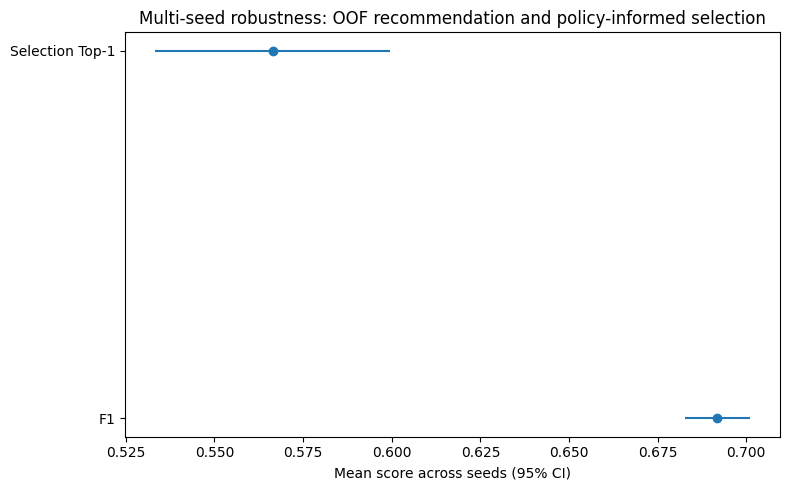

In [75]:
# ============================================================
# 23.6.2 Multi-seed robustness, confidence intervals, and controlled paired tests
# ============================================================

multi_seed_metric_rows = []
multi_seed_strategy_frames = []

for robustness_seed in REVIEW_ROBUSTNESS_SEEDS:
    metrics_seed, strategies_seed = _review_evaluate_realization(
        seed=robustness_seed,
        catalog=backend_catalog,
        alpha_label=ANCHOR_BLEND_ALPHA,
    )
    multi_seed_metric_rows.append(metrics_seed)
    multi_seed_strategy_frames.append(strategies_seed)
    print(
        f"seed={robustness_seed}: "
        f"F1={metrics_seed['F1']:.3f}, "
        f"Top1={metrics_seed['selection_Top1']:.3f}, "
        f"regret={metrics_seed['selection_mean_regret']:.4f}"
    )

multi_seed_results = pd.DataFrame(multi_seed_metric_rows)
multi_seed_strategy_results = pd.concat(multi_seed_strategy_frames, ignore_index=True)

summary_metrics = [
    "Accuracy", "Precision", "Recall", "F1",
    "runtime_MAE", "runtime_RMSE", "runtime_R2",
    "fidelity_MAE", "fidelity_RMSE", "fidelity_R2",
    "selection_Top1", "selection_mean_regret", "selection_p90_regret",
]

multi_seed_summary_rows = []
for metric in summary_metrics:
    stats = _review_mean_ci95(multi_seed_results[metric])
    multi_seed_summary_rows.append({
        "metric": metric,
        **stats,
        "min": float(multi_seed_results[metric].min()),
        "max": float(multi_seed_results[metric].max()),
    })
multi_seed_summary = pd.DataFrame(multi_seed_summary_rows)

# Strategy-order stability is descriptive because strategies differ in information access.
strategy_seed_ranks = multi_seed_strategy_results.copy()
strategy_seed_ranks["regret_rank_within_seed"] = (
    strategy_seed_ranks.groupby("seed")["mean_regret"].rank(method="average", ascending=True)
)
strategy_seed_ranks["top1_rank_within_seed"] = (
    strategy_seed_ranks.groupby("seed")["Top-1 accuracy"].rank(method="average", ascending=False)
)

strategy_summary_rows = []
for strategy, g in strategy_seed_ranks.groupby("strategy", sort=False):
    top1_stats = _review_mean_ci95(g["Top-1 accuracy"])
    regret_stats = _review_mean_ci95(g["mean_regret"])
    strategy_summary_rows.append({
        "strategy": strategy,
        "n_seeds": int(g["seed"].nunique()),
        "explicit_policy_weights": bool(g["explicit_policy_weights"].iloc[0]),
        "direct_utility_target_training": bool(g["direct_utility_target_training"].iloc[0]),
        "learned_acceptability_gating": bool(g["learned_acceptability_gating"].iloc[0]),
        "information_role": g["information_role"].iloc[0],
        "top1_mean": top1_stats["mean"],
        "top1_std": top1_stats["std"],
        "top1_ci95_low": top1_stats["ci95_low"],
        "top1_ci95_high": top1_stats["ci95_high"],
        "regret_mean": regret_stats["mean"],
        "regret_std": regret_stats["std"],
        "regret_ci95_low": regret_stats["ci95_low"],
        "regret_ci95_high": regret_stats["ci95_high"],
        "p90_regret_mean": float(g["p90_regret"].mean()),
        "low_regret_rate_mean": float(g["low_regret_rate_le_0_03"].mean()),
        "mean_regret_rank": float(g["regret_rank_within_seed"].mean()),
        "mean_top1_rank": float(g["top1_rank_within_seed"].mean()),
    })

multi_seed_strategy_summary = (
    pd.DataFrame(strategy_summary_rows)
    .sort_values(["mean_regret_rank", "regret_mean"])
    .reset_index(drop=True)
)

# Controlled paired comparison: same explicit policy score, with vs without classifier gating.
primary_strategy = "ML_OOF_classifier_gated_policy_weighted"
controlled_comparator = "policy_informed_weighted_no_classifier"

primary = multi_seed_strategy_results[
    multi_seed_strategy_results["strategy"].eq(primary_strategy)
][["seed", "Top-1 accuracy", "mean_regret"]].copy()
comp = multi_seed_strategy_results[
    multi_seed_strategy_results["strategy"].eq(controlled_comparator)
][["seed", "Top-1 accuracy", "mean_regret"]].copy()
merged = primary.merge(comp, on="seed", suffixes=("_gated", "_ungated"))

paired_test_rows = []
for metric, direction in [
    ("Top-1 accuracy", "higher_is_better"),
    ("mean_regret", "lower_is_better"),
]:
    x = merged[f"{metric}_gated"]
    y = merged[f"{metric}_ungated"]
    statistic, p_value, n_pairs = _review_wilcoxon_paired(x, y)
    diff = x.to_numpy(dtype=float) - y.to_numpy(dtype=float)
    paired_test_rows.append({
        "primary_strategy": primary_strategy,
        "comparator": controlled_comparator,
        "comparison_type": "controlled_classifier_gating_ablation",
        "same_explicit_policy_weights": True,
        "same_policy_weighted_score": True,
        "metric": metric,
        "direction": direction,
        "n_paired_seeds": n_pairs,
        "mean_gated": float(np.mean(x)),
        "mean_ungated": float(np.mean(y)),
        "mean_difference_gated_minus_ungated": float(np.mean(diff)),
        "median_difference_gated_minus_ungated": float(np.median(diff)),
        "wilcoxon_statistic": statistic,
        "p_value_raw": p_value,
    })

multi_seed_paired_tests = pd.DataFrame(paired_test_rows)
if not multi_seed_paired_tests.empty:
    multi_seed_paired_tests["p_value_holm"] = _review_holm_adjust(
        multi_seed_paired_tests["p_value_raw"].to_numpy(dtype=float)
    )
    multi_seed_paired_tests["significant_holm_0_05"] = multi_seed_paired_tests["p_value_holm"] < 0.05

multi_seed_results.to_csv(TAB_DIR / "review_multi_seed_results.csv", index=False)
multi_seed_summary.to_csv(TAB_DIR / "review_multi_seed_summary.csv", index=False)
multi_seed_strategy_results.to_csv(TAB_DIR / "review_multi_seed_strategy_results.csv", index=False)
multi_seed_strategy_summary.to_csv(TAB_DIR / "review_multi_seed_strategy_summary.csv", index=False)
multi_seed_paired_tests.to_csv(TAB_DIR / "review_classifier_gating_paired_wilcoxon_holm.csv", index=False)

print("\nMulti-seed metric summary with 95% CIs:")
display(multi_seed_summary)

print("\nDescriptive strategy stability across seeds, with information access shown:")
display(multi_seed_strategy_summary)

print("\nControlled paired Wilcoxon test: policy-weighted selector with vs without classifier gating:")
display(multi_seed_paired_tests)

plot_summary = multi_seed_summary.set_index("metric")
plot_metrics = ["F1", "selection_Top1"]
plot_means = [plot_summary.loc[m, "mean"] for m in plot_metrics]
plot_low = [plot_summary.loc[m, "mean"] - plot_summary.loc[m, "ci95_low"] for m in plot_metrics]
plot_high = [plot_summary.loc[m, "ci95_high"] - plot_summary.loc[m, "mean"] for m in plot_metrics]

plt.figure(figsize=(8, 5))
plt.errorbar(plot_means, [0, 1], xerr=np.array([plot_low, plot_high]), fmt="o")
plt.yticks([0, 1], ["F1", "Selection Top-1"])
plt.xlabel("Mean score across seeds (95% CI)")
plt.title("Multi-seed robustness: OOF recommendation and policy-informed selection")
plt.tight_layout()
plt.savefig(FIG_DIR / "review_multi_seed_primary_metrics.png", dpi=180)
plt.show()


### 23.6.3 Full-pipeline sensitivity to the anchoring coefficient \(\alpha\)

The earlier catalog analysis shows how QPU parameters move toward the external reference as \(\alpha\) changes. The open-science analysis below asks whether OOF recommendation metrics and the **classifier-gated policy-weighted final-selection results** remain stable when the entire benchmark is regenerated under different anchoring strengths.

Each anchoring coefficient is evaluated on **three independent master seeds** in the full run. Results are summarized by mean, sample standard deviation, and 95% confidence intervals. Strategy-order tables are descriptive because the compared strategies do not all have the same information access. The purpose is sensitivity analysis, not selection of an “optimal” \(\alpha\).


In [ ]:
# ============================================================
# 23.6.3 Full-pipeline anchoring sensitivity across multiple seeds
# ============================================================

FULL_PIPELINE_ALPHA_VALUES = list(ANCHOR_ALPHA_SENSITIVITY_VALUES)
FULL_PIPELINE_ALPHA_SEEDS = list(REVIEW_ALPHA_SEEDS)

alpha_pipeline_metric_rows = []
alpha_pipeline_strategy_frames = []

for alpha_value in FULL_PIPELINE_ALPHA_VALUES:
    alpha_catalog = calibrate_qpu_backend_catalog(
        backend_catalog_raw,
        qpu_generation_anchor_reference,
        alpha=float(alpha_value),
    )
    for alpha_seed in FULL_PIPELINE_ALPHA_SEEDS:
        metrics_alpha, strategies_alpha = _review_evaluate_realization(
            seed=alpha_seed,
            catalog=alpha_catalog,
            alpha_label=float(alpha_value),
        )
        alpha_pipeline_metric_rows.append(metrics_alpha)
        alpha_pipeline_strategy_frames.append(strategies_alpha)
        print(
            f"alpha={alpha_value:.2f}, seed={alpha_seed}: "
            f"F1={metrics_alpha['F1']:.3f}, "
            f"Top1={metrics_alpha['selection_Top1']:.3f}, "
            f"regret={metrics_alpha['selection_mean_regret']:.4f}"
        )

alpha_pipeline_results_per_seed = pd.DataFrame(alpha_pipeline_metric_rows)
alpha_pipeline_strategy_results = pd.concat(
    alpha_pipeline_strategy_frames,
    ignore_index=True,
)

alpha_summary_metrics = [
    "Accuracy", "F1", "runtime_R2", "fidelity_R2",
    "selection_Top1", "selection_mean_regret", "selection_p90_regret",
]

alpha_summary_rows = []
for alpha_value, g in alpha_pipeline_results_per_seed.groupby("alpha", sort=True):
    row = {"alpha": float(alpha_value), "n_seeds": int(g["seed"].nunique())}
    for metric in alpha_summary_metrics:
        stats = _review_mean_ci95(g[metric])
        row[f"{metric}_mean"] = stats["mean"]
        row[f"{metric}_std"] = stats["std"]
        row[f"{metric}_ci95_low"] = stats["ci95_low"]
        row[f"{metric}_ci95_high"] = stats["ci95_high"]
    alpha_summary_rows.append(row)

alpha_pipeline_sensitivity = pd.DataFrame(alpha_summary_rows).sort_values("alpha").reset_index(drop=True)

# Rank strategies within each alpha/seed realization before aggregating.
alpha_strategy_rank = alpha_pipeline_strategy_results.copy()
alpha_strategy_rank["regret_rank_within_realization"] = (
    alpha_strategy_rank.groupby(["alpha", "seed"])["mean_regret"]
    .rank(method="average", ascending=True)
)
alpha_strategy_rank["top1_rank_within_realization"] = (
    alpha_strategy_rank.groupby(["alpha", "seed"])["Top-1 accuracy"]
    .rank(method="average", ascending=False)
)

alpha_strategy_by_alpha_rows = []
for (alpha_value, strategy), g in alpha_strategy_rank.groupby(["alpha", "strategy"], sort=False):
    top1_stats = _review_mean_ci95(g["Top-1 accuracy"])
    regret_stats = _review_mean_ci95(g["mean_regret"])
    alpha_strategy_by_alpha_rows.append({
        "alpha": float(alpha_value),
        "strategy": strategy,
        "n_seeds": int(g["seed"].nunique()),
        "top1_mean": top1_stats["mean"],
        "top1_ci95_low": top1_stats["ci95_low"],
        "top1_ci95_high": top1_stats["ci95_high"],
        "regret_mean": regret_stats["mean"],
        "regret_ci95_low": regret_stats["ci95_low"],
        "regret_ci95_high": regret_stats["ci95_high"],
        "mean_regret_rank": float(g["regret_rank_within_realization"].mean()),
        "mean_top1_rank": float(g["top1_rank_within_realization"].mean()),
    })
alpha_strategy_by_alpha = pd.DataFrame(alpha_strategy_by_alpha_rows)

alpha_strategy_stability = (
    alpha_strategy_rank
    .groupby("strategy", as_index=False)
    .agg(
        top1_mean=("Top-1 accuracy", "mean"),
        top1_min=("Top-1 accuracy", "min"),
        top1_max=("Top-1 accuracy", "max"),
        regret_mean=("mean_regret", "mean"),
        regret_min=("mean_regret", "min"),
        regret_max=("mean_regret", "max"),
        mean_regret_rank=("regret_rank_within_realization", "mean"),
        mean_top1_rank=("top1_rank_within_realization", "mean"),
    )
    .sort_values(["mean_regret_rank", "regret_mean"])
    .reset_index(drop=True)
)

alpha_pipeline_results_per_seed.to_csv(
    TAB_DIR / "review_full_pipeline_alpha_sensitivity_per_seed.csv",
    index=False,
)
alpha_pipeline_sensitivity.to_csv(
    TAB_DIR / "review_full_pipeline_alpha_sensitivity.csv",
    index=False,
)
alpha_pipeline_strategy_results.to_csv(
    TAB_DIR / "review_alpha_strategy_results.csv",
    index=False,
)
alpha_strategy_by_alpha.to_csv(
    TAB_DIR / "review_alpha_strategy_by_alpha.csv",
    index=False,
)
alpha_strategy_stability.to_csv(
    TAB_DIR / "review_alpha_strategy_stability.csv",
    index=False,
)

print("\nFull-pipeline alpha sensitivity across seeds:")
display(alpha_pipeline_sensitivity)

print("\nStrategy-order stability across alpha and seed realizations:")
display(alpha_strategy_stability)

alpha_plot = alpha_pipeline_sensitivity.sort_values("alpha")
for metric, label in [("F1", "F1"), ("selection_Top1", "Selection Top-1")]:
    means = alpha_plot[f"{metric}_mean"].to_numpy(dtype=float)
    lows = means - alpha_plot[f"{metric}_ci95_low"].to_numpy(dtype=float)
    highs = alpha_plot[f"{metric}_ci95_high"].to_numpy(dtype=float) - means
    plt.errorbar(
        alpha_plot["alpha"],
        means,
        yerr=np.array([lows, highs]),
        marker="o",
        label=label,
    )

plt.xlabel("Anchoring coefficient alpha")
plt.ylabel("Score")
plt.title("Anchoring sensitivity: OOF recommendation and policy-informed selection (95% CI)")
plt.legend()
plt.tight_layout()
plt.savefig(
    FIG_DIR / "review_full_pipeline_alpha_sensitivity.png",
    dpi=180,
)
plt.show()


### 23.6.3a Same-seed downstream sensitivity: frozen IBM anchor versus live credentialed IBM anchor

This analysis holds the synthetic generator, anchoring coefficient, model family, OOF protocol, and master seeds fixed. The only changed input is the superconducting IBM metadata anchor.

The purpose is not to claim that live metadata are "better" than the frozen snapshot. It quantifies how much the main internal-recoverability metrics move when the archived anchor is replaced by the current authenticated Runtime metadata. This directly separates **metadata drift sensitivity** from ordinary random-seed variability.

**Reporting constraint:** the comparison uses only three fixed same-seed realizations and is therefore **descriptive only**. Report mean, SD, range, and paired live-minus-frozen deltas. Do not use this block for significance testing or population-level confidence claims.


### 23.6.4 Model-family robustness under the same OOF recommendation-information regime

This comparison is intentionally compact. It addresses whether the **recommendation classifier** depends uniquely on Random Forest while avoiding a large model-search exercise that would change the paper's contribution.

The three families represent:

- **Logistic Regression:** linear discriminative baseline;
- **Gradient Boosting:** sequential boosting ensemble;
- **Random Forest:** bagging/tree ensemble used in the main pipeline.

All classifiers are trained on the same OOF-predicted runtime/fidelity variables and evaluated with predicted runtime/fidelity at test time. This table compares the recommendation stage only; it does not alter the explicit policy-weight access used later by the final ranking stage.


In [ ]:
# ============================================================
# 23.6.3a Frozen-vs-live anchor downstream comparison
# ============================================================

frozen_pipeline_catalog = calibrate_qpu_backend_catalog(
    backend_catalog_raw,
    open_science_frozen_anchor,
    alpha=ANCHOR_BLEND_ALPHA,
)
live_pipeline_catalog = calibrate_qpu_backend_catalog(
    backend_catalog_raw,
    ibm_backend_metadata_live,
    alpha=ANCHOR_BLEND_ALPHA,
)

anchor_pipeline_rows = []
anchor_strategy_frames = []
for anchor_label, comparison_catalog in [
    ("frozen_2026_07_28", frozen_pipeline_catalog),
    ("live_current_run", live_pipeline_catalog),
]:
    for comparison_seed in IBM_COMPARISON_PIPELINE_SEEDS:
        metrics_cmp, strategies_cmp = _review_evaluate_realization(
            seed=comparison_seed,
            catalog=comparison_catalog,
            alpha_label=ANCHOR_BLEND_ALPHA,
        )
        metrics_cmp["anchor_source"] = anchor_label
        strategies_cmp["anchor_source"] = anchor_label
        anchor_pipeline_rows.append(metrics_cmp)
        anchor_strategy_frames.append(strategies_cmp)
        print(
            f"anchor={anchor_label}, seed={comparison_seed}: "
            f"F1={metrics_cmp['F1']:.3f}, "
            f"Top1={metrics_cmp['selection_Top1']:.3f}, "
            f"regret={metrics_cmp['selection_mean_regret']:.4f}"
        )

ibm_anchor_pipeline_per_seed = pd.DataFrame(anchor_pipeline_rows)
ibm_anchor_strategy_per_seed = pd.concat(anchor_strategy_frames, ignore_index=True)

anchor_summary_metrics = [
    "Accuracy", "F1", "runtime_R2", "fidelity_R2",
    "selection_Top1", "selection_mean_regret", "selection_p90_regret",
]
anchor_summary_rows = []
for anchor_source, g in ibm_anchor_pipeline_per_seed.groupby("anchor_source", sort=False):
    row = {
        "anchor_source": anchor_source,
        "n_seeds": int(g["seed"].nunique()),
        "inference_scope": "descriptive_three_seed_anchor_sensitivity",
    }
    for metric in anchor_summary_metrics:
        values = pd.to_numeric(g[metric], errors="coerce").dropna().to_numpy(dtype=float)
        row[f"{metric}_mean"] = float(np.mean(values)) if len(values) else np.nan
        row[f"{metric}_std"] = float(np.std(values, ddof=1)) if len(values) > 1 else np.nan
        row[f"{metric}_min"] = float(np.min(values)) if len(values) else np.nan
        row[f"{metric}_max"] = float(np.max(values)) if len(values) else np.nan
    anchor_summary_rows.append(row)
ibm_anchor_pipeline_summary = pd.DataFrame(anchor_summary_rows)

# Paired same-seed deltas, descriptive because this comparison uses a small fixed seed set.
frozen_rows = ibm_anchor_pipeline_per_seed[ibm_anchor_pipeline_per_seed["anchor_source"].eq("frozen_2026_07_28")]
live_rows = ibm_anchor_pipeline_per_seed[ibm_anchor_pipeline_per_seed["anchor_source"].eq("live_current_run")]
paired_anchor = frozen_rows.merge(live_rows, on="seed", suffixes=("_frozen", "_live"))
paired_delta_rows = []
for metric in anchor_summary_metrics:
    fcol, lcol = f"{metric}_frozen", f"{metric}_live"
    if fcol not in paired_anchor.columns or lcol not in paired_anchor.columns:
        continue
    delta = paired_anchor[lcol].to_numpy(dtype=float) - paired_anchor[fcol].to_numpy(dtype=float)
    paired_delta_rows.append({
        "metric": metric,
        "n_paired_seeds": int(len(delta)),
        "mean_live_minus_frozen": float(np.mean(delta)),
        "median_live_minus_frozen": float(np.median(delta)),
        "min_live_minus_frozen": float(np.min(delta)),
        "max_live_minus_frozen": float(np.max(delta)),
        "interpretation": "descriptive_same_seed_anchor_drift",
    })
ibm_anchor_pipeline_paired_deltas = pd.DataFrame(paired_delta_rows)

ibm_anchor_pipeline_per_seed.to_csv(TAB_DIR / "review_ibm_frozen_vs_live_anchor_pipeline_per_seed.csv", index=False)
ibm_anchor_pipeline_summary.to_csv(TAB_DIR / "review_ibm_frozen_vs_live_anchor_pipeline_summary.csv", index=False)
ibm_anchor_pipeline_paired_deltas.to_csv(TAB_DIR / "review_ibm_frozen_vs_live_anchor_pipeline_paired_deltas.csv", index=False)
ibm_anchor_strategy_per_seed.to_csv(TAB_DIR / "review_ibm_frozen_vs_live_anchor_strategy_per_seed.csv", index=False)

print("Frozen-vs-live downstream summary:")
display(ibm_anchor_pipeline_summary)
print("Same-seed live-minus-frozen deltas:")
display(ibm_anchor_pipeline_paired_deltas)


In [ ]:
# ============================================================
# 23.6.4 Model-family robustness
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

# Use the already constructed OOF train/test sets from Section 23.
X_train_review_models = X_train_clf_oof.copy()
X_test_review_models = X_test_clf_oof.copy()
y_train_review_models = y_train_clf_oof.copy()
y_test_review_models = y_test_clf_oof.copy()

review_model_specs = {
    "Logistic Regression": LogisticRegression(
        max_iter=1600,
        class_weight="balanced",
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=SEED,
        n_estimators=120,
        learning_rate=0.05,
        max_depth=3,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=80 if FAST_MODE else 120,
        random_state=SEED,
        class_weight="balanced",
        min_samples_leaf=3,
        n_jobs=1,
    ),
}

review_model_rows = []
for model_name, estimator in review_model_specs.items():
    # GradientBoostingClassifier requires dense input; the dataset is small enough
    # for a dense OHE representation in this dedicated robustness check.
    try:
        review_ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        review_ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

    review_prep = ColumnTransformer([
        ("cat", review_ohe, categorical_features_clf),
        ("num", StandardScaler(), numeric_features_clf),
    ])

    pipe = Pipeline([
        ("prep", review_prep),
        ("model", estimator),
    ])
    pipe.fit(X_train_review_models, y_train_review_models)
    pred = pipe.predict(X_test_review_models)

    review_model_rows.append({
        "model": model_name,
        "evaluation": "OOF_train_and_predicted_test_runtime_fidelity",
        "Accuracy": accuracy_score(y_test_review_models, pred),
        "Precision": precision_score(
            y_test_review_models, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test_review_models, pred, zero_division=0
        ),
        "F1": f1_score(
            y_test_review_models, pred, zero_division=0
        ),
    })

review_model_robustness = (
    pd.DataFrame(review_model_rows)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)
review_model_robustness.to_csv(
    TAB_DIR / "review_model_family_robustness.csv",
    index=False,
)

print("Model-family robustness under the OOF recommendation regime:")
display(review_model_robustness)

plt.figure(figsize=(8, 5))
plt.barh(
    review_model_robustness["model"],
    review_model_robustness["F1"],
)
plt.xlabel("F1-score")
plt.title("Model-family robustness: OOF sequential recommendation classification")
plt.tight_layout()
plt.savefig(
    FIG_DIR / "review_model_family_robustness.png",
    dpi=180,
)
plt.show()

### 23.6.5 Information-access audit and interpretation of strategy comparisons

The evaluated methods are **not information-equivalent**. The notebook therefore records information access as part of the result rather than inferring fairness from a strategy name.

- **Single-criterion heuristics** use one observed or predicted operational criterion and no explicit synthetic policy weights.
- **Probability-only OOF learning** uses the learned recommendation probability for selection and does not receive the explicit `w_*` weights at test time, although `decision_profile` remains an observed categorical feature of the classifier.
- **Policy-informed weighted strategies**, including the primary classifier-gated selector, explicitly receive the synthetic `w_*` decision-profile weights at final ranking. The primary selector differs from the no-classifier weighted reference by first predicting runtime/fidelity and applying learned acceptability gating.
- **Policy-informed TOPSIS** also receives the explicit weights and is reported as such.
- **Direct utility rankers** do not require explicit `w_*` weights at test time but learn the synthetic `decision_utility` target directly during training; this is a different form of privileged information.
- **Unweighted Pareto dominance** uses the operational criteria without the `w_*` weights.

The key controlled comparison is therefore not “ML versus all heuristics.” It is the **with-versus-without classifier-gating ablation under the same policy-weighted final score**. Other strategy comparisons are descriptive and interpreted according to the access taxonomy below.


In [ ]:
# ============================================================
# 23.6.5 Information-access taxonomy + consistency audit
# ============================================================

information_access_taxonomy = pd.DataFrame([
    {
        "strategy_family": "single_criterion_heuristic",
        "examples": "min runtime; max fidelity; min cost; min failure",
        "test_time_information": "one observed or predicted operational criterion",
        "explicit_synthetic_policy_weights": False,
        "direct_utility_target_used_for_training": False,
        "learned_acceptability_gating": False,
        "interpretive_role": "weak baseline; descriptive comparison",
    },
    {
        "strategy_family": "probability_only_oof_learning",
        "examples": "ML_OOF_probability_only_selection",
        "test_time_information": "workload/backend/state features plus predicted runtime/fidelity and recommendation probability",
        "explicit_synthetic_policy_weights": False,
        "direct_utility_target_used_for_training": False,
        "learned_acceptability_gating": True,
        "interpretive_role": "learned baseline without explicit w_* at final selection",
    },
    {
        "strategy_family": "policy_informed_weighted_reference",
        "examples": "policy_informed_weighted_no_classifier; policy-informed TOPSIS",
        "test_time_information": "predicted/observed criteria plus explicit decision-profile w_* weights",
        "explicit_synthetic_policy_weights": True,
        "direct_utility_target_used_for_training": False,
        "learned_acceptability_gating": False,
        "interpretive_role": "policy-informed reference",
    },
    {
        "strategy_family": "oof_classifier_gated_policy_weighted",
        "examples": "runtime predictor -> fidelity predictor -> classifier gate -> policy-weighted ranker",
        "test_time_information": "predicted runtime/fidelity, observed operational covariates, recommendation probability, explicit w_* weights",
        "explicit_synthetic_policy_weights": True,
        "direct_utility_target_used_for_training": False,
        "learned_acceptability_gating": True,
        "interpretive_role": "primary hybrid selector; policy-informed at final ranking",
    },
    {
        "strategy_family": "direct_learned_utility",
        "examples": "RF direct utility ranker; Gradient Boosting direct utility ranker",
        "test_time_information": "features plus OOF/predicted operational quantities",
        "explicit_synthetic_policy_weights": False,
        "direct_utility_target_used_for_training": True,
        "learned_acceptability_gating": False,
        "interpretive_role": "privileged direct-target learned comparator",
    },
    {
        "strategy_family": "unweighted_pareto",
        "examples": "pareto_dominance_unweighted_predicted",
        "test_time_information": "multicriteria operational quantities without w_* weights",
        "explicit_synthetic_policy_weights": False,
        "direct_utility_target_used_for_training": False,
        "learned_acceptability_gating": False,
        "interpretive_role": "weight-free multicriteria baseline",
    },
])

information_access_taxonomy.to_csv(TAB_DIR / "review_information_access_taxonomy.csv", index=False)
display(information_access_taxonomy)

# Fail-fast consistency audit: the labels below encode the intended scientific interpretation.
expected_access = {
    "ML_OOF_classifier_gated_policy_weighted": {"explicit_policy_weights": True, "learned_acceptability_gating": True},
    "policy_informed_weighted_no_classifier": {"explicit_policy_weights": True, "learned_acceptability_gating": False},
    "ML_OOF_probability_only_selection": {"explicit_policy_weights": False, "learned_acceptability_gating": True},
}

access_audit_rows = []
for strategy, expected in expected_access.items():
    row = selection_strategy_comparison.loc[selection_strategy_comparison["strategy"].eq(strategy)]
    present = len(row) == 1
    observed_weights = bool(row["explicit_policy_weights"].iloc[0]) if present else None
    observed_gating = bool(row["learned_acceptability_gating"].iloc[0]) if present else None
    passed = (
        present
        and observed_weights == expected["explicit_policy_weights"]
        and observed_gating == expected["learned_acceptability_gating"]
    )
    access_audit_rows.append({
        "strategy": strategy,
        "present": present,
        "expected_explicit_policy_weights": expected["explicit_policy_weights"],
        "observed_explicit_policy_weights": observed_weights,
        "expected_learned_acceptability_gating": expected["learned_acceptability_gating"],
        "observed_learned_acceptability_gating": observed_gating,
        "status": "pass" if passed else "fail",
    })

information_access_consistency_audit = pd.DataFrame(access_audit_rows)
information_access_consistency_audit.to_csv(
    TAB_DIR / "review_information_access_consistency_audit.csv",
    index=False,
)
display(information_access_consistency_audit)

if not information_access_consistency_audit["status"].eq("pass").all():
    raise AssertionError("Information-access labels are inconsistent with the configured strategies.")


## 24. Utility loss in backend ranking

Top-k metrics indicate whether the correct backend appears among the first candidates, but they do not measure the practical cost of an error. In orchestration, missing the Top-1 backend may be operationally minor if the chosen backend has utility close to the best option. Therefore, this section computes utility regret:

\[
\text{regret} = U(\text{backend selected by the synthetic policy}) - U(\text{backend selected by the predictive pipeline}).
\]

Values close to zero indicate low operational impact from the selection error.



In [ ]:
true_selection_utility = (
    selection_eval_df[selection_eval_df["selected_backend"] == 1]
    [["workload_id", "backend", "decision_utility"]]
    .rename(columns={"backend": "true_backend", "decision_utility": "true_selected_utility"})
)

pred_selection_utility = (
    selection_eval_df[selection_eval_df["predicted_selected_backend"] == 1]
    [["workload_id", "backend", "decision_utility", "policy_informed_predicted_utility", "backend_rank_true"]]
    .rename(columns={
        "backend": "predicted_backend",
        "decision_utility": "predicted_selected_true_utility",
        "backend_rank_true": "predicted_backend_true_rank",
    })
)

utility_regret_df = true_selection_utility.merge(pred_selection_utility, on="workload_id", how="inner")
utility_regret_df["utility_regret"] = (
    utility_regret_df["true_selected_utility"] - utility_regret_df["predicted_selected_true_utility"]
)
utility_regret_df["utility_regret"] = utility_regret_df["utility_regret"].clip(lower=0)
utility_regret_df["relative_utility_regret"] = utility_regret_df["utility_regret"] / (
    utility_regret_df["true_selected_utility"].abs() + 1e-9
)
utility_regret_df["same_backend"] = utility_regret_df["true_backend"].eq(utility_regret_df["predicted_backend"])

utility_regret_summary = pd.DataFrame([{
    "mean_regret": utility_regret_df["utility_regret"].mean(),
    "median_regret": utility_regret_df["utility_regret"].median(),
    "p90_regret": utility_regret_df["utility_regret"].quantile(0.90),
    "mean_relative_regret": utility_regret_df["relative_utility_regret"].mean(),
    "median_relative_regret": utility_regret_df["relative_utility_regret"].median(),
    "low_regret_rate_le_0_01": (utility_regret_df["utility_regret"] <= 0.01).mean(),
    "low_regret_rate_le_0_03": (utility_regret_df["utility_regret"] <= 0.03).mean(),
    "low_regret_rate_le_0_05": (utility_regret_df["utility_regret"] <= 0.05).mean(),
    "exact_backend_match_rate": utility_regret_df["same_backend"].mean(),
}])

utility_regret_df.to_csv(TAB_DIR / "utility_regret_by_workload.csv", index=False)
utility_regret_summary.to_csv(TAB_DIR / "utility_regret_summary.csv", index=False)

display(utility_regret_summary)
display(utility_regret_df.head())


In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(utility_regret_df["utility_regret"], bins=25)
plt.xlabel("Utility regret")
plt.ylabel("Number of workloads")
plt.title("Distribution of utility regret in backend selection")
plt.tight_layout()
plt.savefig(FIG_DIR / "utility_regret_distribution.png", dpi=300)
plt.show()
plt.close()


## 25. Subgroup performance analysis

Global analysis may hide performance differences across backends, algorithms, and decision profiles. This section computes subgroup metrics for OOF sequential recommendation classification and for backend selection/ranking.



In [ ]:
def subgroup_classification_metrics(data, y_true, y_pred, group_col):
    rows = []
    temp = data.copy()
    temp["y_true"] = np.asarray(y_true)
    temp["y_pred"] = np.asarray(y_pred)
    for group_value, group in temp.groupby(group_col):
        rows.append({
            "group_type": group_col,
            "group_value": group_value,
            "n": len(group),
            "positive_rate": group["y_true"].mean(),
            "Accuracy": accuracy_score(group["y_true"], group["y_pred"]),
            "Precision": precision_score(group["y_true"], group["y_pred"], zero_division=0),
            "Recall": recall_score(group["y_true"], group["y_pred"], zero_division=0),
            "F1": f1_score(group["y_true"], group["y_pred"], zero_division=0),
        })
    return pd.DataFrame(rows)

subgroup_clf_results = pd.concat([
    subgroup_classification_metrics(test_oof_df, y_test_clf_oof, y_pred_clf_oof_e2e, "backend"),
    subgroup_classification_metrics(test_oof_df, y_test_clf_oof, y_pred_clf_oof_e2e, "backend_family"),
    subgroup_classification_metrics(test_oof_df, y_test_clf_oof, y_pred_clf_oof_e2e, "algorithm"),
    subgroup_classification_metrics(test_oof_df, y_test_clf_oof, y_pred_clf_oof_e2e, "decision_profile"),
], ignore_index=True)

subgroup_clf_results.to_csv(TAB_DIR / "subgroup_classification_metrics.csv", index=False)
subgroup_clf_results


In [ ]:
workload_metadata_test = (
    test_df[["workload_id", "algorithm", "algorithm_family", "decision_profile"]]
    .drop_duplicates("workload_id")
)

selection_workload_eval = (
    selection_pair_eval
    .merge(workload_metadata_test, on="workload_id", how="left")
    .merge(utility_regret_df[["workload_id", "utility_regret", "relative_utility_regret", "predicted_backend_true_rank"]], on="workload_id", how="left")
)

ranking_subgroup_rows = []
for group_col in ["algorithm", "algorithm_family", "decision_profile", "true_backend"]:
    for group_value, group in selection_workload_eval.groupby(group_col):
        ranking_subgroup_rows.append({
            "group_type": group_col,
            "group_value": group_value,
            "n_workloads": len(group),
            "Top1_accuracy": group["top1_correct"].mean(),
            "mean_utility_regret": group["utility_regret"].mean(),
            "median_utility_regret": group["utility_regret"].median(),
            "mean_relative_utility_regret": group["relative_utility_regret"].mean(),
            "low_regret_rate_le_0_03": (group["utility_regret"] <= 0.03).mean(),
            "mean_true_rank_of_predicted_backend": group["predicted_backend_true_rank"].mean(),
        })

subgroup_ranking_results = pd.DataFrame(ranking_subgroup_rows)
subgroup_ranking_results.to_csv(TAB_DIR / "subgroup_ranking_metrics.csv", index=False)
subgroup_ranking_results


In [ ]:
plt.figure(figsize=(9, 5))
plot_df = subgroup_clf_results[subgroup_clf_results["group_type"].eq("backend")].sort_values("F1")
plt.barh(plot_df["group_value"], plot_df["F1"])
plt.xlabel("F1 OOF sequential recommendation")
plt.ylabel("Backend")
plt.title("Classification performance by backend")
plt.tight_layout()
plt.savefig(FIG_DIR / "subgroup_classification_f1_by_backend.png", dpi=300)
plt.show()
plt.close()

plt.figure(figsize=(9, 5))
plot_df = subgroup_ranking_results[subgroup_ranking_results["group_type"].eq("decision_profile")].sort_values("mean_utility_regret")
plt.barh(plot_df["group_value"], plot_df["mean_utility_regret"])
plt.xlabel("Mean utility loss")
plt.ylabel("Decision profile")
plt.title("Utility loss by decision profile")
plt.tight_layout()
plt.savefig(FIG_DIR / "subgroup_utility_regret_by_profile.png", dpi=300)
plt.show()
plt.close()


## 26. External-data plausibility diagnostics and metadata anchoring

This section documents the external reference used by the synthetic benchmark and performs complementary **metadata-level plausibility and range-overlap diagnostics**.

Default open-science evidence hierarchy:

1. **Bundled frozen IBM/Qiskit Runtime metadata snapshot** — canonical reproducibility source.
2. **Optional live IBM/Qiskit Runtime refresh** — treated as a separate current-run comparison, not an exact reproduction.
3. **Qiskit/Aer local circuit checks** — optional operational sanity checks when the package is available.

External metadata are not used as supervised labels and no production-QPU execution outcome is used in the main experiment. The purpose is to anchor selected QPU ranges, quantify metadata drift, and make evidence provenance auditable. These diagnostics must not be reported as deployment validation.


### 26.0 Methodological objective of the external plausibility diagnostics

The external reference asks a limited question:

> To what extent do selected synthetic superconducting-QPU variables overlap, at the metadata/range level, with the IBM/Qiskit reference used to anchor the benchmark?

This is a **range-overlap/plausibility diagnostic**, not an external-validation score. It reduces reliance on unconstrained synthetic ranges but does not transform the dataset into an empirical production-QPU dataset. The evidence-scope table must accompany any interpretation of this analysis.


In [ ]:
# ============================================================
# 26.0 External plausibility diagnostics: packages, directories, and execution mode
# ============================================================

from pathlib import Path
import os
import sys
import time
import json
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

OUTPUT_DIR = Path("outputs_ai_quantum_open_science")
DATA_DIR = OUTPUT_DIR / "data"
TAB_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"
REAL_VALIDATION_DIR = OUTPUT_DIR / "real_validation"
for _d in [DATA_DIR, TAB_DIR, FIG_DIR, REAL_VALIDATION_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

print("External plausibility/sanity-check directory:", REAL_VALIDATION_DIR.resolve())

# Optional installation in pure Python to keep the cell valid outside Colab/IPython.
INSTALL_VALIDATION_PACKAGES_IF_MISSING = False

qiskit_available = False
qiskit_aer_available = False
qiskit_ibm_available = False

def _install_validation_package_if_missing(import_name, pip_name):
    try:
        __import__(import_name)
        return "already_installed"
    except Exception:
        if not INSTALL_VALIDATION_PACKAGES_IF_MISSING:
            return "missing_not_installed"
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", pip_name])
        __import__(import_name)
        return "installed_now"

for _import_name, _pip_name in [("qiskit", "qiskit"), ("qiskit_aer", "qiskit-aer"), ("qiskit_ibm_runtime", "qiskit-ibm-runtime")]:
    print(_pip_name, _install_validation_package_if_missing(_import_name, _pip_name))


try:
    import qiskit
    from qiskit import QuantumCircuit, transpile
    qiskit_available = True
    print("qiskit:", getattr(qiskit, "__version__", "unidentified version"))
except Exception as e:
    print("qiskit unavailable:", type(e).__name__, str(e))

try:
    import qiskit_aer
    from qiskit_aer import AerSimulator
    qiskit_aer_available = True
    print("qiskit-aer:", getattr(qiskit_aer, "__version__", "unidentified version"))
except Exception as e:
    print("qiskit-aer unavailable:", type(e).__name__, str(e))

try:
    import qiskit_ibm_runtime
    from qiskit_ibm_runtime import QiskitRuntimeService
    qiskit_ibm_available = True
    print("qiskit-ibm-runtime:", getattr(qiskit_ibm_runtime, "__version__", "unidentified version"))
except Exception as e:
    print("qiskit-ibm-runtime unavailable:", type(e).__name__, str(e))

package_status = pd.DataFrame([
    {"package": "qiskit", "available": qiskit_available},
    {"package": "qiskit-aer", "available": qiskit_aer_available},
    {"package": "qiskit-ibm-runtime", "available": qiskit_ibm_available},
])

display(package_status)
package_status.to_csv(REAL_VALIDATION_DIR / "package_status.csv", index=False)


In [ ]:
# ============================================================
# 26.1 Loading the main synthetic dataset
# ============================================================

synthetic_df_for_validation = None
for candidate_name in ["df", "data", "dataset"]:
    if candidate_name in globals() and isinstance(globals()[candidate_name], pd.DataFrame):
        synthetic_df_for_validation = globals()[candidate_name].copy()
        print(f"Synthetic dataset found in variable `{candidate_name}`:", synthetic_df_for_validation.shape)
        break

if synthetic_df_for_validation is None:
    candidate_csv = DATA_DIR / "synthetic_quantum_orchestration_v3.csv"
    if candidate_csv.exists():
        synthetic_df_for_validation = pd.read_csv(candidate_csv)
        print("Synthetic dataset loaded from:", candidate_csv, synthetic_df_for_validation.shape)

if synthetic_df_for_validation is None:
    raise RuntimeError(
        "The synthetic dataset was not found. Run the dataset-generation cells before external validation."
    )

# Focus of the external comparison: QPU backends.
if "backend_family" in synthetic_df_for_validation.columns:
    synthetic_qpu_df = synthetic_df_for_validation[
        synthetic_df_for_validation["backend_family"].astype(str).str.lower().eq("qpu")
    ].copy()
else:
    synthetic_qpu_df = synthetic_df_for_validation.copy()

if synthetic_qpu_df.empty:
    synthetic_qpu_df = synthetic_df_for_validation.copy()

print("Synthetic records used in QPU validation:", synthetic_qpu_df.shape)
print("Synthetic backends:", sorted(synthetic_qpu_df.get("backend", pd.Series(dtype=str)).astype(str).unique().tolist()))



In [ ]:
# Open-science rule: local Aer validation is optional and must not make the
# core benchmark depend on network package installation.
try:
    from qiskit import QuantumCircuit, transpile
    from qiskit_aer import AerSimulator
    qiskit_available = True
    qiskit_aer_available = True
except Exception:
    QuantumCircuit = None
    transpile = None
    AerSimulator = None
    qiskit_available = False
    qiskit_aer_available = False
    print("Qiskit/Aer not installed: local circuit sanity check will be skipped. See requirements_open_science_optional_qiskit.txt.")

# ============================================================
# 26.2 Local execution of small circuits with Qiskit/Aer
# ============================================================

def build_ghz_circuit(n_qubits: int):
    qc = QuantumCircuit(n_qubits, n_qubits)
    qc.h(0)
    for i in range(n_qubits - 1):
        qc.cx(i, i + 1)
    qc.measure(range(n_qubits), range(n_qubits))
    return qc


def build_hamiltonian_like_circuit(n_qubits: int, layers: int = 2):
    qc = QuantumCircuit(n_qubits, n_qubits)
    for q in range(n_qubits):
        qc.h(q)
    for _ in range(layers):
        for q in range(n_qubits - 1):
            qc.cx(q, q + 1)
            qc.rz(0.15, q + 1)
            qc.cx(q, q + 1)
        for q in range(n_qubits):
            qc.rx(0.25, q)
    qc.measure(range(n_qubits), range(n_qubits))
    return qc


def build_qaoa_like_circuit(n_qubits: int, p: int = 1):
    qc = QuantumCircuit(n_qubits, n_qubits)
    for q in range(n_qubits):
        qc.h(q)
    for _ in range(p):
        for q in range(n_qubits - 1):
            qc.cx(q, q + 1)
            qc.rz(0.30, q + 1)
            qc.cx(q, q + 1)
        for q in range(n_qubits):
            qc.rx(0.40, q)
    qc.measure(range(n_qubits), range(n_qubits))
    return qc

qiskit_aer_small_circuit_runs = pd.DataFrame()

if qiskit_available and qiskit_aer_available:
    simulator = AerSimulator()
    small_circuits = [
        ("GHZ_3", build_ghz_circuit(3)),
        ("GHZ_5", build_ghz_circuit(5)),
        ("HAM_like_4", build_hamiltonian_like_circuit(4, layers=2)),
        ("QAOA_like_4", build_qaoa_like_circuit(4, p=1)),
    ]

    rows = []
    for circuit_name, qc in small_circuits:
        try:
            tqc = transpile(qc, simulator, optimization_level=1)
            start = time.perf_counter()
            result = simulator.run(tqc, shots=1024).result()
            runtime_sec = time.perf_counter() - start
            counts = result.get_counts()
            ops = tqc.count_ops()
            top_outcome = max(counts, key=counts.get) if counts else None

            rows.append({
                "circuit": circuit_name,
                "num_qubits": qc.num_qubits,
                "original_depth": qc.depth(),
                "transpiled_depth": tqc.depth(),
                "original_size": qc.size(),
                "transpiled_size": tqc.size(),
                "two_qubit_gates": int(sum(v for k, v in ops.items() if k in ["cx", "cz", "ecr", "swap"])),
                "num_outcomes": len(counts),
                "runtime_sec": runtime_sec,
                "top_outcome": top_outcome,
                "top_outcome_probability": counts.get(top_outcome, 0) / 1024 if top_outcome is not None else np.nan,
                "ops": json.dumps(dict(ops)),
                "status": "ok",
                "source": "qiskit_aer_local_simulator",
            })
        except Exception as e:
            rows.append({
                "circuit": circuit_name,
                "num_qubits": getattr(qc, "num_qubits", np.nan),
                "original_depth": getattr(qc, "depth", lambda: np.nan)(),
                "transpiled_depth": np.nan,
                "original_size": getattr(qc, "size", lambda: np.nan)(),
                "transpiled_size": np.nan,
                "two_qubit_gates": np.nan,
                "num_outcomes": np.nan,
                "runtime_sec": np.nan,
                "top_outcome": None,
                "top_outcome_probability": np.nan,
                "ops": "{}",
                "status": f"error: {type(e).__name__}: {str(e)}",
                "source": "qiskit_aer_local_simulator",
            })

    qiskit_aer_small_circuit_runs = pd.DataFrame(rows)
else:
    qiskit_aer_small_circuit_runs = pd.DataFrame([{
        "circuit": "not_run",
        "num_qubits": np.nan,
        "original_depth": np.nan,
        "transpiled_depth": np.nan,
        "original_size": np.nan,
        "transpiled_size": np.nan,
        "two_qubit_gates": np.nan,
        "num_outcomes": np.nan,
        "runtime_sec": np.nan,
        "top_outcome": None,
        "top_outcome_probability": np.nan,
        "ops": "{}",
        "status": "qiskit_or_aer_unavailable",
        "source": "qiskit_aer_local_simulator",
    }])

display(qiskit_aer_small_circuit_runs)
qiskit_aer_small_circuit_runs.to_csv(REAL_VALIDATION_DIR / "qiskit_aer_small_circuit_runs.csv", index=False)



### 26.3 Source-aware external QPU metadata synchronization

This cell synchronizes the external metadata variable used in the plausibility section. It may use live IBM/Qiskit Runtime metadata, cached metadata, or a static/fallback reference, but the selected source is classified explicitly.

**Important:** rows whose evidence scope is `live_ibm_qiskit_runtime_metadata` may be reported as a **current-run IBM/Qiskit Runtime metadata comparison**. They should not be described as production-QPU validation. If the scope is historical/static, the correct claim is historical/static plausibility anchoring.


In [ ]:
# ============================================================
# 26.3 Source-aware synchronization of external QPU metadata
# ============================================================
# The main collection occurs in Section 1.1. This cell does not convert static
# references into live metadata. It synchronizes the best available source and
# records the evidence scope used by the external plausibility tables.

from pathlib import Path
import numpy as np
import pandas as pd

REAL_VALIDATION_DIR = Path("outputs_ai_quantum_open_science/real_validation")
REAL_VALIDATION_DIR.mkdir(parents=True, exist_ok=True)
EXTERNAL_QPU_METADATA_CSV = REAL_VALIDATION_DIR / "external_qpu_metadata.csv"
EXTERNAL_QPU_SCOPE_CSV = REAL_VALIDATION_DIR / "external_anchor_evidence_scope.csv"


def _safe_read_csv_v26(path):
    path = Path(path)
    try:
        if not path.exists() or path.stat().st_size == 0:
            return pd.DataFrame()
        return pd.read_csv(path)
    except Exception:
        return pd.DataFrame()

selected_external_metadata = pd.DataFrame()
selected_origin = "not_available"

candidate_sources = []
if (
    "external_qpu_metadata_for_generation" in globals()
    and isinstance(external_qpu_metadata_for_generation, pd.DataFrame)
    and not external_qpu_metadata_for_generation.empty
):
    candidate_sources.append(("variable_external_qpu_metadata_for_generation", external_qpu_metadata_for_generation.copy()))
if (
    "external_qpu_metadata" in globals()
    and isinstance(external_qpu_metadata, pd.DataFrame)
    and not external_qpu_metadata.empty
):
    candidate_sources.append(("variable_external_qpu_metadata", external_qpu_metadata.copy()))

# In frozen-snapshot mode, do not scan user-local caches: doing so could silently
# change the external anchor and break reproducibility. Optional cache/live sources
# are considered only when live refresh was explicitly enabled.
if OPEN_SCIENCE_REFRESH_LIVE_IBM:
    for candidate_path in [
        EXTERNAL_CACHE_DIR / "external_qpu_metadata_for_generation.csv",
        EXTERNAL_CACHE_DIR / "ibm_backend_metadata_live.csv",
    ]:
        tmp = _safe_read_csv_v26(candidate_path)
        if not tmp.empty:
            candidate_sources.append((str(candidate_path), tmp))
elif "open_science_frozen_anchor" in globals() and isinstance(open_science_frozen_anchor, pd.DataFrame):
    candidate_sources.append(("bundled_open_science_frozen_snapshot", open_science_frozen_anchor.copy()))

if candidate_sources:
    # Rank sources only within the execution mode selected above.
    ranked = []
    for origin, data in candidate_sources:
        scope_df = classify_external_anchor_evidence(data) if "classify_external_anchor_evidence" in globals() else pd.DataFrame([{"anchor_evidence_scope": "unclassified_external_reference", "live_ibm_runtime_available": False}])
        scope = scope_df["anchor_evidence_scope"].iloc[0]
        live = bool(scope_df["live_ibm_runtime_available"].iloc[0]) if "live_ibm_runtime_available" in scope_df.columns else False
        if live:
            rank = 0
        elif "cached_ibm" in scope:
            rank = 1
        elif "snapshot" in scope:
            rank = 2
        elif "static" in scope:
            rank = 3
        else:
            rank = 4
        ranked.append((rank, origin, data, scope_df))
    ranked.sort(key=lambda x: x[0])
    _, selected_origin, selected_external_metadata, selected_scope = ranked[0]
else:
    selected_scope = classify_external_anchor_evidence(pd.DataFrame()) if "classify_external_anchor_evidence" in globals() else pd.DataFrame()

if selected_external_metadata.empty:
    external_qpu_metadata = pd.DataFrame()
    external_qpu_metadata_for_generation = pd.DataFrame()
else:
    if "collection_status" not in selected_external_metadata.columns:
        selected_external_metadata["collection_status"] = "unknown"
    if "evidence_level" not in selected_external_metadata.columns:
        selected_external_metadata["evidence_level"] = np.where(
            selected_external_metadata.get("source", pd.Series(dtype=str)).astype(str).str.contains("ibm_qiskit_runtime_live_metadata", case=False, na=False),
            "live_runtime_metadata",
            "plausibility_or_static_reference",
        )
    if "backend_type" not in selected_external_metadata.columns:
        selected_external_metadata["backend_type"] = "qpu"
    if "backend_family" not in selected_external_metadata.columns:
        selected_external_metadata["backend_family"] = np.where(
            selected_external_metadata.get("qpu_modality", pd.Series("", index=selected_external_metadata.index)).astype(str).str.contains("ion", case=False, na=False),
            "qpu_cloud_iontrap",
            "qpu_cloud_superconducting",
        )

    selected_scope = classify_external_anchor_evidence(selected_external_metadata) if "classify_external_anchor_evidence" in globals() else selected_scope
    selected_external_metadata["anchor_evidence_scope"] = selected_scope["anchor_evidence_scope"].iloc[0]
    selected_external_metadata["live_ibm_runtime_available"] = bool(selected_scope["live_ibm_runtime_available"].iloc[0])

    external_qpu_metadata = selected_external_metadata.copy()
    external_qpu_metadata_for_generation = selected_external_metadata.copy()
    external_qpu_metadata.to_csv(EXTERNAL_QPU_METADATA_CSV, index=False)
    selected_scope.to_csv(EXTERNAL_QPU_SCOPE_CSV, index=False)

print("External QPU metadata synchronized for validation.")
print("Origin:", selected_origin)
print("Rows:", len(external_qpu_metadata))
print("Source-aware evidence scope:")
display(selected_scope)
if isinstance(external_qpu_metadata, pd.DataFrame) and not external_qpu_metadata.empty:
    display(
        external_qpu_metadata[
            [c for c in [
                "backend", "source", "collection_status", "evidence_level", "anchor_evidence_scope",
                "live_ibm_runtime_available", "anchor_priority", "n_qubits", "operational", "pending_jobs",
                "median_1q_gate_error", "median_2q_gate_error", "median_readout_error"
            ] if c in external_qpu_metadata.columns]
        ]
    )
    if not bool(selected_scope["live_ibm_runtime_available"].iloc[0]):
        print("IMPORTANT: this validation is not live IBM/Qiskit Runtime validation. Use the recommended_claim in the scope table.")
print("External metadata file:", EXTERNAL_QPU_METADATA_CSV)
print("Evidence scope file:", EXTERNAL_QPU_SCOPE_CSV)


In [ ]:

# ============================================================
# 26.4 External-range plausibility comparison for QPUs — corrected by modality
# ============================================================
# Correction :
# - IBM/Qiskit Runtime provides metadata for superconducting backends;
# - these metadata are compared only with synthetic superconducting rows;
# - ion-trap profiles are not compared against IBM superconducting data;
# - modalities without external reference are explicitly marked as unanchored.

import numpy as np
import pandas as pd
from pathlib import Path

REAL_VALIDATION_DIR = Path("outputs_ai_quantum_open_science/real_validation")
REAL_VALIDATION_DIR.mkdir(parents=True, exist_ok=True)

if "df" in globals():
    synthetic_df_for_validation = df.copy()
elif (DATA_DIR / "synthetic_quantum_orchestration_v3.csv").exists():
    synthetic_df_for_validation = pd.read_csv(DATA_DIR / "synthetic_quantum_orchestration_v3.csv")
else:
    synthetic_df_for_validation = pd.DataFrame()

if "external_qpu_metadata" not in globals():
    external_qpu_metadata = pd.DataFrame()

# Reuse the function defined in Section 7.2 when available; otherwise define a minimal fallback.
if "build_modality_aware_real_vs_synthetic_report" not in globals():
    def build_modality_aware_real_vs_synthetic_report(real_metadata, synthetic_data, output_prefix="real_vs_synthetic_qpu"):
        return pd.DataFrame(), pd.DataFrame([{"compatible_metrics_pct": np.nan, "metrics_with_external_reference": 0}])

real_vs_synthetic_qpu_ranges, real_data_validation_score = build_modality_aware_real_vs_synthetic_report(
    external_qpu_metadata,
    synthetic_df_for_validation,
    output_prefix="real_vs_synthetic_qpu",
)

real_vs_synthetic_qpu_ranges.to_csv(REAL_VALIDATION_DIR / "real_vs_synthetic_qpu_ranges.csv", index=False)
real_data_validation_score.to_csv(REAL_VALIDATION_DIR / "real_data_validation_score.csv", index=False)

print("Real-vs-synthetic comparison by QPU modality:")
display(real_vs_synthetic_qpu_ranges)
print("External validation summary:")
display(real_data_validation_score)


In [ ]:
# ============================================================
# 26.5 Internal consistency validation of the synthetic dataset
# ============================================================

required_columns = [
    "workload_id", "algorithm", "backend", "backend_family", "num_qubits", "circuit_depth",
    "two_qubit_gates", "shots", "total_runtime_sec", "expected_fidelity",
    "failure_probability", "decision_utility", "recommended_execution", "selected_backend"
]

internal_rows = []
for col in required_columns:
    internal_rows.append({
        "check": f"required_column::{col}",
        "status": "pass" if col in synthetic_df_for_validation.columns else "fail",
        "value": col in synthetic_df_for_validation.columns,
        "details": "required column present" if col in synthetic_df_for_validation.columns else "required column absent",
    })

range_checks = [
    ("expected_fidelity", 0.0, 1.0),
    ("failure_probability", 0.0, 1.0),
    ("recommendation_probability_true", 0.0, 1.0),
    ("backend_uptime", 0.0, 1.0),
    ("coupling_density", 0.0, 1.0),
]

for col, lo, hi in range_checks:
    if col in synthetic_df_for_validation.columns:
        vals = pd.to_numeric(synthetic_df_for_validation[col], errors="coerce")
        ok = vals.dropna().between(lo, hi).all()
        internal_rows.append({
            "check": f"range::{col}",
            "status": "pass" if ok else "fail",
            "value": float(vals.dropna().between(lo, hi).mean() * 100) if vals.notna().any() else np.nan,
            "details": f"percentage within [{lo}, {hi}]",
        })

non_negative_cols = [
    "num_qubits", "circuit_depth", "two_qubit_gates", "shots", "queue_time_sec", "total_cost",
    "execution_time_sec", "total_runtime_sec", "single_qubit_error", "two_qubit_error", "readout_error", "decision_utility"
]
for col in non_negative_cols:
    if col in synthetic_df_for_validation.columns:
        vals = pd.to_numeric(synthetic_df_for_validation[col], errors="coerce")
        ok = (vals.dropna() >= 0).all()
        internal_rows.append({
            "check": f"non_negative::{col}",
            "status": "pass" if ok else "fail",
            "value": float((vals.dropna() >= 0).mean() * 100) if vals.notna().any() else np.nan,
            "details": "percentage of non-negative values",
        })

# Checks the correct rule: exactly one backend selected per workload.
if {"workload_id", "selected_backend"}.issubset(synthetic_df_for_validation.columns):
    selected_sum_per_workload = synthetic_df_for_validation.groupby("workload_id")["selected_backend"].sum()
    ok = selected_sum_per_workload.eq(1).all()
    internal_rows.append({
        "check": "selected_backend_exactly_one_by_workload",
        "status": "pass" if ok else "fail",
        "value": float(selected_sum_per_workload.eq(1).mean() * 100),
        "details": "percentage of workloads with exactly one selected backend",
    })

# Checks whether fallback occurs only when there is no acceptable backend.
required_for_fallback = {"workload_id", "recommended_execution", "selection_fallback", "selected_backend"}
if required_for_fallback.issubset(synthetic_df_for_validation.columns):
    acceptable_sum = synthetic_df_for_validation.groupby("workload_id")["recommended_execution"].sum()
    fallback_by_workload = synthetic_df_for_validation.groupby("workload_id")["selection_fallback"].sum()
    fallback_expected = acceptable_sum.eq(0).astype(int)
    ok = fallback_by_workload.eq(fallback_expected).all()
    internal_rows.append({
        "check": "fallback_only_when_no_acceptable_backend",
        "status": "pass" if ok else "fail",
        "value": float(fallback_by_workload.eq(fallback_expected).mean() * 100),
        "details": "percentage of workloads where fallback coincides with no acceptable backend",
    })

synthetic_data_quality_checks = pd.DataFrame(internal_rows)
synthetic_data_quality_checks.to_csv(REAL_VALIDATION_DIR / "synthetic_data_quality_checks.csv", index=False)

print("Internal consistency validation of the dataset:")
display(synthetic_data_quality_checks)



In [ ]:
internal_pass_rate = np.nan

if (
    isinstance(synthetic_data_quality_checks, pd.DataFrame)
    and not synthetic_data_quality_checks.empty
):
    internal_pass_rate = float(
        synthetic_data_quality_checks["status"].eq("pass").mean() * 100.0
    )


# ------------------------------------------------------------
# External metadata range-overlap plausibility score
# ------------------------------------------------------------

external_range_overlap_rate = np.nan

if (
    isinstance(real_data_validation_score, pd.DataFrame)
    and not real_data_validation_score.empty
):
    if "range_overlap_metrics_pct" in real_data_validation_score.columns:
        external_range_overlap_rate = float(
            real_data_validation_score["range_overlap_metrics_pct"].iloc[0]
        )

    elif "compatible_metrics_pct" in real_data_validation_score.columns:
        # Backward compatibility with legacy outputs only.
        external_range_overlap_rate = float(
            real_data_validation_score["compatible_metrics_pct"].iloc[0]
        )

        print(
            "WARNING: legacy column 'compatible_metrics_pct' detected. "
            "The value is interpreted only as a metadata-level "
            "range-overlap plausibility diagnostic."
        )


# ------------------------------------------------------------
# Classify the provenance/scope of external metadata evidence
# ------------------------------------------------------------

external_scope_df = (
    classify_external_anchor_evidence(external_qpu_metadata)
    if "classify_external_anchor_evidence" in globals()
    else pd.DataFrame(
        [{
            "anchor_evidence_scope": external_metadata_status(
                external_qpu_metadata
            ),
            "live_ibm_runtime_available": False,
            "recommended_claim":
                "external metadata available, source not classified",
            "paper_wording":
                "The external metadata source was not classified.",
        }]
    )
)

external_scope = external_scope_df["anchor_evidence_scope"].iloc[0]

live_available = (
    bool(external_scope_df["live_ibm_runtime_available"].iloc[0])
    if "live_ibm_runtime_available" in external_scope_df.columns
    else False
)

recommended_claim = (
    external_scope_df["recommended_claim"].iloc[0]
    if "recommended_claim" in external_scope_df.columns
    else "not_available"
)

paper_wording = (
    external_scope_df["paper_wording"].iloc[0]
    if "paper_wording" in external_scope_df.columns
    else "not_available"
)

def _component_status(df_obj, status_col, expected_status):
    """Determines the overall status of a component based on a DataFrame and an expected status."""
    if not isinstance(df_obj, pd.DataFrame) or df_obj.empty:
        return "not_available_or_not_run"

    if status_col not in df_obj.columns:
        return "status_column_missing"

    status_ratio = df_obj[status_col].eq(expected_status).mean()

    if status_ratio == 1.0:
        return "executed_ok"
    elif status_ratio == 0.0:
        return "executed_with_errors"
    else:
        return "executed_with_mixed_status"


# ------------------------------------------------------------
# Consolidated evidence summary
# ------------------------------------------------------------

external_plausibility_summary = pd.DataFrame([
    {
        "component": "synthetic_data_internal_quality_checks",
        "status": "executed",
        "rows": len(synthetic_data_quality_checks),
        "score": internal_pass_rate,
        "output_file": str(
            REAL_VALIDATION_DIR /
            "synthetic_data_quality_checks.csv"
        ),
        "interpretation":
            "Checks schema, ranges, non-negative variables, "
            "and selected-backend consistency.",
    },

    {
        "component": "qiskit_aer_small_circuit_execution",
        "status": _component_status(
            qiskit_aer_small_circuit_runs,
            "status",
            "ok"
        ),
        "rows": len(qiskit_aer_small_circuit_runs),
        "score": (
            float(
                qiskit_aer_small_circuit_runs["status"]
                .eq("ok")
                .mean()
                * 100.0
            )
            if "status" in qiskit_aer_small_circuit_runs.columns
            else np.nan
        ),
        "output_file": str(
            REAL_VALIDATION_DIR /
            "qiskit_aer_small_circuit_runs.csv"
        ),
        "interpretation":
            "Local simulator execution of representative small circuits.",
    },

    {
        "component": "external_qpu_metadata",
        "status": external_scope,
        "rows": len(external_qpu_metadata),
        "score": np.nan,
        "output_file": str(
            REAL_VALIDATION_DIR /
            "external_qpu_metadata.csv"
        ),
        "live_ibm_runtime_available": live_available,
        "recommended_claim": recommended_claim,
        "interpretation": paper_wording,
    },

    {
        "component":
            "external_vs_synthetic_qpu_range_overlap_plausibility",

        "status": (
            "executed"
            if (
                isinstance(real_vs_synthetic_qpu_ranges, pd.DataFrame)
                and not real_vs_synthetic_qpu_ranges.empty
            )
            else "not_available_or_not_run"
        ),

        "rows": (
            len(real_vs_synthetic_qpu_ranges)
            if isinstance(real_vs_synthetic_qpu_ranges, pd.DataFrame)
            else 0
        ),

        "score": external_range_overlap_rate,

        "output_file": str(
            REAL_VALIDATION_DIR /
            "real_vs_synthetic_qpu_ranges.csv"
        ),

        "live_ibm_runtime_available": live_available,

        "recommended_claim": recommended_claim,

        "interpretation": (
            "Live IBM/Qiskit Runtime metadata range-overlap "
            "plausibility comparison; this is not production-QPU "
            "execution validation."
            if live_available
            else
            "Static/cache/snapshot metadata range-overlap "
            "plausibility comparison; this is not live Runtime "
            "or production-QPU validation."
        ),
    },
])


# ------------------------------------------------------------
# Export
# ------------------------------------------------------------

external_scope_df.to_csv(
    REAL_VALIDATION_DIR /
    "external_anchor_evidence_scope.csv",
    index=False
)

external_plausibility_summary.to_csv(
    REAL_VALIDATION_DIR /
    "external_plausibility_summary.csv",
    index=False
)


# Backward-compatible alias for later cells
real_validation_summary = external_plausibility_summary.copy()

real_validation_summary.to_csv(
    REAL_VALIDATION_DIR /
    "real_validation_summary.csv",
    index=False
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("Final source-aware external plausibility summary:")
display(external_plausibility_summary)

print("\nEvidence scope to use in the paper:")
display(external_scope_df)

if not live_available:
    print(
        "\nIMPORTANT: Do not claim live IBM/Qiskit Runtime "
        "validation for this run. Use the recommended_claim above."
    )
else:
    print(
        "\nIMPORTANT: Live IBM/Qiskit Runtime metadata were collected, "
        "but this constitutes metadata-level plausibility evidence only; "
        "no production-QPU execution validation is claimed."
    )


## 26.7 Extended real-metadata calibration and anchoring sensitivity

This section expands the external plausibility analysis for the open-science version. It evaluates how the synthetic QPU catalog moves toward the external metadata as the anchoring coefficient changes.

The reported quantity is the mean absolute log-distance between calibrated synthetic backend parameters and external metadata medians. Lower values indicate closer order-of-magnitude alignment. Modalities without compatible external references are explicitly marked instead of being treated as validation failures.


In [ ]:
# ============================================================
# 26.7 Extended real-metadata calibration and anchoring sensitivity
# ============================================================


def build_extended_anchor_calibration_report(base_catalog, anchor_reference, alphas):
    if not isinstance(base_catalog, pd.DataFrame) or base_catalog.empty:
        return pd.DataFrame(), pd.DataFrame()
    if not isinstance(anchor_reference, pd.DataFrame):
        anchor_reference = pd.DataFrame()

    metric_map = {
        "single_qubit_error": ("base_single_qubit_error", "median_1q_gate_error"),
        "two_qubit_error": ("base_two_qubit_error", "median_2q_gate_error"),
        "readout_error": ("base_readout_error", "median_readout_error"),
        "coupling_density": ("base_coupling_density", "coupling_density"),
        "t1_us": ("base_t1_us", "median_t1_us"),
        "t2_us": ("base_t2_us", "median_t2_us"),
        "queue_depth": ("base_queue_depth", "pending_jobs"),
    }

    rows = []
    summary_rows = []
    for alpha in alphas:
        calibrated = calibrate_qpu_backend_catalog(base_catalog, anchor_reference, alpha=alpha)
        qpus = calibrated[calibrated["backend_family"].eq("qpu")].copy()
        distances_for_alpha = []
        with_ref_count = 0
        without_ref_count = 0

        for _, backend_row in qpus.iterrows():
            modality = str(backend_row.get("qpu_modality", "")).lower().strip()
            if modality in ("", "nan", "none", "not_applicable"):
                modality = "iontrap" if "ion" in str(backend_row.get("backend", "")).lower() else "superconducting"
            ref_mod = anchor_reference[anchor_reference.get("qpu_modality", pd.Series(dtype=str)).astype(str).str.lower().eq(modality)].copy()

            if ref_mod.empty:
                without_ref_count += 1
                rows.append({
                    "alpha": alpha,
                    "backend": backend_row.get("backend"),
                    "qpu_modality": modality,
                    "metric": "all",
                    "synthetic_value": np.nan,
                    "external_median": np.nan,
                    "abs_log10_distance": np.nan,
                    "status": "no_external_reference_for_modality",
                })
                continue

            with_ref_count += 1
            ref_medians = ref_mod.median(numeric_only=True)
            for metric, (synthetic_col, real_col) in metric_map.items():
                synthetic_value = backend_row.get(synthetic_col, np.nan)
                external_median = ref_medians.get(real_col, np.nan)
                dist = _relative_log_distance(synthetic_value, external_median)
                if not pd.isna(dist):
                    distances_for_alpha.append(dist)
                rows.append({
                    "alpha": alpha,
                    "backend": backend_row.get("backend"),
                    "qpu_modality": modality,
                    "metric": metric,
                    "synthetic_column": synthetic_col,
                    "external_column": real_col,
                    "synthetic_value": synthetic_value,
                    "external_median": external_median,
                    "abs_log10_distance": dist,
                    "status": "with_external_reference" if not pd.isna(dist) else "metric_not_available",
                })

        summary_rows.append({
            "alpha": alpha,
            "mean_abs_log10_distance": float(np.nanmean(distances_for_alpha)) if len(distances_for_alpha) else np.nan,
            "median_abs_log10_distance": float(np.nanmedian(distances_for_alpha)) if len(distances_for_alpha) else np.nan,
            "metrics_with_distance": int(len(distances_for_alpha)),
            "qpu_backends_with_reference": int(with_ref_count),
            "qpu_backends_without_reference": int(without_ref_count),
        })

    return pd.DataFrame(rows), pd.DataFrame(summary_rows)


extended_anchor_detail, extended_anchor_summary = build_extended_anchor_calibration_report(
    backend_catalog_raw if "backend_catalog_raw" in globals() else backend_catalog,
    qpu_generation_anchor_reference if "qpu_generation_anchor_reference" in globals() else external_qpu_metadata,
    ANCHOR_ALPHA_SENSITIVITY_VALUES if "ANCHOR_ALPHA_SENSITIVITY_VALUES" in globals() else [0.0, 0.25, 0.45, 0.65, 0.85],
)

extended_anchor_detail.to_csv(REAL_VALIDATION_DIR / "extended_anchor_calibration_detail.csv", index=False)
extended_anchor_summary.to_csv(REAL_VALIDATION_DIR / "extended_anchor_calibration_summary.csv", index=False)

print("Extended anchoring sensitivity summary:")
display(extended_anchor_summary)

if not extended_anchor_summary.empty and extended_anchor_summary["mean_abs_log10_distance"].notna().any():
    plt.figure(figsize=(8, 5))
    plt.plot(extended_anchor_summary["alpha"], extended_anchor_summary["mean_abs_log10_distance"], marker="o")
    plt.xlabel("Anchoring coefficient alpha")
    plt.ylabel("Mean absolute log10 distance")
    plt.title("Sensitivity of synthetic QPU catalog to real-metadata anchoring")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "anchor_alpha_distance_sensitivity.png", dpi=180)
    plt.show()
else:
    print("No numeric external-reference distance could be computed for the available metadata.")



## 26.8 Production-QPU execution — outside the scope of the current revision

This optional section documents and, when explicitly enabled, executes a limited hardware sanity check on IBM Quantum Runtime. It is disabled by default to preserve open-science reproducibility without credentials, queue usage, or paid access.

For an explicitly enabled optional hardware experiment, enable this cell only after confirming backend availability, quota, and institutional authorization. The experiment is intentionally small and should be reported as a limited sanity check, not as full operational validation.


**Current study decision.** Production-QPU circuit execution is not part of the evidence reported in this revision. The executable protocol below remains disabled by default only as future-work documentation. No result from this optional block should be included in the paper unless a future run is actually performed and separately validated.


In [ ]:
# ============================================================
# 26.8 Optional small-scale hardware execution protocol
# ============================================================

RUN_OPTIONAL_IBM_HARDWARE_SANITY_CHECK = False
HARDWARE_SANITY_SHOTS = 256
HARDWARE_SANITY_MAX_CIRCUITS = 3

hardware_sanity_protocol = pd.DataFrame([
    {"circuit": "GHZ_3", "qubits": 3, "purpose": "entanglement-sensitive sanity check"},
    {"circuit": "GHZ_5", "qubits": 5, "purpose": "larger entanglement sanity check"},
    {"circuit": "QAOA_like_4", "qubits": 4, "purpose": "small variational-workload proxy"},
    {"circuit": "HAM_like_4", "qubits": 4, "purpose": "small Hamiltonian-like workload proxy"},
])
hardware_sanity_protocol.to_csv(REAL_VALIDATION_DIR / "hardware_sanity_protocol.csv", index=False)

hardware_sanity_results = []

if not RUN_OPTIONAL_IBM_HARDWARE_SANITY_CHECK:
    hardware_sanity_results.append({
        "status": "skipped_by_default",
        "reason": "Open-science execution avoids credentialed hardware usage unless explicitly enabled.",
        "shots": HARDWARE_SANITY_SHOTS,
        "max_circuits": HARDWARE_SANITY_MAX_CIRCUITS,
    })
else:
    try:
        from qiskit import QuantumCircuit, transpile
        from qiskit_ibm_runtime import QiskitRuntimeService

        token = os.environ.get("IBM_QUANTUM_TOKEN") or os.environ.get("QISKIT_IBM_TOKEN") or ""
        instance = os.environ.get("IBM_QUANTUM_INSTANCE") or os.environ.get("QISKIT_IBM_INSTANCE") or ""
        if token and instance:
            service = QiskitRuntimeService(channel="ibm_quantum_platform", token=token, instance=instance)
        elif token:
            service = QiskitRuntimeService(channel="ibm_quantum_platform", token=token)
        else:
            service = QiskitRuntimeService(channel="ibm_quantum_platform")

        candidate_backends = []
        for b in service.backends(simulator=False, operational=True):
            try:
                n_qubits = getattr(b, "num_qubits", None) or b.configuration().n_qubits
                status = b.status()
                pending = getattr(status, "pending_jobs", np.nan)
                candidate_backends.append((pending, n_qubits, b))
            except Exception:
                pass
        if not candidate_backends:
            raise RuntimeError("No operational hardware backend was available.")
        candidate_backends = sorted(candidate_backends, key=lambda x: (x[0], -x[1]))
        backend = candidate_backends[0][2]
        backend_name = backend.name() if callable(getattr(backend, "name", None)) else str(getattr(backend, "name", backend))

        circuits = []
        names = []
        for circuit_name in hardware_sanity_protocol["circuit"].head(HARDWARE_SANITY_MAX_CIRCUITS):
            if circuit_name == "GHZ_3":
                qc = QuantumCircuit(3, 3)
                qc.h(0); qc.cx(0, 1); qc.cx(1, 2); qc.measure(range(3), range(3))
            elif circuit_name == "GHZ_5":
                qc = QuantumCircuit(5, 5)
                qc.h(0)
                for i in range(4): qc.cx(i, i + 1)
                qc.measure(range(5), range(5))
            elif circuit_name == "QAOA_like_4":
                qc = QuantumCircuit(4, 4)
                qc.h(range(4))
                qc.cx(0, 1); qc.rz(0.7, 1); qc.cx(0, 1)
                qc.cx(2, 3); qc.rz(0.7, 3); qc.cx(2, 3)
                qc.rx(0.4, range(4)); qc.measure(range(4), range(4))
            else:
                qc = QuantumCircuit(4, 4)
                qc.h(range(4)); qc.cx(0, 1); qc.rz(0.3, 1); qc.cx(1, 2); qc.rz(0.3, 2); qc.measure(range(4), range(4))
            circuits.append(qc)
            names.append(circuit_name)

        transpiled = transpile(circuits, backend=backend, optimization_level=1, seed_transpiler=SEED)
        job = backend.run(transpiled, shots=HARDWARE_SANITY_SHOTS)
        result = job.result()

        for name, circuit, tqc in zip(names, circuits, transpiled):
            counts = result.get_counts(tqc)
            hardware_sanity_results.append({
                "status": "ok",
                "backend": backend_name,
                "job_id": job.job_id(),
                "circuit": name,
                "original_depth": circuit.depth(),
                "transpiled_depth": tqc.depth(),
                "shots": HARDWARE_SANITY_SHOTS,
                "top_outcome": max(counts, key=counts.get) if counts else None,
                "top_outcome_count": max(counts.values()) if counts else np.nan,
                "num_observed_bitstrings": len(counts) if counts else 0,
            })
    except Exception as e:
        hardware_sanity_results.append({
            "status": "failed",
            "error_type": type(e).__name__,
            "error_message": str(e)[:500],
        })

hardware_sanity_results = pd.DataFrame(hardware_sanity_results)
hardware_sanity_results.to_csv(REAL_VALIDATION_DIR / "hardware_sanity_results.csv", index=False)

print("Optional hardware sanity-check status:")
display(hardware_sanity_protocol)
display(hardware_sanity_results)



### How to report the authenticated IBM metadata comparison

When the credential-comparison run succeeds, report the two evidence streams separately.

Recommended wording:

> The reproducible benchmark used the archived IBM/Qiskit Runtime metadata snapshot dated 28 July 2026 as its canonical superconducting-QPU anchor. In a separate authenticated comparison, current IBM Quantum Runtime metadata accessible to the authors' account were collected and compared with the frozen snapshot. The comparison quantified temporal drift in backend-level technical metadata and re-evaluated the same synthetic pipeline under frozen and live anchors using identical seeds.

The frozen/live comparison is **descriptive** because the downstream anchor-sensitivity block uses three fixed seeds. Report live-minus-frozen deltas without significance testing.

The metadata-to-synthetic comparison should be called an **external range-overlap/plausibility diagnostic**. Do not call the percentage of metrics with majority overlap an "external validation score".

Do not describe credentialed metadata access as production-QPU execution validation. Metadata access through credentials does not execute quantum workloads.


## 27. Final tables for the paper and public artifact

The tables below consolidate workload-grouped cross-validation, OOF sequential recommendation evaluation, classifier-gated policy-weighted ranking, reviewer-response robustness analyses, and complementary source-aware QPU **plausibility/range-overlap diagnostics**.

For the reproducible run, the external-evidence wording should report a **frozen historical IBM/Qiskit Runtime metadata snapshot**. A current-run claim is valid only for the separately authenticated metadata comparison. Neither should be described as production-QPU execution validation.


In [ ]:
# ============================================================
# 27. Final tables for the paper - version
# ============================================================

# Preserve compatibility with variables from previous sections.
table_dataset_final = table_dataset.copy() if "table_dataset" in globals() else pd.DataFrame()
table_ranking_final = ranking_metrics.copy() if "ranking_metrics" in globals() else pd.DataFrame()
table_utility_regret_final = utility_regret_summary.copy() if "utility_regret_summary" in globals() else pd.DataFrame()
table_group_cv_final = cv_summary_df.copy() if "cv_summary_df" in globals() else pd.DataFrame()

# Separate tables to avoid displaying NaN in incompatible metrics.
model_result_rows = []
for name in ["runtime_metrics", "fidelity_metrics", "clf_metrics", "clf_metrics_e2e"]:
    if name in globals():
        model_result_rows.append(globals()[name])
base_model_results = pd.DataFrame(model_result_rows)

if "oof_e2e_comparison_df" in globals() and isinstance(oof_e2e_comparison_df, pd.DataFrame):
    table_model_results_combined_audit = pd.concat([base_model_results, oof_e2e_comparison_df], ignore_index=True, sort=False)
else:
    table_model_results_combined_audit = base_model_results.copy()

def _ensure_column(df_obj, col, value):
    if isinstance(df_obj, pd.DataFrame) and not df_obj.empty and col not in df_obj.columns:
        df_obj[col] = value
    return df_obj

# Regression results.
regression_metric_cols = ["MAE", "RMSE", "R2"]
reg_cols = ["model", "target", "evaluation"] + regression_metric_cols
table_model_results_regression = table_model_results_combined_audit.dropna(
    how="all", subset=[c for c in regression_metric_cols if c in table_model_results_combined_audit.columns]
).copy()
table_model_results_regression = _ensure_column(table_model_results_regression, "evaluation", "holdout_group_split")
table_model_results_regression = table_model_results_regression[[c for c in reg_cols if c in table_model_results_regression.columns]]
table_model_results_regression = table_model_results_regression.drop_duplicates().reset_index(drop=True)

# Classification results.
classification_metric_cols = ["Accuracy", "Precision", "Recall", "F1"]
clf_cols = ["model", "task", "evaluation"] + classification_metric_cols
table_model_results_classification = table_model_results_combined_audit.dropna(
    how="all", subset=[c for c in classification_metric_cols if c in table_model_results_combined_audit.columns]
).copy()
table_model_results_classification = _ensure_column(table_model_results_classification, "task", "acceptable_backend_classification")
table_model_results_classification = _ensure_column(table_model_results_classification, "evaluation", "holdout_or_oof")
table_model_results_classification = table_model_results_classification[[c for c in clf_cols if c in table_model_results_classification.columns]]
table_model_results_classification = table_model_results_classification.drop_duplicates(subset=[c for c in ["model", "task", "evaluation"] if c in table_model_results_classification.columns]).reset_index(drop=True)

# Separate cross-validation tables.
if "group_cv_summary_regression" in globals():
    table_group_cv_regression = group_cv_summary_regression.copy()
elif isinstance(table_group_cv_final, pd.DataFrame) and not table_group_cv_final.empty:
    metric_subset = [c for c in ["MAE_mean", "MAE_std", "RMSE_mean", "RMSE_std", "R2_mean", "R2_std"] if c in table_group_cv_final.columns]
    table_group_cv_regression = table_group_cv_final.dropna(how="all", subset=metric_subset).copy()
else:
    table_group_cv_regression = pd.DataFrame()

if not table_group_cv_regression.empty:
    desired = ["task", "target", "evaluation", "MAE_mean", "MAE_std", "RMSE_mean", "RMSE_std", "R2_mean", "R2_std"]
    table_group_cv_regression = table_group_cv_regression[[c for c in desired if c in table_group_cv_regression.columns]].drop_duplicates().reset_index(drop=True)

if "group_cv_summary_classification" in globals():
    table_group_cv_classification = group_cv_summary_classification.copy()
elif isinstance(table_group_cv_final, pd.DataFrame) and not table_group_cv_final.empty:
    metric_subset = [c for c in ["Accuracy_mean", "Accuracy_std", "Precision_mean", "Precision_std", "Recall_mean", "Recall_std", "F1_mean", "F1_std"] if c in table_group_cv_final.columns]
    table_group_cv_classification = table_group_cv_final.dropna(how="all", subset=metric_subset).copy()
else:
    table_group_cv_classification = pd.DataFrame()

if not table_group_cv_classification.empty:
    desired = ["task", "evaluation", "Accuracy_mean", "Accuracy_std", "Precision_mean", "Precision_std", "Recall_mean", "Recall_std", "F1_mean", "F1_std"]
    table_group_cv_classification = table_group_cv_classification[[c for c in desired if c in table_group_cv_classification.columns]].drop_duplicates().reset_index(drop=True)

final_tables = {
    "final_dataset_description.csv": table_dataset_final,
    "final_model_results_regression.csv": table_model_results_regression,
    "final_model_results_classification.csv": table_model_results_classification,
    "final_model_results_combined_audit.csv": table_model_results_combined_audit,
    "final_group_cv_summary_regression.csv": table_group_cv_regression,
    "final_group_cv_summary_classification.csv": table_group_cv_classification,
    "final_group_cv_summary_combined_audit.csv": table_group_cv_final,
    "final_backend_ranking_metrics.csv": table_ranking_final,
    "final_utility_regret_summary.csv": table_utility_regret_final,
}

selection_strategy_table_final = globals().get(
    "selection_strategy_comparison_extended",
    globals().get("selection_strategy_comparison"),
)

optional_tables = {
    "final_backend_catalog_calibrated.csv": globals().get("backend_catalog"),
    "final_qpu_generation_anchor_reference.csv": globals().get("qpu_generation_anchor_reference"),
    "final_external_anchor_evidence_scope.csv": globals().get("qpu_generation_anchor_evidence_scope", globals().get("external_anchor_evidence_scope")),
    "final_selection_strategy_comparison.csv": selection_strategy_table_final,
    "final_feature_ablation_results.csv": globals().get("feature_ablation_results"),
    "final_subgroup_classification_metrics.csv": globals().get("subgroup_clf_results"),
    "final_subgroup_ranking_metrics.csv": globals().get("subgroup_ranking_results"),
    "final_selection_distribution_comparison.csv": globals().get("selection_distribution_comparison"),
    "final_real_validation_aer_small_circuits.csv": globals().get("qiskit_aer_small_circuit_runs"),
    "final_external_qpu_metadata.csv": globals().get("external_qpu_metadata"),
    "final_real_vs_synthetic_qpu_ranges.csv": globals().get("real_vs_synthetic_qpu_ranges"),
    "final_real_data_validation_score.csv": globals().get("real_data_validation_score"),
    "final_synthetic_data_quality_checks.csv": globals().get("synthetic_data_quality_checks"),
    "final_real_validation_summary.csv": globals().get("real_validation_summary"),
    "final_review_multi_seed_results.csv": globals().get("multi_seed_results"),
    "final_review_multi_seed_summary.csv": globals().get("multi_seed_summary"),
    "final_review_multi_seed_strategy_results.csv": globals().get("multi_seed_strategy_results"),
    "final_review_multi_seed_strategy_summary.csv": globals().get("multi_seed_strategy_summary"),
    "final_review_full_pipeline_alpha_sensitivity.csv": globals().get("alpha_pipeline_sensitivity"),
    "final_review_alpha_strategy_stability.csv": globals().get("alpha_strategy_stability"),
    "final_review_model_family_robustness.csv": globals().get("review_model_robustness"),
    "final_review_information_access_taxonomy.csv": globals().get("information_access_taxonomy"),
    "final_ibm_live_collection_summary.csv": globals().get("ibm_live_collection_summary"),
    "final_ibm_frozen_vs_live_common_backend_drift.csv": globals().get("ibm_common_backend_drift"),
    "final_ibm_frozen_vs_live_distribution_summary.csv": globals().get("ibm_frozen_vs_live_distribution"),
    "final_backend_catalog_frozen_vs_live_anchor_drift.csv": globals().get("catalog_anchor_frozen_vs_live"),
    "final_metadata_vs_synthetic_frozen_plausibility_ranges.csv": globals().get("metadata_vs_synthetic_frozen_plausibility_ranges", globals().get("metadata_vs_synthetic_frozen_ranges")),
    "final_metadata_vs_synthetic_live_plausibility_ranges.csv": globals().get("metadata_vs_synthetic_live_plausibility_ranges", globals().get("metadata_vs_synthetic_live_ranges")),
    "final_metadata_vs_synthetic_frozen_plausibility_summary.csv": globals().get("metadata_vs_synthetic_frozen_plausibility_summary", globals().get("metadata_vs_synthetic_frozen_score")),
    "final_metadata_vs_synthetic_live_plausibility_summary.csv": globals().get("metadata_vs_synthetic_live_plausibility_summary", globals().get("metadata_vs_synthetic_live_score")),
    "final_review_multi_seed_controlled_paired_tests.csv": globals().get("multi_seed_paired_tests"),
    "final_review_ibm_frozen_vs_live_anchor_pipeline_summary.csv": globals().get("ibm_anchor_pipeline_summary"),
    "final_review_ibm_frozen_vs_live_anchor_pipeline_paired_deltas.csv": globals().get("ibm_anchor_pipeline_paired_deltas"),
}

for filename, table in optional_tables.items():
    if isinstance(table, pd.DataFrame):
        final_tables[filename] = table.reset_index(drop=False) if filename == "final_selection_distribution_comparison.csv" else table

for filename, table in final_tables.items():
    if isinstance(table, pd.DataFrame):
        table.to_csv(TAB_DIR / filename, index=False)

print("Final  tables saved in:", TAB_DIR)

# Clean display: only main tables, separated by metric type.
if not table_model_results_regression.empty:
    print("Final results - regression")
    display(table_model_results_regression)
if not table_model_results_classification.empty:
    print("Final results - classification")
    display(table_model_results_classification)
if not table_group_cv_regression.empty:
    print("Workload-level cross-validation - regression")
    display(table_group_cv_regression)
if not table_group_cv_classification.empty:
    print("Workload-level cross-validation - classification")
    display(table_group_cv_classification)
if isinstance(table_ranking_final, pd.DataFrame) and not table_ranking_final.empty:
    print("Ranking/selection metrics")
    display(table_ranking_final)
if isinstance(selection_strategy_table_final, pd.DataFrame) and not selection_strategy_table_final.empty:
    print("Selection-strategy comparison (extended when available)")
    display(selection_strategy_table_final)
if "feature_ablation_results" in globals() and isinstance(feature_ablation_results, pd.DataFrame):
    print("Feature-group ablation")
    display(feature_ablation_results)
if isinstance(table_utility_regret_final, pd.DataFrame) and not table_utility_regret_final.empty:
    print("Utility regret summary")
    display(table_utility_regret_final)
if "real_validation_summary" in globals() and isinstance(real_validation_summary, pd.DataFrame):
    print("External plausibility/sanity-check summary")
    display(real_validation_summary)


## 27.1 Generated artifact inventory

The cell below creates an index of all files exported by the notebook. This inventory supports supplementary-material submission and preserves traceability between figures, tables, and data.



In [ ]:

# ============================================================
# Generated artifact inventory
# ============================================================

artifact_rows = []
for folder, artifact_type in [(DATA_DIR, "data"), (TAB_DIR, "table"), (FIG_DIR, "figure"), (REAL_VALIDATION_DIR, "real_validation")]:
    if folder.exists():
        for p in sorted(folder.glob("*")):
            if p.is_file():
                artifact_rows.append({
                    "type": artifact_type,
                    "file": p.name,
                    "relative_path": str(p),
                    "size_kb": round(p.stat().st_size / 1024, 2),
                })

artifact_inventory = pd.DataFrame(artifact_rows)
artifact_inventory.to_csv(TAB_DIR / "artifact_inventory.csv", index=False)

print("Generated artifact inventory:")
display(artifact_inventory)



## 28. Methodological appendix: camera-ready/open-science reporting guidance

### 28.1 Recommended framing

The artifact supports a methodological and reproducibility claim, not deployment validation. The manuscript/repository description should state that:

- the main dataset and operational decision policy are synthetic;
- runtime and fidelity are propagated with workload-grouped OOF predictions for the primary recommendation evaluation;
- the primary final selector uses explicit synthetic `w_*` weights in the final policy-informed ranking stage;
- multi-seed, anchoring-sensitivity, model-family, and information-access audits evaluate internal robustness;
- IBM metadata are used for anchoring and **metadata-level plausibility/range-overlap diagnostics**;
- backend capacity is compared construct-to-construct (`n_qubits` versus `max_effective_qubits`), never against workload demand `num_qubits`;
- production-QPU execution remains outside the reported evidence.

### 28.2 Recommended methodology sentence

> The benchmark was synthetically generated from parameterized workload, backend, and operational-policy profiles. Runtime and fidelity were estimated using workload-grouped out-of-fold predictions for recommendation-model training. Final backend selection used learned acceptability gating followed by an explicit policy-weighted utility proxy. Selected superconducting-QPU parameter ranges were anchored to IBM/Qiskit Runtime metadata, while frozen and current-run metadata were evaluated only through descriptive plausibility and drift diagnostics.

### 28.3 Recommended limitation sentence

> Reported predictive and ranking metrics quantify internal recovery of a controlled synthetic decision policy and should not be interpreted as deployment generalization to production QPUs. IBM metadata comparisons are metadata-level plausibility diagnostics, and the final ranking stage retains explicit access to the synthetic decision-profile weights.

### 28.4 Statistical reporting

Report the ten-seed primary results as mean with 95% confidence interval, with SD available in supplementary tables. Restrict paired Wilcoxon/Holm inference to the controlled classifier-gating ablation: the classifier-gated policy-weighted selector versus the same policy-weighted score without classifier gating.

**Do not claim classifier-gating superiority unless the paired results support it.** If the ungated policy-weighted reference has higher Top-1 accuracy and lower regret, report the hybrid pipeline as **competitive despite sequential prediction/gating error**, not as superior to the weighted reference.

Treat the frozen-versus-live anchor comparison as descriptive because it uses three fixed same-seed realizations. Report mean/SD/range and live-minus-frozen deltas without significance testing.

### 28.5 External plausibility terminology

Use:

- `external range-overlap/plausibility diagnostic`;
- `range-overlap metrics (%)`;
- `mean synthetic values within reference range (%)`.

Avoid:

- `external validation score`;
- `validated on IBM hardware`;
- `deployment validation`.

### 28.6 Reproducibility record

Archive the frozen IBM snapshot, current-run metadata snapshot when used, raw/calibrated backend catalogs, multi-seed tables, alpha-sensitivity tables, information-access audit, controlled paired test, and final plausibility tables with the notebook.


## 28.4 Credential-comparison interpretation

The authenticated comparison adds **freshness evidence**, not hardware-execution evidence. Four distinct quantities should remain separate in reporting:

1. **Frozen-anchor reproducibility:** exact archived IBM metadata used for the canonical benchmark.
2. **Live metadata drift:** current backend-level metadata obtained with the authors' credentials.
3. **Anchor sensitivity:** change in the calibrated synthetic catalog and downstream internal-recoverability metrics when the frozen anchor is replaced by the live anchor under identical seeds.
4. **Production execution:** not performed by the credential-comparison workflow and therefore outside the evidence scope unless the separate hardware block is explicitly executed.

The API key and instance/CRN are operational credentials only. They are never data inputs to the ML models and must never be exported with the artifact.


## 29. Short model card for the pipeline

### Model type

Supervised regression/classification pipeline with operational ranking.

### Inputs

Workload, algorithm, backend, operational state, cost, queueing, synthetic risk, capacity, and decision-profile attributes.

### Outputs

- predicted total runtime;
- predicted expected fidelity;
- execution acceptability/recommendation score;
- backend ranking;
- final backend selection and fallback diagnostics.

### Training data

Controlled synthetic data generated by parameterized functions. The frozen IBM/Qiskit metadata snapshot is used only for QPU-range anchoring/plausibility and is not a supervised target dataset.

### Recommended use

Reproducible synthetic benchmarking, comparison of backend-selection strategies, robustness analysis, reviewer-response audit, and supplementary/open-science material for the associated paper.

### Not recommended for

Direct operational backend selection in production without validation on current logs, current queue/calibration state, task-specific execution outcomes, and deployment constraints.


## 30. Interpretation of the artifact

Version  should be interpreted as a **source-aware, metadata-anchored synthetic benchmark** whose primary quantitative claims concern internal recoverability and decision robustness.

The robustness suite evaluates ten independently regenerated synthetic realizations, anchoring sensitivity across the tested `alpha` values using three seeds per value, and classifier-family robustness across linear, boosting, and bagging approaches.

The strategy comparison is information-aware. `ML_OOF_classifier_gated_policy_weighted` predicts runtime/fidelity and acceptability before applying explicit policy weights. `policy_informed_weighted_no_classifier` uses the same policy-weighted ranking without classifier gating. The controlled paired comparison between these two methods isolates the effect of the learned gating stage.

**Interpretation guardrail:** do not state that classifier gating improves the weighted reference unless the paired results support that direction. If gating reduces Top-1 accuracy or increases regret, the correct conclusion is that the decomposed pipeline remains competitive despite sequential prediction/gating error, while the explicit weighted reference remains stronger.

Single-criterion heuristics and no-explicit-weight baselines remain useful descriptive comparators. Their lower performance, when observed, supports the value of multicriteria decision structure rather than a claim that one particular learned gating architecture is universally superior.

IBM frozen-versus-live results quantify temporal metadata drift and downstream sensitivity only. With three fixed seeds, they are descriptive. The metadata-to-synthetic tables are **range-overlap/plausibility diagnostics**, not deployment-validation scores.


## 31. Camera-ready methodological note

The contribution should be presented as a **source-aware, metadata-anchored synthetic benchmark**.

Recommended formulation:

> We provide a reproducible synthetic benchmark and an AI-assisted pipeline for backend selection in hybrid quantum-classical systems. IBM/Qiskit Runtime metadata anchor selected superconducting-QPU parameters and support descriptive range-overlap/plausibility diagnostics. Runtime and fidelity are predicted out of fold for recommendation-model training; final selection uses learned acceptability gating followed by an explicit policy-weighted ranking rule.

Required limitation:

> The benchmark does not demonstrate direct deployment generalization to production QPUs. Metadata comparisons are not hardware-execution validation, and the reported predictive/ranking metrics quantify recovery of a controlled synthetic policy. The final ranking stage retains explicit access to the synthetic decision-profile weights.

Strategy conclusion rule:

> The controlled classifier-gating ablation must be reported according to the observed paired direction. If the ungated policy-weighted reference yields higher Top-1 accuracy and lower regret, the hybrid pipeline should be described as competitive under sequential prediction error rather than superior to the policy-weighted reference.

External comparison rule:

> Frozen-versus-live IBM anchor results use three fixed same-seed realizations and are therefore descriptive. Report metadata drift and downstream deltas without inferential significance claims.

Future work:

> Prospective validation using production-QPU execution traces remains future work; no deployment-level superiority or quantum advantage is claimed.


In [ ]:
# ============================================================
# 32. Package outputs from the current open-science run
# ============================================================

import shutil
from pathlib import Path

output_dir = Path("outputs_ai_quantum_open_science")
zip_base = "outputs_ai_quantum_open_science"
zip_path = Path(shutil.make_archive(zip_base, "zip", output_dir))
print("Output archive created:", zip_path.resolve())

# Optional Colab download; harmless in local/Jupyter execution.
try:
    from google.colab import files
    files.download(str(zip_path))
except Exception:
    print("Automatic browser download unavailable outside Colab. Use the archive path above.")
